In [1]:
library(asreml)
library(data.table)
library(tidyverse)
library(parallel)
library(qqman)
library(topGO)

Loading required package: Matrix



Online License checked out Tue Sep 10 10:24:53 2024


Loading ASReml-R version 4.2


── Attaching core tidyverse packages ───────────────────────────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.0     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.0.2     
── Conflicts ─────────────────────────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::between()     masks data.table::between()
✖ tidyr::expand()      masks Matrix::expand()
✖ dplyr::filter()      masks stats::filter()
✖ dplyr::first()       masks data.table::first()
✖ lubridate::hour()    masks data.table::hour()
✖ lubridate::isoweek() masks data.table::isoweek()
✖ dplyr::lag()         masks stats::lag()
✖ dplyr::last()        masks data.table::last()
✖ lubridate::mday()    masks data.table::mday()
✖ lubridate::minute()  masks data.table::minute()
✖ lubridate::month()   masks data.table::month()
✖ tidyr::pack()        masks Matrix::pack()
✖ lubridate

In [2]:
# asreml.license.activate(acode = "GHFF-ABBA-EDFE-FCGC")

In [2]:
# from Charlie
plotTraitOnTree <- function(traits, taxa, tree, visible_tip_labels = FALSE, 
                            plot.title = NA, legend.title = "",col = c("red","white","blue"),
                            type = 'phylogram',direction = 'rightwards',fontsize = 1) {
  # Drop trait observations for taxa that are not present in tree
  taxaNotInTree <- taxa[!taxa %in% tree$tip.label]
  
  trait.df <- data.frame(cbind(traits, taxa)) %>%
    filter(!taxa %in% taxaNotInTree) %>%
    filter(!is.na(traits)) 
  trait.vec <- as.numeric(as.matrix(trait.df)[,1]) # Convert to vector to enable plotting
  names(trait.vec) <- trait.df$taxa
  # Drop tips that are not present in trait/taxa list
  tipsToDrop <- tree$tip.label[!tree$tip.label %in% trait.df$taxa]
  tree.pruned <- drop.tip(tree, tipsToDrop)
  # Set negative branch lengths to 0
  tree.pruned$edge.length[tree.pruned$edge.length < 0] <- 0
  # Check that names in tree match names in data matrix
  name.check(tree.pruned, trait.vec)
  # Determine whether tip labels are visible based on user arguments
  font.size <- c(0.00001,1)
  if(visible_tip_labels) {
    font.size <- c(fontsize,1)
  }
  # Generate plot
#   options(repr.plot.width=plot.dim[1], repr.plot.height=plot.dim[2])
  plot <- contMap(tree.pruned,trait.vec, plot = FALSE)
  plot <-setMap(plot, col)
  plot(plot, fsize = font.size,outline= F, title = plot.title,lwd = 2,type = type,direction = direction,
       leg.txt=legend.title)
  }

In [3]:
fit_model <- function(OG_id, data, Kmat, trait) {
#   library(asreml)
  asreml.options(verbose = FALSE)
  filtered_data <- subset(data, OG == OG_id)
  #filtered_data <- filtered_data %>% group_by(assemblyID) %>% slice_max(queryCov, n = 1, with_ties = FALSE) %>% ungroup()
  phyloK_OG <- Kmat[rownames(Kmat) %in% filtered_data$assemblyID,]
  phyloK_OG <- phyloK_OG[,colnames(phyloK_OG) %in% filtered_data$assemblyID]
  model <- asreml(fixed = trait ~ dn.ds, random = ~ vm(assemblyID, phyloK_OG) + compdup, ai.sing = TRUE, data = filtered_data)
  #model <- asreml(fixed = lifeHistoryNumeric ~ dn.ds, random = ~compdup, ai.sing = TRUE, data = filtered_data)
  modelSummary <- summary(model)
  loglik <- modelSummary$loglik
  tabasco_explained <- modelSummary$varcomp$component[1]
  phylo_explained <- modelSummary$varcomp$component[2]
  modelWald <- wald.asreml(model)
  dnds_coeff <- model$coefficients$fixed[2]
  dnds_pval <- modelWald[2,4]
  dnds_explained <- modelWald[2,2]/sum(modelWald[,2])
  return(c(OG_id,dnds_coeff, dnds_pval, loglik, tabasco_explained, phylo_explained, dnds_explained))
}

In [4]:
fit_model_ePC1 <- function(OG_id, data, Kmat) {
#   library(asreml)
  asreml.options(verbose = FALSE)
  filtered_data <- subset(data, OG == OG_id)
  #filtered_data <- filtered_data %>% group_by(assemblyID) %>% slice_max(queryCov, n = 1, with_ties = FALSE) %>% ungroup()
  phyloK_OG <- Kmat[rownames(Kmat) %in% filtered_data$assemblyID,]
  phyloK_OG <- phyloK_OG[,colnames(phyloK_OG) %in% filtered_data$assemblyID]
  model <- asreml(fixed = envPC_1 ~ dn.ds, random = ~ vm(assemblyID, phyloK_OG) + compdup, ai.sing = TRUE, data = filtered_data)
  #model <- asreml(fixed = lifeHistoryNumeric ~ dn.ds, random = ~compdup, ai.sing = TRUE, data = filtered_data)
  modelSummary <- summary(model)
  loglik <- modelSummary$loglik
  tabasco_explained <- modelSummary$varcomp$component[1]
  phylo_explained <- modelSummary$varcomp$component[2]
  modelWald <- wald.asreml(model)
  dnds_coeff <- model$coefficients$fixed[2]
  dnds_pval <- modelWald[2,4]
  dnds_explained <- modelWald[2,2]/sum(modelWald[,2])
  return(c(OG_id,dnds_coeff, dnds_pval, loglik, tabasco_explained, phylo_explained, dnds_explained))
}

In [5]:
fit_model_ePC2 <- function(OG_id, data, Kmat) {
#   library(asreml)
  asreml.options(verbose = FALSE)
  filtered_data <- subset(data, OG == OG_id)
  #filtered_data <- filtered_data %>% group_by(assemblyID) %>% slice_max(queryCov, n = 1, with_ties = FALSE) %>% ungroup()
  phyloK_OG <- Kmat[rownames(Kmat) %in% filtered_data$assemblyID,]
  phyloK_OG <- phyloK_OG[,colnames(phyloK_OG) %in% filtered_data$assemblyID]
  model <- asreml(fixed = envPC_2 ~ dn.ds, random = ~ vm(assemblyID, phyloK_OG) + compdup, ai.sing = TRUE, data = filtered_data)
  #model <- asreml(fixed = lifeHistoryNumeric ~ dn.ds, random = ~compdup, ai.sing = TRUE, data = filtered_data)
  modelSummary <- summary(model)
  loglik <- modelSummary$loglik
  tabasco_explained <- modelSummary$varcomp$component[1]
  phylo_explained <- modelSummary$varcomp$component[2]
  modelWald <- wald.asreml(model)
  dnds_coeff <- model$coefficients$fixed[2]
  dnds_pval <- modelWald[2,4]
  dnds_explained <- modelWald[2,2]/sum(modelWald[,2])
  return(c(OG_id,dnds_coeff, dnds_pval, loglik, tabasco_explained, phylo_explained, dnds_explained))
}

In [6]:
fit_model_bio01 <- function(OG_id, data, Kmat) {
#   library(asreml)
  asreml.options(verbose = FALSE)
  filtered_data <- subset(data, OG == OG_id)
  #filtered_data <- filtered_data %>% group_by(assemblyID) %>% slice_max(queryCov, n = 1, with_ties = FALSE) %>% ungroup()
  phyloK_OG <- Kmat[rownames(Kmat) %in% filtered_data$assemblyID,]
  phyloK_OG <- phyloK_OG[,colnames(phyloK_OG) %in% filtered_data$assemblyID]
  model <- asreml(fixed = bio01_Annual_Mean_Temperature_quan50 ~ dn.ds, random = ~ vm(assemblyID, phyloK_OG) + compdup, ai.sing = TRUE, data = filtered_data)
  #model <- asreml(fixed = lifeHistoryNumeric ~ dn.ds, random = ~compdup, ai.sing = TRUE, data = filtered_data)
  modelSummary <- summary(model)
  loglik <- modelSummary$loglik
  tabasco_explained <- modelSummary$varcomp$component[1]
  phylo_explained <- modelSummary$varcomp$component[2]
  modelWald <- wald.asreml(model)
  dnds_coeff <- model$coefficients$fixed[2]
  dnds_pval <- modelWald[2,4]
  dnds_explained <- modelWald[2,2]/sum(modelWald[,2])
  return(c(OG_id,dnds_coeff, dnds_pval, loglik, tabasco_explained, phylo_explained, dnds_explained))
}

In [7]:
fit_model_bio12 <- function(OG_id, data, Kmat) {
#   library(asreml)
  asreml.options(verbose = FALSE)
  filtered_data <- subset(data, OG == OG_id)
  #filtered_data <- filtered_data %>% group_by(assemblyID) %>% slice_max(queryCov, n = 1, with_ties = FALSE) %>% ungroup()
  phyloK_OG <- Kmat[rownames(Kmat) %in% filtered_data$assemblyID,]
  phyloK_OG <- phyloK_OG[,colnames(phyloK_OG) %in% filtered_data$assemblyID]
  model <- asreml(fixed = bio12_Annual_Precipitation_quan50 ~ dn.ds, random = ~ vm(assemblyID, phyloK_OG) + compdup, ai.sing = TRUE, data = filtered_data)
  #model <- asreml(fixed = lifeHistoryNumeric ~ dn.ds, random = ~compdup, ai.sing = TRUE, data = filtered_data)
  modelSummary <- summary(model)
  loglik <- modelSummary$loglik
  tabasco_explained <- modelSummary$varcomp$component[1]
  phylo_explained <- modelSummary$varcomp$component[2]
  modelWald <- wald.asreml(model)
  dnds_coeff <- model$coefficients$fixed[2]
  dnds_pval <- modelWald[2,4]
  dnds_explained <- modelWald[2,2]/sum(modelWald[,2])
  return(c(OG_id,dnds_coeff, dnds_pval, loglik, tabasco_explained, phylo_explained, dnds_explained))
}

In [8]:
fit_model_bio01_zs <- function(OG_id, data, Kmat) {
#   library(asreml)
  asreml.options(verbose = FALSE)
  filtered_data <- subset(data, OG == OG_id)
  #filtered_data <- filtered_data %>% group_by(assemblyID) %>% slice_max(queryCov, n = 1, with_ties = FALSE) %>% ungroup()
  phyloK_OG <- Kmat[rownames(Kmat) %in% filtered_data$assemblyID,]
  phyloK_OG <- phyloK_OG[,colnames(phyloK_OG) %in% filtered_data$assemblyID]
  model <- asreml(fixed = bio01_Annual_Mean_Temperature_quan50 ~ scaledZeroShotScore, random = ~ vm(assemblyID, phyloK_OG) + compdup, ai.sing = TRUE, data = filtered_data)
  #model <- asreml(fixed = lifeHistoryNumeric ~ dn.ds, random = ~compdup, ai.sing = TRUE, data = filtered_data)
  modelSummary <- summary(model)
  loglik <- modelSummary$loglik
  tabasco_explained <- modelSummary$varcomp$component[1]
  phylo_explained <- modelSummary$varcomp$component[2]
  modelWald <- wald.asreml(model)
  dnds_coeff <- model$coefficients$fixed[2]
  dnds_pval <- modelWald[2,4]
  dnds_explained <- modelWald[2,2]/sum(modelWald[,2])
  return(c(OG_id,dnds_coeff, dnds_pval, loglik, tabasco_explained, phylo_explained, dnds_explained))
}

In [589]:
fit_model <- function(OG_id, data, Kmat) {
#   library(asreml)
    gc()
  asreml.options(verbose = FALSE)
  filtered_data <- subset(data, OG == OG_id)
  #filtered_data <- filtered_data %>% group_by(assemblyID) %>% slice_max(queryCov, n = 1, with_ties = FALSE) %>% ungroup()
  phyloK_OG <- Kmat[rownames(Kmat) %in% filtered_data$assemblyID,]
  phyloK_OG <- phyloK_OG[,colnames(phyloK_OG) %in% filtered_data$assemblyID]
  model <- asreml(fixed = scaled.dn.ds ~ envPC_1 + envPC_2 + envPC_3 + envPC_4 + envPC_5 + envPC_6 + envPC_7 + envPC_8 + envPC_9 + envPC_10,
                  random = ~ vm(assemblyID, phyloK_OG) + compdup, ai.sing = TRUE, data = filtered_data)
  #model <- asreml(fixed = lifeHistoryNumeric ~ dn.ds, random = ~compdup, ai.sing = TRUE, data = filtered_data)
  modelSummary <- summary(model)
  loglik <- modelSummary$loglik
  tabasco_explained <- modelSummary$varcomp$component[1]/sum(modelSummary$varcomp$component)
  phylo_explained <- modelSummary$varcomp$component[2]/sum(modelSummary$varcomp$component)
  modelWald <- wald.asreml(model)
  envPC_coeff <- model$coefficients$fixed[2:11]
  envPC_pval <- modelWald[2:11,4]
  envPC_explained <- modelWald[2:11,2]/sum(modelWald[,2])
#     return(model)
  return(c(OG_id,envPC_coeff, envPC_pval, loglik, tabasco_explained, phylo_explained, envPC_explained))
}

In [9]:
fit_model_zs <- function(OG_id, data, Kmat) {
#   library(asreml)
    gc()
  asreml.options(verbose = FALSE)
  filtered_data <- subset(data, OG == OG_id)
  #filtered_data <- filtered_data %>% group_by(assemblyID) %>% slice_max(queryCov, n = 1, with_ties = FALSE) %>% ungroup()
  phyloK_OG <- Kmat[rownames(Kmat) %in% filtered_data$assemblyID,]
  phyloK_OG <- phyloK_OG[,colnames(phyloK_OG) %in% filtered_data$assemblyID]
  model <- asreml(fixed = scaledScore ~ envPC_1 + envPC_2 + envPC_3 + envPC_4 + envPC_5 + envPC_6 + envPC_7 + envPC_8 + envPC_9 + envPC_10,
                  random = ~ vm(assemblyID, phyloK_OG) + compdup, ai.sing = TRUE, data = filtered_data)
  #model <- asreml(fixed = lifeHistoryNumeric ~ dn.ds, random = ~compdup, ai.sing = TRUE, data = filtered_data)
  modelSummary <- summary(model)
  loglik <- modelSummary$loglik
  tabasco_explained <- modelSummary$varcomp$component[1]/sum(modelSummary$varcomp$component)
  phylo_explained <- modelSummary$varcomp$component[2]/sum(modelSummary$varcomp$component)
  modelWald <- wald.asreml(model)
  envPC_coeff <- model$coefficients$fixed[2:11]
  envPC_pval <- modelWald[2:11,4]
  envPC_explained <- modelWald[2:11,2]/sum(modelWald[,2])
#     return(model)
  return(c(OG_id,envPC_coeff, envPC_pval, loglik, tabasco_explained, phylo_explained, envPC_explained))
}

In [397]:
fit_model_zs_dna <- function(OG_id, data, Kmat) {
#   library(asreml)
    gc()
  asreml.options(verbose = FALSE)
  filtered_data <- subset(data, OG == OG_id)
  #filtered_data <- filtered_data %>% group_by(assemblyID) %>% slice_max(queryCov, n = 1, with_ties = FALSE) %>% ungroup()
  phyloK_OG <- Kmat[rownames(Kmat) %in% filtered_data$assemblyID,]
  phyloK_OG <- phyloK_OG[,colnames(phyloK_OG) %in% filtered_data$assemblyID]
  model <- asreml(fixed = scaledScore_DNA ~ envPC_1 + envPC_2 + envPC_3 + envPC_4 + envPC_5 + envPC_6 + envPC_7 + envPC_8 + envPC_9 + envPC_10,
                  random = ~ vm(assemblyID, phyloK_OG) + compdup, ai.sing = TRUE, data = filtered_data)
  #model <- asreml(fixed = lifeHistoryNumeric ~ dn.ds, random = ~compdup, ai.sing = TRUE, data = filtered_data)
  modelSummary <- summary(model)
  loglik <- modelSummary$loglik
  tabasco_explained <- modelSummary$varcomp$component[1]/sum(modelSummary$varcomp$component)
  phylo_explained <- modelSummary$varcomp$component[2]/sum(modelSummary$varcomp$component)
  modelWald <- wald.asreml(model)
  envPC_coeff <- model$coefficients$fixed[2:11]
  envPC_pval <- modelWald[2:11,4]
  envPC_explained <- modelWald[2:11,2]/sum(modelWald[,2])
#     return(model)
  return(c(OG_id,envPC_coeff, envPC_pval, loglik, tabasco_explained, phylo_explained, envPC_explained))
}

In [743]:
fit_model_multiVar <- function(OG_id, data, Kmat) {
#   library(asreml)
    gc()
  asreml.options(verbose = FALSE)
  filtered_data <- subset(data, OG == OG_id)
    filtered_data$scaled.dn.ds = -filtered_data$scaled.dn.ds
  #filtered_data <- filtered_data %>% group_by(assemblyID) %>% slice_max(queryCov, n = 1, with_ties = FALSE) %>% ungroup()
  phyloK_OG <- Kmat[rownames(Kmat) %in% filtered_data$assemblyID,]
  phyloK_OG <- phyloK_OG[,colnames(phyloK_OG) %in% filtered_data$assemblyID]
  model <- asreml(fixed = cbind(scaled.dn.ds,scaledScore,scaledScore_DNA) ~ envPC_1 + envPC_2 + envPC_3 + envPC_4 + envPC_5 + envPC_6 + envPC_7 + envPC_8 + envPC_9 + envPC_10,
                  random = ~ vm(assemblyID, phyloK_OG) + compdup, ai.sing = TRUE, data = filtered_data)
  #model <- asreml(fixed = lifeHistoryNumeric ~ dn.ds, random = ~compdup, ai.sing = TRUE, data = filtered_data)
  modelSummary <- summary(model)
  loglik <- modelSummary$loglik
  tabasco_explained <- modelSummary$varcomp$component[1]/sum(modelSummary$varcomp$component)
  phylo_explained <- modelSummary$varcomp$component[2]/sum(modelSummary$varcomp$component)
  modelWald <- wald.asreml(model)
  envPC_coeff <- model$coefficients$fixed[1:10]
  envPC_pval <- modelWald[1:10,4]
#   envPC_explained <- modelWald[1:10,2]/sum(modelWald[,2]) # wrong calculation; need to update this
#     return(model)
  return(c(OG_id,envPC_coeff, envPC_pval, loglik, tabasco_explained, phylo_explained))#, envPC_explained))
}

In [10]:
metadata = read.csv("/workdir/sh2246/p_phyloGWAS/data/Poaceae_metadata_2024.08.21.csv",header = T)

In [ ]:
allOG_fast <- fread('/workdir/sh2246/p_phyloGWAS/data/fullSetOGs_240903.txt',sep = "\t")
colnames(allOG_fast) = limma::strsplit2(colnames(allOG_fast)[1]," ")

In [247]:
phyloKMat <- read.table('/workdir/sh2246/p_phyloGWAS/data/phyloK_800Poaceae_astral.txt')

In [12]:
TABASCO = read.csv("/workdir/sh2246/p_phyloGWAS/data/tabasco_Poaceae800.csv")

In [13]:
allOG_fast = cbind(allOG_fast,limma::strsplit2(allOG_fast$seq2,":"))

In [14]:
colnames(allOG_fast)[19:21] = c("OG","assemblyID","SeqNumber")

In [15]:
dim(allOG_fast)

[1] 18978244       21

In [33]:
allOG_fast = merge(allOG_fast,metadata,by = "assemblyID")

In [34]:
dim(allOG_fast)

[1] 18960706       31

In [36]:
length(unique(allOG_fast$OG))

[1] 19716

In [37]:
gc()

,used,(Mb),gc trigger,(Mb),max used,(Mb)
Ncells,24315718,1298.6,74490060,3978.2,93112574,4972.8
Vcells,654727658,4995.2,1118444154,8533.1,1117951408,8529.3


In [38]:
envData = read.table("/workdir/sh2246/p_phyloGWAS/output/envData_759Poaceae_20240821.txt")

In [39]:
ePCIdx = grep("PC",colnames(envData))

In [40]:
# ePC_df = cbind(rownames(envData),envData[,ePCIdx])
# colnames(ePC_df)[1] = "assemblyID"

In [41]:
envDf = cbind(rownames(envData),envData)
colnames(envDf)[1] = "assemblyID"

In [42]:
# forFiltering <- allOG_fast %>% group_by(OG) %>% count(assemblyID) %>% filter(n > 12) %>% summarise(unique(OG))
# allOG_fast <- allOG_fast %>% filter(!(OG %in% forFiltering$OG))

testData <-  allOG_fast %>% filter(lifeHistory == "annual" | lifeHistory == "perennial") %>% filter(!is.na(ds)) %>% filter(!is.na(dn)) %>% filter(!is.na(dn.ds)) %>% filter(!is.na(queryCov))

tooSmall <- testData %>% group_by(OG) %>% count() %>% filter(n < 100)
testData <- testData %>% filter(!(OG %in% tooSmall$OG))

testData$assemblyID <- as.factor(testData$assemblyID)
testData$lifeHistory <- as.factor(testData$lifeHistory)

testData$lifeHistoryNumeric <- as.numeric(testData$lifeHistory)

testData <- testData %>% filter(assemblyID %in% rownames(phyloKMat))

colnames(phyloKMat) <- rownames(phyloKMat)

In [43]:
length(unique(allOG_fast$OG))

[1] 19716

In [44]:
length(unique(testData$OG))

[1] 19625

In [45]:
testData = merge(testData,TABASCO,by = "assemblyID")

In [46]:
length(unique(testData$OG))

[1] 19625

In [47]:
testData$compdup <- testData$complete + testData$duplicated

OG_list <- unique(testData$OG)

In [71]:
testData_merged = merge(testData,envDf,by = "assemblyID")


In [72]:
length(unique(testData_merged$OG))

[1] 19625

In [73]:
testData_merged$assemblyID = as.factor(testData_merged$assemblyID)

In [74]:
colnames(testData_merged)[3] = "seqID"

In [75]:
zeroShotDF = fread("/workdir/sh2246/p_phyloGWAS/output/combined_ESM_zeroShotScores_v2_20240909.txt")

In [76]:
colnames(zeroShotDF) = c("seqID","zeroShotScore","scaledScore")

In [77]:
head(zeroShotDF)

seqID,zeroShotScore,scaledScore
<chr>,<dbl>,<dbl>
OG0000508:10wheat_assembly_jagger:0,7.207558,0.5485725
OG0000508:10wheat_assembly_jagger:1,7.148899,0.4214025
OG0000508:10wheat_assembly_lancer:0,7.175770,0.4796587
OG0000508:10wheat_assembly_stanley:0,7.207558,0.5485725
OG0000508:10wheat_assembly_stanley:1,7.175770,0.4796587
OG0000508:4AgS:0,4.944552,-4.3575512


In [78]:
testData_merged = merge(zeroShotDF,testData_merged,by = "seqID")

In [79]:
head(testData_merged)

seqID,zeroShotScore,scaledScore,assemblyID,seq1,Codons,Compared,Ambigiuous,Indels,Ns,⋯,envPC_31,envPC_32,envPC_33,envPC_34,envPC_35,envPC_36,envPC_37,envPC_38,envPC_39,envPC_40
<chr>,<dbl>,<dbl>,<fct>,<chr>,<int>,<int>,<int>,<int>,<int>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
OG0000062:10wheat_assembly_jagger:1,4.877508,1.089152,10wheat_assembly_jagger,OG0000062:ASM1935983v1:0,137,137,0,0,0,⋯,0.99264,-0.8827,0.80461,-0.40422,-1.26081,-0.07097,0.20012,0.50082,0.57836,1.26217
OG0000062:10wheat_assembly_jagger:11,4.877508,1.089152,10wheat_assembly_jagger,OG0000062:ASM1935983v1:0,137,137,0,0,0,⋯,0.99264,-0.8827,0.80461,-0.40422,-1.26081,-0.07097,0.20012,0.50082,0.57836,1.26217
OG0000062:10wheat_assembly_jagger:12,4.877508,1.089152,10wheat_assembly_jagger,OG0000062:ASM1935983v1:0,137,137,0,0,0,⋯,0.99264,-0.8827,0.80461,-0.40422,-1.26081,-0.07097,0.20012,0.50082,0.57836,1.26217
OG0000062:10wheat_assembly_jagger:16,4.877508,1.089152,10wheat_assembly_jagger,OG0000062:ASM1935983v1:0,137,137,0,0,0,⋯,0.99264,-0.8827,0.80461,-0.40422,-1.26081,-0.07097,0.20012,0.50082,0.57836,1.26217
OG0000062:10wheat_assembly_jagger:18,4.877508,1.089152,10wheat_assembly_jagger,OG0000062:ASM1935983v1:0,137,137,0,0,0,⋯,0.99264,-0.8827,0.80461,-0.40422,-1.26081,-0.07097,0.20012,0.50082,0.57836,1.26217
OG0000062:10wheat_assembly_jagger:19,4.877508,1.089152,10wheat_assembly_jagger,OG0000062:ASM1935983v1:0,137,137,0,0,0,⋯,0.99264,-0.8827,0.80461,-0.40422,-1.26081,-0.07097,0.20012,0.50082,0.57836,1.26217


In [80]:
OG_list = unique(testData_merged$OG)

In [81]:
length(OG_list)

[1] 19625

In [60]:
cor(testData_merged$zeroShotScore,testData_merged$dn.ds,use = "complete",method = "spearman")
cor(testData_merged$zeroShotScore,testData_merged$dn,use = "complete",method = "spearman")
cor(testData_merged$zeroShotScore,testData_merged$ds,use = "complete",method = "spearman")

[1] -0.2661904

[1] -0.2411991

[1] 0.04454903

In [49]:
rVec = mclapply(OG_list,function(x) {
    gc()
    tmp = subset(testData_merged,OG==x)
    return(cor(tmp$zeroShotScore,tmp$dn.ds,use = "complete",method = "spearman"))
},mc.cores = 20)

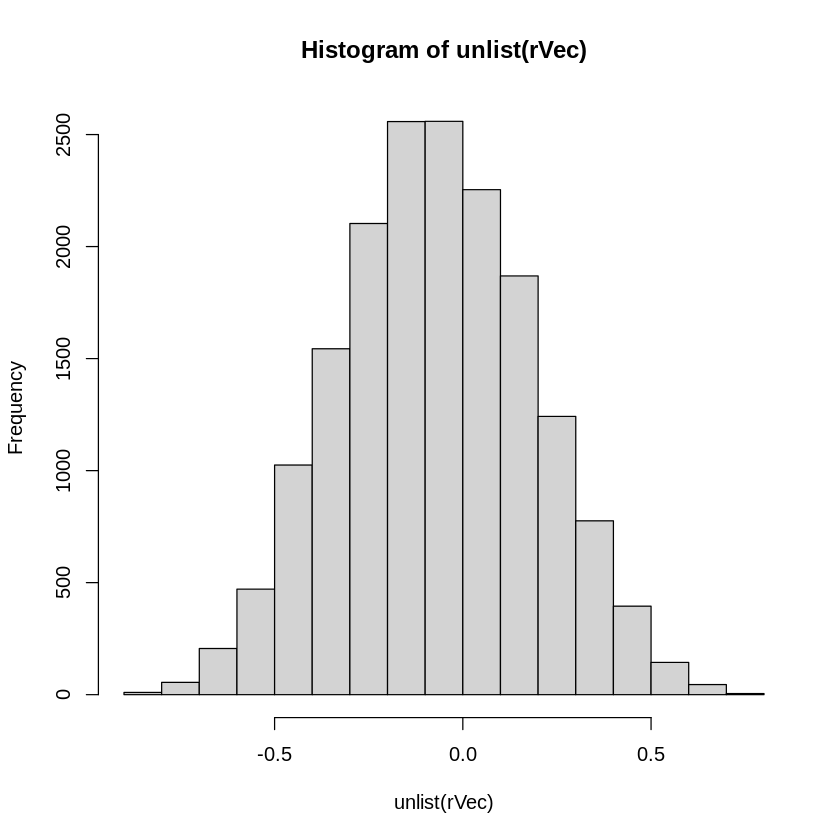

In [50]:
hist(unlist(rVec))

In [51]:
summary(unlist(rVec))

    Min.  1st Qu.   Median     Mean  3rd Qu.     Max. 
-0.87323 -0.24877 -0.07524 -0.07073  0.10669  0.78819 

In [ ]:
# set.seed(123)
# testData_subset2 = subset(testData_subset,OG %in% sample(OG_list_subset,1000))

# LSD::heatscatter(testData_subset2$zeroShotScore,testData_subset2$dn.ds,xlab = "avg. zero-shot scores",ylab = "dN/dS")
# abline(v = 2)

In [82]:
PMS = fread('/workdir/sh2246/p_phyloGWAS/output/combined_PMS_v2_20240909.txt')

In [83]:
colnames(PMS) = c("seqID","PMS","AAlength")

In [84]:
testData_merged = merge(testData_merged,PMS,by = 'seqID')

In [85]:
testData_merged$scaled.dn.ds = unlist(tapply(testData_merged$dn.ds,testData_merged$OG, function(x) (x-mean(x,na.rm =T))/sd(x,na.rm = T)))

In [86]:
cor(cbind(testData_merged$dn.ds,testData_merged$scaled.dn.ds,testData_merged$zeroShotScore,testData_merged$scaledScore),method = "spearman")

1.00000000,0.45165196,-0.26619041,-0.04528441
0.45165196,1.00000000,-0.02024905,-0.06480752
-0.26619041,-0.02024905,1.00000000,0.30884734
-0.04528441,-0.06480752,0.30884734,1.00000000


In [108]:
FS = fread('/workdir/sh2246/p_phyloGWAS/output/frameShiftMutation.txt')[,c(1,3)]

In [109]:
FS2 = fread('/workdir/sh2246/p_phyloGWAS/output/frameShiftMutation_additionalOGs.txt')[,c(1,3)]

In [110]:
FS = rbind(FS,FS2)

In [111]:
colnames(FS)[1] = "seqID"

In [115]:
# testData_merged = testData_merged[,-(368:370)]

In [116]:
testData_merged = merge(testData_merged,FS,by = 'seqID',all.x = T)

In [117]:
dim(testData_merged)
length(unique(testData_merged$OG))

[1] 16235636      368

In [418]:
plantCadZS = fread("/workdir/sh2246/p_phyloGWAS/output/plantCad_zeroShot_allOGs_240917.txt")

In [419]:
colnames(plantCadZS) = c("seqID","zeroShotScore_DNA","scaledScore_DNA")

In [422]:
plantCadZS$seqID = gsub('^OG.......:','',plantCadZS$seqID)

In [423]:
testData_merged = testData_merged[,1:370]

In [424]:
testData_merged = merge(testData_merged,plantCadZS,by = 'seqID',all.x = T)

In [425]:
dim(testData_merged)
length(unique(testData_merged$OG))

[1] 16235636      372

[1] 19625

In [394]:
gc()

,used,(Mb),gc trigger,(Mb),max used,(Mb)
Ncells,47267980,2524.4,74490060,3978.2,93112574,4972.8
Vcells,17273722636,131788.1,24493927798,186873.9,25503639656,194577.4


In [119]:
testData_merged$groups = as.character(cut(testData_merged$dn.ds,
                                          c(0,quantile(testData_merged$dn.ds,c(0.5,0.9,0.95,0.99,1))),
                                          labels = 1:5))
gc()
# testData_merged$groups[testData_merged$Frameshift==1] = "6"
testData_merged$groups[testData_merged$PMS==1] = "7"

,used,(Mb),gc trigger,(Mb),max used,(Mb)
Ncells,26937069,1438.6,74490060,3978.2,93112574,4972.8
Vcells,13119575997,100094.5,25514424790,194659.7,21248587301,162113.9


In [120]:
testData_merged$groups2 = as.character(cut(testData_merged$scaled.dn.ds,
                                          c(min(testData_merged$scaled.dn.ds)-.1,quantile(testData_merged$scaled.dn.ds,c(0.5,0.9,0.95,0.99,1))),
                                          labels = 1:5))
gc()
testData_merged$groups2[testData_merged$Frameshift==1] = "6"
testData_merged$groups2[testData_merged$PMS==1] = "7"

,used,(Mb),gc trigger,(Mb),max used,(Mb)
Ncells,26937120,1438.6,74490060,3978.2,93112574,4972.8
Vcells,13135814324,100218.4,25514424790,194659.7,24955892712,190398.4


In [121]:
write.table(testData_merged[,c(1,372)],"/workdir/sh2246/p_phyloGWAS/output/seqCategories.txt",quote = F,sep = "\t",row.names = F)

In [122]:
table(testData_merged$groups)
table(testData_merged$groups2)


      1       2       3       4       5       7 
7793111 6082024  753549  603872  151887  851193 


      1       2       3       4       5       6       7 
7707683 6073532  751727  602013  146548  102940  851193 

In [123]:
table(testData_merged$PMS,testData_merged$Frameshift)
fisher.test(table(testData_merged$PMS,testData_merged$Frameshift))

   
           0        1
  0 15281503   102940
  1   159715   691478


	Fisher's Exact Test for Count Data

data:  table(testData_merged$PMS, testData_merged$Frameshift)
p-value < 2.2e-16
alternative hypothesis: true odds ratio is not equal to 1
95 percent confidence interval:
 628.9443 658.5955
sample estimates:
odds ratio 
  645.9944 


In [94]:
library(ggplot2)
library(ggridges)
  

Warning message:
“The dot-dot notation (`..x..`) was deprecated in ggplot2 3.4.0.
ℹ Please use `after_stat(x)` instead.”
Picking joint bandwidth of 0.0581



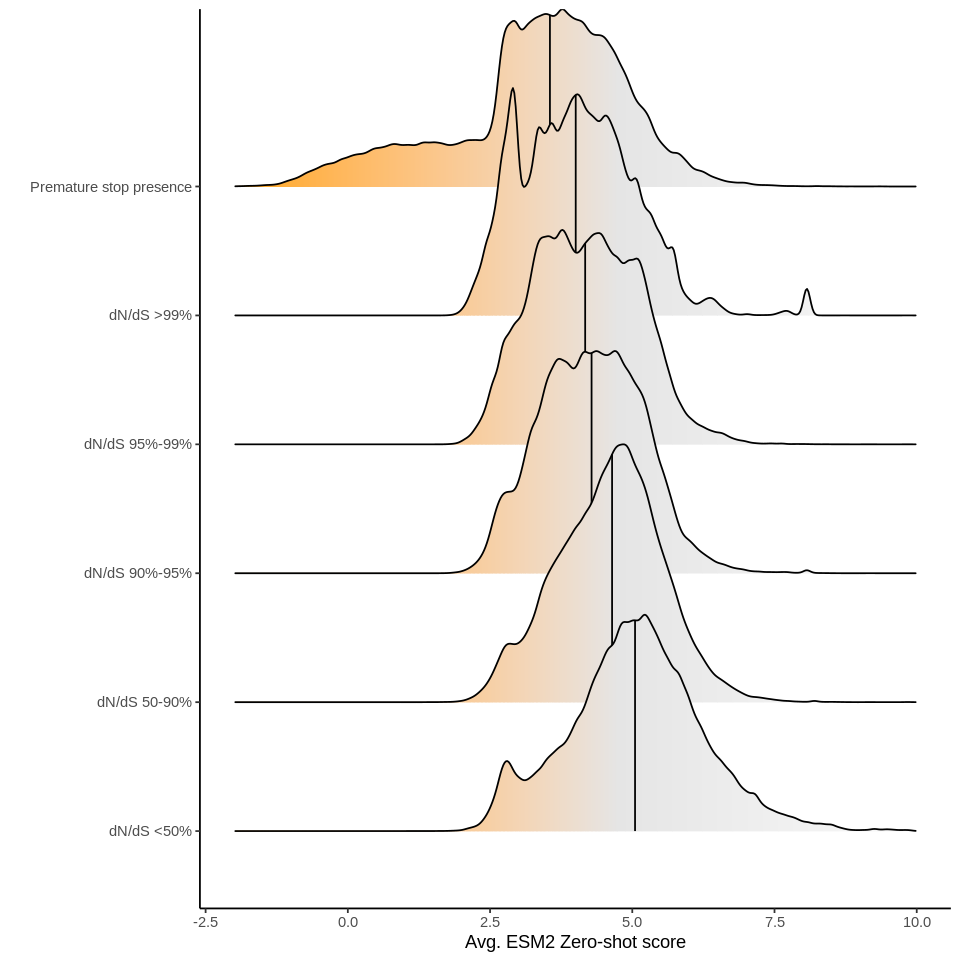

In [95]:
ggplot(testData_merged, aes(x = zeroShotScore, y = groups,fill = ..x..)) +
  geom_density_ridges_gradient(scale = 2, rel_min_height = 0,quantiles = 2,quantile_lines = T) + 
  scale_fill_gradient2(name = "Zero-shot scores", low = "orange", mid = "grey90", high = "white", 
                       midpoint = median(testData_merged$zeroShotScore)) +
  scale_y_discrete(labels=c("1" = "dN/dS <50%", "2" = "dN/dS 50-90%","3" = "dN/dS 90%-95%",
                            "4" = "dN/dS 95%-99%","5" = "dN/dS >99%",
                            "7" = "Premature stop presence"))+
  xlab("Avg. ESM2 Zero-shot score") +
  ylab("") +
  xlim(c(-2,10)) +
  theme_classic() +
  theme(
    legend.position = "none",
    panel.spacing = unit(0.1, "lines"),
    strip.text.x = element_text(size = 8)
  )

Picking joint bandwidth of 0.0428



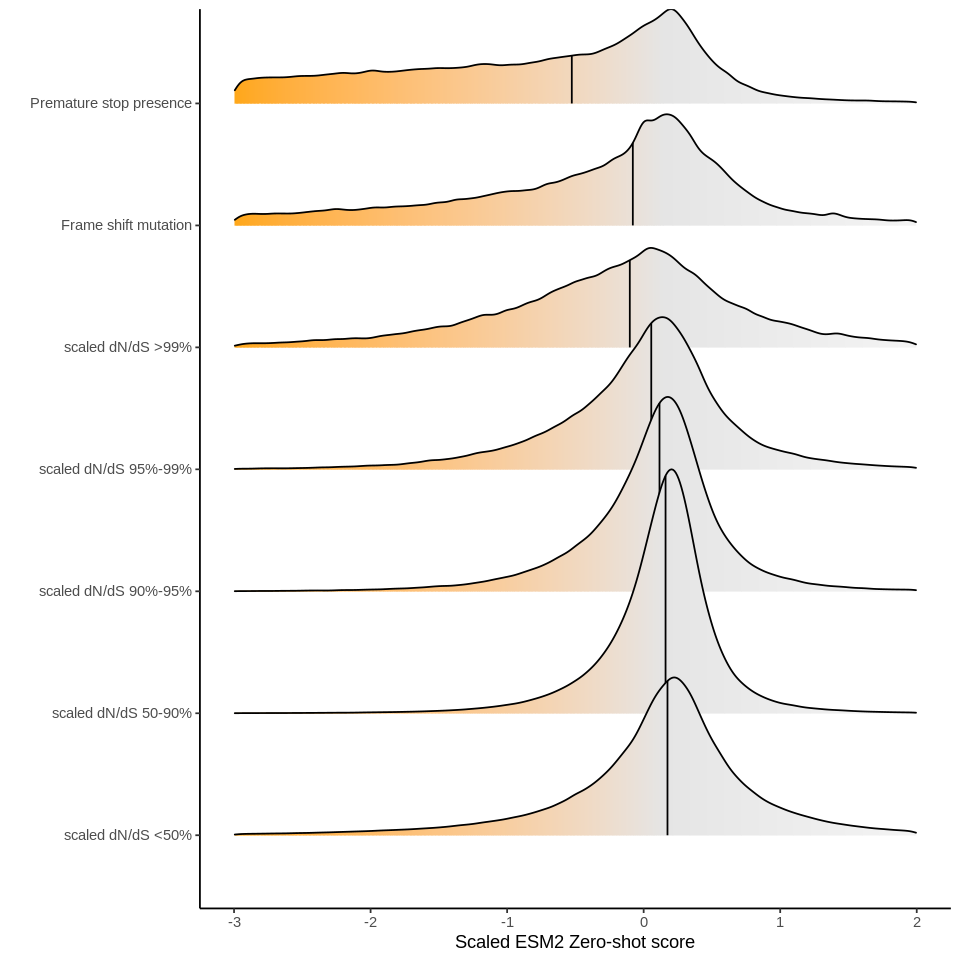

In [125]:
ggplot(testData_merged, aes(x = scaledScore, y = groups2,fill = ..x..)) +
  geom_density_ridges_gradient(scale = 2, rel_min_height = 0,quantiles = 2,quantile_lines = T) + 
  scale_fill_gradient2(name = "Zero-shot scores", low = "orange", mid = "grey90", high = "white", 
                       midpoint = median(testData_merged$scaledScore)) +
  scale_y_discrete(labels=c("1" = "scaled dN/dS <50%", "2" = "scaled dN/dS 50-90%","3" = "scaled dN/dS 90%-95%",
                            "4" = "scaled dN/dS 95%-99%","5" = "scaled dN/dS >99%","6" = "Frame shift mutation",
                            "7" = "Premature stop presence"))+
  xlab("Scaled ESM2 Zero-shot score") +
  ylab("") +
  xlim(c(-3,2)) +
  theme_classic() +
  theme(
    legend.position = "none",
    panel.spacing = unit(0.1, "lines"),
    strip.text.x = element_text(size = 8)
  )

In [426]:
gc()

,used,(Mb),gc trigger,(Mb),max used,(Mb)
Ncells,26887264,1436.0,74490060,3978.2,93112574,4972.8
Vcells,12505479305,95409.3,29392793357,224249.3,25503639656,194577.4


In [427]:
data.table::fwrite(testData_merged,"/workdir/sh2246/p_phyloGWAS/output/testData_merged.txt",sep = "\t",quote = F)

In [396]:
gc()

,used,(Mb),gc trigger,(Mb),max used,(Mb)
Ncells,47266435,2524.3,74490060,3978.2,93112574,4972.8
Vcells,17273461425,131786.1,29392793357,224249.3,25503639656,194577.4


# Modeling

In [252]:
test = fit_model_zs("OG0000508",data = testData_merged,phyloKMat)

ASReml Version 4.2 17/09/2024 09:51:15
          LogLik        Sigma2     DF     wall
 1     -513.3445     0.9239569    977   09:51:15  (  1 restrained)
 2     -511.9640     0.9238605    977   09:51:15  (  1 restrained)
 3     -510.5836     0.9236262    977   09:51:16  (  1 restrained)
 4     -509.2049     0.9235652    977   09:51:16  (  1 restrained)
 5     -507.8505     0.9235965    977   09:51:16  (  1 restrained)
 6     -506.8743     0.9243472    977   09:51:16
 7     -506.8679     0.9245757    977   09:51:16


Warning message in asreml(fixed = scaledScore ~ envPC_1 + envPC_2 + envPC_3 + envPC_4 + :
“Some components changed by more than 1% on the last iteration”


In [253]:
test

"OG0000508"   "0.0270039084961952"  "-0.0255875217603063" 
                                                                     
  "0.0390119528456644"  "-0.0406338487417955"   "0.0666832956157742" 
                                                                     
   "0.032201884897215"   "0.0905238300336142"   "0.0725553030612588" 
                                                             envPC_1 
"-0.00035839889096402" "-0.00283649790665941"    "0.760879628171328" 
               envPC_2                envPC_3                envPC_4 
   "0.736114076465418"    "0.226654208889422"    "0.505951758006223" 
               envPC_5                envPC_6                envPC_7 
  "0.0563786802976433"     "0.31286274420423"   "0.0161129306782035" 
               envPC_8                envPC_9               envPC_10 
  "0.0722763796045047"    "0.988468877826659"    "0.932464018389628" 
                                                                     
    "-506.86794505325" "7.73264071873623e-08"   "0.0920862787139305" 
               envPC_1                envPC_2                envPC_3 
 "0.00305509597372487"  "0.00374642060155619"   "0.0482187368571738" 
               envPC_4                envPC_5                envPC_6 
  "0.0145945928280841"    "0.120101373719238"   "0.0335993014993276" 
               envPC_7                envPC_8                envPC_9 
   "0.191013365712977"    "0.106567220775145" "6.89033502768659e-06" 
              envPC_10 
 "0.00023690626862061"

In [254]:
gc()

,used,(Mb),gc trigger,(Mb),max used,(Mb)
Ncells,26769446,1429.7,74490060,3978.2,93112574,4972.8
Vcells,11157672782,85126.3,20411539832,155727.7,25503639656,194577.4


In [255]:
asreml.options(maxit = 30,verbose = F)
testRes_zs = mclapply(OG_list,function(x) try(fit_model_zs(x,data = testData_merged,phyloKMat),silent = T),mc.cores = 20)

In [258]:
testRes_zs = t(simplify2array(testRes_zs[sapply(testRes_zs,length)==34]))

In [259]:
colnames(testRes_zs) = c("OG",paste0("Coeff_envPC",1:10),paste0("Pval_envPC",1:10),"loglik","VarComp_tabasco",
                         "VarComp_phylo",paste0("VAE_envPC",1:10))
testRes_zs = as.data.frame(testRes_zs)
head(testRes_zs)


,OG,Coeff_envPC1,Coeff_envPC2,Coeff_envPC3,Coeff_envPC4,Coeff_envPC5,Coeff_envPC6,Coeff_envPC7,Coeff_envPC8,Coeff_envPC9,⋯,VAE_envPC1,VAE_envPC2,VAE_envPC3,VAE_envPC4,VAE_envPC5,VAE_envPC6,VAE_envPC7,VAE_envPC8,VAE_envPC9,VAE_envPC10
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,⋯,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,OG0000062,0.00820779224347428,0.0133065130751642,-0.033816012060935,0.0326092662139528,0.0130806407964154,-0.00753539880839635,0.00251148176943323,0.021230802264839,-0.00925329938690961,⋯,0.00730561076298978,0.0163757838446342,0.177909825334096,0.216936508264345,0.0217686237411396,0.0047799414317519,0.00051450125371984,0.0367762404325242,0.0110842455153721,2.40453380337553e-06
2,OG0000098,-0.00460666109876054,0.133632683891827,0.0542566685009227,0.0757868305975419,-0.0211205205946426,-0.00678386952667173,-0.0394817952754369,-0.129474678706952,0.0773949703820518,⋯,0.178002818957244,0.213709018084473,0.0313409325480068,0.0494489591744551,0.0033010107933635,0.00135647957504298,0.00193947229028888,0.242560091436489,0.175961665998237,0.0536850810594015
3,OG0000106,0.107464616708949,-0.0311066074149002,-0.044202601746544,-0.0165458705551183,0.0229952467940988,0.00803685826235446,0.0400155320370618,0.0471525044809221,-0.0134043092223175,⋯,0.358533496225151,0.0187709208314799,0.173176024025899,0.00116631496147151,0.0487317194102835,0.000386727876507061,0.153609523894629,0.132672597603142,0.0224048197813628,0.00556488280702164
4,OG0000124,0.112971897553015,0.00868353307829355,-0.0238413454945045,-0.0330029907929674,-0.0466687441938246,0.0531741436606235,0.0458576433624453,-0.00788613619600007,-0.0993359275399642,⋯,0.131232372249186,0.0135599401826276,0.0301507430903753,0.0844460533568921,0.0753179416349233,0.0447092984392339,0.0822624890731441,0.0110007540862025,0.271726525159173,0.0719120967846611
5,OG0000150,0.0165328512754951,0.0145614893508998,0.000262471106193815,-0.0394355114170911,-0.0197912107596515,-0.0278749076980349,0.0251958467718607,0.000421686588923979,-0.00594018453169737,⋯,0.00854506758887118,0.0349863705255887,0.00117297653901976,0.136638109037857,0.0451563393831218,0.0839565208847477,0.0591438003411765,9.18832237652224e-05,0.00753171811966441,0.131708654395128
6,OG0000152,0.00728060808433542,-0.0219965115954576,0.0330791885061692,-0.0149434382980688,-0.007256704639892,-0.0284814548646963,0.0158272127653416,-0.0115407089561635,-0.0199348957157871,⋯,0.0177502115468577,0.0400195945873041,0.0976899310028887,0.0324645616390095,0.00252024909482885,0.0543217938641036,0.0371545494474448,0.0162230350997098,0.0303177902675193,0.194310234932865


In [260]:
dim(testRes_zs)
length(OG_list)

[1] 19624    34

[1] 19625

In [140]:
ePCs = readRDS('/workdir/sh2246/p_phyloGWAS/output/ePC_20240827.rds')

[1] 20
[1] 20
[1] 20
[1] 20
[1] 20
[1] 20
[1] 20
[1] 20
[1] 20
[1] 20


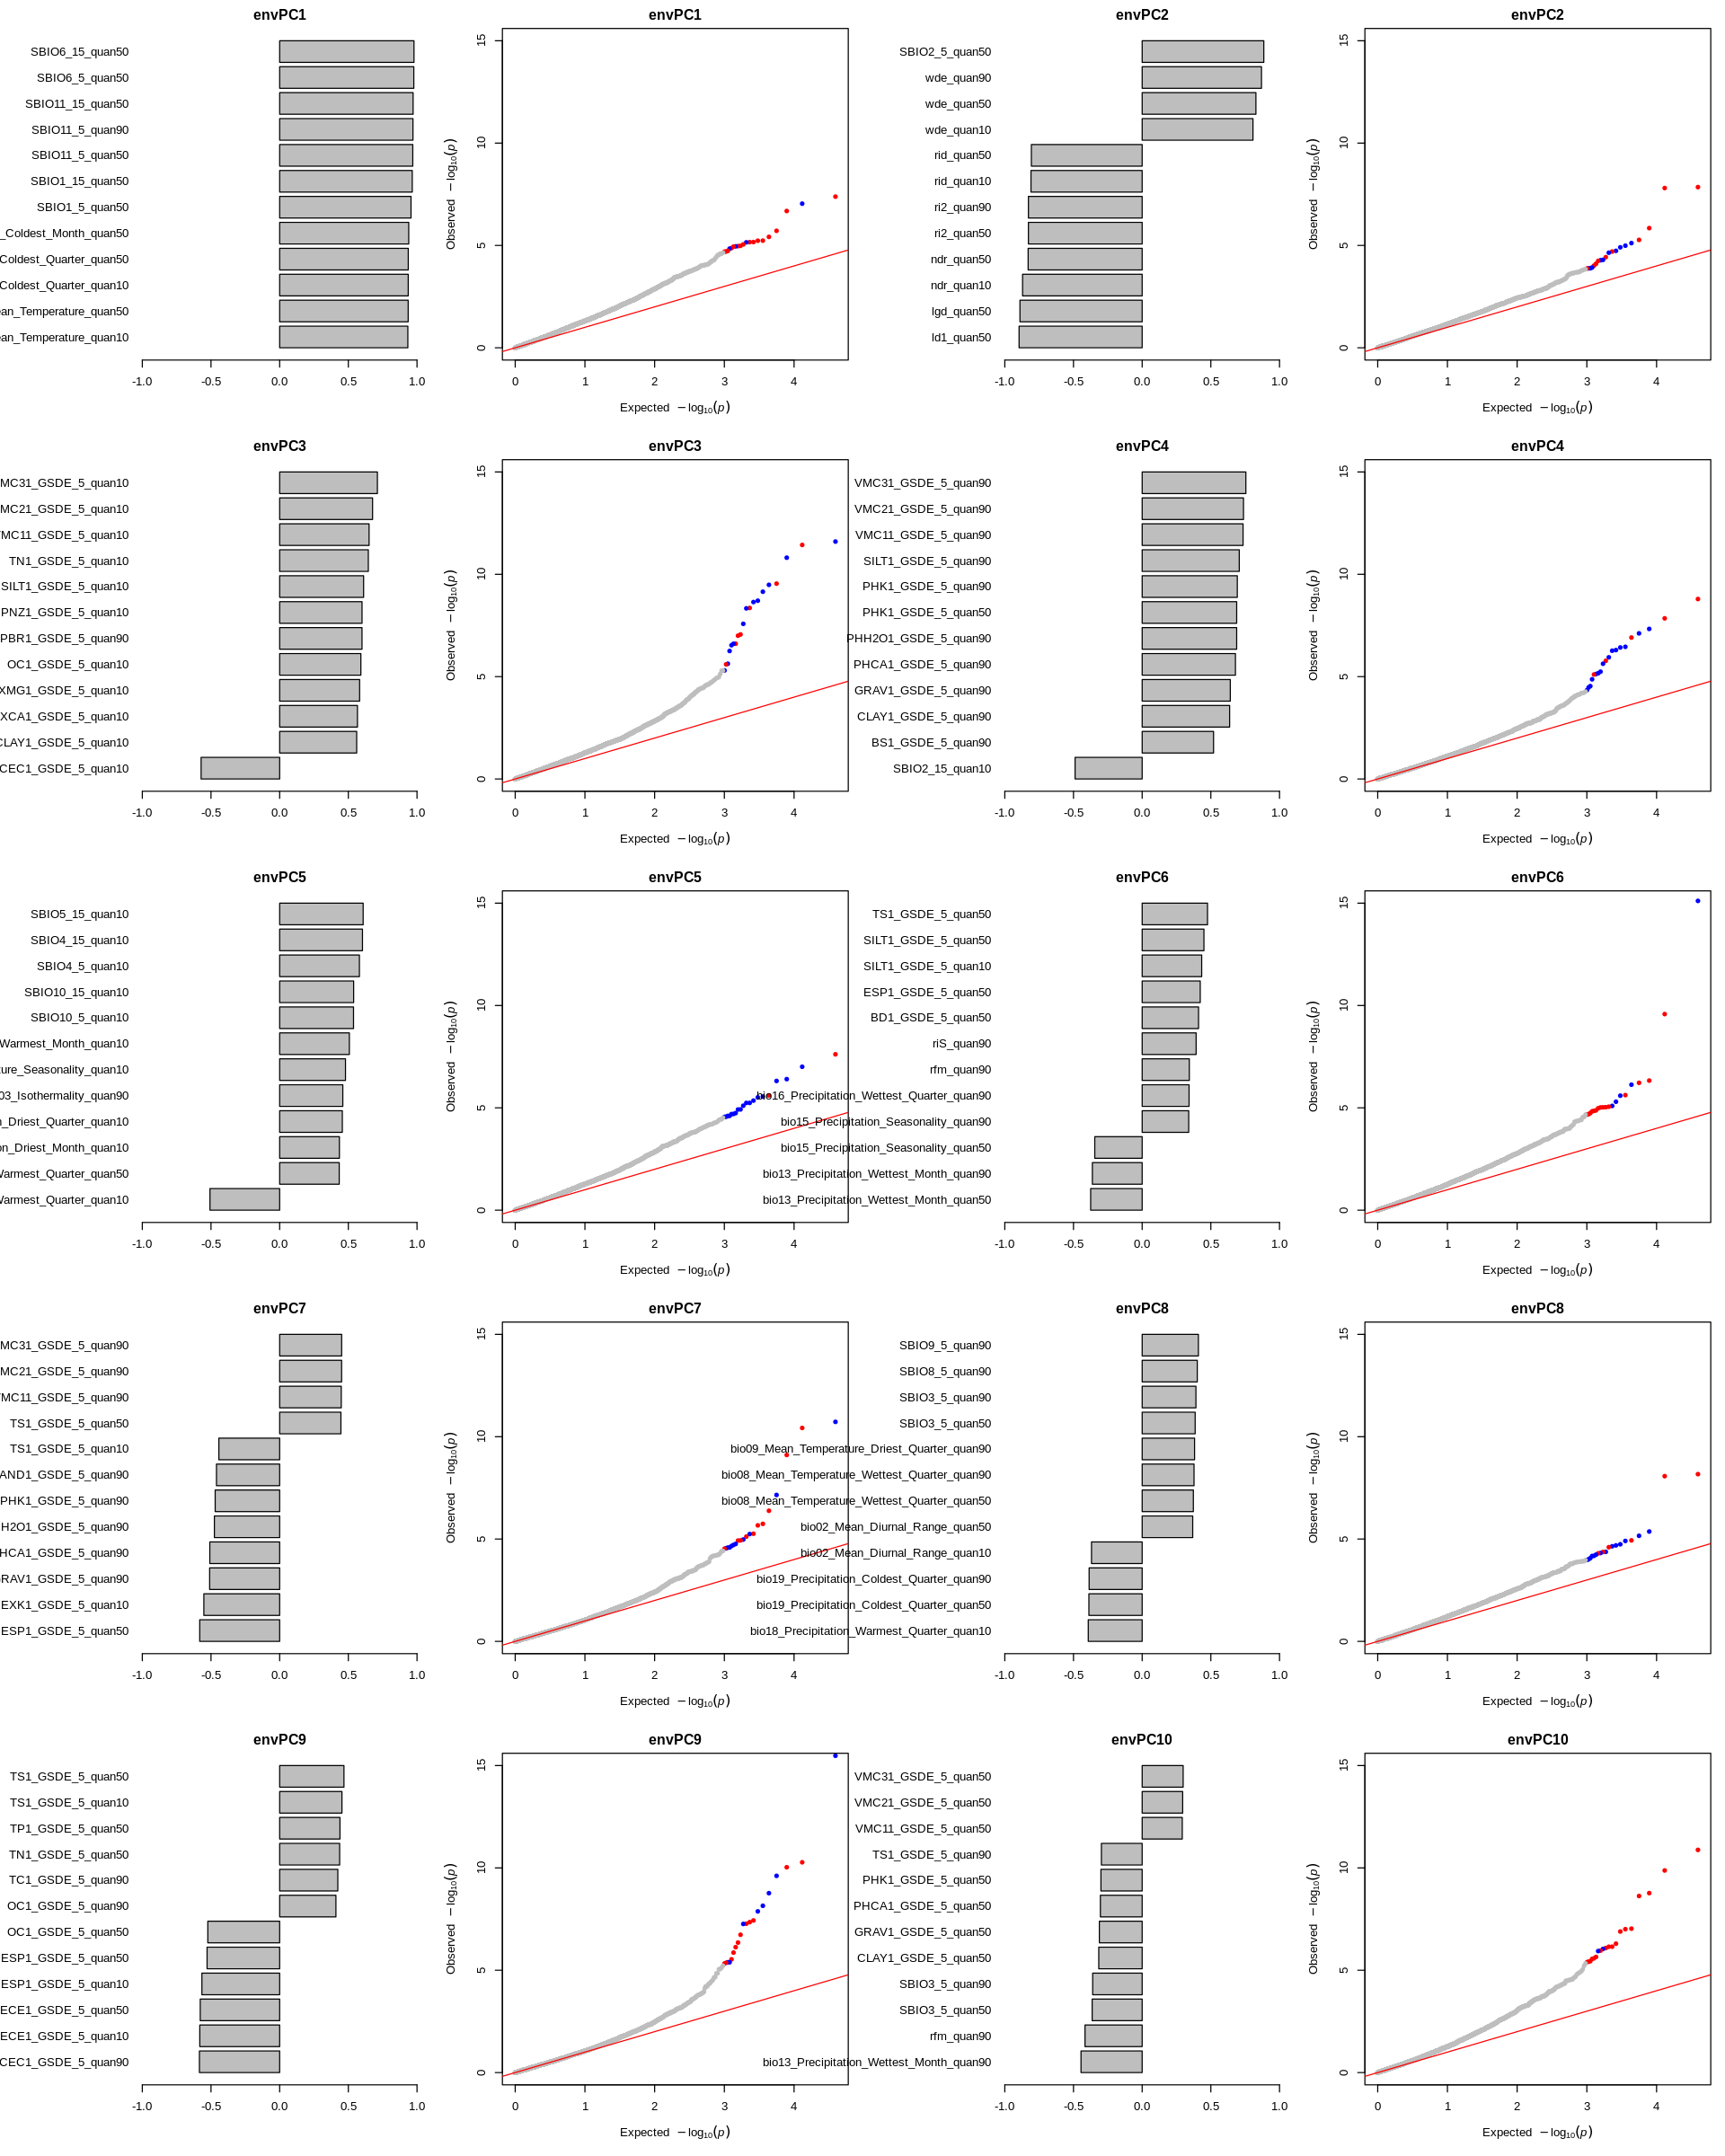

In [261]:
options(repr.plot.width=16, repr.plot.height=20)
par(mfrow = c(5,4))
for(i in 1:10){
    par(mar = c(5,10,2,1))
    topVar = which(rank(ePCs$variable.correlation[,i]^2,na.last = F) > 273)
    barplot(sort(ePCs$variable.components[topVar,i]),main = paste0("envPC",i),horiz = T,
            names.arg = rownames(ePCs$variable.correlation)[topVar],las =1,xlim = c(-1,1))
    
    par(mar = c(5,5,2,1))
    tmpCutoff = quantile(-log10(as.numeric(testRes_zs[,i+11])),.999,na.rm = T)
    tmpCol = rep("grey",nrow(testRes_zs))
    tmpCol[as.numeric(testRes_zs[,i+1])>0& -log10(as.numeric(testRes_zs[,i+11]))>tmpCutoff] = "red"
    tmpCol[as.numeric(testRes_zs[,i+1])<0& -log10(as.numeric(testRes_zs[,i+11]))>tmpCutoff] = "blue"
    qq(as.numeric(testRes_zs[,i+11]),main = paste0("envPC",i),ylim = c(0,15),
       col = tmpCol[order(as.numeric(testRes_zs[,i+11]))])
    print(sum(-log10(as.numeric(testRes_zs[,i+11]))>tmpCutoff,na.rm = T))
}


In [262]:
png('/workdir/sh2246/p_phyloGWAS/output/ASREML_res_zeroShotScoreModel.png',width = 20,height = 25,units = 'cm',res = 600,pointsize = 6)
par(mfrow = c(5,4))
for(i in 1:10){
    par(mar = c(5,20,2,1))
    topVar = which(rank(ePCs$variable.correlation[,i]^2,na.last = F) > 273)
    barplot(sort(ePCs$variable.components[topVar,i]),main = paste0("envPC",i),horiz = T,
            names.arg = rownames(ePCs$variable.correlation)[topVar],las =1,xlim = c(-1,1))
    
    par(mar = c(5,5,2,1))
    tmpCutoff = quantile(-log10(as.numeric(testRes_zs[,i+11])),.999,na.rm = T)
    tmpCol = rep("grey",nrow(testRes_zs))
    tmpCol[as.numeric(testRes_zs[,i+1])>0& -log10(as.numeric(testRes_zs[,i+11]))>tmpCutoff] = "red"
    tmpCol[as.numeric(testRes_zs[,i+1])<0& -log10(as.numeric(testRes_zs[,i+11]))>tmpCutoff] = "blue"
    qq(as.numeric(testRes_zs[,i+11]),main = paste0("envPC",i),ylim = c(0,15),
       col = tmpCol[order(as.numeric(testRes_zs[,i+11]))])
#     print(sum(-log10(as.numeric(testRes_zs[,i+11]))>tmpCutoff,na.rm = T))
}
dev.off()

png 
  2

In [263]:
mappingFile = read.table("/workdir/sh2246/p_phyloGWAS/output/OGToPv_mapping_v2.txt")
mappingFile2 = read.table("/workdir/sh2246/p_phyloGWAS/output/OGToZm_mapping_v2.txt")

In [264]:
colnames(mappingFile) = c("PvID","OG")
colnames(mappingFile2) = c("ZmID","OG")

In [265]:
mappingFileMerged = merge(mappingFile,mappingFile2,by = "OG",all = T)

In [266]:
head(mappingFileMerged)

,OG,PvID,ZmID
,<chr>,<chr>,<chr>
1,OG0000062,Pavag10G051000.1,Zm00001eb181730_T001
2,OG0000098,Pavag07G174700.1,Zm00001eb313690_T001
3,OG0000106,Pavag06G183800.1,Zm00001eb429540_T001
4,OG0000124,Pavag09G171600.1,Zm00001eb428040_T001
5,OG0000150,Pavag03G414300.1,Zm00001eb267280_T001
6,OG0000152,Pavag03G317400.1,Zm00001eb352080_T002


In [267]:
testRes_zs = merge(testRes_zs,mappingFileMerged,by = "OG",all.x = T)

In [268]:
write.table(testRes_zs,"/workdir/sh2246/p_phyloGWAS/output/ASREML_res_zeroShotScoreModel_v2.txt",quote = F,sep = "\t",row.names = F)

In [269]:
testRes_zs = read.table("/workdir/sh2246/p_phyloGWAS/output/ASREML_res_zeroShotScoreModel_v2.txt",header = T)

In [398]:
# plantCad model

In [740]:
test = fit_model_zs_dna("OG0000508",data = testData_merged,phyloKMat)
test

ASReml Version 4.2 25/09/2024 16:19:41
          LogLik        Sigma2     DF     wall
 1     -228.4942     0.5157144    977   16:19:41  (  1 restrained)
 2     -220.5419     0.5025290    977   16:19:41  (  1 restrained)
 3     -211.2454     0.4829792    977   16:19:41  (  1 restrained)
 4     -204.3908     0.4630372    977   16:19:41  (  1 restrained)
 5     -200.9095     0.4466325    977   16:19:41  (  1 restrained)
 6     -202.2554     0.4425735    977   16:19:41
 7     -201.4561     0.4407351    977   16:19:42
 8     -200.8618     0.4392084    977   16:19:42
 9     -200.5323     0.4382228    977   16:19:42
10     -200.4454     0.4379110    977   16:19:42
11     -200.4341     0.4378173    977   16:19:42


Warning message in asreml(fixed = scaledScore_DNA ~ envPC_1 + envPC_2 + envPC_3 + :
“Some components changed by more than 1% on the last iteration”


"OG0000508"   "0.0984133263525201"   "0.0244928924063498" 
                                                                     
 "0.00309647164725404"  "-0.0450856223163289"   "0.0802543896509952" 
                                                                     
 "0.00498220491185551"   "0.0183586940724357"   "0.0706423713559691" 
                                                             envPC_1 
 "0.00231045722860348"   "0.0234282548328852"   "0.0412784382029265" 
               envPC_2                envPC_3                envPC_4 
   "0.117521664621035"    "0.684529508646926"    "0.299593618081223" 
               envPC_5                envPC_6                envPC_7 
  "0.0040562315383299"     "0.80466987253968"    "0.716279883290949" 
               envPC_8                envPC_9               envPC_10 
   "0.030730027498451"    "0.898527999352758"    "0.354185577647319" 
                                                                     
   "-200.434081792673" "3.62139220774175e-07"    "0.459483312481201" 
               envPC_1                envPC_2                envPC_3 
  "0.0574034164306711"    "0.033770974432213"  "0.00227531881382527" 
               envPC_4                envPC_5                envPC_6 
  "0.0148314317703519"     "0.11383334051554" "0.000843036217969532" 
               envPC_7                envPC_8                envPC_9 
 "0.00182063827150534"   "0.0643426631966088" "0.000224147452138358" 
              envPC_10 
  "0.0118321015525821"

In [429]:
asreml.options(maxit = 30,verbose = F)
testRes_zs_dna = mclapply(OG_list,function(x) try(fit_model_zs_dna(x,data = testData_merged,phyloKMat),silent = T),mc.cores = 18)

testRes_zs_dna = t(simplify2array(testRes_zs_dna[sapply(testRes_zs_dna,length)==34]))

colnames(testRes_zs_dna) = c("OG",paste0("Coeff_envPC",1:10),paste0("Pval_envPC",1:10),"loglik","VarComp_tabasco",
                         "VarComp_phylo",paste0("VAE_envPC",1:10))
testRes_zs_dna = as.data.frame(testRes_zs_dna)
head(testRes_zs_dna)


testRes_zs_dna = merge(testRes_zs_dna,mappingFileMerged,by = "OG",all.x = T)
write.table(testRes_zs_dna,"/workdir/sh2246/p_phyloGWAS/output/ASREML_res_zeroShotScoreModel_plantCad_v2.txt",
            quote = F,sep = "\t",row.names = F)

In [438]:
testRes_zs_dna = read.table("/workdir/sh2246/p_phyloGWAS/output/ASREML_res_zeroShotScoreModel_plantCad_v2.txt",header = T)

In [ ]:
# dn/ds (scaled)

In [590]:
test = fit_model("OG0000508",data = testData_merged,phyloKMat)
test

ASReml Version 4.2 24/09/2024 22:31:58
          LogLik        Sigma2     DF     wall
 1     -493.0604     0.8863768    977   22:31:58  (  1 restrained)
 2     -486.1344     0.8630097    977   22:31:58  (  1 restrained)
 3     -476.6454     0.8239151    977   22:31:58  (  1 restrained)
 4     -467.7974     0.7783061    977   22:31:58  (  1 restrained)
 5     -462.0092     0.7356907    977   22:31:58  (  1 restrained)
 6     -459.7401     0.7150397    977   22:31:59
 7     -459.6621     0.7086552    977   22:31:59
 8     -459.6590     0.7073551    977   22:31:59


"OG0000508"    "-0.01042082062484"  "-0.0905725169503328" 
                                                                     
 "-0.0717618184127364"   "0.0272778482844653"   "-0.020345876144363" 
                                                                     
  "0.0195444535622779"    "0.019350798297514"  "-0.0595375697044192" 
                                                             envPC_1 
"-0.00965511466475625"  "-0.0292011228237033"    "0.977408757028973" 
               envPC_2                envPC_3                envPC_4 
 "0.00927354038763384"   "0.0245513781020373"    "0.723449050953751" 
               envPC_5                envPC_6                envPC_7 
   "0.570726728781582"    "0.660037003474786"    "0.442490935937419" 
               envPC_8                envPC_9               envPC_10 
   "0.162758296704427"    "0.753347221328579"    "0.378900013054317" 
                                                                     
   "-459.659008448053"  "4.2086756018258e-08"    "0.584093719329562" 
               envPC_1                envPC_2                envPC_3 
"7.62216642344833e-06"   "0.0643443871424004"    "0.048051309721394" 
               envPC_4                envPC_5                envPC_6 
 "0.00119016721611233"  "0.00305562492468983"  "0.00183905729412149" 
               envPC_7                envPC_8                envPC_9 
 "0.00560631527121619"   "0.0185200671226425" "0.000938543421385927" 
              envPC_10 
 "0.00735958624131716"

In [592]:
asreml.options(maxit = 30,verbose = F)
testRes_dnds = mclapply(OG_list,function(x) try(fit_model(x,data = testData_merged,phyloKMat),silent = T),mc.cores = 8)

testRes_dnds = t(simplify2array(testRes_dnds[sapply(testRes_dnds,length)==34]))

colnames(testRes_dnds) = c("OG",paste0("Coeff_envPC",1:10),paste0("Pval_envPC",1:10),"loglik","VarComp_tabasco",
                         "VarComp_phylo",paste0("VAE_envPC",1:10))
testRes_dnds = as.data.frame(testRes_dnds)
head(testRes_dnds)


testRes_dnds = merge(testRes_dnds,mappingFileMerged,by = "OG",all.x = T)
write.table(testRes_dnds,"/workdir/sh2246/p_phyloGWAS/output/ASREML_res_dndsModel_v2.txt",
            quote = F,sep = "\t",row.names = F)

,OG,Coeff_envPC1,Coeff_envPC2,Coeff_envPC3,Coeff_envPC4,Coeff_envPC5,Coeff_envPC6,Coeff_envPC7,Coeff_envPC8,Coeff_envPC9,⋯,VAE_envPC1,VAE_envPC2,VAE_envPC3,VAE_envPC4,VAE_envPC5,VAE_envPC6,VAE_envPC7,VAE_envPC8,VAE_envPC9,VAE_envPC10
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,⋯,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,OG0000062,0.00234705250440447,0.0178177151323806,-0.0347095212297834,0.00625236186429894,-0.00497300499368903,0.0441752144583389,0.00350281434880024,-0.00405655076275019,-0.00706700872758339,⋯,0.00782750792500769,0.0713961596655472,0.321806517589225,0.00476502567686297,0.0127590043479347,0.386659467736689,0.00170952029808195,0.0037006675481701,0.00979276873005953,0.00270681360258194
2,OG0000098,0.0603905970080104,-0.0414836429160968,0.0422390848223422,0.0423333247370585,-0.00287732773104326,0.0385540079689642,-0.0196018925268855,0.0429328742829345,0.017102057846357,⋯,0.12801640729897,0.0920008224198254,0.129065136273679,0.205262769161443,0.00168758111640423,0.105356101939107,0.0455640479841915,0.0742530533687974,0.0146293747249896,0.0169816927978131
3,OG0000106,-0.147833598408102,0.00879051903175243,0.0247656887708529,0.0194077627522844,0.037362822082383,0.0305449912682104,-0.038302649784187,-0.0811495219544956,0.00762352005985307,⋯,0.349490704346444,3.75428131858888e-05,0.0292292215139307,0.000718109873681259,0.075412402840371,0.0705230132679085,0.054580412508453,0.245462412041102,0.00375250911431135,0.00717252719894005
4,OG0000124,-0.0269637878104123,0.00667751898915634,0.00123707129274882,-0.0145073072956133,0.0117666776747592,0.00064576369981609,0.0220838674684669,-0.0421994310068358,-0.00805036332379405,⋯,0.0290032731618918,0.00360320105665778,6.54784492368876e-06,0.0962098302452849,0.017897967641375,0.000490773833119106,0.163381852623942,0.236270221301726,0.0126381786451247,3.18481936400467e-06
5,OG0000150,0.0623651505394023,0.0240999971723658,0.0257344402713112,-0.0423522957483767,-0.0137192839461784,-0.0174535114432205,-0.00775592247481766,0.0123648749938107,-0.0216486809232503,⋯,0.094240111750976,0.0529186562454091,0.0648413623080233,0.0735233567824532,0.0109517943114364,0.0308750556023261,0.000724256379913257,0.0033180359209718,0.0276298868599425,0.0482977380954167
6,OG0000152,-0.0309398169202072,0.104620338644978,-0.00875512938111224,-0.00811078609895498,0.0606592255094429,-0.0564940275350625,-0.0338207955780332,0.0322688210097706,0.0822186681076749,⋯,0.000376172648246135,0.113119190503862,0.000297632069840801,0.00191785680012234,0.054527936413588,0.0226414060155866,0.0276019950409515,0.00486505385619703,0.0994633636643898,0.0596726667455427


In [661]:
testRes_dnds = read.table("/workdir/sh2246/p_phyloGWAS/output/ASREML_res_dndsModel_v2.txt",header = T)

In [ ]:
# multiVariate

In [744]:
test = fit_model_multiVar("OG0000508",data = testData_merged,phyloKMat)
test

ASReml Version 4.2 25/09/2024 16:20:49
          LogLik        Sigma2     DF     wall
 1     -1580.393           1.0   2954   16:20:49  (  1 restrained)
 2     -1425.057           1.0   2954   16:20:49  (  1 restrained)
 3     -1278.723           1.0   2954   16:20:49  (  1 restrained)
 4     -1211.327           1.0   2954   16:20:50  (  1 restrained)
 5     -1194.846           1.0   2954   16:20:50  (  1 restrained)
 6     -1193.300           1.0   2954   16:20:50
 7     -1193.251           1.0   2954   16:20:50
 8     -1193.247           1.0   2954   16:20:50


"OG0000508"    "0.0488925251717868"    "0.0451344161487821" 
                                                                        
   "0.0146482625093831"   "-0.0385969480798108"    "0.0534823672750012" 
                                                                        
  "0.00735862706667298"     "0.029313176668486"    "0.0680357582842503" 
                                                                envPC_1 
"-0.000677714157765911"    "0.0177381067341631"     "0.464919284099712" 
                envPC_2                 envPC_3                 envPC_4 
   "0.0128511885161443"     "0.397160145833841"     "0.339778076085781" 
                envPC_5                 envPC_6                 envPC_7 
   "0.0282455030036722"     "0.717663219475047"     "0.368371060494529" 
                envPC_8                 envPC_9                envPC_10 
   "0.0182066244156666"     "0.995693589010368"     "0.424797802735728" 
                                                                        
    "-1193.24724076422"  "1.54331438317091e-08"    "0.0614562160251962" 
                envPC_1                 envPC_2                 envPC_3 
   "0.0250507072208782"     "0.290343479887567"    "0.0336295494525107" 
                envPC_4                 envPC_5                 envPC_6 
   "0.0427468590273555"     "0.225774831870015"   "0.00613303317926844" 
                envPC_7                 envPC_8                 envPC_9 
   "0.0379566614914347"     "0.261572996236788"  "1.36651027646114e-06" 
               envPC_10 
   "0.0298813333538589"

In [745]:
asreml.options(maxit = 30,verbose = F)
testRes_multiVar = mclapply(OG_list,function(x) try(fit_model_multiVar(x,data = testData_merged,phyloKMat),silent = T),mc.cores = 8)

testRes_multiVar = t(simplify2array(testRes_multiVar[sapply(testRes_multiVar,length)==34]))

colnames(testRes_multiVar) = c("OG",paste0("Coeff_envPC",1:10),paste0("Pval_envPC",1:10),"loglik","VarComp_tabasco",
                         "VarComp_phylo",paste0("VAE_envPC",1:10))
testRes_multiVar = as.data.frame(testRes_multiVar)
head(testRes_multiVar)


testRes_multiVar = merge(testRes_multiVar,mappingFileMerged,by = "OG",all.x = T)
write.table(testRes_multiVar,"/workdir/sh2246/p_phyloGWAS/output/ASREML_res_multiVarModel_v2.txt",
            quote = F,sep = "\t",row.names = F)

,OG,Coeff_envPC1,Coeff_envPC2,Coeff_envPC3,Coeff_envPC4,Coeff_envPC5,Coeff_envPC6,Coeff_envPC7,Coeff_envPC8,Coeff_envPC9,⋯,VAE_envPC1,VAE_envPC2,VAE_envPC3,VAE_envPC4,VAE_envPC5,VAE_envPC6,VAE_envPC7,VAE_envPC8,VAE_envPC9,VAE_envPC10
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,⋯,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,OG0000062,-0.00979894047851156,-0.000549249438882024,0.000651698489731962,0.00965833048287775,0.00756277385298951,-0.0212336293697512,0.00261110122813219,0.00832405420220096,-0.00368057458883612,⋯,0.0939768445204974,0.00164649049558435,0.000463381427432842,0.166378917780832,0.0798687617773331,0.425595701605764,0.00116449617332148,0.0432677480250625,0.0163466545959792,0.00364512821585326
2,OG0000098,-0.00816489314023886,0.0577509686884934,0.00281223619350782,0.0145052893146084,-0.011087128437055,-0.0103445306210132,0.001542610073768,-0.0626256646107668,0.0301045528269254,⋯,0.104740410989809,0.270684488987489,0.00409229173361233,0.00182670449540748,0.00537213658904239,0.0239785544019493,0.0442297599016397,0.345941125211702,0.147859728397592,0.00205939445651659
3,OG0000106,0.0802671043780037,0.00467593041777058,-0.0206765025818939,-0.023584097880444,-0.0205956317527023,-0.00903205832555157,0.0319519144871951,0.0378600308221259,0.00231194775945333,⋯,0.306473613309423,0.0232333872582003,0.0866007069508602,0.0382708833796593,0.0635479184005773,0.0275918516128839,0.171324647232557,0.177829803165267,0.000666535062021639,0.0418400273067839
4,OG0000124,0.0268979756597334,0.0319984909683882,-0.00489193146679299,-0.0101415998002261,-0.01737671555851,0.00422760998563791,0.0011751759151836,0.00585615200027857,-0.00828874015105988,⋯,0.191049886770519,0.459775685337304,0.0146488735427603,0.0705200288179855,0.123209050720548,0.00644617148750549,0.000980148491216236,0.0040248909625811,0.0252469949468834,0.0243234276323648
5,OG0000150,-0.00839680068788293,0.00851288636715865,-0.0131802842401329,-0.00266252496423157,-0.0161806493658943,-0.00745592349130199,0.0132223522949171,-0.00129270334679179,-0.000329296913491879,⋯,0.0389789011705975,0.0329926732818392,0.163930813166089,0.00202214786687718,0.196850359390865,0.0336913325587497,0.0959387014591822,0.00160895874998919,0.00151450465103936,0.298783841702847
6,OG0000152,0.0717474775350227,-0.054401985109016,0.0313984554398878,-0.00320136162583442,-0.0416802487058728,0.0404548490489732,0.0468821668712748,0.000782038230288582,-0.0573455154634422,⋯,0.12057329293774,0.130425314003611,0.0361170368434996,0.00044511045375845,0.133662003702888,0.070275922405284,0.183918119116227,0.00096381540350764,0.233669721746075,0.0552067215177385


In [747]:
testRes_multiVar = read.table("/workdir/sh2246/p_phyloGWAS/output/ASREML_res_multiVarModel_v2.txt",header = T)

In [593]:
gc()

,used,(Mb),gc trigger,(Mb),max used,(Mb)
Ncells,27544033,1471.1,74490060,3978.2,93112574,4972.8
Vcells,16430233581,125352.8,29392793357,224249.3,26354445001,201068.5


In [406]:
sapply(ls(), function(x) object.size(get(x)))

androK               avgZS_perTaxa 
                    2240744                       60800 
                     bg_RAO                    commonID 
                     155592                       57072 
                     compDF                     contTab 
                    1774168                        1216 
               df_collapsed                     envData 
                    4795984                     2066768 
                      envDf                      ePCIdx 
                    2127344                         208 
                       ePCs            eTraits_filtered 
                    2749856                     2075864 
                      exptd                      fg_RAO 
                     156696                        1496 
                  fit_model             fit_model_bio01 
                      30328                       30160 
         fit_model_bio01_zs             fit_model_bio12 
                      30160                       30160 
             fit_model_ePC1              fit_model_ePC2 
                      30160                       30160 
               fit_model_zs            fit_model_zs_dna 
                     134192                       36472 
                      fullK                fullK_subset 
                    4723184                     4723184 
                          i                           j 
                         56                          56 
                mappingFile                mappingFile2 
                    3144944                     3061648 
          mappingFileMerged                    metadata 
                    4782856                      339176 
                  model_tmp                       mycol 
                     553976                      137344 
                        obs                     OG_list 
                         56                     1413048 
                     phyloK               phyloK_subset 
                      13240                     4765800 
                  phyloKMat             plotTraitOnTree 
                    5117768                      164448 
                     pr_RAO                        pval 
                     473576                          56 
                        RAO                        rIdx 
                      24496                         704 
                    roc_RAO                        rsig 
                     473232                       49312 
                      spTre                spTre.rooted 
                     114560                      114536 
      spTre.rooted.filtered spTre.rooted.filtered.andro 
                     108888                       76192 
                    TABASCO              taxanomicGroup 
                      74056                      137968 
                       test                    testData 
                       4080                  5779520488 
            testData_merged                  testRes_zs 
                48491895432                     9663520 
           testRes_zs_andro                   tip_order 
                    9646272                       57072 
                 tip_order2                         tmp 
                      38576                        1024 
                     tmpCol                   tmpCutoff 
                     137472                         280 
                 tmpCutoff1                  tmpCutoff2 
                        280                         280 
                    tmpData                 tmpData_ebs 
                     961176                     3012032 
               tmpData_gdsl                tmpData_LEA3 
                    2808536                     2702448 
                tmpData_pap                    tooSmall 
                    2759104                       22144 
                     topVar                varExplained 
                         96                         176 
              varExplained1    

# Env. Variance explained by phyloK

In [177]:
library(ape)
library(ggtree)
library(geiger)



Attaching package: ‘ape’


The following objects are masked from ‘package:graph’:

    complement, degree, edges


The following object is masked from ‘package:dplyr’:

    where


Registered S3 methods overwritten by 'treeio':
  method              from    
  MRCA.phylo          tidytree
  MRCA.treedata       tidytree
  Nnode.treedata      tidytree
  Ntip.treedata       tidytree
  ancestor.phylo      tidytree
  ancestor.treedata   tidytree
  child.phylo         tidytree
  child.treedata      tidytree
  full_join.phylo     tidytree
  full_join.treedata  tidytree
  groupClade.phylo    tidytree
  groupClade.treedata tidytree
  groupOTU.phylo      tidytree
  groupOTU.treedata   tidytree
  is.rooted.treedata  tidytree
  nodeid.phylo        tidytree
  nodeid.treedata     tidytree
  nodelab.phylo       tidytree
  nodelab.treedata    tidytree
  offspring.phylo     tidytree
  offspring.treedata  tidytree
  parent.phylo        tidytree
  parent.treedata     tidytree
  root.treedata       tidyt

In [178]:
# load tree
spTre = read.tree("/workdir/sh2246/p_phyloGWAS/output/PoaceaeTree_angiosperm353_astral.nwk")
spTre.rooted = root(spTre,"ASM1935983v1")
spTre.rooted$edge.length[is.na(spTre.rooted$edge.length)] = 0.1

In [179]:
commonID = intersect(spTre.rooted$tip.label,rownames(ePCs$environmental.features))
eTraits_filtered = as.data.frame(ePCs$environmental.features[commonID,])
spTre.rooted.filtered = keep.tip(spTre.rooted,commonID)

In [271]:
source("/workdir/sh2246/p_phyloGWAS/src/S01_phyloK.R")

Warning message in file(file, "r"):
“cannot open file '/home/sh2246/Dropbox/postDoc/projects/p_phyloGWAS/data/test/test.tree.newick': No such file or directory”


ERROR: Error in file(file, "r"): cannot open the connection


In [150]:
envDf$assemblyID = as.factor(envDf$assemblyID)

In [183]:
fullK = phyloK(spTre.rooted.filtered)

In [184]:
fullK_subset <- fullK[rownames(fullK) %in% envDf$assemblyID,]
fullK_subset <- fullK_subset[,colnames(fullK_subset) %in% envDf$assemblyID]

In [185]:
asreml.options(verbose = FALSE)
varExplained1 = c()
model_tmp <- asreml(fixed = envPC_1 ~ envPC_2 + envPC_3 + envPC_4 + envPC_5 + envPC_6 + envPC_7 + envPC_8 + envPC_9 + envPC_10,
                random = ~ vm(assemblyID, fullK_subset), ai.sing = TRUE, data = envDf)
varExplained1 = c(varExplained1,summary(model_tmp)$varcomp[1,2]/sum(summary(model_tmp)$varcomp[,2]))
model_tmp <- asreml(fixed = envPC_2 ~ envPC_1 + envPC_3 + envPC_4 + envPC_5 + envPC_6 + envPC_7 + envPC_8 + envPC_9 + envPC_10,
                random = ~ vm(assemblyID, fullK_subset), ai.sing = TRUE, data = envDf)
varExplained1 = c(varExplained1,summary(model_tmp)$varcomp[1,2]/sum(summary(model_tmp)$varcomp[,2]))
model_tmp <- asreml(fixed = envPC_3 ~ envPC_1 + envPC_2 + envPC_4 + envPC_5 + envPC_6 + envPC_7 + envPC_8 + envPC_9 + envPC_10,
                random = ~ vm(assemblyID, fullK_subset), ai.sing = TRUE, data = envDf)
varExplained1 = c(varExplained1,summary(model_tmp)$varcomp[1,2]/sum(summary(model_tmp)$varcomp[,2]))
model_tmp <- asreml(fixed = envPC_4 ~ envPC_2 + envPC_3 + envPC_1 + envPC_5 + envPC_6 + envPC_7 + envPC_8 + envPC_9 + envPC_10,
                random = ~ vm(assemblyID, fullK_subset), ai.sing = TRUE, data = envDf)
varExplained1 = c(varExplained1,summary(model_tmp)$varcomp[1,2]/sum(summary(model_tmp)$varcomp[,2]))

ASReml Version 4.2 16/09/2024 14:47:44
          LogLik        Sigma2     DF     wall
 1     -194.1172     0.5440194    749   14:47:45
 2     -164.3849     0.4931366    749   14:47:45
 3     -122.5517     0.4219579    749   14:47:45
 4     -78.28829     0.3433787    749   14:47:45
 5     -43.12232     0.2690210    749   14:47:45
 6     -28.72353     0.2220940    749   14:47:45
 7     -24.76079     0.1962385    749   14:47:45
 8     -24.02931     0.1843957    749   14:47:45
 9     -23.93630     0.1799926    749   14:47:45
10     -23.92710     0.1785829    749   14:47:46
11     -23.92629     0.1781618    749   14:47:46
ASReml Version 4.2 16/09/2024 14:47:46
          LogLik        Sigma2     DF     wall
 1     -342.9921     0.8100095    749   14:47:46
 2     -321.2936     0.7466046    749   14:47:46
 3     -291.5413     0.6553757    749   14:47:46
 4     -265.7126     0.5628454    749   14:47:46
 5     -250.3342     0.4817451    749   14:47:46
 6     -246.4421     0.4376176    749   14:4

In [186]:
taxanomicGroup = read.csv("/workdir/sh2246/p_phyloGWAS/data/Poaceae_taxonomic_groups.csv",header = T)

In [187]:
head(taxanomicGroup)

,assemblyID,Species,clade,subfamily,tribe
,<chr>,<chr>,<chr>,<chr>,<chr>
1,ASM2160514v1,Aegilops bicornis,BOP,Pooideae,Triticeae
2,Aegilops_cylindrica,Aegilops cylindrica,BOP,Pooideae,Triticeae
3,SRR2219562,Aegilops geniculata,BOP,Pooideae,Triticeae
4,ASM2160520v1,Aegilops longissima,BOP,Pooideae,Triticeae
5,aegilops_longissima_6782_assembly,Aegilops longissima,BOP,Pooideae,Triticeae
6,Aegilops_markgrafii,Aegilops markgrafii,BOP,Pooideae,Triticeae


In [188]:
table(taxanomicGroup$subfamily)
table(taxanomicGroup$tribe)


Anomochlooideae   Arundinoideae    Bambusoideae   Chloridoideae      Oryzoideae 
              1               4              24              33              38 
    Panicoideae      Pharoideae        Pooideae 
            598               1             106 


  Andropogoneae   Arundinarieae       Bambuseae   Brachypodieae         Bromeae 
            556              11              10               7               3 
    Cynodonteae   Eragrostideae       Molinieae         Olyreae         Oryzeae 
             20               4               4               3              38 
       Paniceae       Paspaleae         Phareae           Poeae         Stipeae 
             39               3               1              45               1 
Streptochaeteae    Triraphideae       Triticeae        Zoysieae 
              1               1              50               8 

In [189]:
spTre.rooted.filtered.andro = keep.tip(spTre.rooted,intersect(taxanomicGroup[taxanomicGroup[,5] == "Andropogoneae",1],commonID))

In [190]:
androK = phyloK(spTre.rooted.filtered.andro)

In [191]:
varExplained2 = c()
model_tmp <- asreml(fixed = envPC_1 ~ envPC_2 + envPC_3 + envPC_4 + envPC_5 + envPC_6 + envPC_7 + envPC_8 + envPC_9 + envPC_10,
                random = ~ vm(assemblyID, androK), ai.sing = TRUE, data = envDf[rownames(androK),])
varExplained2 = c(varExplained2,summary(model_tmp)$varcomp[1,2]/sum(summary(model_tmp)$varcomp[,2]))
model_tmp <- asreml(fixed = envPC_2 ~ envPC_1 + envPC_3 + envPC_4 + envPC_5 + envPC_6 + envPC_7 + envPC_8 + envPC_9 + envPC_10,
                random = ~ vm(assemblyID, androK), ai.sing = TRUE, data = envDf[rownames(androK),])
varExplained2 = c(varExplained2,summary(model_tmp)$varcomp[1,2]/sum(summary(model_tmp)$varcomp[,2]))
model_tmp <- asreml(fixed = envPC_3 ~ envPC_1 + envPC_2 + envPC_4 + envPC_5 + envPC_6 + envPC_7 + envPC_8 + envPC_9 + envPC_10,
                random = ~ vm(assemblyID, androK), ai.sing = TRUE, data = envDf[rownames(androK),])
varExplained2 = c(varExplained2,summary(model_tmp)$varcomp[1,2]/sum(summary(model_tmp)$varcomp[,2]))
model_tmp <- asreml(fixed = envPC_4 ~ envPC_2 + envPC_3 + envPC_1 + envPC_5 + envPC_6 + envPC_7 + envPC_8 + envPC_9 + envPC_10,
                random = ~ vm(assemblyID, androK), ai.sing = TRUE, data = envDf[rownames(androK),])
varExplained2 = c(varExplained2,summary(model_tmp)$varcomp[1,2]/sum(summary(model_tmp)$varcomp[,2]))

ASReml Version 4.2 16/09/2024 14:50:03
          LogLik        Sigma2     DF     wall
 1     -54.47663     0.3786454    510   14:50:03
 2     -48.57932     0.3588608    510   14:50:03
 3     -40.64791     0.3278912    510   14:50:03
 4     -34.15907     0.2944270    510   14:50:03
 5     -30.64397     0.2643829    510   14:50:03
 6     -29.81973     0.2486049    510   14:50:04
 7     -29.69787     0.2421698    510   14:50:04
 8     -29.68518     0.2400326    510   14:50:04
 9     -29.68407     0.2393964    510   14:50:04
ASReml Version 4.2 16/09/2024 14:50:04
          LogLik        Sigma2     DF     wall
 1     -213.9138     0.7084448    510   14:50:04
 2     -207.8579     0.6727293    510   14:50:04
 3     -200.7637     0.6216253    510   14:50:04
 4     -195.7906     0.5697995    510   14:50:04
 5     -193.5873     0.5259028    510   14:50:04
 6     -193.2726     0.5074489    510   14:50:04
 7     -193.2538     0.5026773    510   14:50:04
 8     -193.2532     0.5018189    510   14:5

In [192]:
varExplained2

[1] 0.7886865 0.7395381 0.7050602 0.6317960

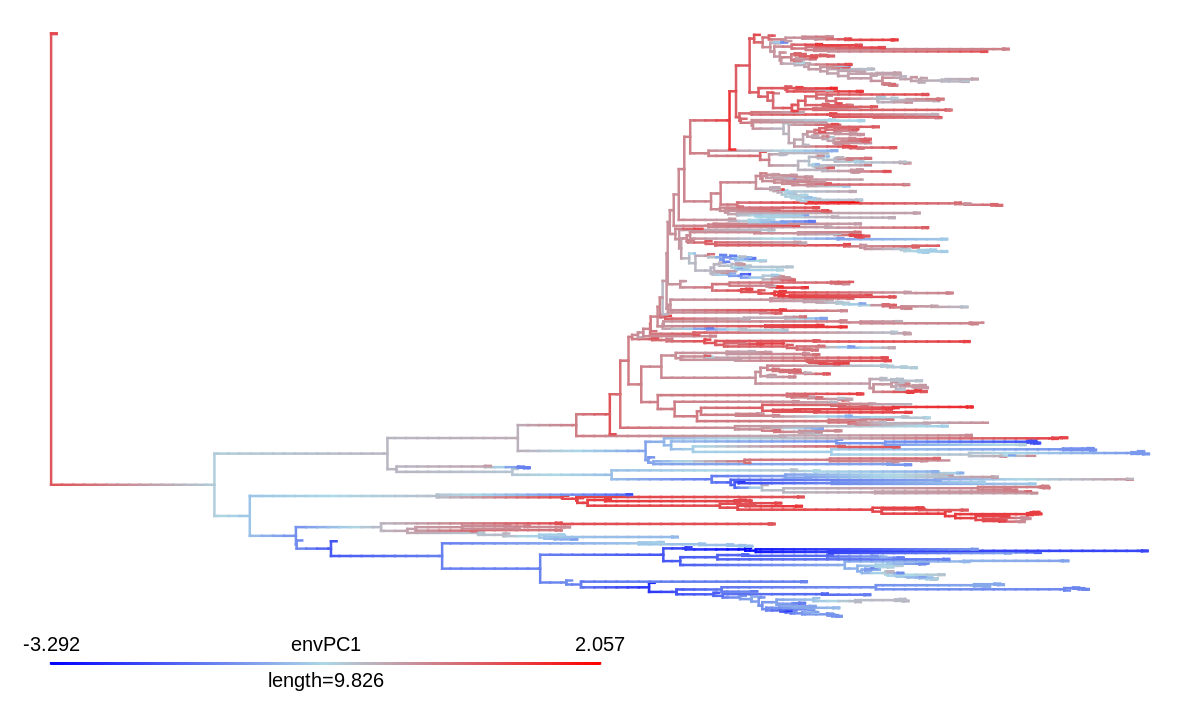

In [193]:
plotTraitOnTree(envDf$envPC_1,
                commonID,spTre.rooted.filtered,visible_tip_labels = F,
                legend.title = "envPC1",col = c("blue","lightblue","red"))


In [194]:
library(pheatmap)

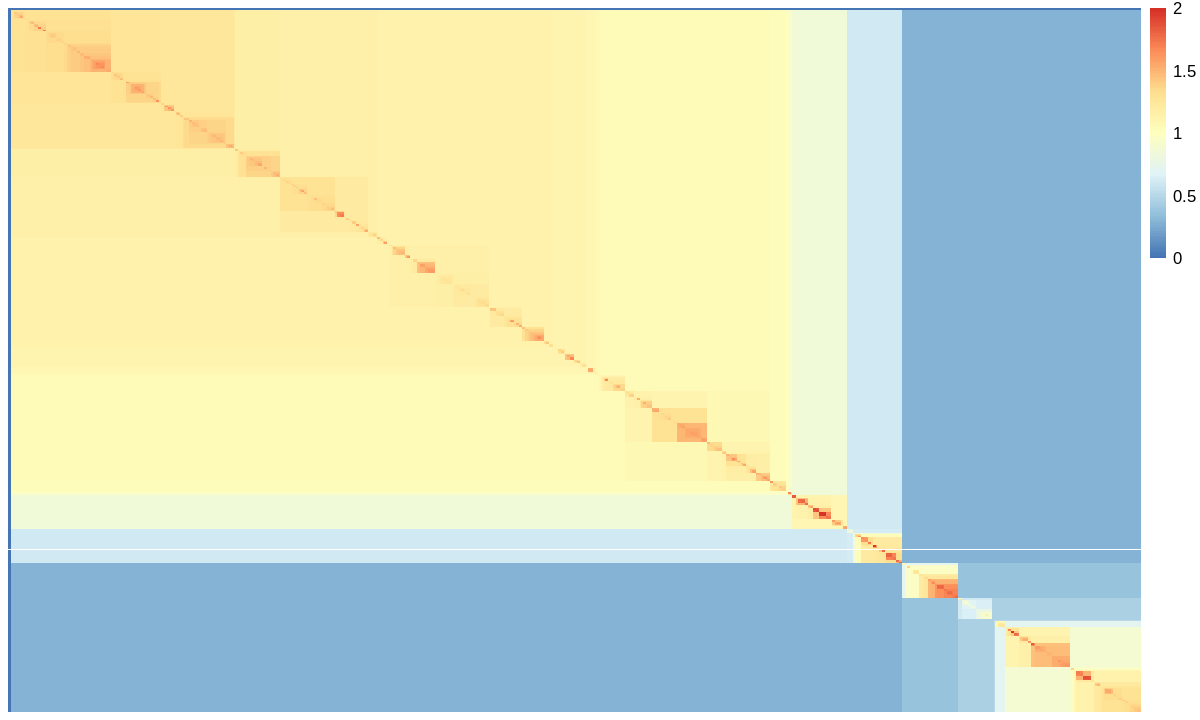

In [195]:
tip_order <- spTre.rooted.filtered$tip.label[spTre.rooted.filtered$edge[spTre.rooted.filtered$edge[, 2] <= length(spTre.rooted.filtered$tip.label), 2]]

pheatmap(fullK[rev(tip_order),rev(tip_order)],
         cluster_rows = F,cluster_cols = F,show_rownames = F,show_colnames = F)

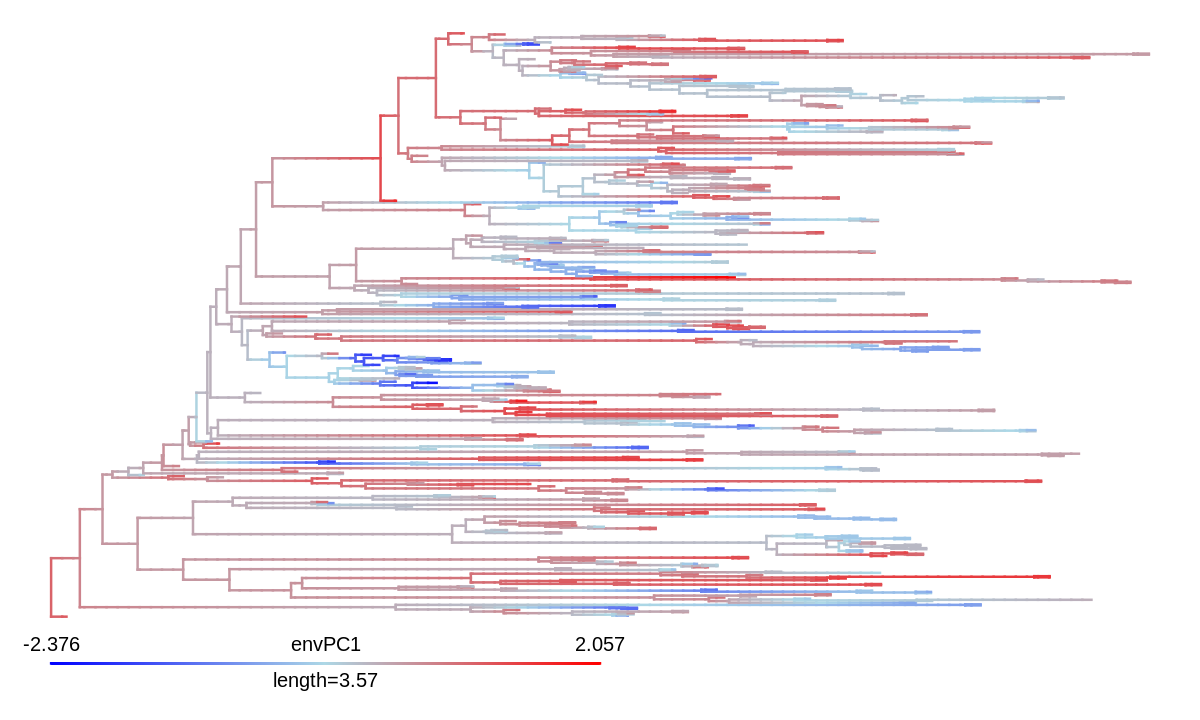

In [196]:
plotTraitOnTree(envDf[intersect(commonID,spTre.rooted.filtered.andro$tip.label),]$envPC_1,
                intersect(commonID,spTre.rooted.filtered.andro$tip.label),
                spTre.rooted.filtered.andro,visible_tip_labels = F,
                legend.title = "envPC1",col = c("blue","lightblue","red"))


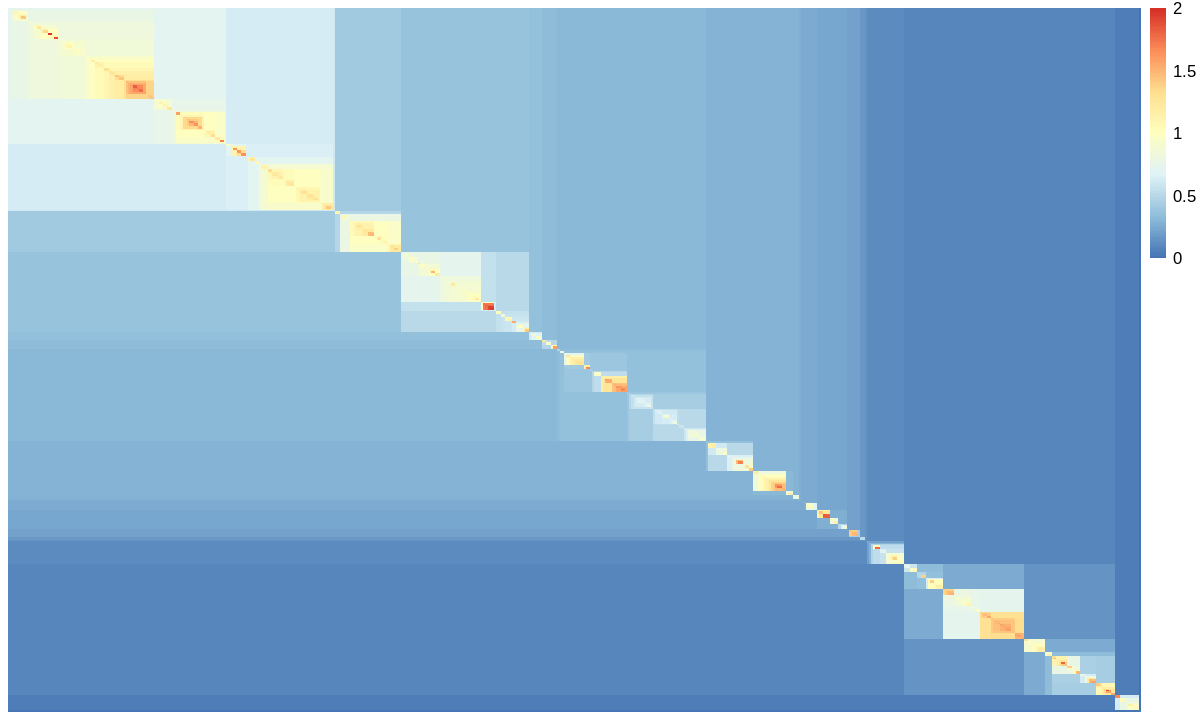

In [197]:
tip_order2 <- spTre.rooted.filtered.andro$tip.label[spTre.rooted.filtered.andro$edge[spTre.rooted.filtered.andro$edge[, 2] <= length(spTre.rooted.filtered.andro$tip.label), 2]]

pheatmap(androK[rev(tip_order2),rev(tip_order2)],
         cluster_rows = F,cluster_cols = F,show_rownames = F,show_colnames = F)

In [433]:
testData_merged_andro =  subset(testData_merged,assemblyID%in%rownames(androK))

In [434]:
gc()

,used,(Mb),gc trigger,(Mb),max used,(Mb)
Ncells,27527065,1470.2,74490060,3978.2,93112574,4972.8
Vcells,16428492771,125339.5,29392793357,224249.3,25503639656,194577.4


# andro-specific model

In [273]:
asreml.options(maxit = 30,verbose = F)
testRes_zs_andro = mclapply(OG_list,function(x) try(fit_model_zs(x,data = testData_merged_andro,androK),silent = T),mc.cores = 15)

In [275]:
testRes_zs_andro = t(simplify2array(testRes_zs_andro[sapply(testRes_zs_andro,length)==34]))

In [276]:
colnames(testRes_zs_andro) = c("OG",paste0("Coeff_envPC",1:10),paste0("Pval_envPC",1:10),"loglik","VarComp_tabasco",
                         "VarComp_phylo",paste0("VAE_envPC",1:10))
testRes_zs_andro = as.data.frame(testRes_zs_andro)
head(testRes_zs_andro)


,OG,Coeff_envPC1,Coeff_envPC2,Coeff_envPC3,Coeff_envPC4,Coeff_envPC5,Coeff_envPC6,Coeff_envPC7,Coeff_envPC8,Coeff_envPC9,⋯,VAE_envPC1,VAE_envPC2,VAE_envPC3,VAE_envPC4,VAE_envPC5,VAE_envPC6,VAE_envPC7,VAE_envPC8,VAE_envPC9,VAE_envPC10
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,⋯,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,OG0000062,-0.00502365543342872,0.0260155074408829,-0.0453860819690749,0.01998391891757,0.00734325471743892,0.0108625421538762,0.0116528905290204,0.00325574861669948,-0.0134615621172438,⋯,0.000221062702611529,0.0647504660131415,0.194326095177631,0.0324382852288119,0.0017925842037351,0.00935346521877611,0.00546508922396606,0.000616800946362224,0.0155697205871832,0.00844461593002937
2,OG0000098,-0.0122724976072968,0.0391437197344102,0.00994579028556352,0.052664809261759,0.00151222875570469,0.0166677289573302,-0.0119877842810152,-0.0809753163979561,0.0478687402510686,⋯,0.079522508641305,0.0144544851994358,0.00219926552978026,0.00395034716478644,0.0109429406566301,0.0173344932264856,0.0258377888162811,0.144664296535676,0.156545031750515,0.235156167069305
3,OG0000106,0.056665201730762,-0.0106408420580694,-0.0186916429053125,0.0272185118416802,0.0118829587809323,0.0266132432255043,0.00813367854999639,0.00490127187210067,0.0113215433340591,⋯,0.371220367067783,0.0086521131072783,0.0903326587133791,0.0878868910561935,0.0187069640971984,0.122526819791086,0.00751033208794854,0.00538631582008821,0.021043623854265,0.0150055149421847
4,OG0000124,0.0461081432572054,0.0117912795783985,-0.00140868939292175,-0.00622492781255963,-0.0430879529214008,-0.00543963904604842,0.0503547745889108,-0.055160744518904,-0.0209318231059044,⋯,0.0627885853661869,0.00090862805701323,0.00192972262490055,0.00736191469872453,0.10097700794484,0.000365842492129083,0.191433867574778,0.125826708227785,0.0117516278563546,0.13002204770642
5,OG0000150,-0.000845299171701199,0.00217912958356368,0.00529786752585954,-0.00160698953505924,0.00268873735339031,-0.00509400150680442,-0.00684141419148071,0.0115701669998309,-0.00740030038927154,⋯,0.00179022463211863,0.00154189798595938,0.00445373830887673,0.000138754987534955,0.000176004651203111,0.00273401710805451,0.00721009383725115,0.00281197373732388,0.00508287222104551,0.00248013247361605
6,OG0000152,-0.019147069016099,-0.0127298110856249,0.00256216209451951,-0.0143948520982086,0.00779490988759586,-0.00589198666113868,-0.0151411484509159,0.018468333353888,-0.0181592057980688,⋯,0.0576761094675101,0.00320321469342543,0.00492615342407687,0.00761278917610266,0.00475879634058167,0.00572372063464533,0.0376086967338596,0.00762799533654581,0.0341213588151599,0.00169904856657315


In [293]:
testRes_zs_andro = merge(testRes_zs_andro,mappingFileMerged,by = "OG",all.x = T)

In [295]:
write.table(testRes_zs_andro,"/workdir/sh2246/p_phyloGWAS/output/ASREML_res_zeroShotScoreModel_andro_v2.txt",quote = F,sep = "\t",row.names = F)

In [296]:
testRes_zs_andro = read.table("/workdir/sh2246/p_phyloGWAS/output/ASREML_res_zeroShotScoreModel_andro_v2.txt",header = T)

In [440]:
asreml.options(maxit = 30,verbose = F)
testRes_zs_dna_andro = mclapply(OG_list,function(x) try(fit_model_zs_dna(x,data = testData_merged_andro,androK),silent = T),mc.cores = 8)

In [441]:
testRes_zs_dna_andro = t(simplify2array(testRes_zs_dna_andro[sapply(testRes_zs_dna_andro,length)==34]))

In [ ]:
colnames(testRes_zs_dna_andro) = c("OG",paste0("Coeff_envPC",1:10),paste0("Pval_envPC",1:10),"loglik","VarComp_tabasco",
                         "VarComp_phylo",paste0("VAE_envPC",1:10))
testRes_zs_dna_andro = as.data.frame(testRes_zs_dna_andro)
head(testRes_zs_dna_andro)

In [ ]:
testRes_zs_dna_andro = merge(testRes_zs_dna_andro,mappingFileMerged,by = "OG",all.x = T)

write.table(testRes_zs_dna_andro,"/workdir/sh2246/p_phyloGWAS/output/ASREML_res_zeroShotScoreModel_andro_plantCad_v2.txt",quote = F,sep = "\t",row.names = F)

In [546]:
testRes_zs_dna_andro = read.table("/workdir/sh2246/p_phyloGWAS/output/ASREML_res_zeroShotScoreModel_andro_plantCad_v2.txt",header = T)

In [594]:
asreml.options(maxit = 30,verbose = F)
testRes_dnds_andro = mclapply(OG_list,function(x) try(fit_model(x,data = testData_merged_andro,phyloKMat),silent = T),mc.cores = 8)

testRes_dnds_andro = t(simplify2array(testRes_dnds_andro[sapply(testRes_dnds_andro,length)==34]))

colnames(testRes_dnds_andro) = c("OG",paste0("Coeff_envPC",1:10),paste0("Pval_envPC",1:10),"loglik","VarComp_tabasco",
                         "VarComp_phylo",paste0("VAE_envPC",1:10))
testRes_dnds_andro = as.data.frame(testRes_dnds_andro)
head(testRes_dnds_andro)


testRes_dnds_andro = merge(testRes_dnds_andro,mappingFileMerged,by = "OG",all.x = T)
write.table(testRes_dnds_andro,"/workdir/sh2246/p_phyloGWAS/output/ASREML_res_dndsModel_andro_v2.txt",
            quote = F,sep = "\t",row.names = F)

,OG,Coeff_envPC1,Coeff_envPC2,Coeff_envPC3,Coeff_envPC4,Coeff_envPC5,Coeff_envPC6,Coeff_envPC7,Coeff_envPC8,Coeff_envPC9,⋯,VAE_envPC1,VAE_envPC2,VAE_envPC3,VAE_envPC4,VAE_envPC5,VAE_envPC6,VAE_envPC7,VAE_envPC8,VAE_envPC9,VAE_envPC10
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,⋯,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,OG0000062,0.00334486703368936,0.00604454100226454,-0.0383101092809256,0.00749686841985928,0.0209811372991295,0.040809152680016,-0.0152349545444201,0.0172066407891785,-0.0302571497351052,⋯,0.0154548374772325,0.0488086443932617,0.27455822402801,0.0148035983279786,0.0197722358125881,0.216262381529272,0.0468567647158316,0.00226694018935003,0.114771668130257,0.112975532627046
2,OG0000098,0.155846825873421,-0.0893847379696191,0.0137335059705882,0.0319883473776522,-0.0536394949823871,0.0727003339024635,-0.00465247531007135,0.0852220893954043,0.0136574093344888,⋯,0.242015848360145,0.206029360587625,0.00382520805450615,0.0867342200626513,0.114344720047355,0.166160438294653,0.0152611166847371,0.127486277910469,0.00593348705642453,0.00109673701899706
3,OG0000106,-0.108972024804261,-0.0806831534291955,-0.0155618290879787,-0.0150935532728702,0.0721883884029333,0.007749492624741,-0.0108469763594823,-0.015439216305681,-0.0260335662561105,⋯,0.355805056151194,0.230509464322602,0.00298640668769676,0.0139690283610275,0.27648683956247,0.000240338366048813,0.000324613814121131,0.0183155352559264,0.0465548033553488,0.00278943536288148
4,OG0000124,-0.0323641297437637,-0.00902672665755231,0.0109647831894902,-0.00925448451875237,0.0186186562879541,0.0329110740346263,0.0146127397953906,-0.0132708789819435,-0.0284771752969045,⋯,0.128027076900822,0.0107070766201134,0.0332483685695153,0.0162284123934514,0.0360272924888712,0.223145092226392,0.0645774944167535,0.0921424546803247,0.192652427139249,0.00223683690102432
5,OG0000150,0.0597393759940718,0.00565331882769255,0.0235565256402371,-0.026896415098364,-0.00251452532197572,-0.00576135800351822,-0.0211456707010998,-0.00131317828816983,-0.0342651049627616,⋯,0.232954452441227,0.0133658919885485,0.155685274964267,0.0750901870367804,0.00490929174807023,0.021544702272377,0.0212698693950635,0.0115762147479148,0.151860799101448,0.00976478020705792
6,OG0000152,-0.00166227568668709,0.130815413368038,-0.00746687074360842,0.0259109698703186,0.0425284718504829,-0.0368455223778472,-0.0297406578212923,0.00926757737850873,0.0646883274780913,⋯,0.00600506156616233,0.217329681224974,0.0085726098145336,0.00614862861745159,0.0411677311347657,0.00730584094643454,0.0637071237620211,0.00500869345794194,0.0885103844188249,0.105653568692781


In [660]:
testRes_dnds_andro = read.table("/workdir/sh2246/p_phyloGWAS/output/ASREML_res_dndsModel_andro_v2.txt",header = T)

In [746]:
asreml.options(maxit = 30,verbose = F)
testRes_multiVar_andro = mclapply(OG_list,function(x) try(fit_model_multiVar(x,data = testData_merged_andro,phyloKMat),silent = T),mc.cores = 8)

testRes_multiVar_andro = t(simplify2array(testRes_multiVar_andro[sapply(testRes_multiVar_andro,length)==34]))

colnames(testRes_multiVar_andro) = c("OG",paste0("Coeff_envPC",1:10),paste0("Pval_envPC",1:10),"loglik","VarComp_tabasco",
                         "VarComp_phylo",paste0("VAE_envPC",1:10))
testRes_multiVar_andro = as.data.frame(testRes_multiVar_andro)

testRes_multiVar_andro = merge(testRes_multiVar_andro,mappingFileMerged,by = "OG",all.x = T)
write.table(testRes_multiVar_andro,"/workdir/sh2246/p_phyloGWAS/output/ASREML_res_multiVarModel_andro_v2.txt",
            quote = F,sep = "\t",row.names = F)

In [748]:
testRes_multiVar_andro = read.table("/workdir/sh2246/p_phyloGWAS/output/ASREML_res_multiVarModel_andro_v2.txt",header = T)

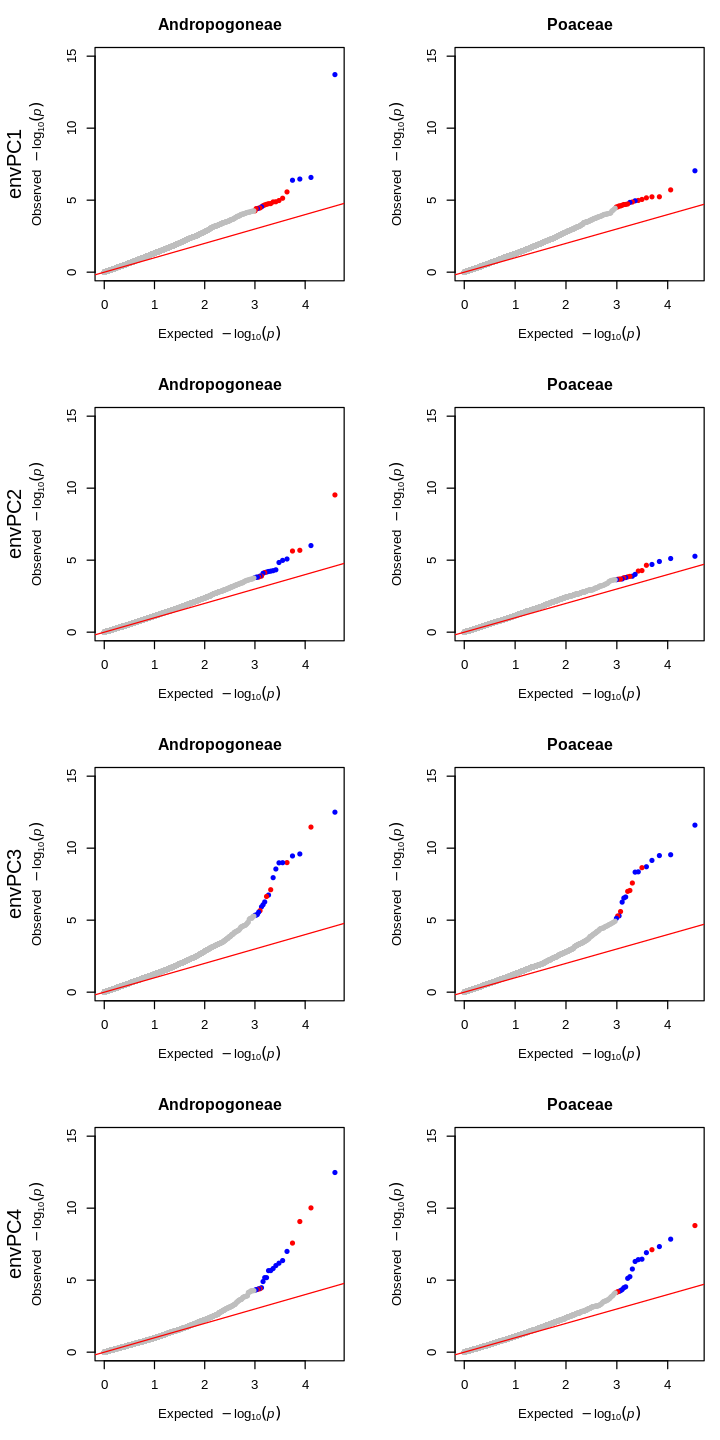

In [279]:
options(repr.plot.width=6, repr.plot.height=12)
par(mfrow = c(4,2),mar = c(5,6,3,1))
for (i in 1:4){
    tmpCutoff = quantile(-log10(as.numeric(testRes_zs_andro[,i+11])),.999,na.rm = T)
    tmpCol = rep("grey",nrow(testRes_zs_andro))
    tmpCol[as.numeric(testRes_zs_andro[,i+1])>0& -log10(as.numeric(testRes_zs_andro[,i+11]))>tmpCutoff] = "red"
    tmpCol[as.numeric(testRes_zs_andro[,i+1])<0& -log10(as.numeric(testRes_zs_andro[,i+11]))>tmpCutoff] = "blue"
    qq(as.numeric(testRes_zs_andro[,i+11]),main = "Andropogoneae",ylim = c(0,15),
       col = tmpCol[order(as.numeric(testRes_zs_andro[,i+11]))])
    mtext(paste0("envPC",i),2,line = 4.5)
    tmpCutoff = quantile(-log10(as.numeric(testRes_zs_out[,i+11])),.999,na.rm = T)
    tmpCol = rep("grey",nrow(testRes_zs_out))
    tmpCol[as.numeric(testRes_zs_out[,i+1])>0& -log10(as.numeric(testRes_zs_out[,i+11]))>tmpCutoff] = "red"
    tmpCol[as.numeric(testRes_zs_out[,i+1])<0& -log10(as.numeric(testRes_zs_out[,i+11]))>tmpCutoff] = "blue"
    qq(as.numeric(testRes_zs_out[,i+11]),main = "Poaceae",ylim = c(0,15),
       col = tmpCol[order(as.numeric(testRes_zs_out[,i+11]))])
}


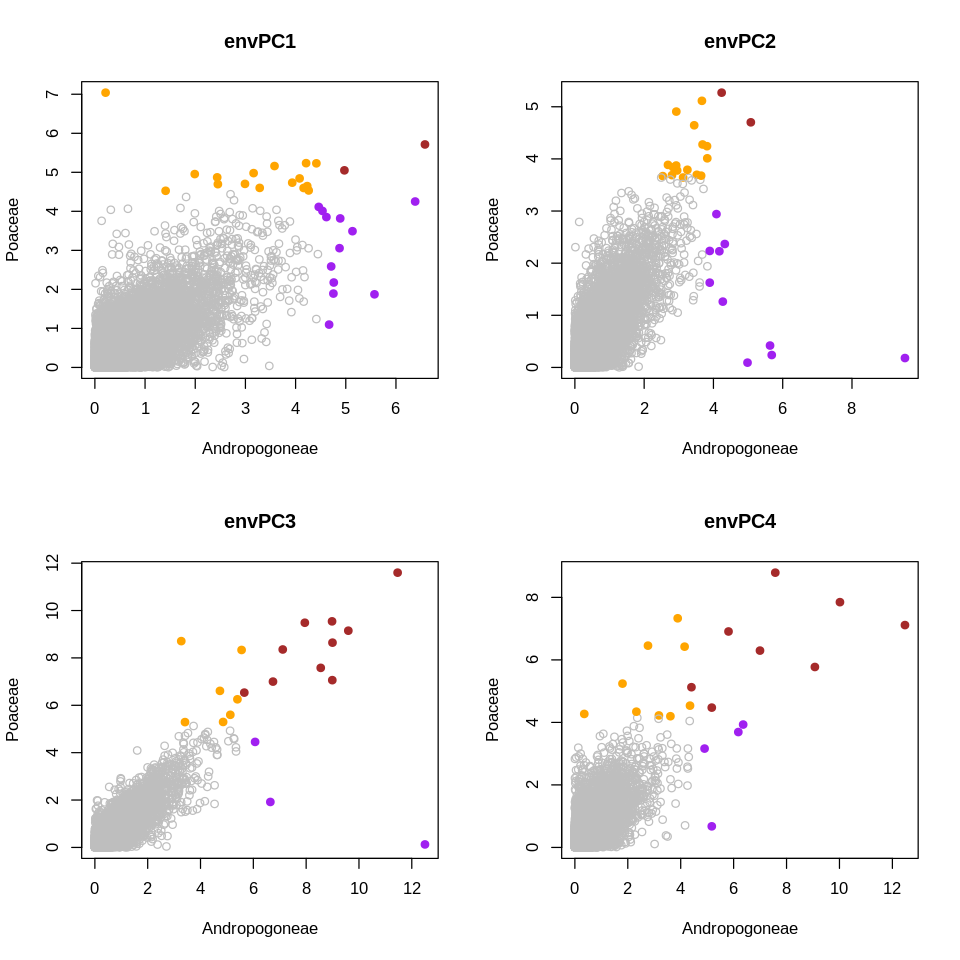

In [280]:
options(repr.plot.width=8, repr.plot.height=8)
par(mfrow = c(2,2))
for (i in 1:4){
    compDF = merge(testRes_zs_andro[,c(1,i+1,i+11)],testRes_zs_out[,c(1,i+1,i+11)],by = "OG")

    for (j in 2:5){
        compDF[,j] = as.numeric(compDF[,j])
    }


    tmpCutoff1 = quantile(-log10(as.numeric(testRes_zs_andro[,i+11])),.999,na.rm = T)
    tmpCutoff2 = quantile(-log10(as.numeric(testRes_zs_out[,i+11])),.999,na.rm = T)

    mycol = rep("grey",nrow(compDF))
    mycol[-log10(compDF[,3])<tmpCutoff1&-log10(compDF[,5])>tmpCutoff2] = "orange"
    mycol[-log10(compDF[,3])>tmpCutoff1&-log10(compDF[,5])<tmpCutoff2] = "purple"
    mycol[-log10(compDF[,3])>tmpCutoff1&-log10(compDF[,5])>tmpCutoff2] = "brown"

    plot(-log10(compDF[,c(3,5)]),col = mycol,xlab = "Andropogoneae",ylab = "Poaceae",main = paste0("envPC",i),
         pch = ifelse(-log10(compDF[,3])>tmpCutoff1|-log10(compDF[,5])>tmpCutoff2,19,1))
#     plot(compDF[,c(2,4)],col = mycol,xlab = "Andropogoneae",ylab = "Poaceae",main = paste0("envPC",i),
#          pch = ifelse(-log10(compDF[,3])>tmpCutoff1|-log10(compDF[,5])>tmpCutoff2,19,1))
}


# enrichment of RAOs

In [158]:
RAO = read.table("/workdir/sh2246/p_phyloGWAS/output/Yeaman2024RAO_OGID.txt")

In [159]:
length(unique(RAO[,2]))

[1] 185

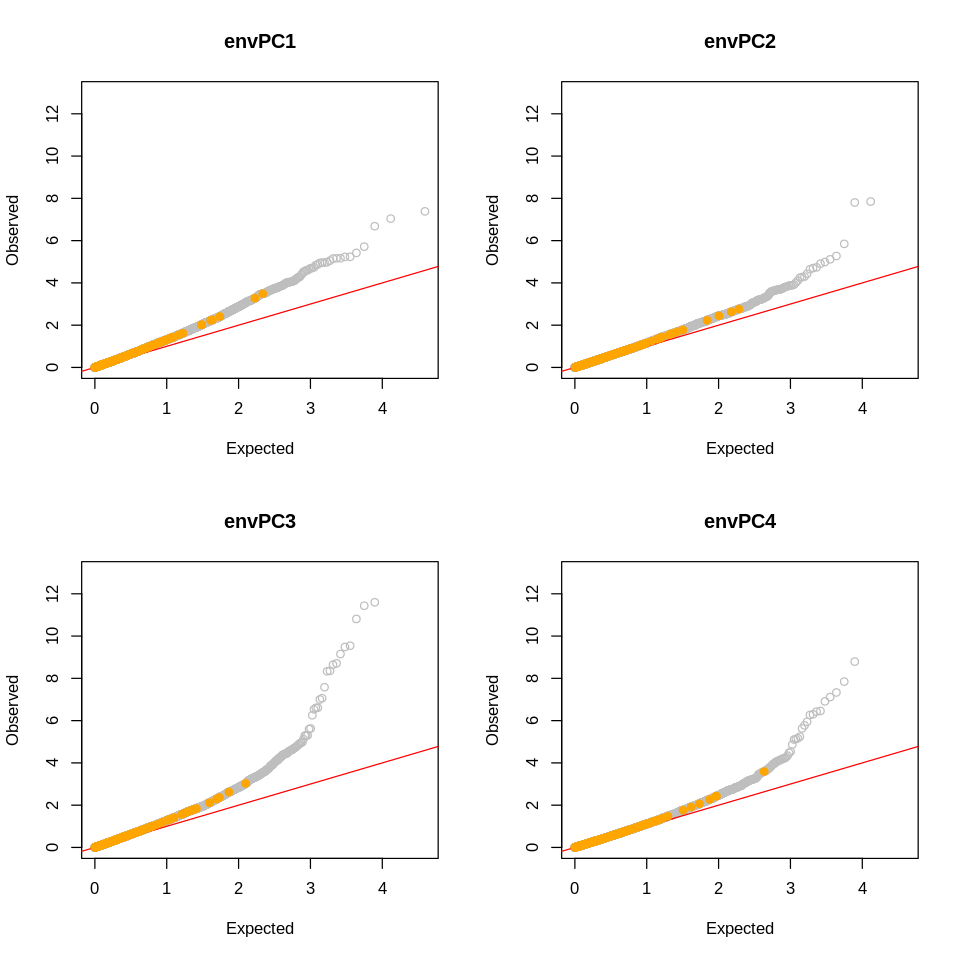

In [281]:
options(repr.plot.width=8, repr.plot.height=8)
par(mfrow= c(2,2))
for(i in 1:4){   
    exptd = -log10(ppoints(nrow(testRes_zs)))
    plot(exptd,sort(-log10(testRes_zs[,i+11]),decreasing = T),
         xlab = "Expected",ylab ="Observed",col ="grey",main = paste0("envPC",i),ylim = c(0,13))
    abline(a = 0, b=1,col = "red")
    points(exptd[testRes_zs$OG[order(testRes_zs[,i+11])]%in%RAO[,2]],
           sort(-log10(testRes_zs[testRes_zs$OG%in%RAO[,2],i+11]),decreasing = T),
           col ="orange",pch = 19)
}

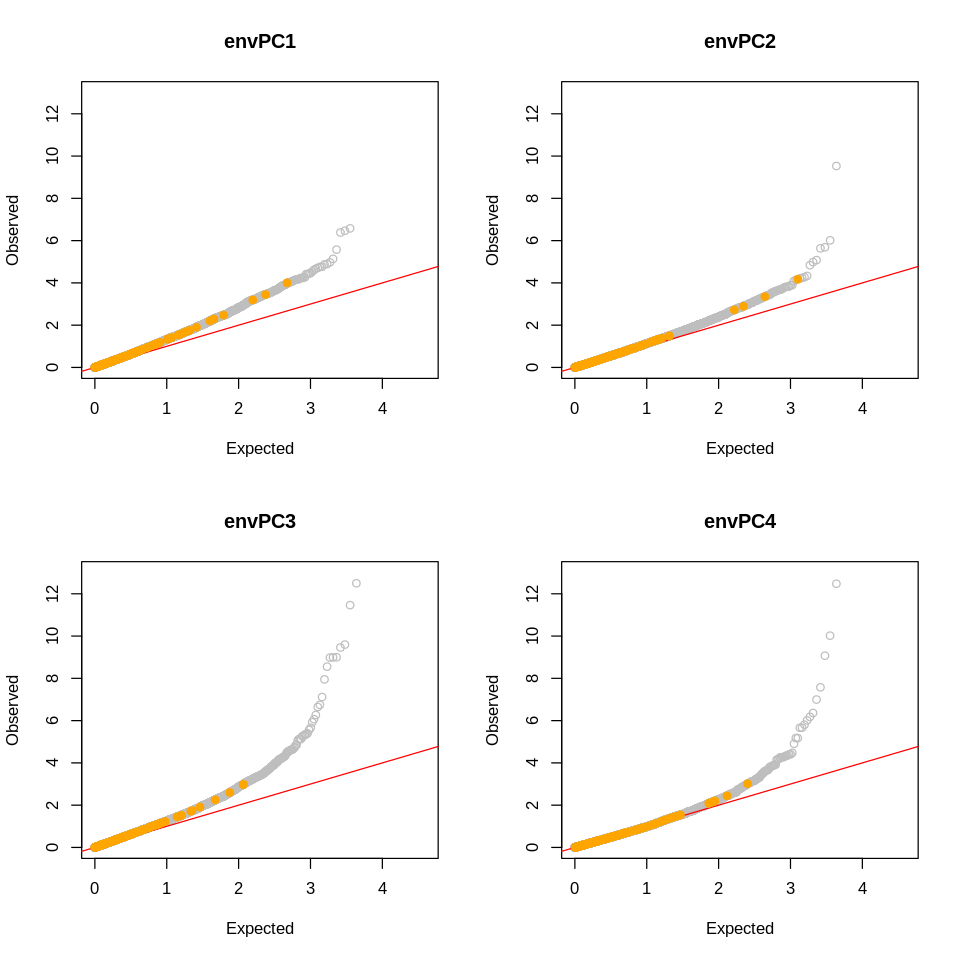

In [282]:
options(repr.plot.width=8, repr.plot.height=8)
par(mfrow= c(2,2))
for(i in 1:4){   
    exptd = -log10(ppoints(nrow(testRes_zs_andro)))
    plot(exptd,sort(-log10(as.numeric(testRes_zs_andro[,i+11])),decreasing = T),
         xlab = "Expected",ylab ="Observed",col ="grey",main = paste0("envPC",i),ylim = c(0,13))
    abline(a = 0, b=1,col = "red")
    points(exptd[testRes_zs_andro$OG[order(as.numeric(testRes_zs_andro[,i+11]))]%in%RAO[,2]],
           sort(-log10(as.numeric(testRes_zs_andro[testRes_zs_andro$OG%in%RAO[,2],i+11])),decreasing = T),
           col ="orange",pch = 19)
}

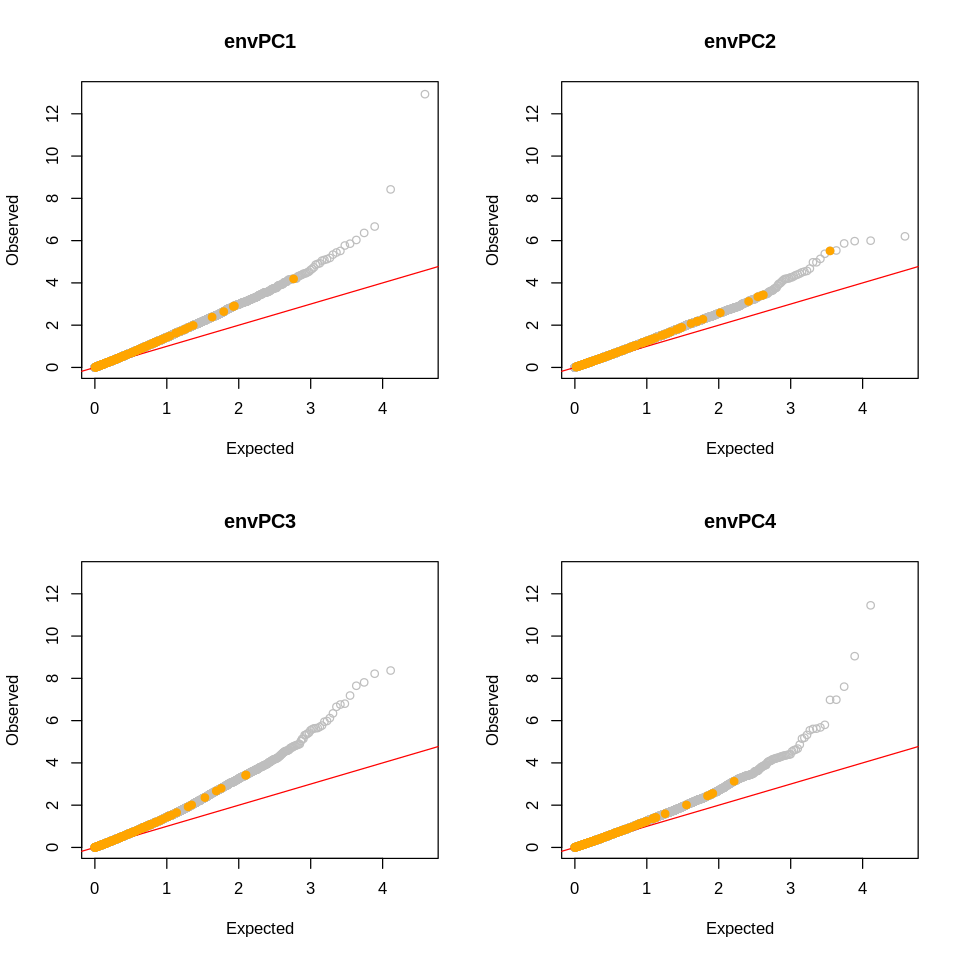

In [439]:
options(repr.plot.width=8, repr.plot.height=8)
par(mfrow= c(2,2))
for(i in 1:4){   
    exptd = -log10(ppoints(nrow(testRes_zs_dna)))
    plot(exptd,sort(-log10(testRes_zs_dna[,i+11]),decreasing = T),
         xlab = "Expected",ylab ="Observed",col ="grey",main = paste0("envPC",i),ylim = c(0,13))
    abline(a = 0, b=1,col = "red")
    points(exptd[testRes_zs_dna$OG[order(testRes_zs_dna[,i+11])]%in%RAO[,2]],
           sort(-log10(testRes_zs_dna[testRes_zs_dna$OG%in%RAO[,2],i+11]),decreasing = T),
           col ="orange",pch = 19)
}

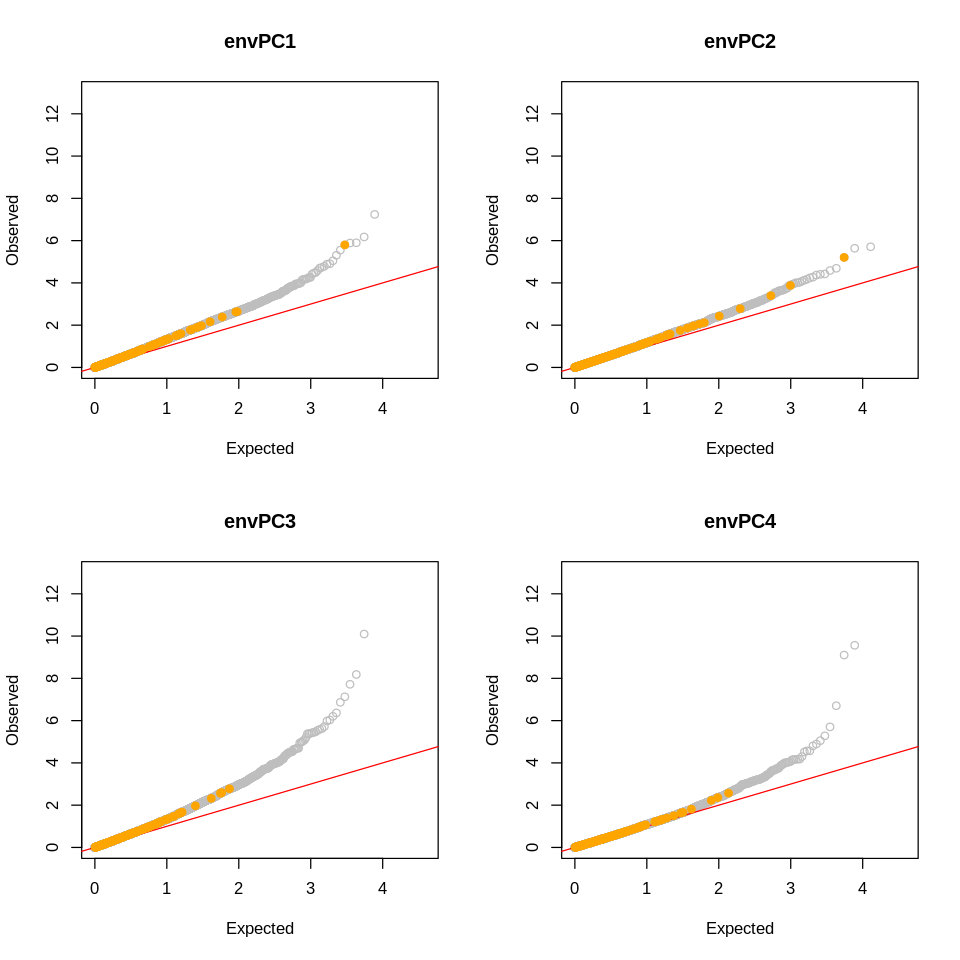

In [444]:
options(repr.plot.width=8, repr.plot.height=8)
par(mfrow= c(2,2))
for(i in 1:4){   
    exptd = -log10(ppoints(nrow(testRes_zs_dna_andro)))
    plot(exptd,sort(-log10(as.numeric(testRes_zs_dna_andro[,i+11])),decreasing = T),
         xlab = "Expected",ylab ="Observed",col ="grey",main = paste0("envPC",i),ylim = c(0,13))
    abline(a = 0, b=1,col = "red")
    points(exptd[testRes_zs_dna_andro$OG[order(as.numeric(testRes_zs_dna_andro[,i+11]))]%in%RAO[,2]],
           sort(-log10(as.numeric(testRes_zs_dna_andro[testRes_zs_dna_andro$OG%in%RAO[,2],i+11])),decreasing = T),
           col ="orange",pch = 19)
}

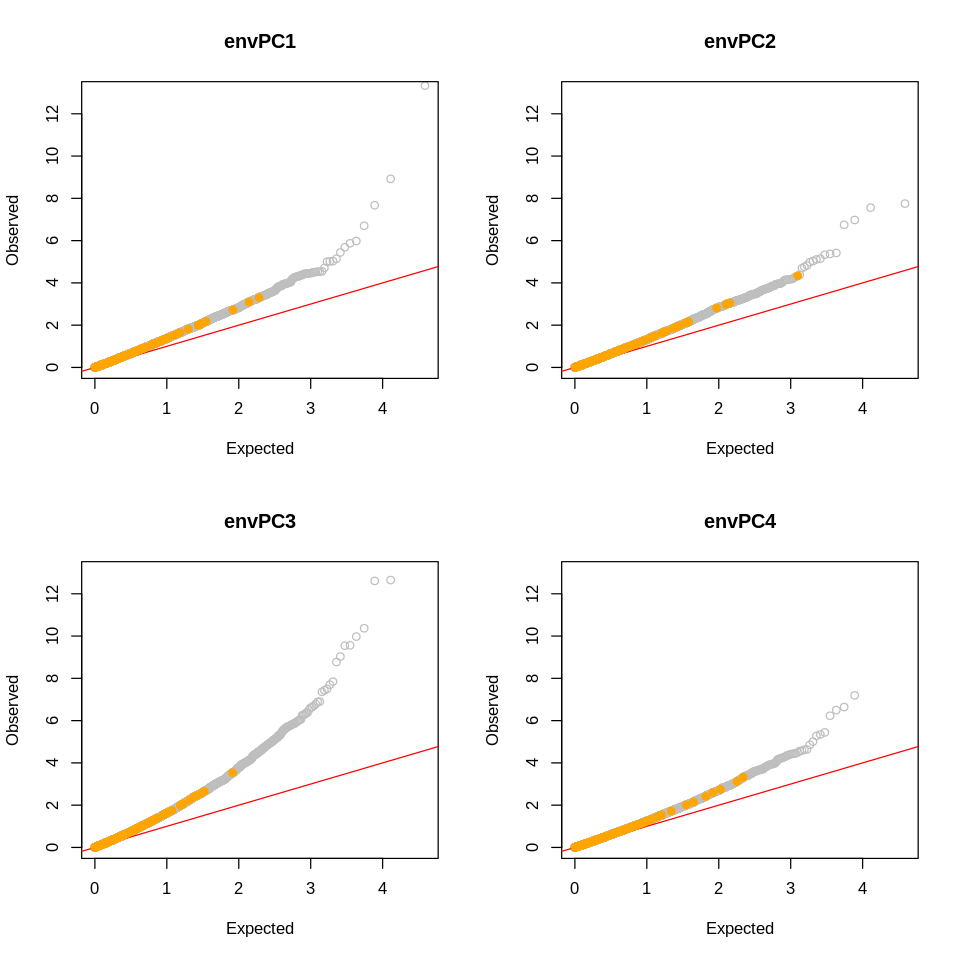

In [787]:
options(repr.plot.width=8, repr.plot.height=8)
par(mfrow= c(2,2))
for(i in 1:4){   
    exptd = -log10(ppoints(nrow(testRes_multiVar)))
    plot(exptd,sort(-log10(as.numeric(testRes_multiVar[,i+11])),decreasing = T),
         xlab = "Expected",ylab ="Observed",col ="grey",main = paste0("envPC",i),ylim = c(0,13))
    abline(a = 0, b=1,col = "red")
    points(exptd[testRes_multiVar$OG[order(as.numeric(testRes_multiVar[,i+11]))]%in%RAO[,2]],
           sort(-log10(as.numeric(testRes_multiVar[testRes_multiVar$OG%in%RAO[,2],i+11])),decreasing = T),
           col ="orange",pch = 19)
}

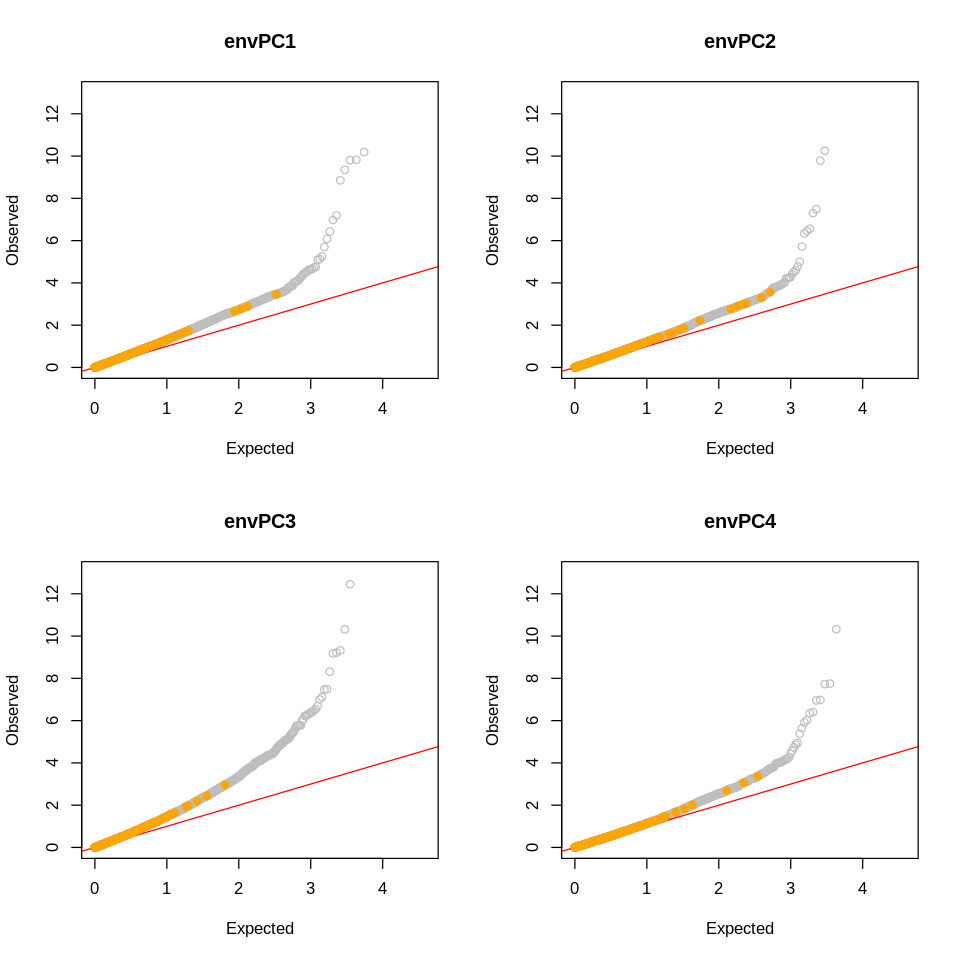

In [788]:
options(repr.plot.width=8, repr.plot.height=8)
par(mfrow= c(2,2))
for(i in 1:4){   
    exptd = -log10(ppoints(nrow(testRes_multiVar_andro)))
    plot(exptd,sort(-log10(as.numeric(testRes_multiVar_andro[,i+11])),decreasing = T),
         xlab = "Expected",ylab ="Observed",col ="grey",main = paste0("envPC",i),ylim = c(0,13))
    abline(a = 0, b=1,col = "red")
    points(exptd[testRes_multiVar_andro$OG[order(as.numeric(testRes_multiVar_andro[,i+11]))]%in%RAO[,2]],
           sort(-log10(as.numeric(testRes_multiVar_andro[testRes_multiVar_andro$OG%in%RAO[,2],i+11])),decreasing = T),
           col ="orange",pch = 19)
}

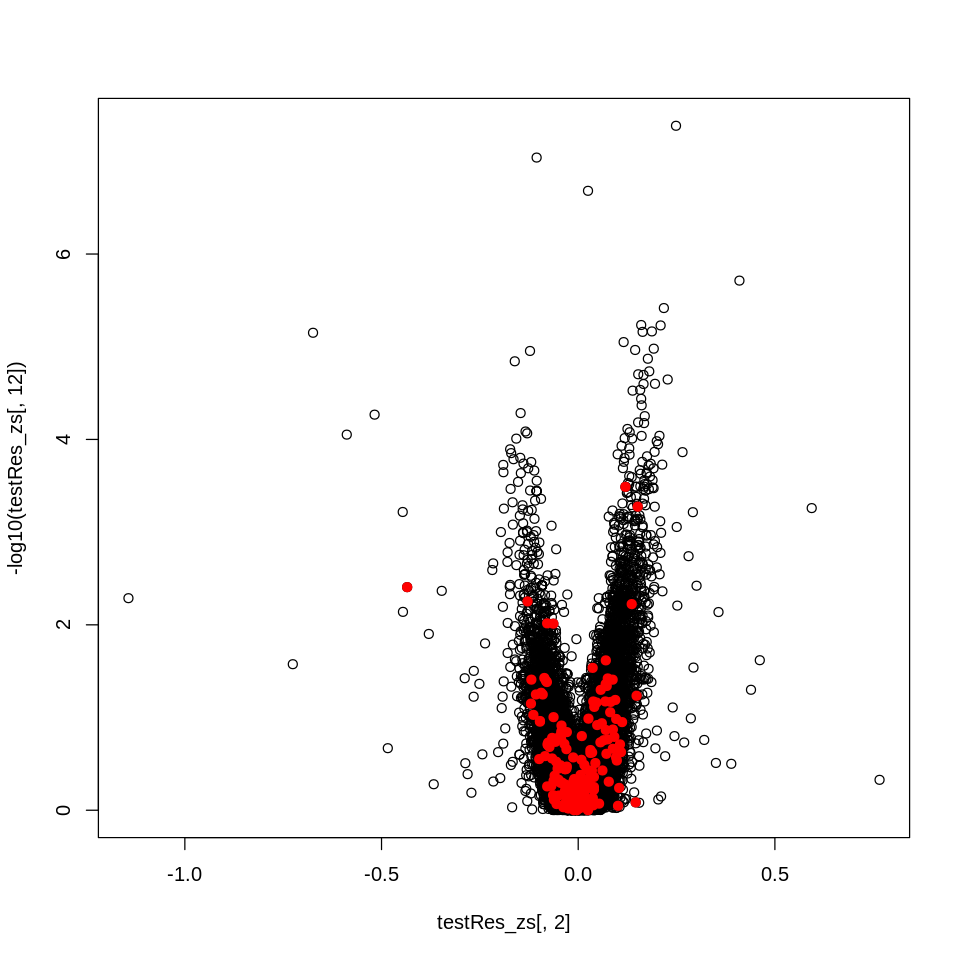

In [162]:
plot(testRes_zs[,2],-log10(testRes_zs[,12]))
points(testRes_zs[testRes_zs$OG%in%RAO[,2],2],-log10(testRes_zs[testRes_zs$OG%in%RAO[,2],12]),col = "red",pch =19)

In [174]:
library(PRROC)

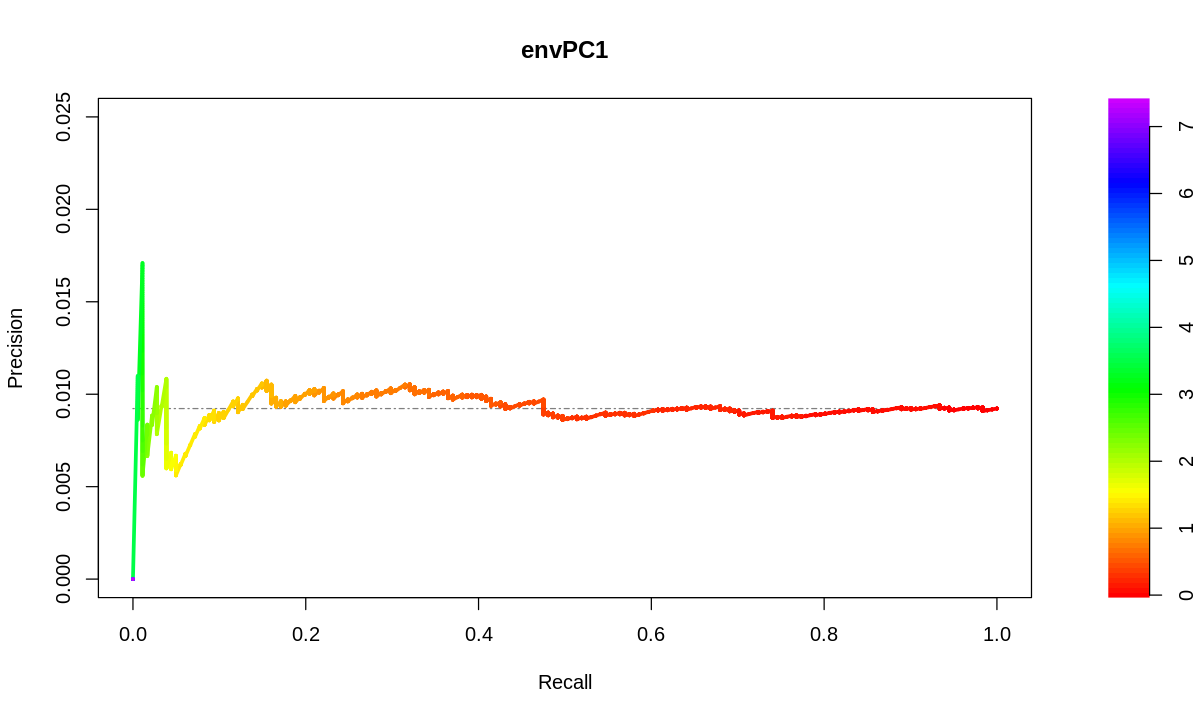

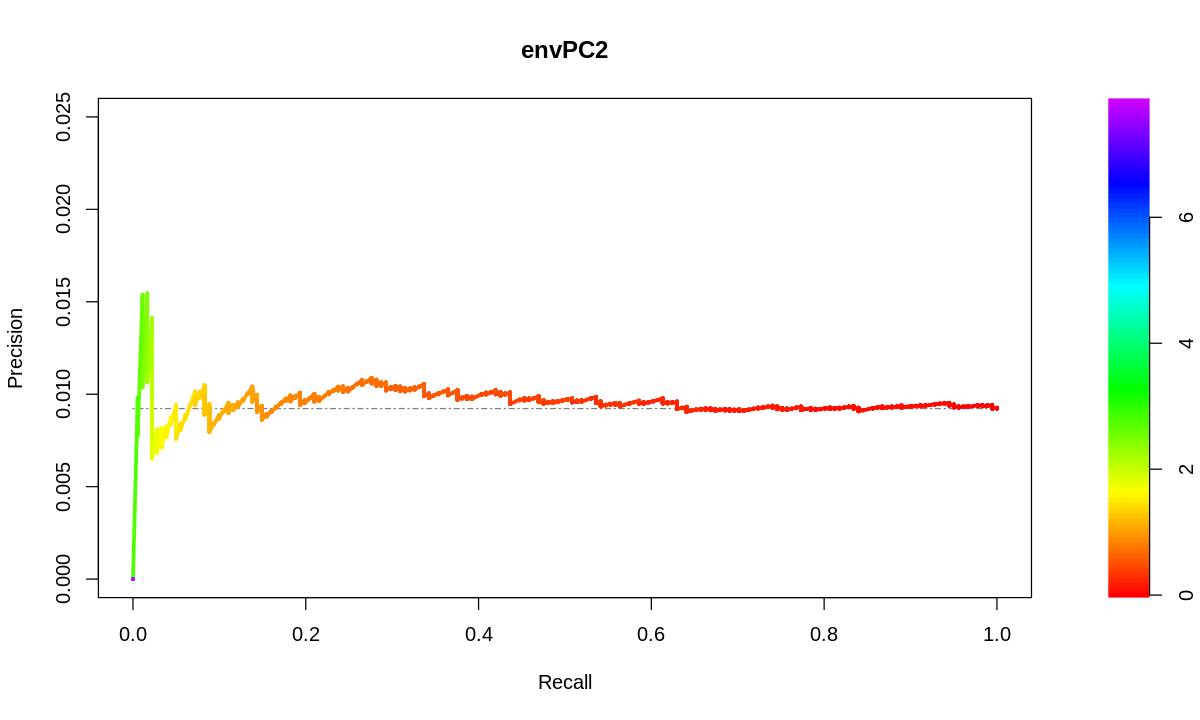

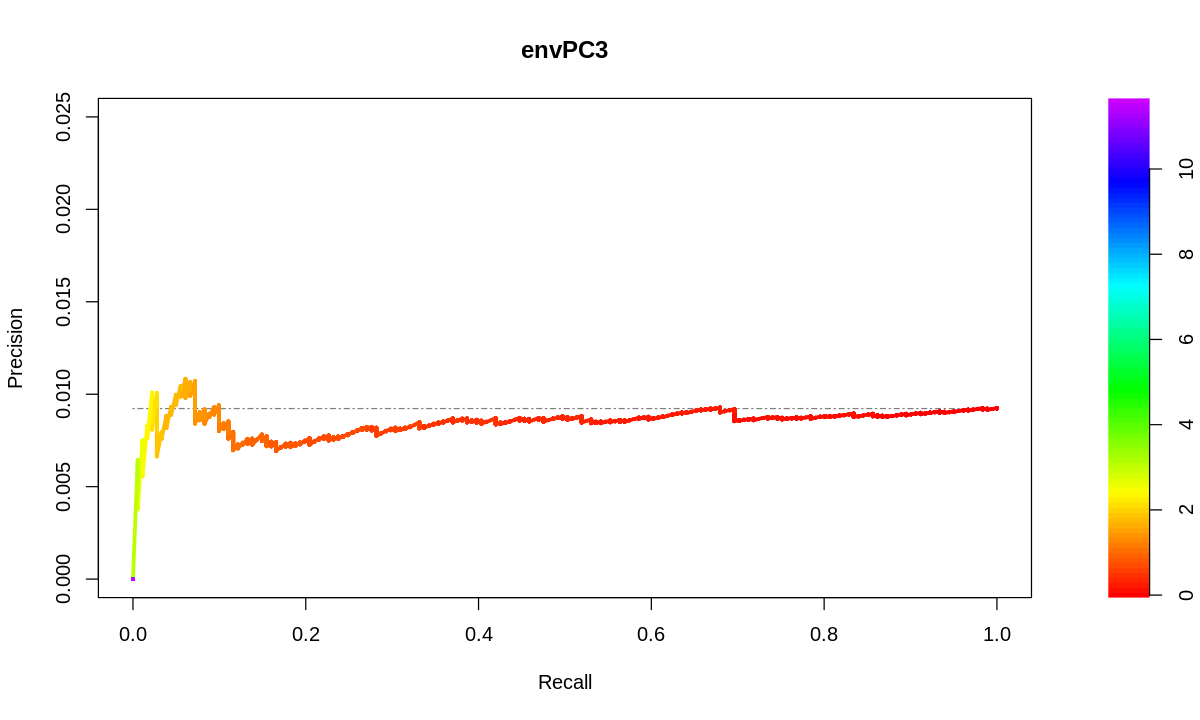

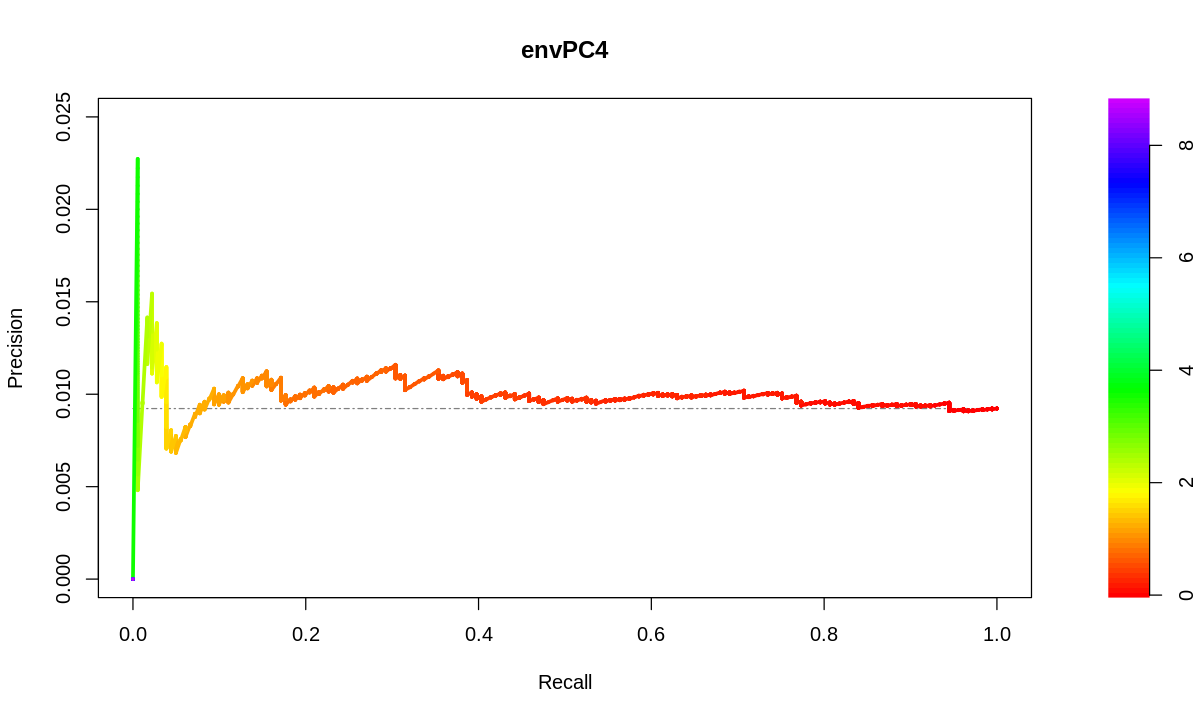

In [292]:
options(repr.plot.width=10, repr.plot.height=6)
for(i in 1:4){
    fg_RAO = -log10(testRes_zs[,i+11])[testRes_zs$OG%in%RAO[,2]]
    bg_RAO = -log10(testRes_zs[,i+11])[!testRes_zs$OG%in%RAO[,2]]

    pr_RAO = pr.curve(scores.class0 = fg_RAO, scores.class1 = bg_RAO[bg_RAO!=Inf], curve = T,rand.compute = T)
    roc_RAO = roc.curve(scores.class0 = fg_RAO, scores.class1 = bg_RAO[bg_RAO!=Inf], curve = T,rand.compute = T)

    plot(pr_RAO,rand.plot = T,ylim = c(0,0.025),auc.main =F,main = paste0("envPC",i))

}


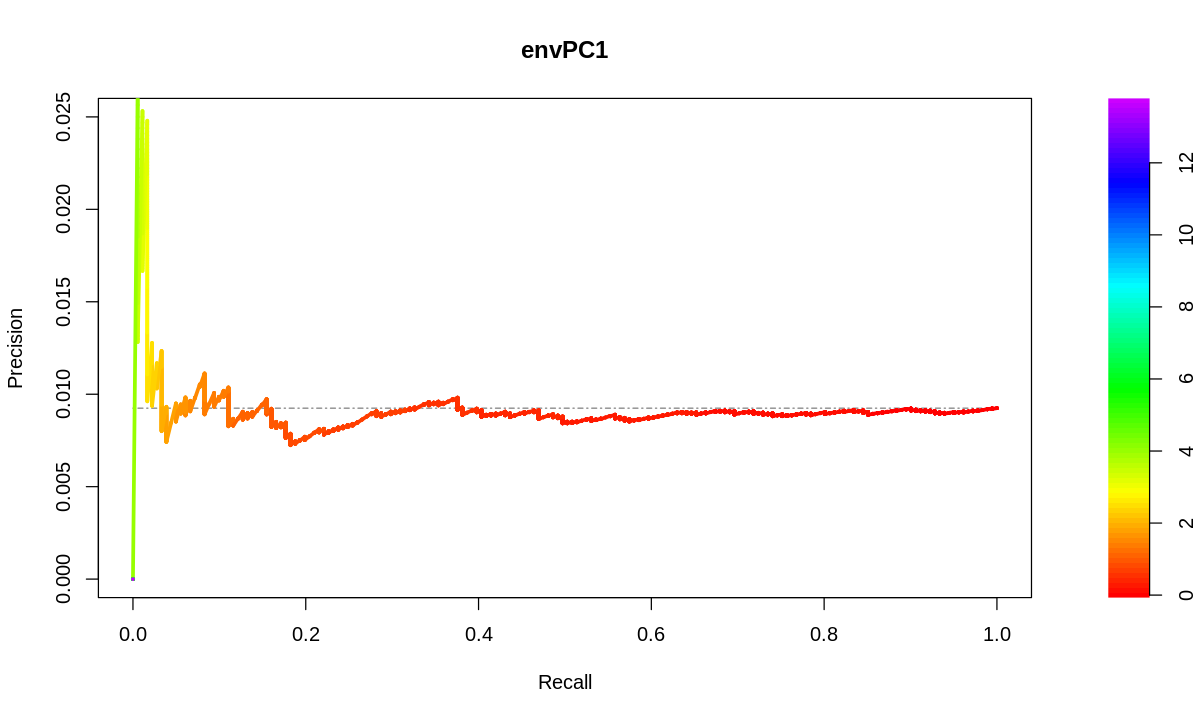

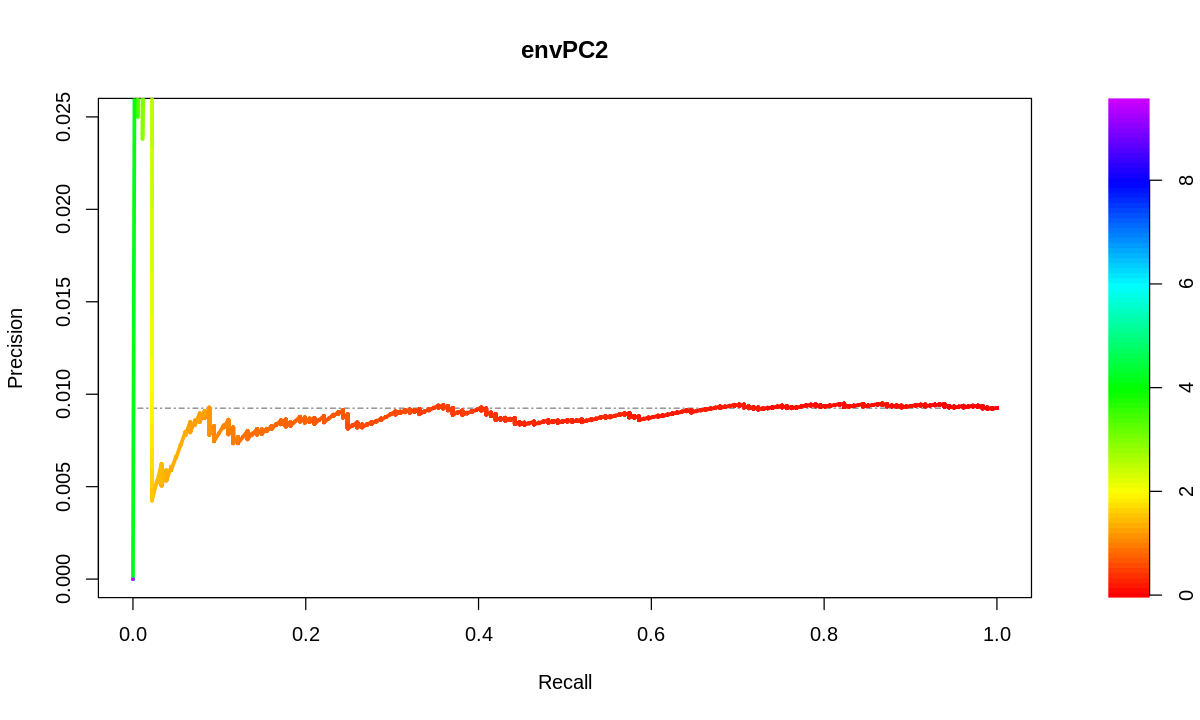

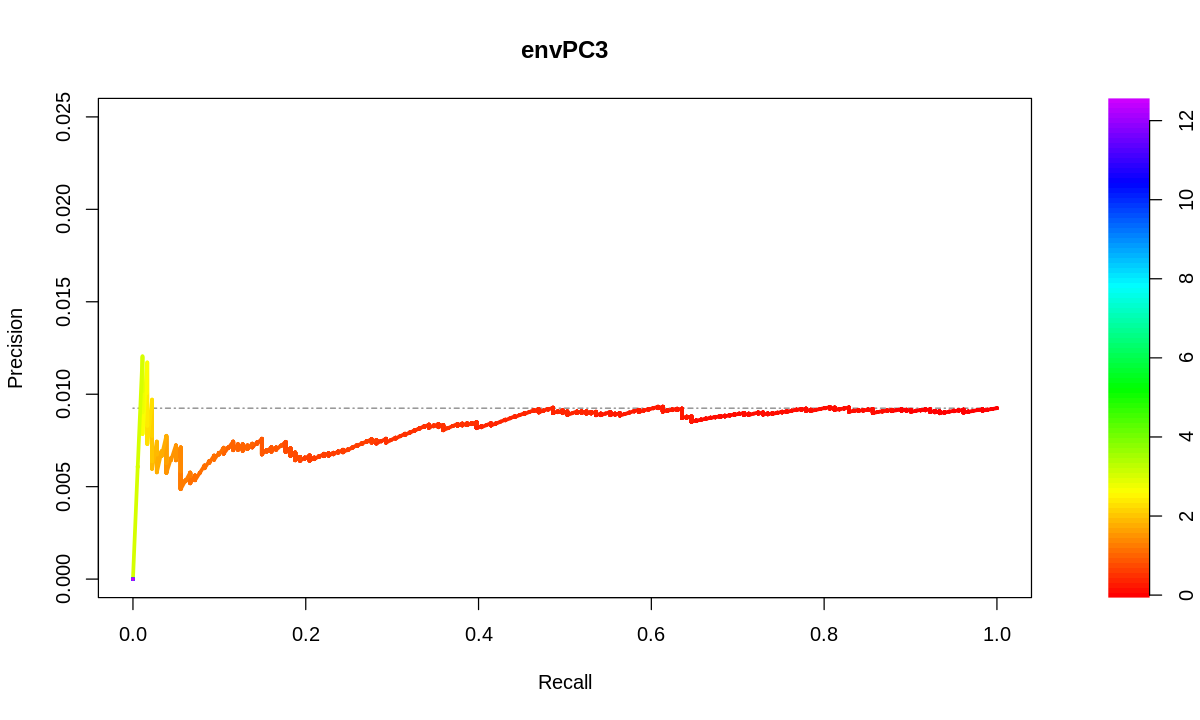

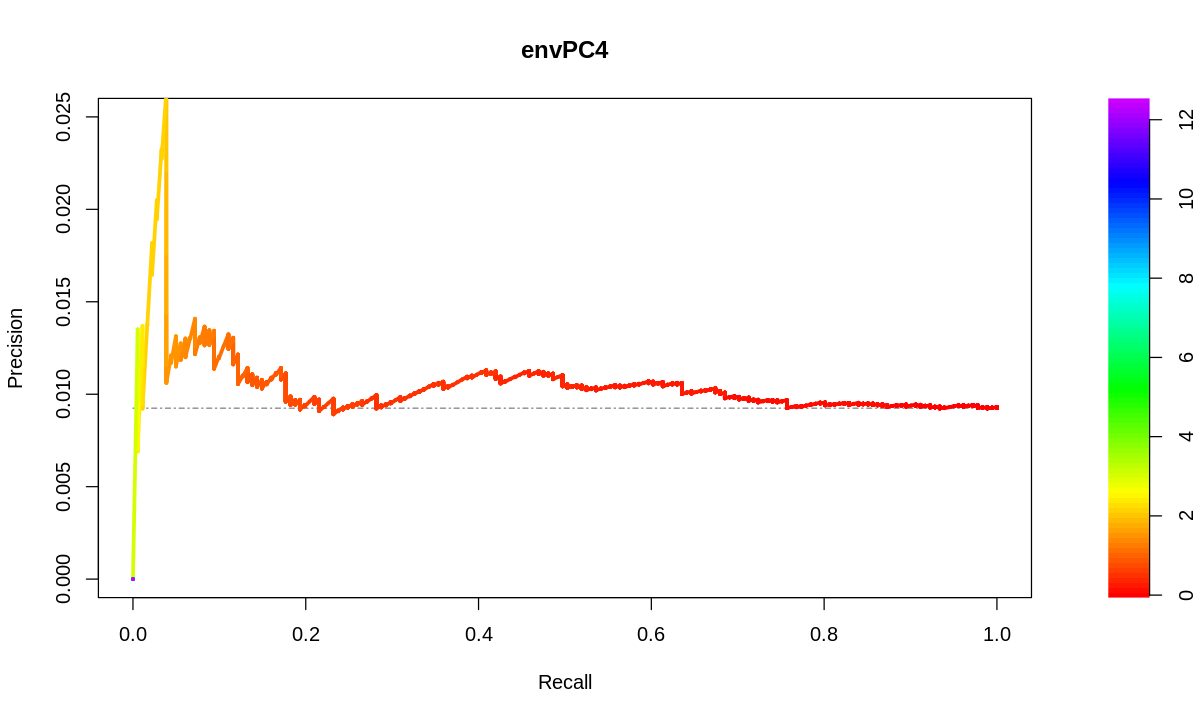

In [456]:
options(repr.plot.width=10, repr.plot.height=6)
for(i in 1:4){
    fg_RAO = -log10(as.numeric(testRes_zs_andro[,i+11]))[testRes_zs_andro$OG%in%RAO[,2]]
    bg_RAO = -log10(as.numeric(testRes_zs_andro[,i+11]))[!testRes_zs_andro$OG%in%RAO[,2]]

    pr_RAO = pr.curve(scores.class0 = fg_RAO, scores.class1 = bg_RAO[bg_RAO!=Inf], curve = T,rand.compute = T)
    roc_RAO = roc.curve(scores.class0 = fg_RAO, scores.class1 = bg_RAO[bg_RAO!=Inf], curve = T,rand.compute = T)

    plot(pr_RAO,rand.plot = T,ylim = c(0,0.025),auc.main =F,main = paste0("envPC",i))

}


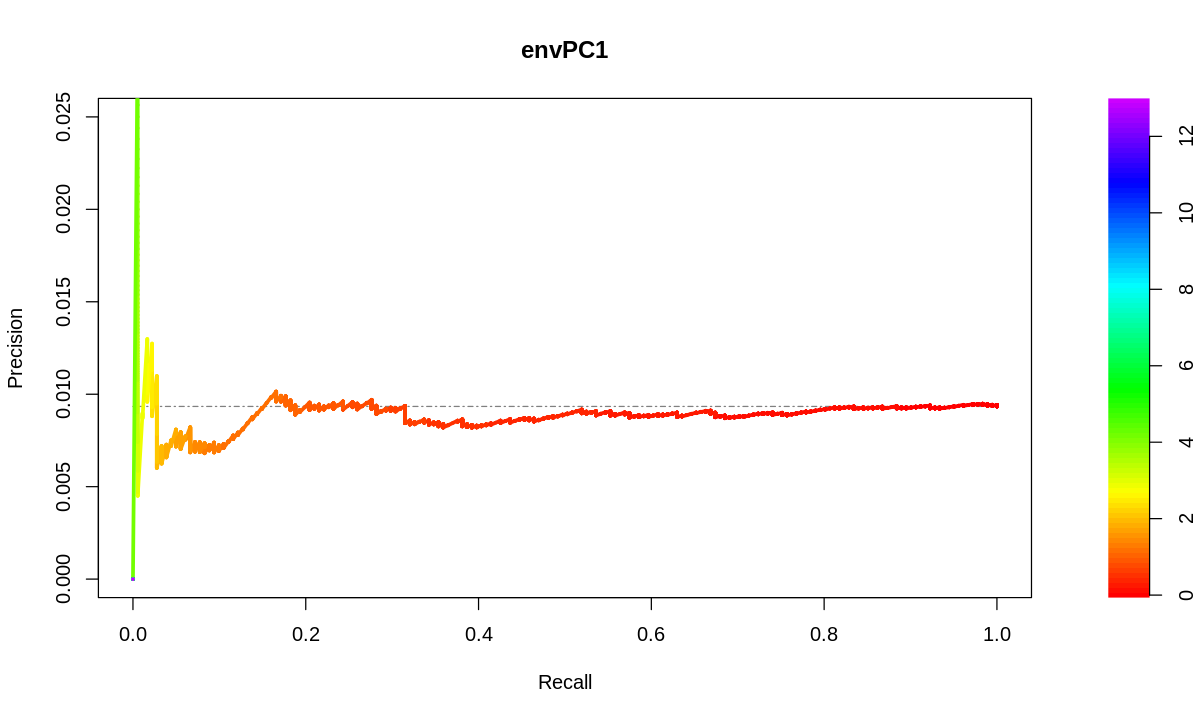

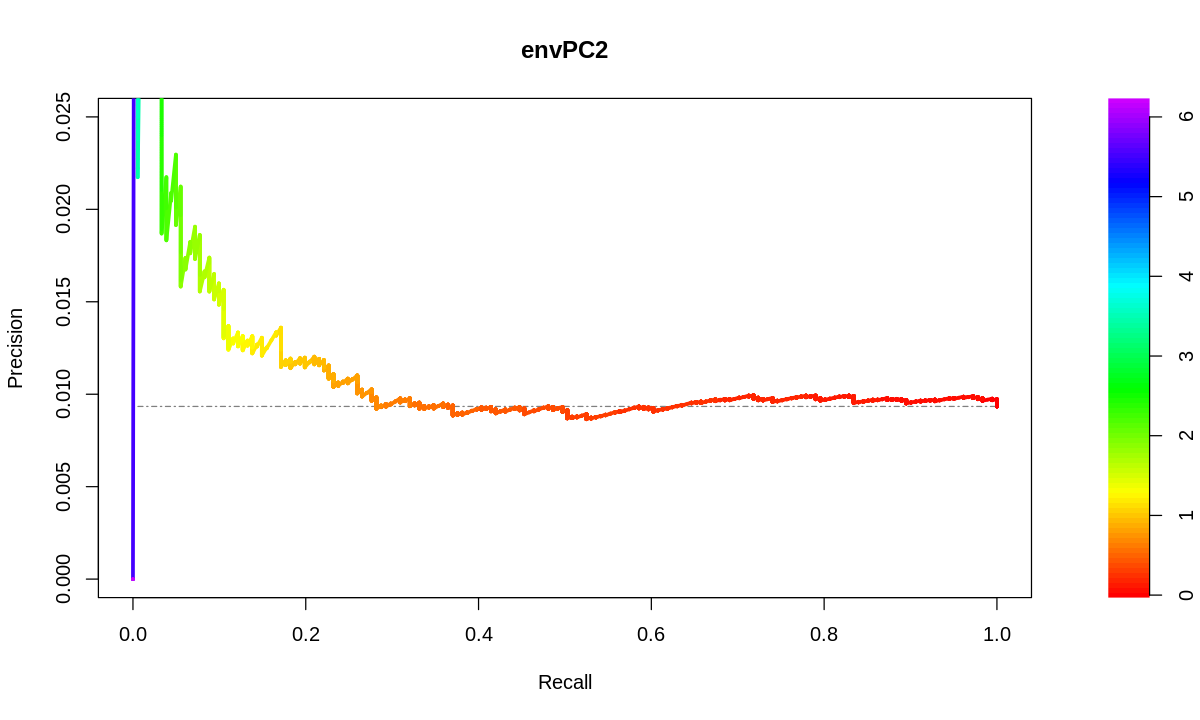

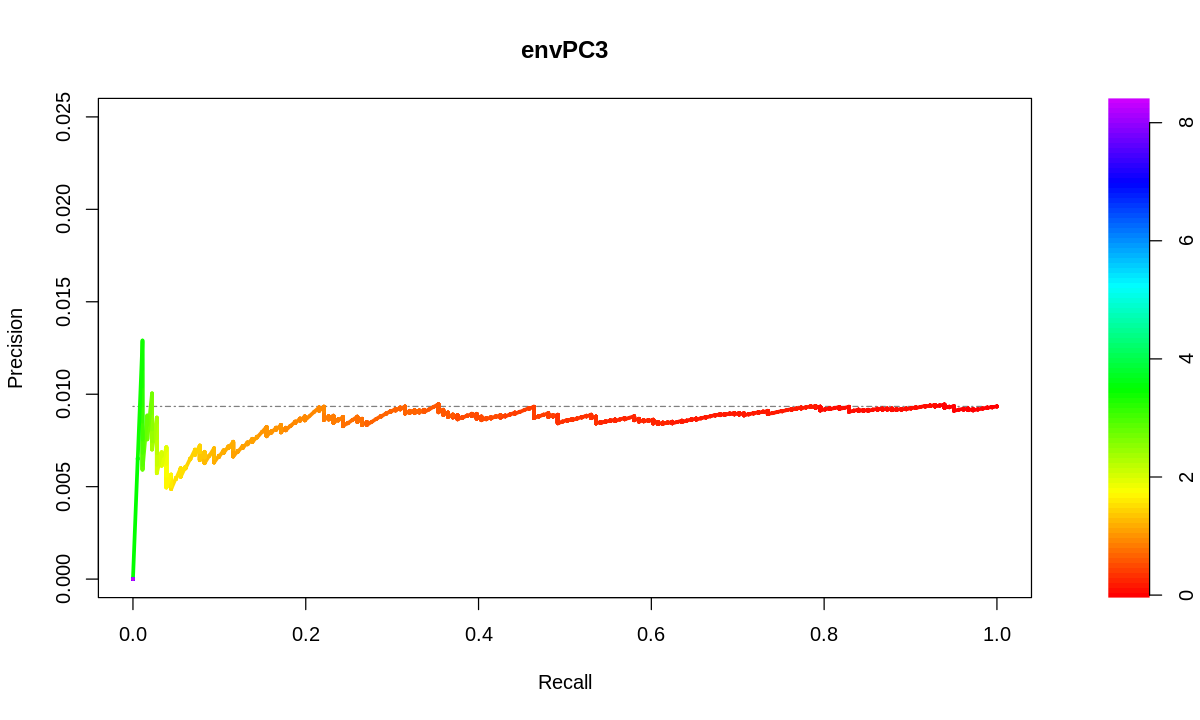

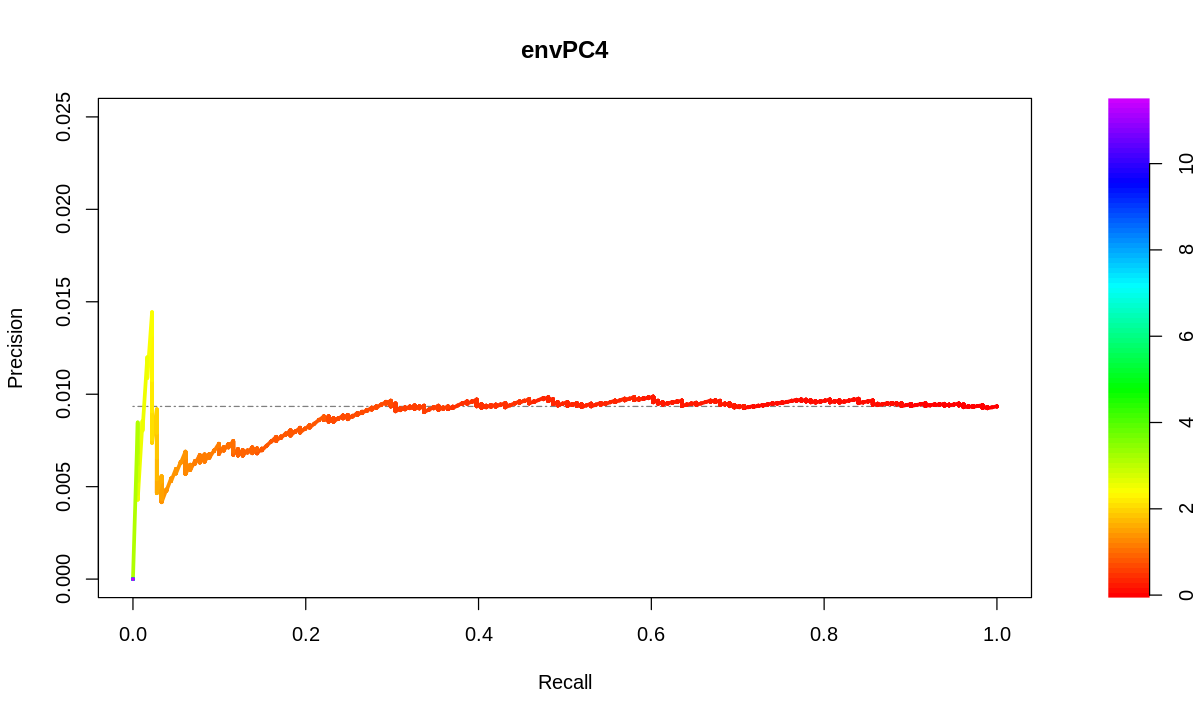

In [457]:
options(repr.plot.width=10, repr.plot.height=6)
for(i in 1:4){
    fg_RAO = -log10(as.numeric(testRes_zs_dna[,i+11]))[testRes_zs_dna$OG%in%RAO[,2]]
    bg_RAO = -log10(as.numeric(testRes_zs_dna[,i+11]))[!testRes_zs_dna$OG%in%RAO[,2]]

    pr_RAO = pr.curve(scores.class0 = fg_RAO, scores.class1 = bg_RAO[bg_RAO!=Inf], curve = T,rand.compute = T)
    roc_RAO = roc.curve(scores.class0 = fg_RAO, scores.class1 = bg_RAO[bg_RAO!=Inf], curve = T,rand.compute = T)

    plot(pr_RAO,rand.plot = T,ylim = c(0,0.025),auc.main =F,main = paste0("envPC",i))

}


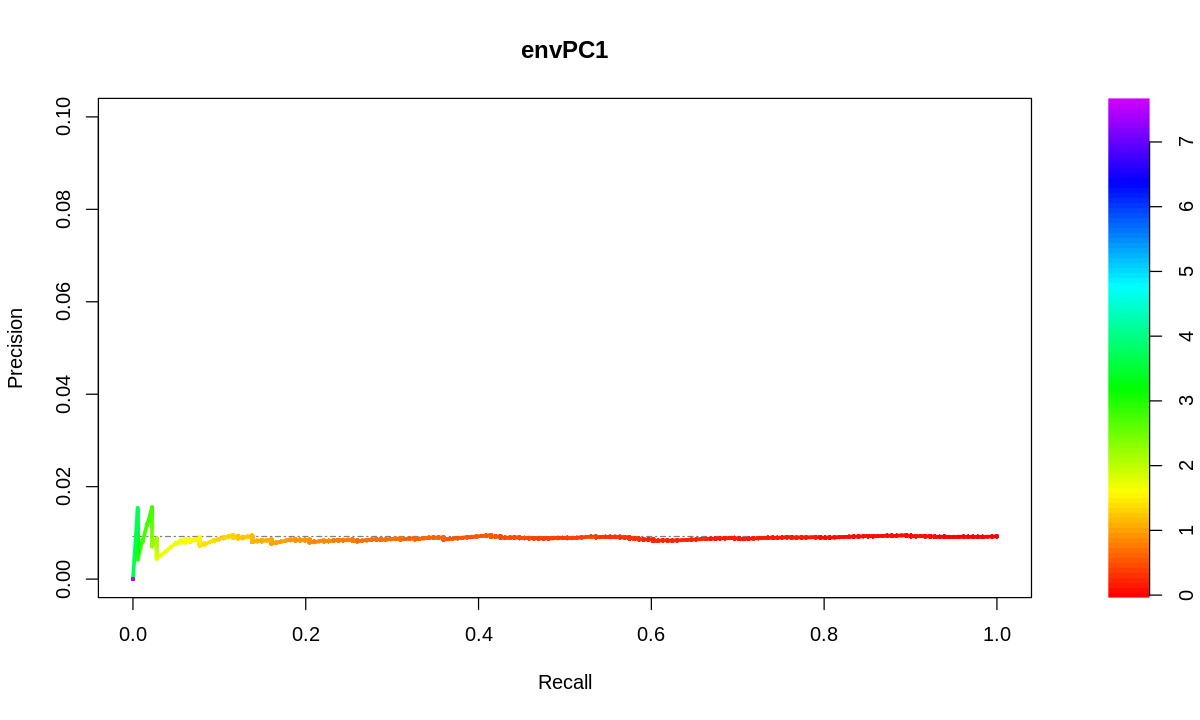

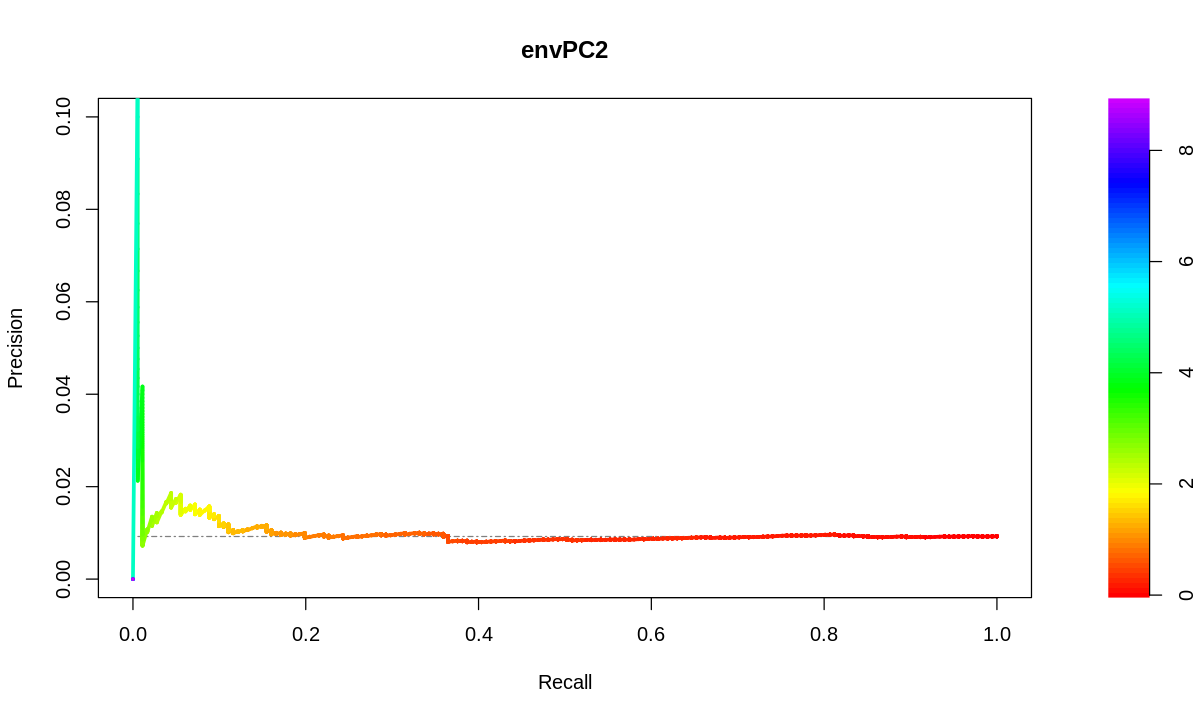

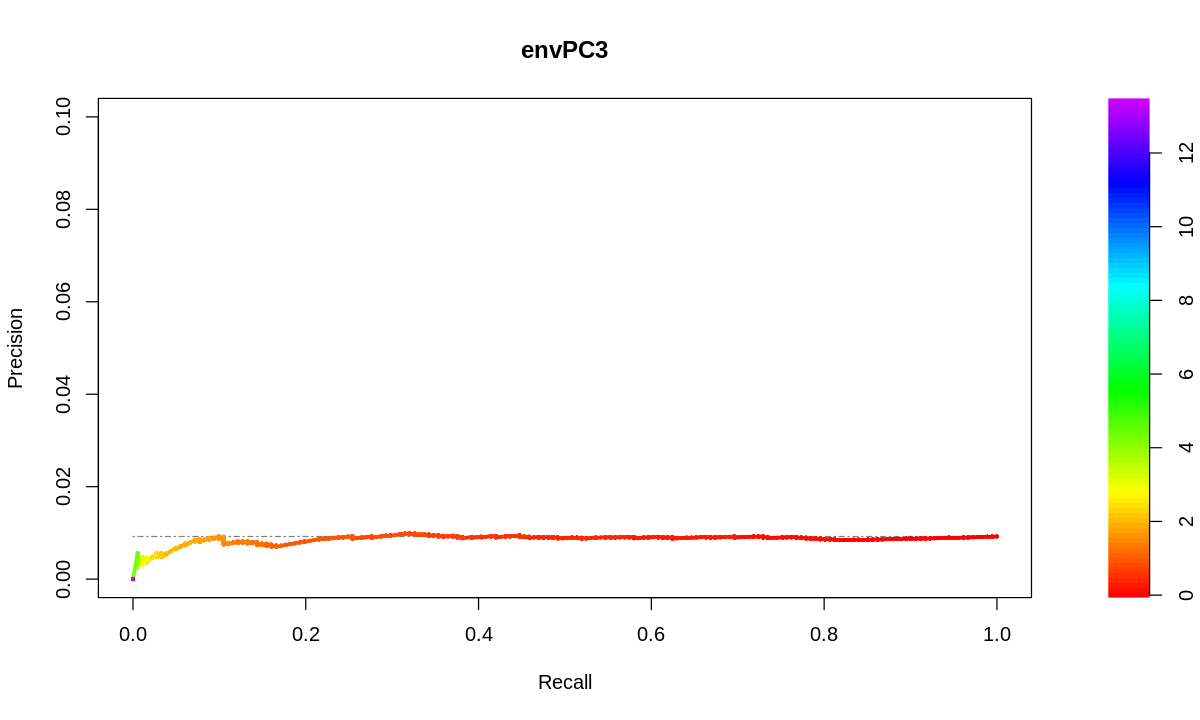

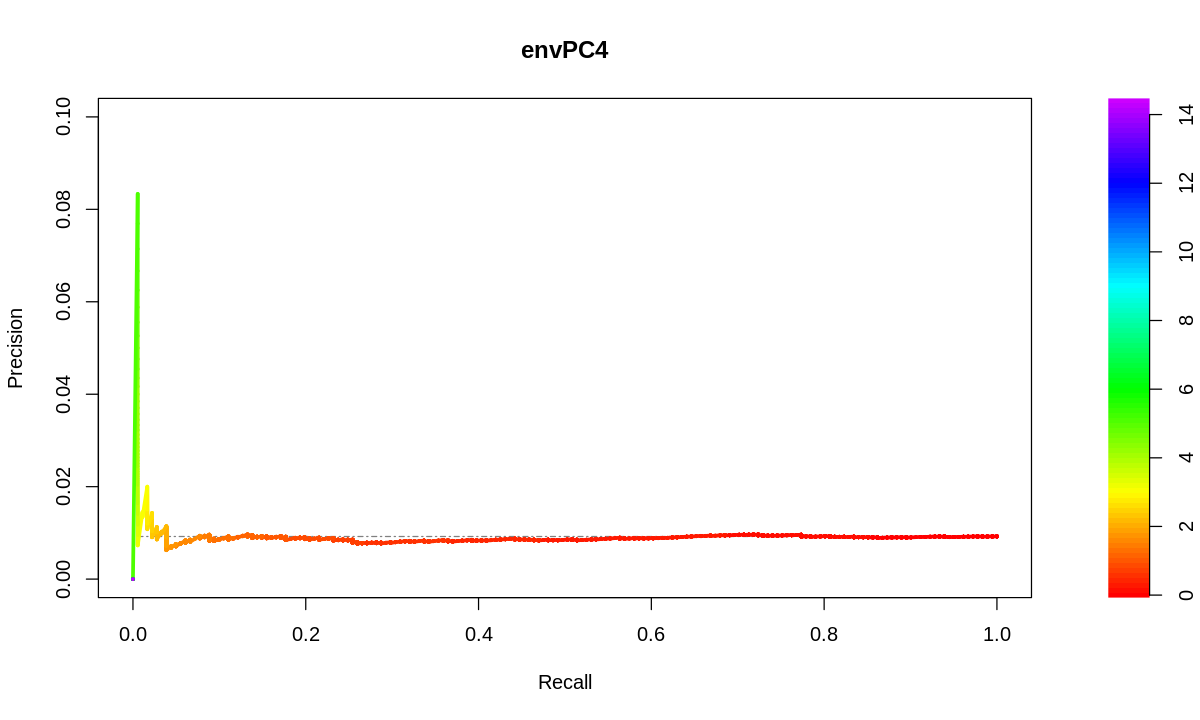

In [675]:
options(repr.plot.width=10, repr.plot.height=6)
for(i in 1:4){
    fg_RAO = -log10(as.numeric(testRes_dnds[,i+11]))[testRes_dnds$OG%in%RAO[,2]]
    bg_RAO = -log10(as.numeric(testRes_dnds[,i+11]))[!testRes_dnds$OG%in%RAO[,2]]

    pr_RAO = pr.curve(scores.class0 = fg_RAO, scores.class1 = bg_RAO[bg_RAO!=Inf], curve = T,rand.compute = T)
    roc_RAO = roc.curve(scores.class0 = fg_RAO, scores.class1 = bg_RAO[bg_RAO!=Inf], curve = T,rand.compute = T)

    plot(pr_RAO,rand.plot = T,ylim = c(0,0.1),auc.main =F,main = paste0("envPC",i))

}


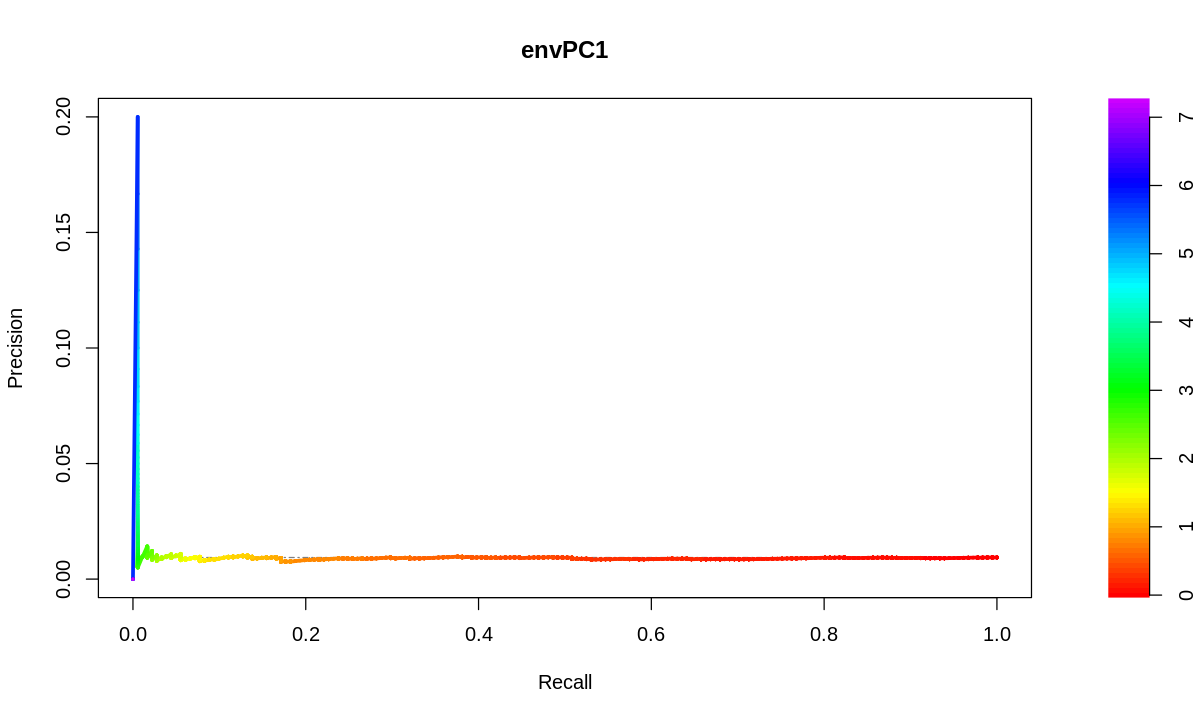

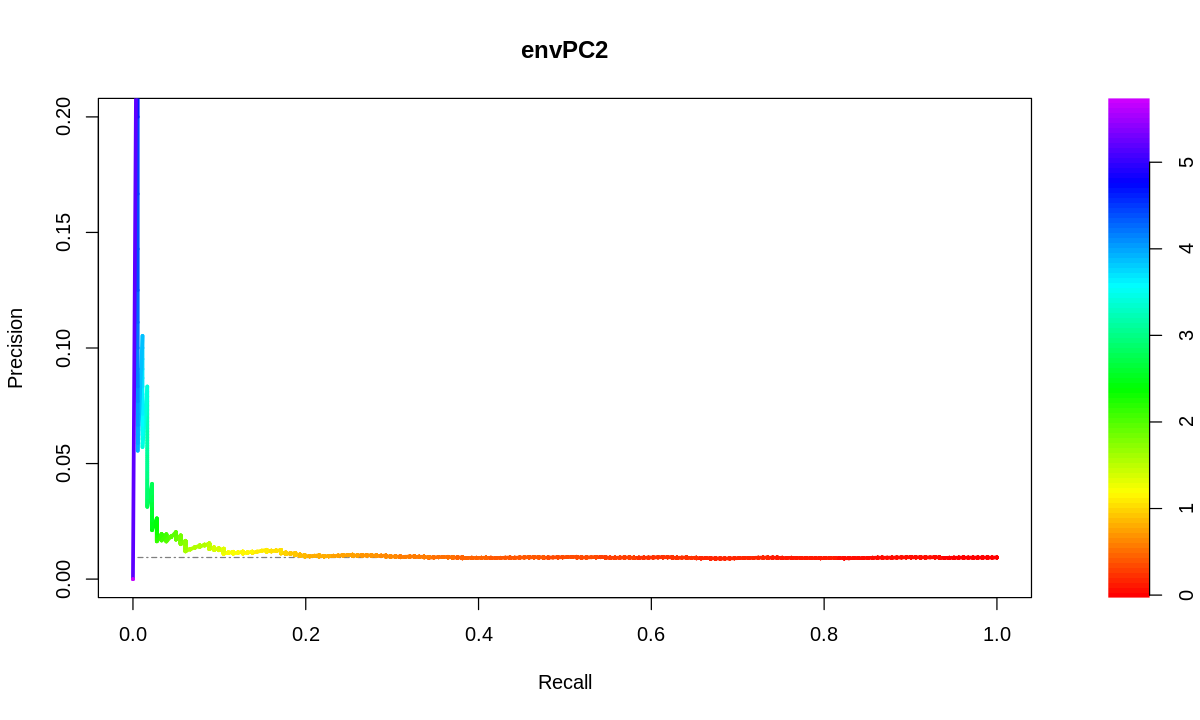

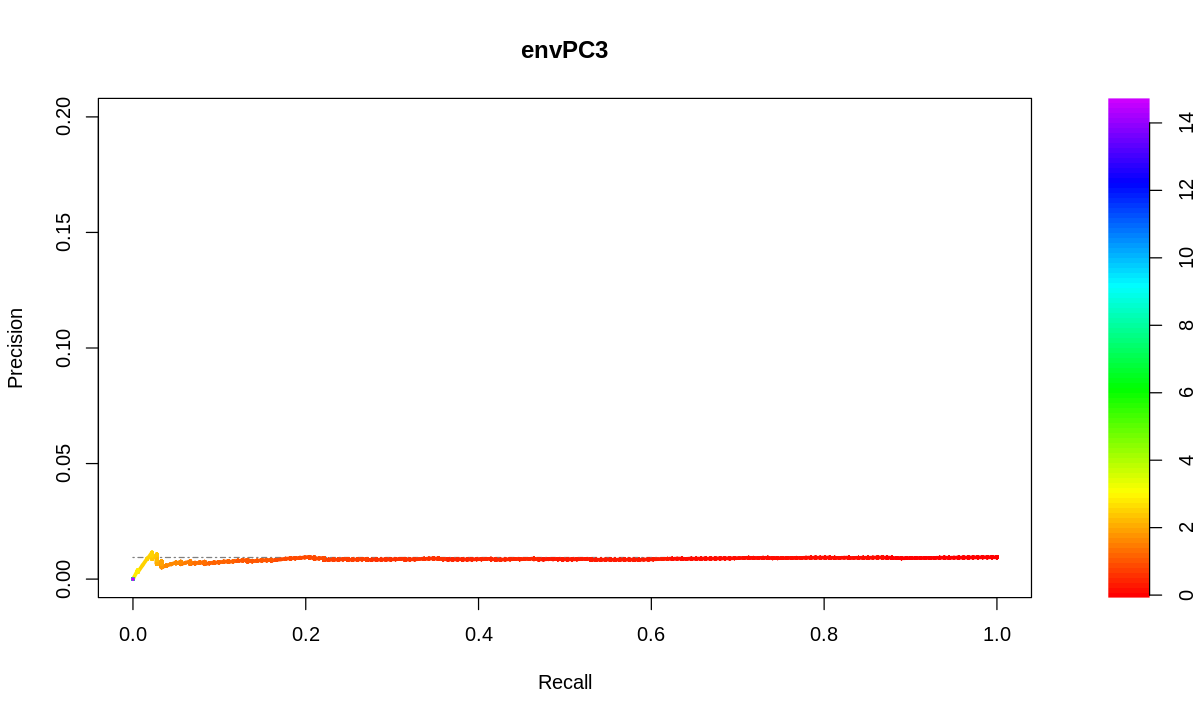

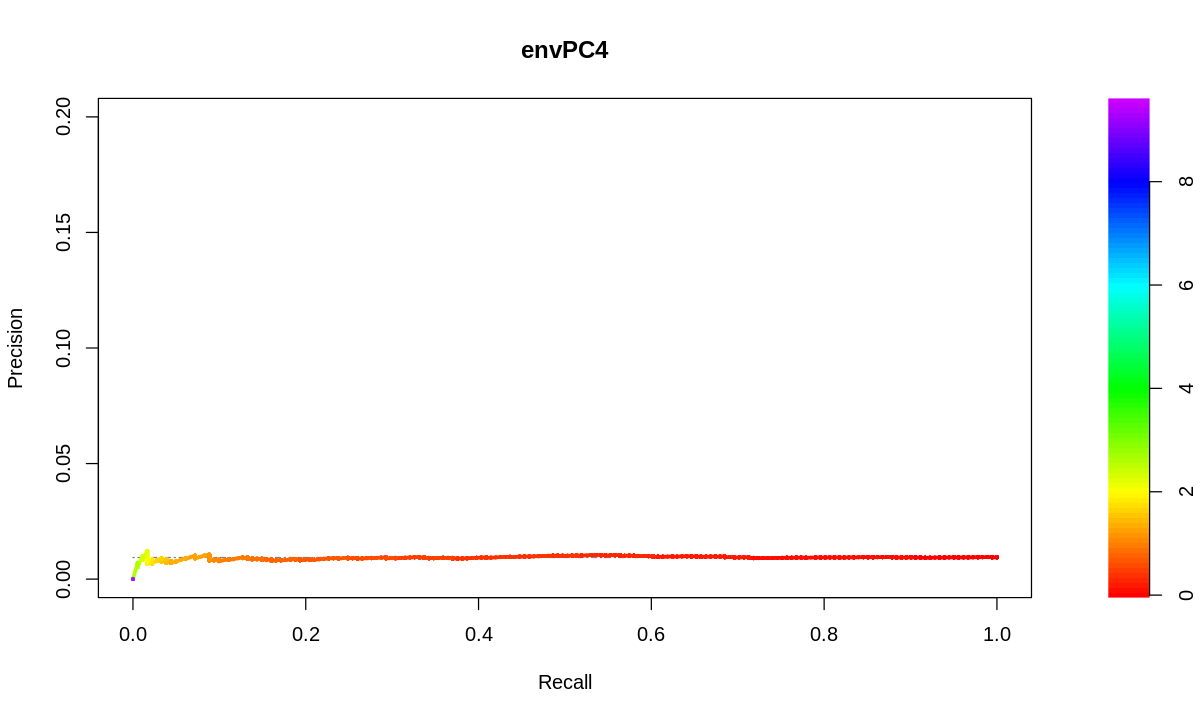

In [604]:
options(repr.plot.width=10, repr.plot.height=6)
for(i in 1:4){
    fg_RAO = -log10(as.numeric(testRes_zs_dna_andro[,i+11]))[testRes_zs_dna_andro$OG%in%RAO[,2]]
    bg_RAO = -log10(as.numeric(testRes_zs_dna_andro[,i+11]))[!testRes_zs_dna_andro$OG%in%RAO[,2]]

    pr_RAO = pr.curve(scores.class0 = fg_RAO, scores.class1 = bg_RAO[bg_RAO!=Inf], curve = T,rand.compute = T)
    roc_RAO = roc.curve(scores.class0 = fg_RAO, scores.class1 = bg_RAO[bg_RAO!=Inf], curve = T,rand.compute = T)

    plot(pr_RAO,rand.plot = T,ylim = c(0,0.2),auc.main =F,main = paste0("envPC",i))

}


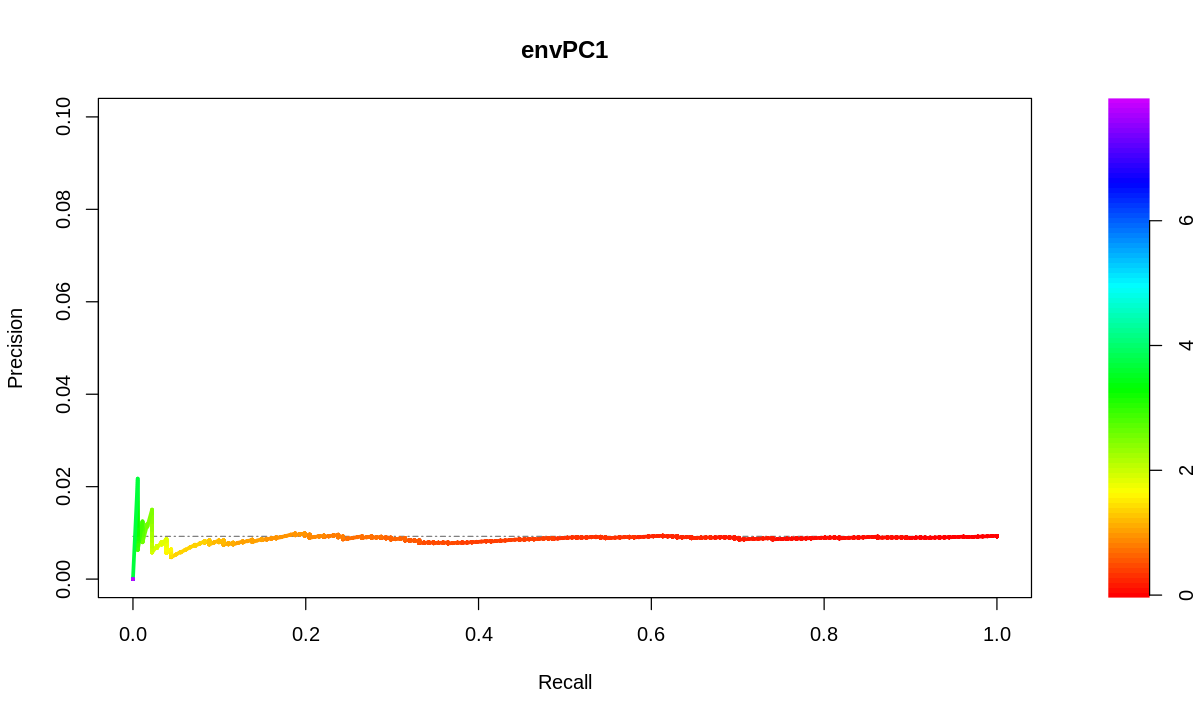

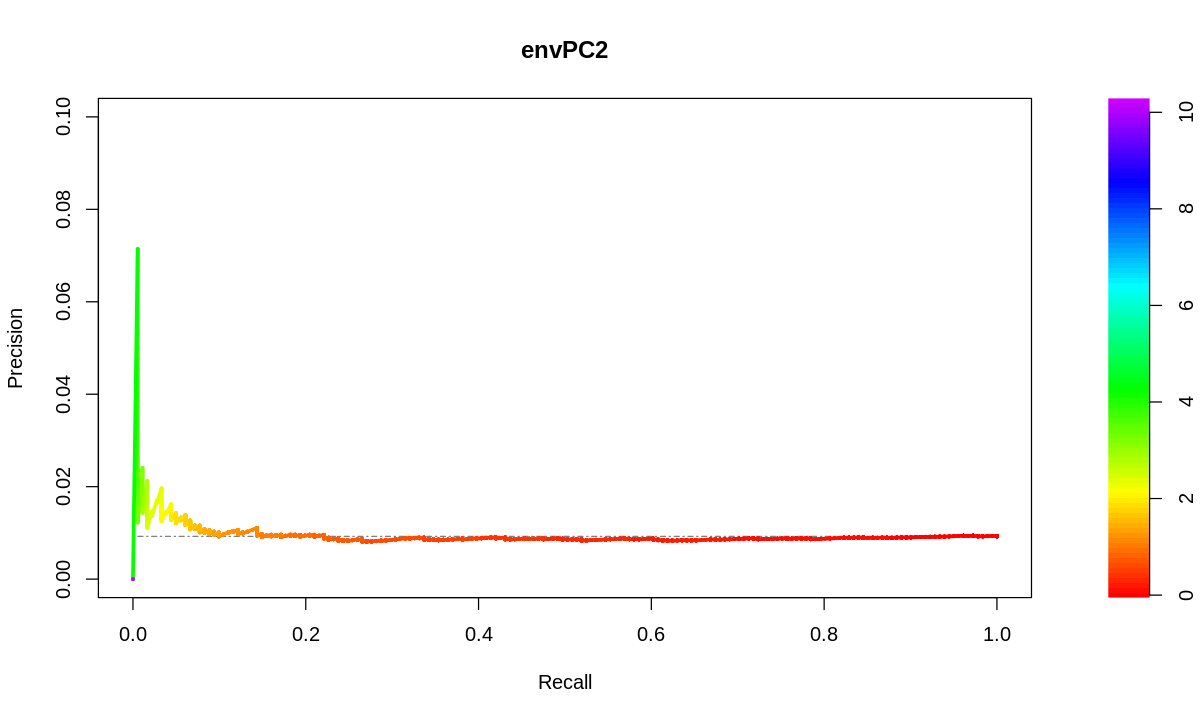

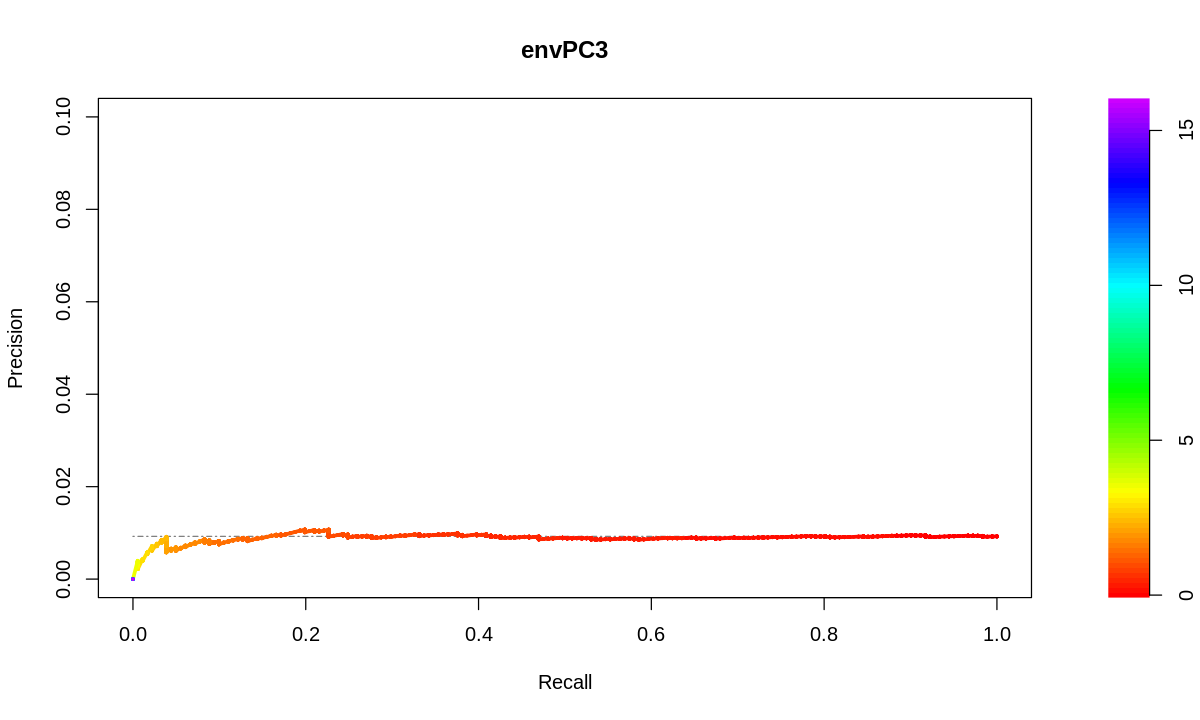

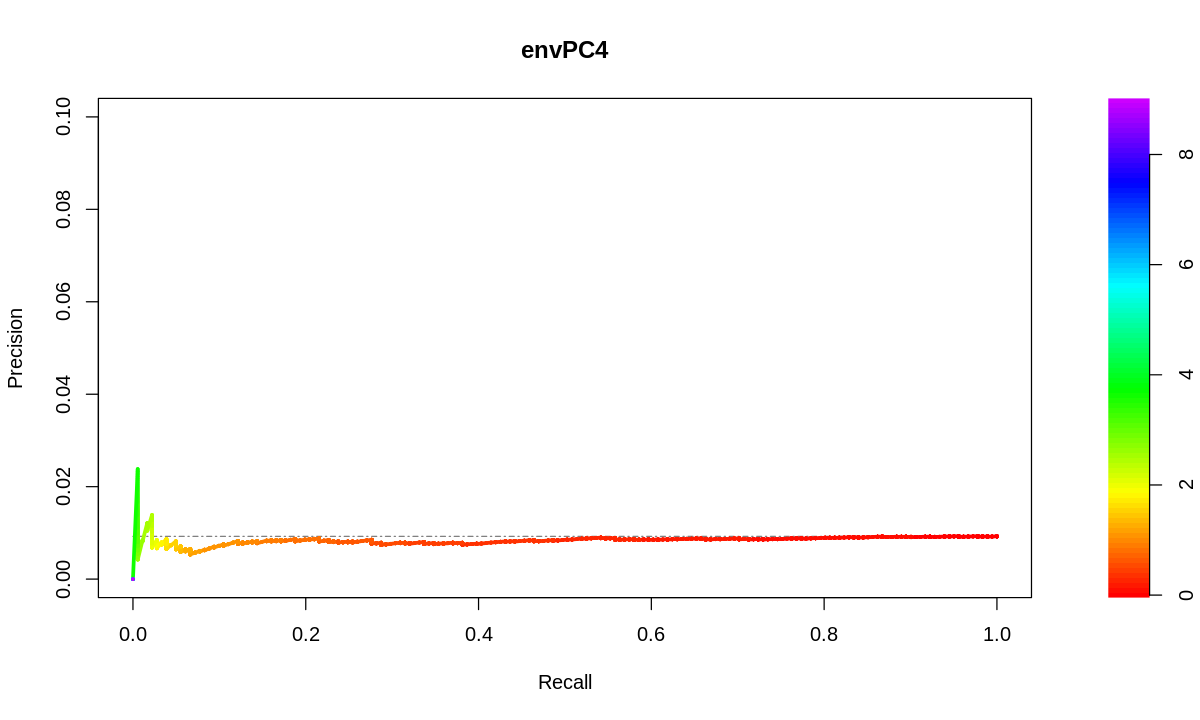

In [671]:
options(repr.plot.width=10, repr.plot.height=6)
for(i in 1:4){
    fg_RAO = -log10(as.numeric(testRes_dnds_andro[,i+11]))[testRes_dnds_andro$OG%in%RAO[,2]]
    bg_RAO = -log10(as.numeric(testRes_dnds_andro[,i+11]))[!testRes_dnds_andro$OG%in%RAO[,2]]

    pr_RAO = pr.curve(scores.class0 = fg_RAO, scores.class1 = bg_RAO[bg_RAO!=Inf], curve = T,rand.compute = T)
    roc_RAO = roc.curve(scores.class0 = fg_RAO, scores.class1 = bg_RAO[bg_RAO!=Inf], curve = T,rand.compute = T)

    plot(pr_RAO,rand.plot = T,ylim = c(0,0.1),auc.main =F,main = paste0("envPC",i))

}


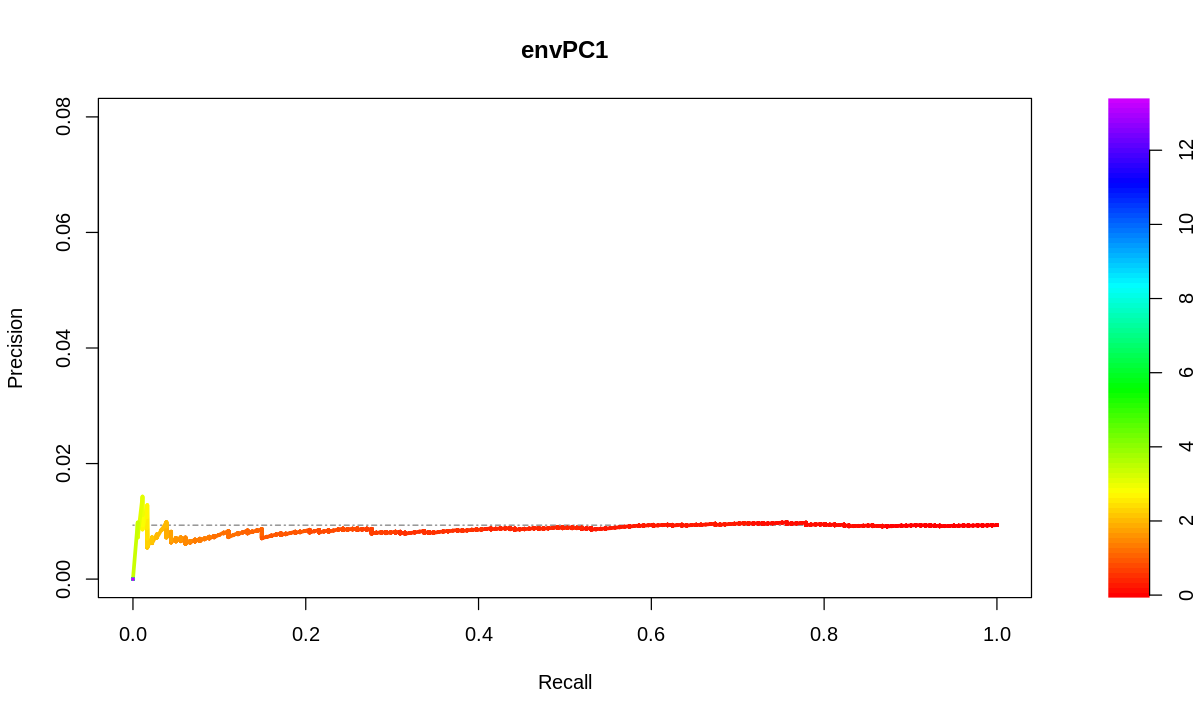

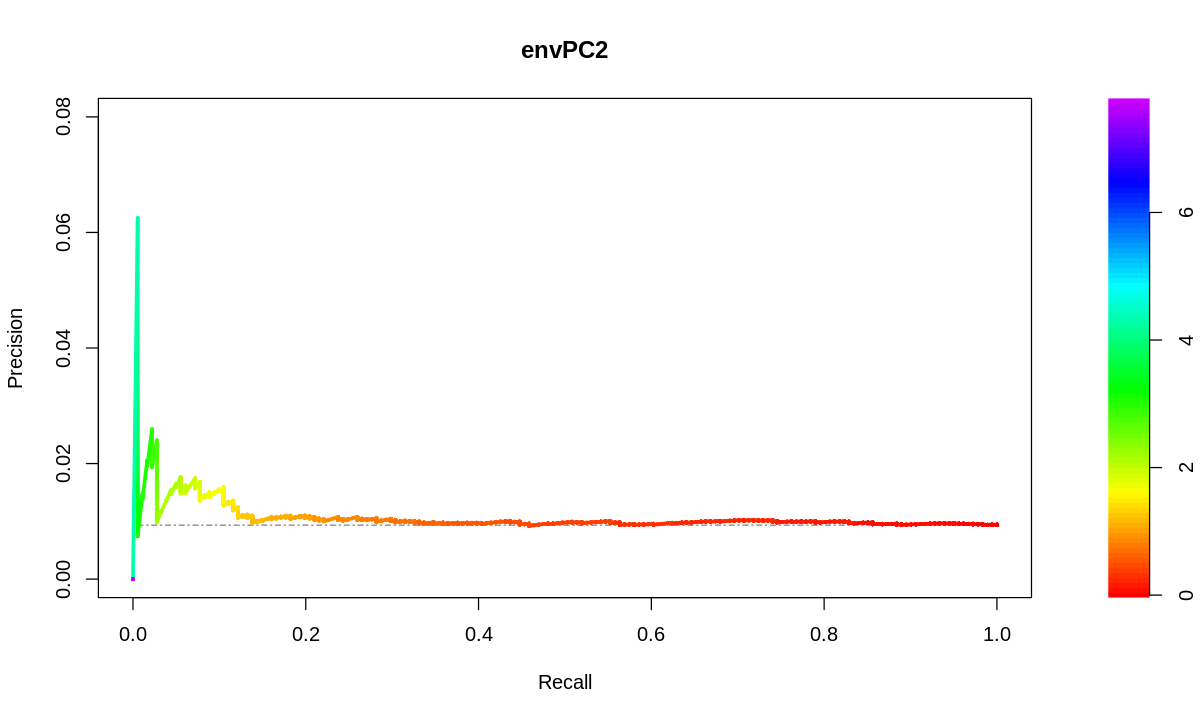

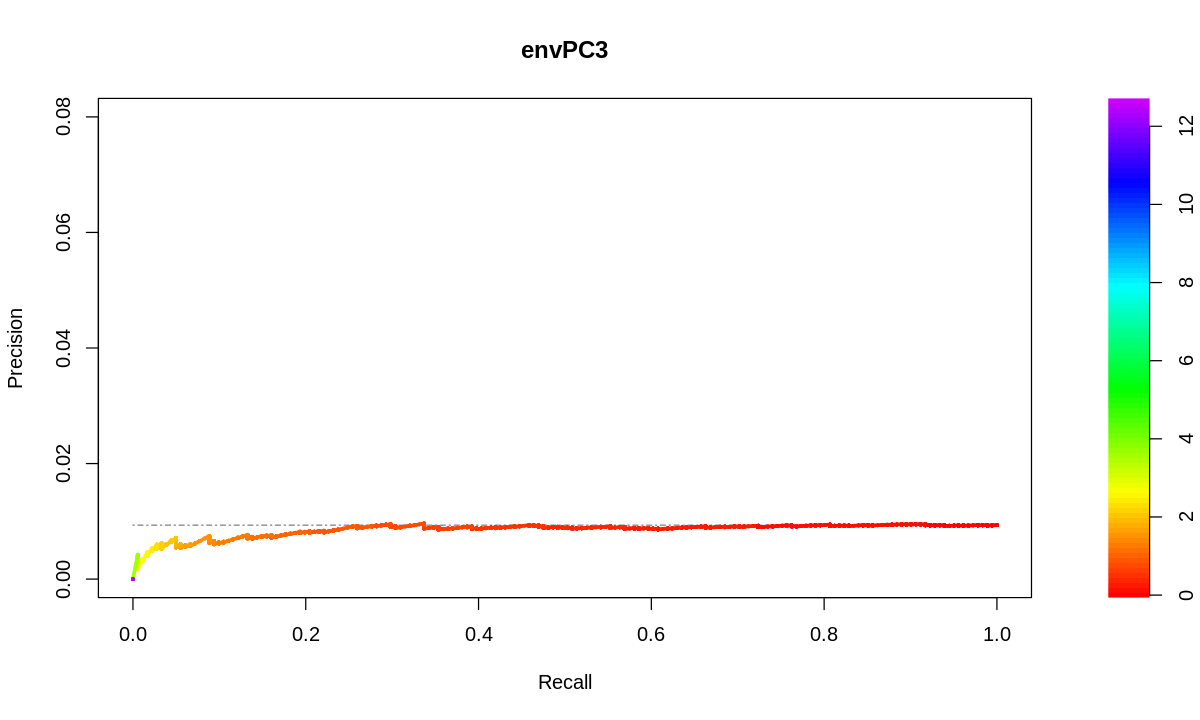

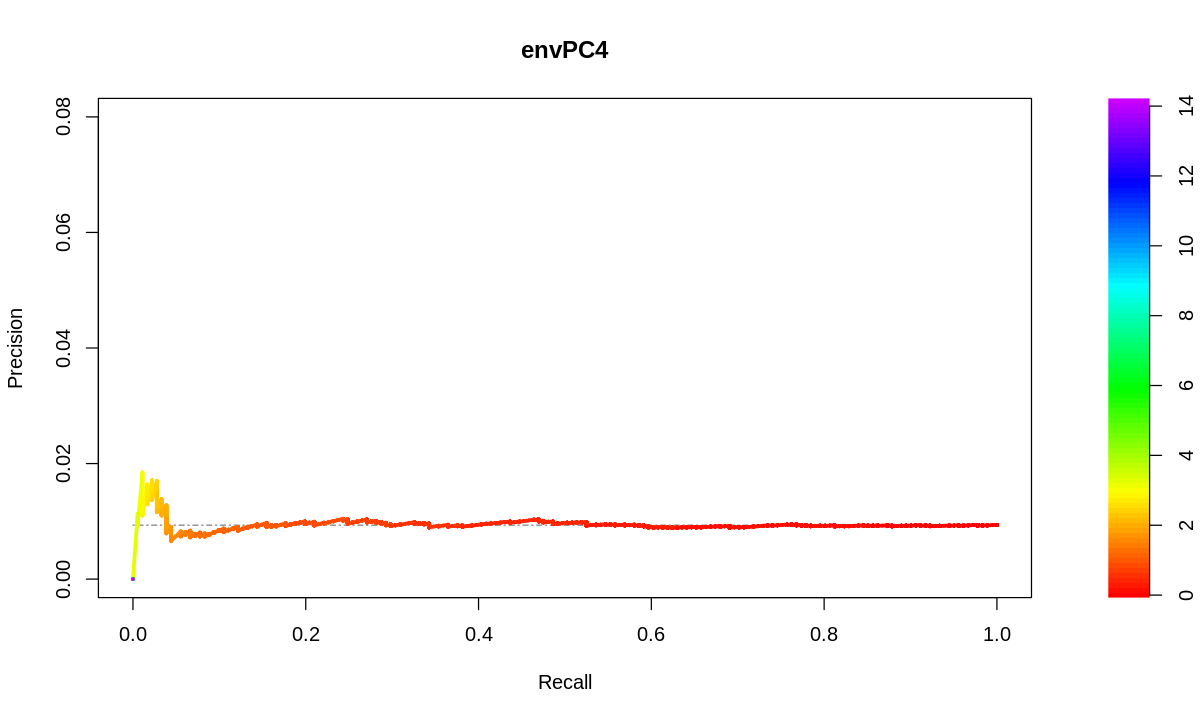

In [822]:
options(repr.plot.width=10, repr.plot.height=6)
for(i in 1:4){
    fg_RAO = -log10(as.numeric(testRes_multiVar[,i+11]))[testRes_multiVar$OG%in%RAO[,2]]
    bg_RAO = -log10(as.numeric(testRes_multiVar[,i+11]))[!testRes_multiVar$OG%in%RAO[,2]]

    pr_RAO = pr.curve(scores.class0 = fg_RAO, scores.class1 = bg_RAO[bg_RAO!=Inf], curve = T,rand.compute = T)
    roc_RAO = roc.curve(scores.class0 = fg_RAO, scores.class1 = bg_RAO[bg_RAO!=Inf], curve = T,rand.compute = T)

    plot(pr_RAO,rand.plot = T,ylim = c(0,0.08),auc.main =F,main = paste0("envPC",i))

}


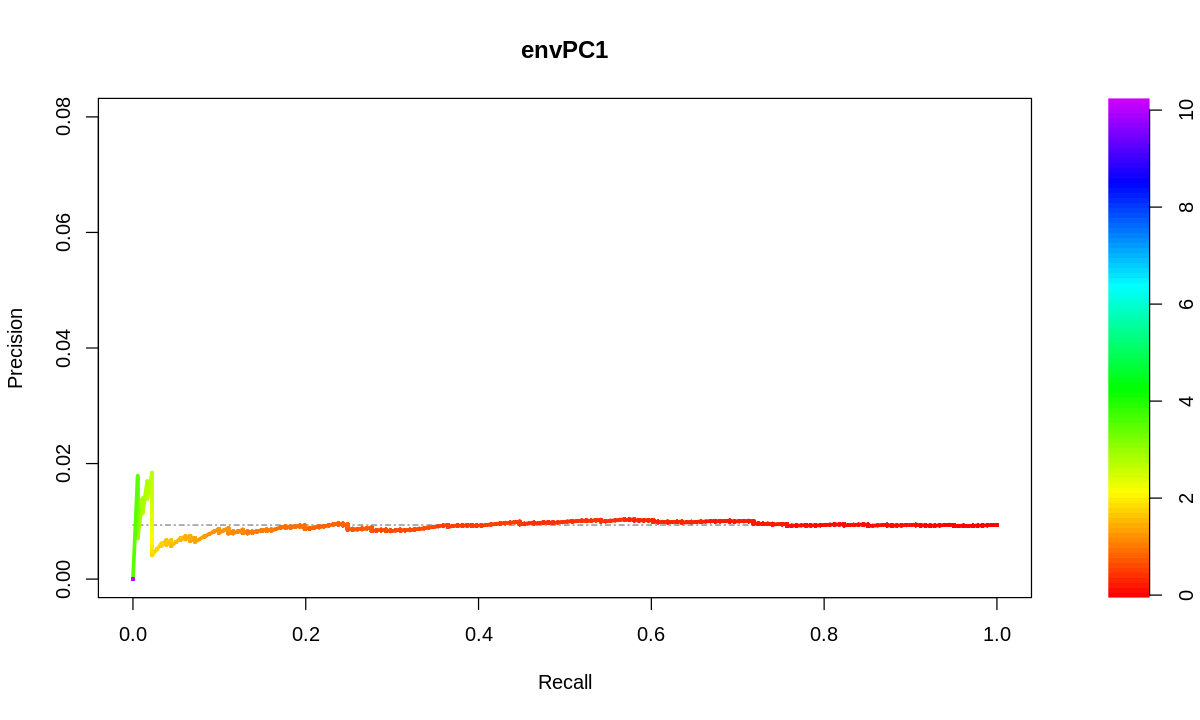

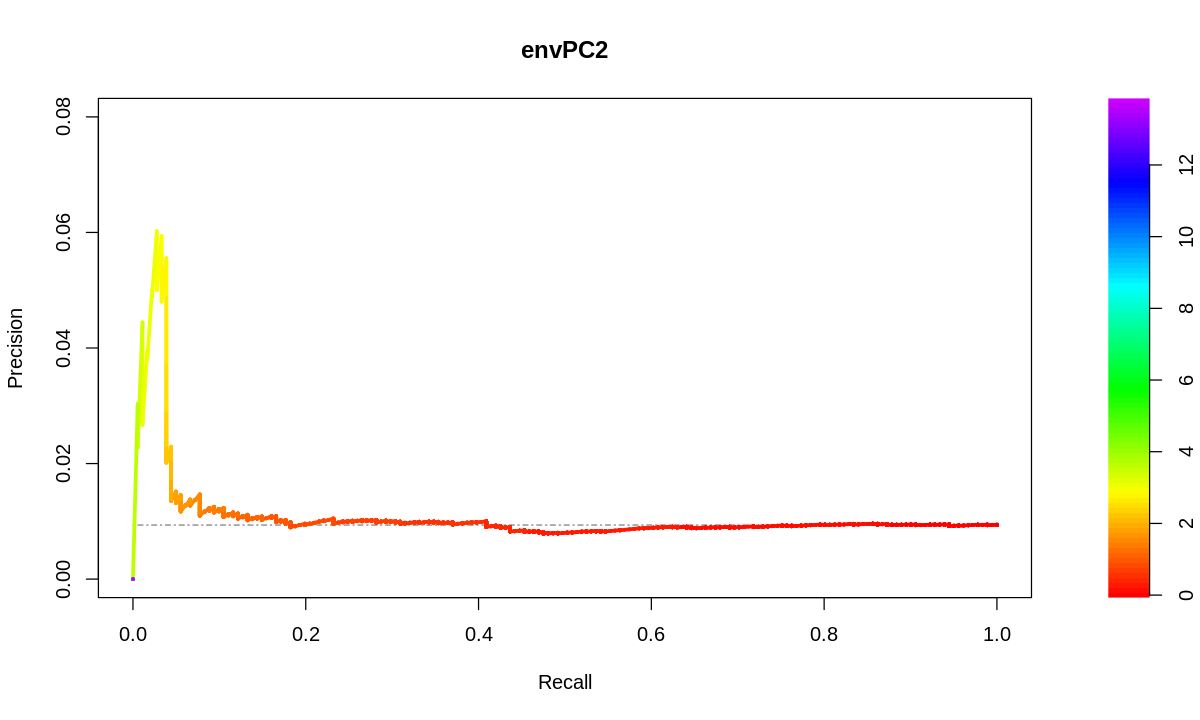

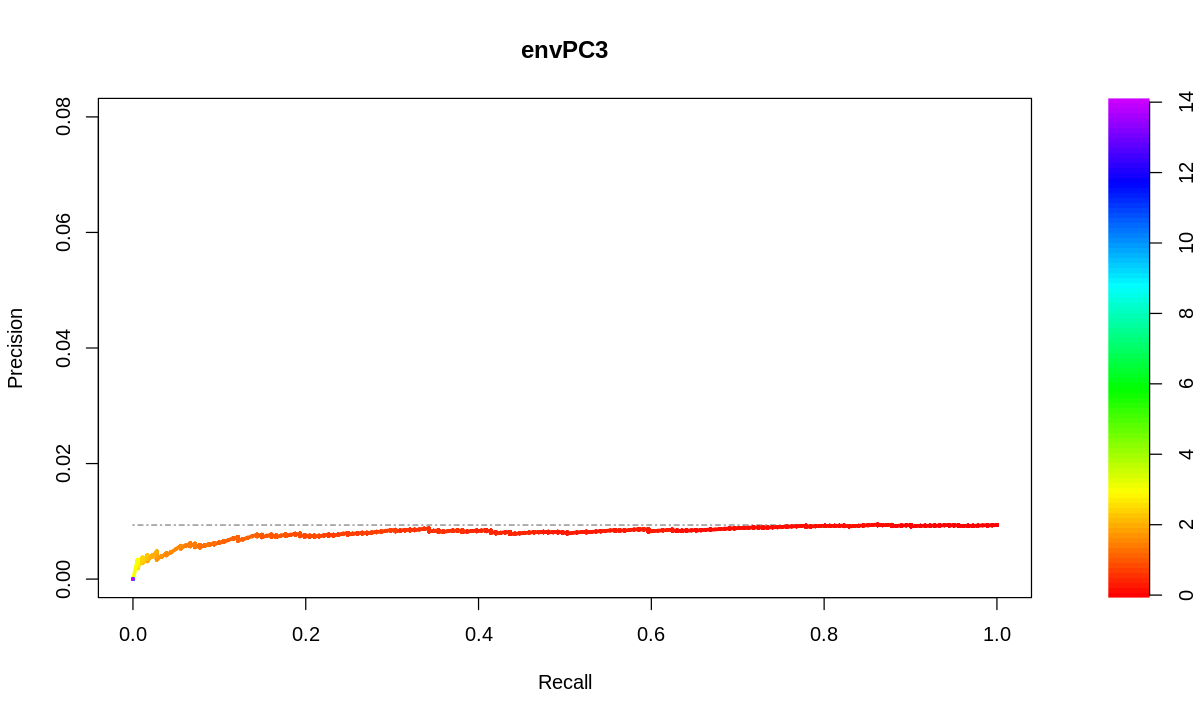

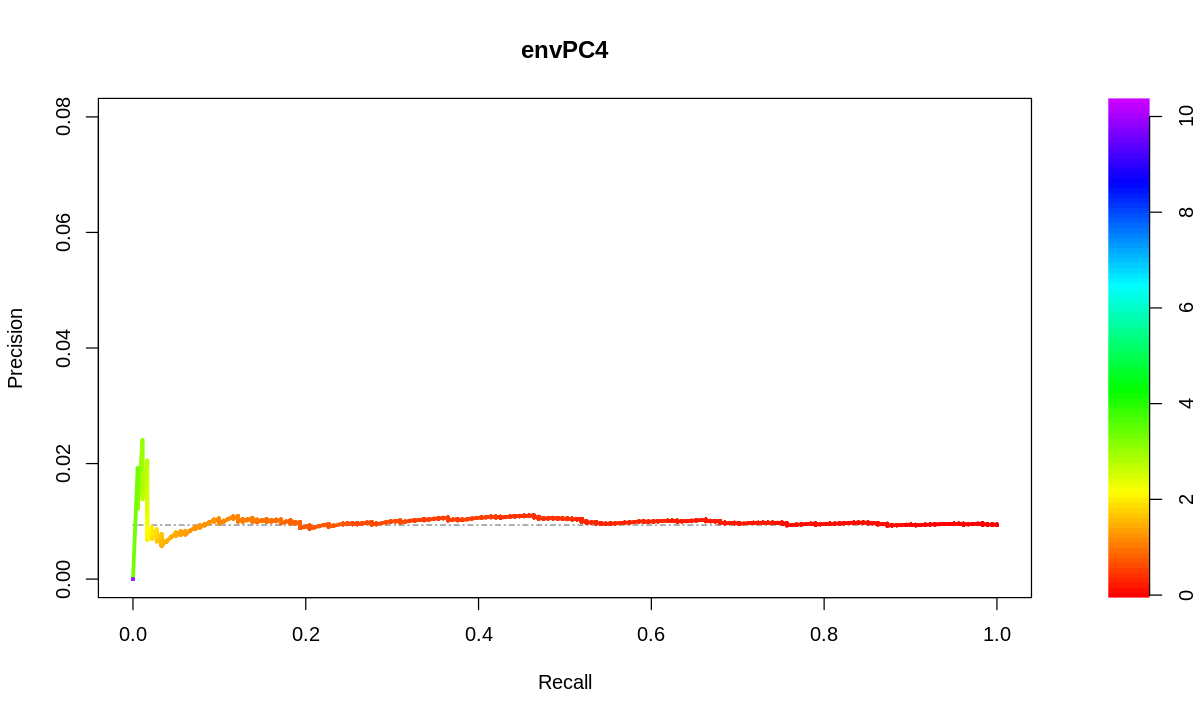

In [816]:
options(repr.plot.width=10, repr.plot.height=6)
for(i in 1:4){
    fg_RAO = -log10(as.numeric(testRes_multiVar_andro[,i+11]))[testRes_multiVar_andro$OG%in%RAO[,2]]
    bg_RAO = -log10(as.numeric(testRes_multiVar_andro[,i+11]))[!testRes_multiVar_andro$OG%in%RAO[,2]]

    pr_RAO = pr.curve(scores.class0 = fg_RAO, scores.class1 = bg_RAO[bg_RAO!=Inf], curve = T,rand.compute = T)
    roc_RAO = roc.curve(scores.class0 = fg_RAO, scores.class1 = bg_RAO[bg_RAO!=Inf], curve = T,rand.compute = T)

    plot(pr_RAO,rand.plot = T,ylim = c(0,0.08),auc.main =F,main = paste0("envPC",i))

}


[1] 0.09838974

       
        FALSE  TRUE
  FALSE 18618   363
  TRUE    363    37


	Fisher's Exact Test for Count Data

data:  contTab
p-value = 2.383e-14
alternative hypothesis: true odds ratio is not equal to 1
95 percent confidence interval:
 3.564861 7.477410
sample estimates:
odds ratio 
  5.226615 


,OG,Coeff_envPC1,Coeff_envPC2,Coeff_envPC3,Coeff_envPC4,Coeff_envPC5,Coeff_envPC6,Coeff_envPC7,Coeff_envPC8,Coeff_envPC9,⋯,VAE_envPC3,VAE_envPC4,VAE_envPC5,VAE_envPC6,VAE_envPC7,VAE_envPC8,VAE_envPC9,VAE_envPC10,PvID,ZmID
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
1413,OG0002226,0.14661744,-0.008498189,0.032341241,0.068465883,-0.040819365,-0.10685893,7.086941e-02,0.007903524,-0.103422874,⋯,2.367048e-02,0.106762410,0.0288289808,0.210445542,0.0955113296,7.709733e-05,1.788606e-01,0.051653952,Pavag04G151100.1,Zm00001eb181400_T001
2437,OG0003382,0.14473245,0.012521716,0.011968186,-0.009024374,0.032917686,0.05392748,-8.640915e-03,-0.022879072,-0.026256248,⋯,4.670862e-03,0.006843557,0.0163362192,0.051307847,0.0009021068,9.585746e-03,1.692240e-02,0.001893876,Pavag09G248300.1,Zm00001eb252160_T001
5058,OG0006552,0.16919041,-0.016955810,0.029092274,0.009368645,-0.049374151,0.03576173,-4.743535e-05,-0.058217678,0.022757866,⋯,9.654272e-03,0.002035005,0.0695385883,0.035676329,0.0028665738,6.030132e-02,1.757149e-02,0.012669767,Pavag02G396600.1,Zm00001eb111800_T001
5292,OG0006827,-0.67413239,0.060771096,-0.128926503,-0.087841697,0.215593015,-0.11902634,-6.313175e-02,-0.173962420,0.034306699,⋯,1.302335e-02,0.027032447,0.1246107340,0.078390539,0.0074368151,5.560364e-02,7.208249e-04,0.120525399,PavagK116300.1,Zm00001eb105230_T002
6806,OG0008524,0.13458487,0.063094209,0.079797190,-0.077913230,-0.026298738,0.04375227,6.160956e-03,0.001539291,0.001237951,⋯,1.183639e-01,0.116937778,0.0100092526,0.031089944,0.0008275455,2.443530e-05,5.832167e-05,0.024809859,Pavag10G092200.2,Zm00001eb279420_T003
7105,OG0008858,0.13045502,-0.076678442,-0.077381749,0.027914157,0.010732820,0.07045109,-7.015158e-03,-0.082280637,-0.039231637,⋯,6.683520e-02,0.001524658,0.0014567294,0.040724769,0.0001053862,5.006665e-02,1.413135e-02,0.039822051,Pavag04G247900.1,Zm00001eb252100_T004
8066,OG0009869,-0.10570228,-0.276569664,-0.184125694,0.332115964,0.033215192,0.21488577,-2.118283e-01,-0.119509267,-0.267307241,⋯,4.749323e-01,0.258858064,0.0367431587,0.016923751,0.0142576343,3.051028e-03,7.927846e-03,0.056973991,Pavag02G003800.1,NA
8178,OG0010005,-0.12226429,-0.004900163,0.013519275,-0.083431933,0.003173183,0.06456345,2.678715e-03,0.068614258,-0.013158055,⋯,9.375275e-03,0.158658124,0.0002230856,0.119201594,0.0024834133,8.376673e-02,6.280647e-03,0.024113939,Pavag04G122400.1,Zm00001eb236850_T002
14039,OG0016320,0.07763204,0.008277887,0.002524529,0.080696856,0.025466275,0.01501887,-4.719120e-03,-0.130001586,0.004069374,⋯,7.606373e-05,0.063902889,0.0153865421,0.002271481,0.0049100057,3.040512e-01,2.520136e-04,0.032233461,Pavag09G095400.1,Zm00001eb078600_T004


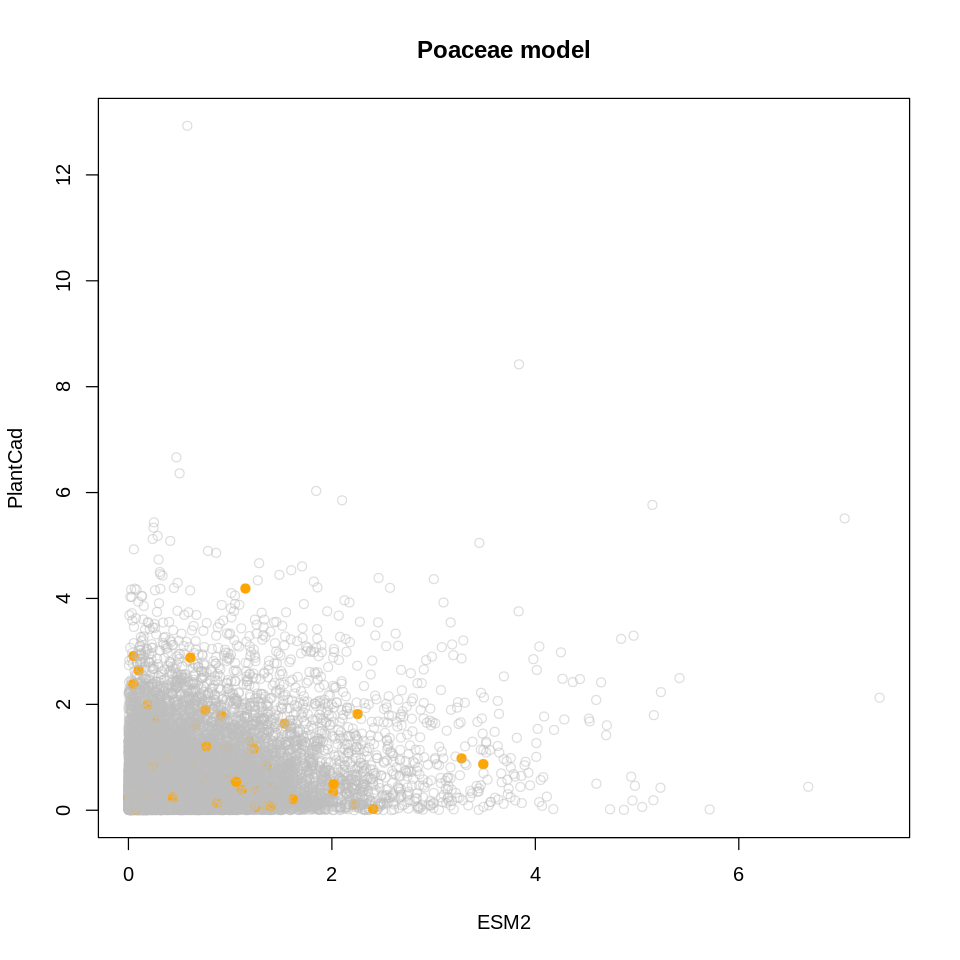

In [599]:
tmpCommonIdx = intersect(testRes_zs$OG,testRes_zs_dna$OG)
plot(-log10(testRes_zs$Pval_envPC1[testRes_zs$OG%in%tmpCommonIdx]),
     -log10(testRes_zs_dna$Pval_envPC1[testRes_zs_dna$OG%in%tmpCommonIdx]),
     xlab = "ESM2",ylab = "PlantCad",main = "Poaceae model",
     pch = ifelse(tmpCommonIdx%in%RAO[,2],19,1) ,
     col = ifelse(tmpCommonIdx%in%RAO[,2],"orange",alpha("grey",.5)))
cor(testRes_zs$Pval_envPC1[testRes_zs$OG%in%tmpCommonIdx],
     testRes_zs_dna$Pval_envPC1[testRes_zs_dna$OG%in%tmpCommonIdx],use = "complete")

contTab = table(rank(testRes_zs$Pval_envPC1[testRes_zs$OG%in%tmpCommonIdx],na.last = T) <= 400 , 
                rank(testRes_zs_dna$Pval_envPC1[testRes_zs_dna$OG%in%tmpCommonIdx],na.last = T) <= 400)
contTab
fisher.test(contTab)

testRes_zs[testRes_zs$OG%in%tmpCommonIdx,][which(rank(testRes_zs$Pval_envPC1[testRes_zs$OG%in%tmpCommonIdx],na.last = T) <= 200&rank(testRes_zs_dna$Pval_envPC1[testRes_zs_dna$OG%in%tmpCommonIdx],na.last = T) <= 200),]

[1] 0.1064384

       
        FALSE  TRUE
  FALSE 18626   355
  TRUE    355    45


	Fisher's Exact Test for Count Data

data:  contTab
p-value < 2.2e-16
alternative hypothesis: true odds ratio is not equal to 1
95 percent confidence interval:
 4.681289 9.266677
sample estimates:
odds ratio 
  6.648662 


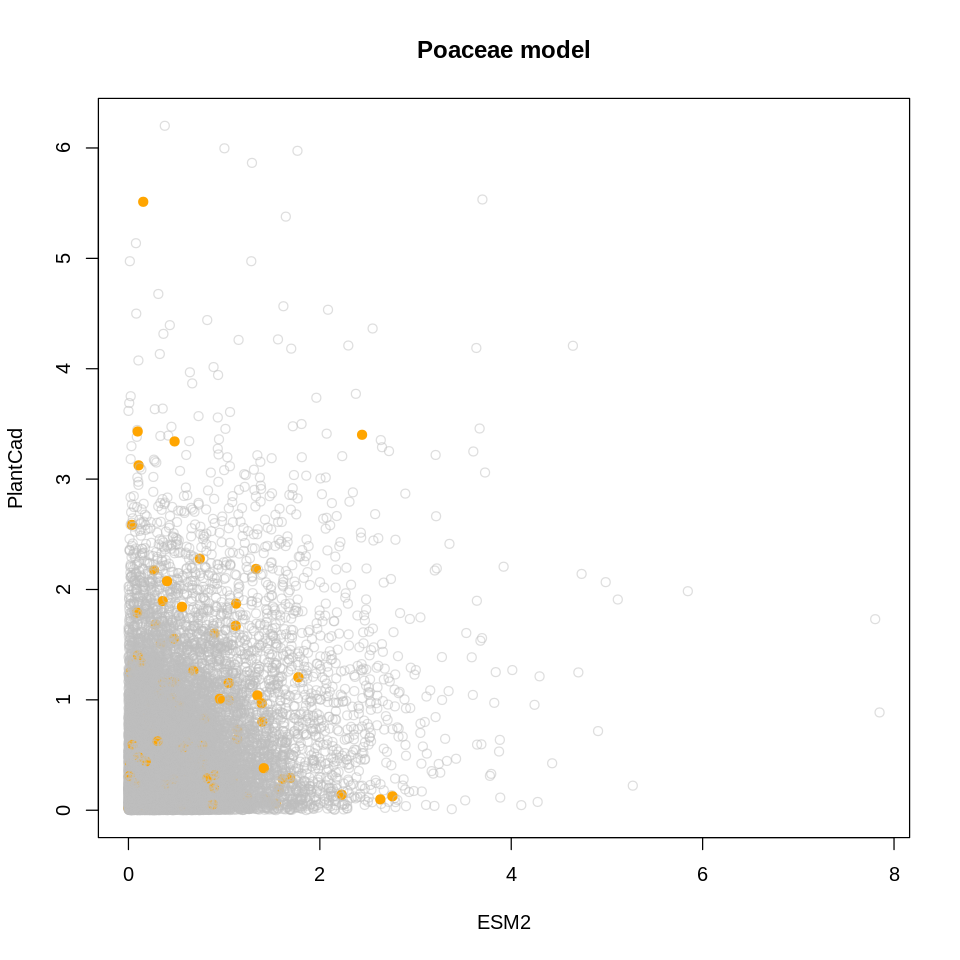

In [601]:
tmpCommonIdx = intersect(testRes_zs$OG,testRes_zs_dna$OG)
plot(-log10(testRes_zs$Pval_envPC2[testRes_zs$OG%in%tmpCommonIdx]),
     -log10(testRes_zs_dna$Pval_envPC2[testRes_zs_dna$OG%in%tmpCommonIdx]),
     xlab = "ESM2",ylab = "PlantCad",main = "Poaceae model",
     pch = ifelse(tmpCommonIdx%in%RAO[,2],19,1) ,
     col = ifelse(tmpCommonIdx%in%RAO[,2],"orange",alpha("grey",.5)))
cor(testRes_zs$Pval_envPC2[testRes_zs$OG%in%tmpCommonIdx],
     testRes_zs_dna$Pval_envPC2[testRes_zs_dna$OG%in%tmpCommonIdx],use = "complete")

contTab = table(rank(testRes_zs$Pval_envPC2[testRes_zs$OG%in%tmpCommonIdx],na.last = T) <= 400 , 
                rank(testRes_zs_dna$Pval_envPC2[testRes_zs_dna$OG%in%tmpCommonIdx],na.last = T) <= 400)
contTab
fisher.test(contTab)

# testRes_zs[testRes_zs$OG%in%tmpCommonIdx,][which(rank(testRes_zs$Pval_envPC2[testRes_zs$OG%in%tmpCommonIdx],na.last = T) <= 200&rank(testRes_zs_dna$Pval_envPC1[testRes_zs_dna$OG%in%tmpCommonIdx],na.last = T) <= 200),]

[1] 0.1072485

       
        FALSE  TRUE
  FALSE 18952   178
  TRUE    178    22


	Fisher's Exact Test for Count Data

data:  contTab
p-value < 2.2e-16
alternative hypothesis: true odds ratio is not equal to 1
95 percent confidence interval:
  7.845731 21.143144
sample estimates:
odds ratio 
  13.15754 


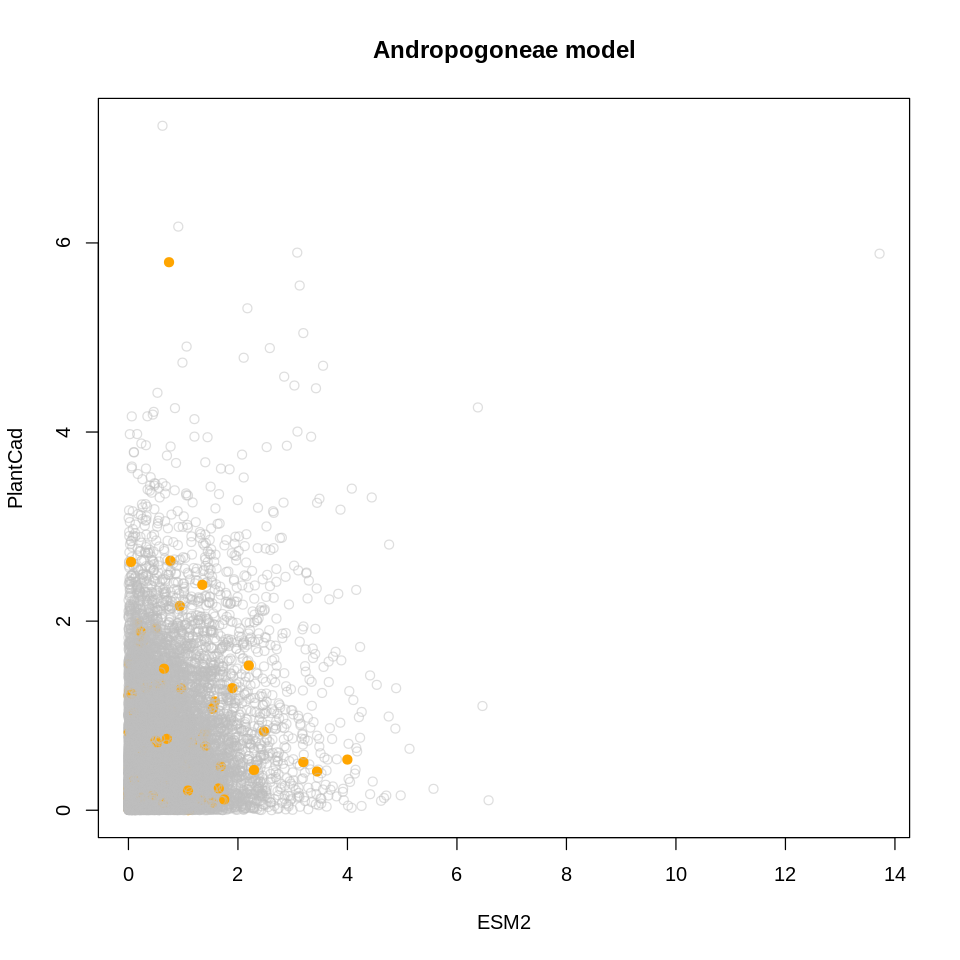

In [600]:
tmpCommonIdx = intersect(testRes_zs_andro$OG,testRes_zs_dna_andro$OG)
plot(-log10(testRes_zs_andro$Pval_envPC1[testRes_zs_andro$OG%in%tmpCommonIdx]),
     -log10(testRes_zs_dna_andro$Pval_envPC1[testRes_zs_dna_andro$OG%in%tmpCommonIdx]),
     xlab = "ESM2",ylab = "PlantCad",main = "Andropogoneae model",
     pch = ifelse(tmpCommonIdx%in%RAO[,2],19,1) ,
     col = ifelse(tmpCommonIdx%in%RAO[,2],"orange",alpha("grey",.5))) 
cor(testRes_zs_andro$Pval_envPC1[testRes_zs_andro$OG%in%tmpCommonIdx],
     testRes_zs_dna_andro$Pval_envPC1[testRes_zs_dna_andro$OG%in%tmpCommonIdx],use = "complete")

contTab = table(rank(testRes_zs_andro$Pval_envPC1[testRes_zs_andro$OG%in%tmpCommonIdx],na.last = T) <= 200 , 
                rank(testRes_zs_dna_andro$Pval_envPC1[testRes_zs_dna_andro$OG%in%tmpCommonIdx],na.last = T) <= 200)
contTab
fisher.test(contTab)

[1] 0.1318459

       
        FALSE  TRUE
  FALSE 18950   180
  TRUE    180    20


	Fisher's Exact Test for Count Data

data:  contTab
p-value = 2.413e-14
alternative hypothesis: true odds ratio is not equal to 1
95 percent confidence interval:
  6.815809 19.117457
sample estimates:
odds ratio 
  11.69446 


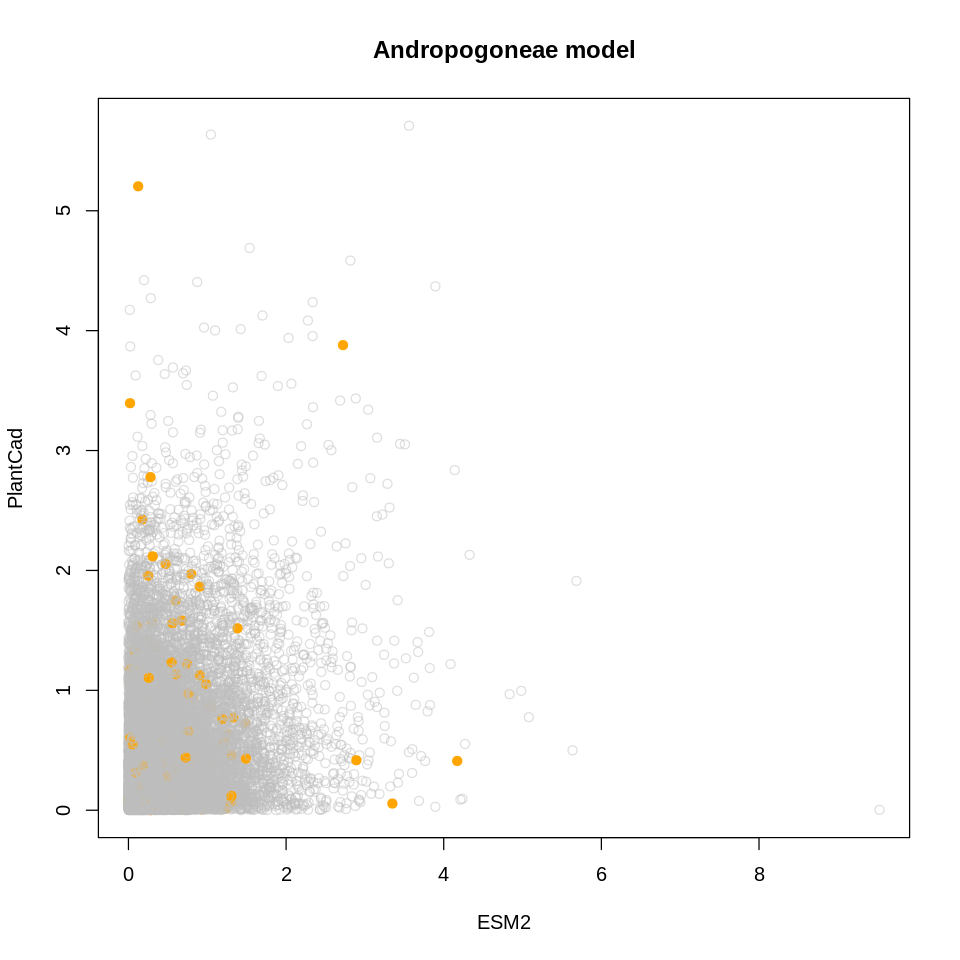

In [603]:
tmpCommonIdx = intersect(testRes_zs_andro$OG,testRes_zs_dna_andro$OG)
plot(-log10(testRes_zs_andro$Pval_envPC2[testRes_zs_andro$OG%in%tmpCommonIdx]),
     -log10(testRes_zs_dna_andro$Pval_envPC2[testRes_zs_dna_andro$OG%in%tmpCommonIdx]),
     xlab = "ESM2",ylab = "PlantCad",main = "Andropogoneae model",
     pch = ifelse(tmpCommonIdx%in%RAO[,2],19,1) ,
     col = ifelse(tmpCommonIdx%in%RAO[,2],"orange",alpha("grey",.5))) 
cor(testRes_zs_andro$Pval_envPC2[testRes_zs_andro$OG%in%tmpCommonIdx],
     testRes_zs_dna_andro$Pval_envPC2[testRes_zs_dna_andro$OG%in%tmpCommonIdx],use = "complete")

contTab = table(rank(testRes_zs_andro$Pval_envPC2[testRes_zs_andro$OG%in%tmpCommonIdx],na.last = T) <= 200 , 
                rank(testRes_zs_dna_andro$Pval_envPC2[testRes_zs_dna_andro$OG%in%tmpCommonIdx],na.last = T) <= 200)
contTab
fisher.test(contTab)

[1] 0.06259356

       
        FALSE  TRUE
  FALSE 19184   188
  TRUE    188    12


	Fisher's Exact Test for Count Data

data:  contTab
p-value = 1.064e-06
alternative hypothesis: true odds ratio is not equal to 1
95 percent confidence interval:
  3.247734 11.912290
sample estimates:
odds ratio 
  6.511639 


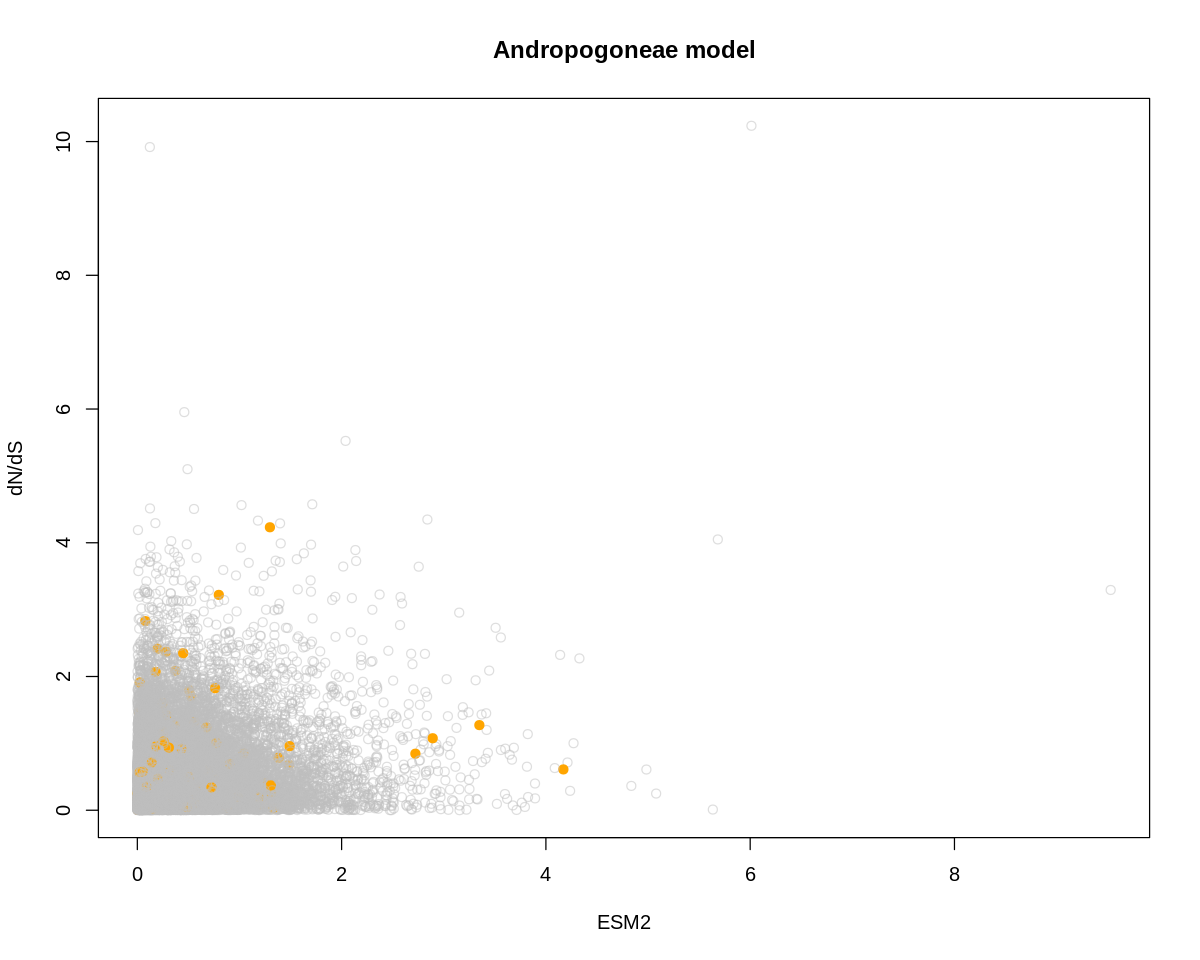

In [662]:
tmpCommonIdx = intersect(testRes_zs_andro$OG,testRes_dnds_andro$OG)
plot(-log10(testRes_zs_andro$Pval_envPC2[testRes_zs_andro$OG%in%tmpCommonIdx]),
     -log10(testRes_dnds_andro$Pval_envPC2[testRes_dnds_andro$OG%in%tmpCommonIdx]),
     xlab = "ESM2",ylab = "dN/dS",main = "Andropogoneae model",
     pch = ifelse(tmpCommonIdx%in%RAO[,2],19,1) ,
     col = ifelse(tmpCommonIdx%in%RAO[,2],"orange",alpha("grey",.5))) 
cor(testRes_zs_andro$Pval_envPC2[testRes_zs_andro$OG%in%tmpCommonIdx],
    testRes_dnds_andro$Pval_envPC2[testRes_dnds_andro$OG%in%tmpCommonIdx],use = "complete")

contTab = table(rank(testRes_zs_andro$Pval_envPC2[testRes_zs_andro$OG%in%tmpCommonIdx],na.last = T) <= 200 , 
                rank(testRes_dnds_andro$Pval_envPC2[testRes_dnds_andro$OG%in%tmpCommonIdx],na.last = T) <= 200)
contTab
fisher.test(contTab)

In [667]:
tmpCommonIdx = Reduce("intersect",list(testRes_zs$OG,testRes_zs_dna$OG,testRes_dnds$OG))
cor(cbind(testRes_zs$Pval_envPC1[testRes_zs$OG%in%tmpCommonIdx],
      testRes_zs_dna$Pval_envPC1[testRes_zs_dna$OG%in%tmpCommonIdx],
      testRes_dnds$Pval_envPC1[testRes_dnds$OG%in%tmpCommonIdx]))


1.00000000,0.09850616,0.02898137
0.09850616,1.00000000,0.08701547
0.02898137,0.08701547,1.00000000


In [769]:
poaceaeCandidates = list(testRes_zs$OG[rank(testRes_zs$Pval_envPC1) <= 400],
                         testRes_zs_dna$OG[rank(testRes_zs_dna$Pval_envPC1) <= 400],
                         testRes_dnds$OG[rank(testRes_dnds$Pval_envPC1) <= 400],
                         testRes_dnds$OG[rank(testRes_multiVar$Pval_envPC1) <= 400])
VennDiagram::venn.diagram(poaceaeCandidates,category.names = c("ESM2","plantCad","dn/ds","multiVar"),disable.logging = T,
                          filename = "/workdir/sh2246/p_phyloGWAS/output/ASREML_res_envPC1_poaceaeModel_Venn.png",
                          height = 8.7,width = 8.7,units = "cm",resolution = 600,imagetype = "png")

INFO [2024-09-26 09:28:13] [[1]]
INFO [2024-09-26 09:28:13] poaceaeCandidates
INFO [2024-09-26 09:28:13] 
INFO [2024-09-26 09:28:13] $category.names
INFO [2024-09-26 09:28:13] c("ESM2", "plantCad", "dn/ds", "multiVar")
INFO [2024-09-26 09:28:13] 
INFO [2024-09-26 09:28:13] $disable.logging
INFO [2024-09-26 09:28:13] T
INFO [2024-09-26 09:28:13] 
INFO [2024-09-26 09:28:13] $filename
INFO [2024-09-26 09:28:13] [1] "/workdir/sh2246/p_phyloGWAS/output/ASREML_res_envPC1_poaceaeModel_Venn.png"
INFO [2024-09-26 09:28:13] 
INFO [2024-09-26 09:28:13] $height
INFO [2024-09-26 09:28:13] [1] 8.7
INFO [2024-09-26 09:28:13] 
INFO [2024-09-26 09:28:13] $width
INFO [2024-09-26 09:28:13] [1] 8.7
INFO [2024-09-26 09:28:13] 
INFO [2024-09-26 09:28:13] $units
INFO [2024-09-26 09:28:13] [1] "cm"
INFO [2024-09-26 09:28:13] 
INFO [2024-09-26 09:28:13] $resolution
INFO [2024-09-26 09:28:13] [1] 600
INFO [2024-09-26 09:28:13] 
INFO [2024-09-26 09:28:13] $imagetype
INFO [2024-09-26 09:28:13] [1] "png"
INFO [202

[1] 1

In [770]:
poaceaeCandidates2 = list(testRes_zs$OG[rank(testRes_zs$Pval_envPC2) <= 400],
                         testRes_zs_dna$OG[rank(testRes_zs_dna$Pval_envPC2) <= 400],
                         testRes_dnds$OG[rank(testRes_dnds$Pval_envPC2) <= 400],
                         testRes_multiVar$OG[rank(testRes_multiVar$Pval_envPC2) <= 400])
VennDiagram::venn.diagram(poaceaeCandidates2,category.names = c("ESM2","plantCad","dn/ds","multiVar"),disable.logging = T,
                          filename = "/workdir/sh2246/p_phyloGWAS/output/ASREML_res_envPC2_poaceaeModel_Venn.png",
                          height = 8.7,width = 8.7,units = "cm",resolution = 600,imagetype = "png")

INFO [2024-09-26 09:28:43] [[1]]
INFO [2024-09-26 09:28:43] poaceaeCandidates2
INFO [2024-09-26 09:28:43] 
INFO [2024-09-26 09:28:43] $category.names
INFO [2024-09-26 09:28:43] c("ESM2", "plantCad", "dn/ds", "multiVar")
INFO [2024-09-26 09:28:43] 
INFO [2024-09-26 09:28:43] $disable.logging
INFO [2024-09-26 09:28:43] T
INFO [2024-09-26 09:28:43] 
INFO [2024-09-26 09:28:43] $filename
INFO [2024-09-26 09:28:43] [1] "/workdir/sh2246/p_phyloGWAS/output/ASREML_res_envPC2_poaceaeModel_Venn.png"
INFO [2024-09-26 09:28:43] 
INFO [2024-09-26 09:28:43] $height
INFO [2024-09-26 09:28:43] [1] 8.7
INFO [2024-09-26 09:28:43] 
INFO [2024-09-26 09:28:43] $width
INFO [2024-09-26 09:28:43] [1] 8.7
INFO [2024-09-26 09:28:43] 
INFO [2024-09-26 09:28:43] $units
INFO [2024-09-26 09:28:43] [1] "cm"
INFO [2024-09-26 09:28:43] 
INFO [2024-09-26 09:28:43] $resolution
INFO [2024-09-26 09:28:43] [1] 600
INFO [2024-09-26 09:28:43] 
INFO [2024-09-26 09:28:43] $imagetype
INFO [2024-09-26 09:28:43] [1] "png"
INFO [20

[1] 1

In [771]:
androCandidates = list(testRes_zs_andro$OG[rank(testRes_zs_andro$Pval_envPC1) <= 400],
                         testRes_zs_dna_andro$OG[rank(testRes_zs_dna_andro$Pval_envPC1) <= 400],
                         testRes_dnds_andro$OG[rank(testRes_dnds_andro$Pval_envPC1) <= 400],
                       testRes_multiVar_andro$OG[rank(testRes_multiVar_andro$Pval_envPC1) <= 400])
VennDiagram::venn.diagram(androCandidates,category.names = c("ESM2","plantCad","dn/ds","multiVar"),disable.logging = T,
                          filename = "/workdir/sh2246/p_phyloGWAS/output/ASREML_res_envPC1_andropogoneaeModel_Venn.png",
                          height = 8.7,width = 8.7,units = "cm",resolution = 600,imagetype = "png")

INFO [2024-09-26 09:29:29] [[1]]
INFO [2024-09-26 09:29:29] androCandidates
INFO [2024-09-26 09:29:29] 
INFO [2024-09-26 09:29:29] $category.names
INFO [2024-09-26 09:29:29] c("ESM2", "plantCad", "dn/ds", "multiVar")
INFO [2024-09-26 09:29:29] 
INFO [2024-09-26 09:29:29] $disable.logging
INFO [2024-09-26 09:29:29] T
INFO [2024-09-26 09:29:29] 
INFO [2024-09-26 09:29:29] $filename
INFO [2024-09-26 09:29:29] [1] "/workdir/sh2246/p_phyloGWAS/output/ASREML_res_envPC1_andropogoneaeModel_Venn.png"
INFO [2024-09-26 09:29:29] 
INFO [2024-09-26 09:29:29] $height
INFO [2024-09-26 09:29:29] [1] 8.7
INFO [2024-09-26 09:29:29] 
INFO [2024-09-26 09:29:29] $width
INFO [2024-09-26 09:29:29] [1] 8.7
INFO [2024-09-26 09:29:29] 
INFO [2024-09-26 09:29:29] $units
INFO [2024-09-26 09:29:29] [1] "cm"
INFO [2024-09-26 09:29:29] 
INFO [2024-09-26 09:29:29] $resolution
INFO [2024-09-26 09:29:29] [1] 600
INFO [2024-09-26 09:29:29] 
INFO [2024-09-26 09:29:29] $imagetype
INFO [2024-09-26 09:29:29] [1] "png"
INFO 

[1] 1

In [772]:
androCandidates2 = list(testRes_zs_andro$OG[rank(testRes_zs_andro$Pval_envPC2) <= 400],
                         testRes_zs_dna_andro$OG[rank(testRes_zs_dna_andro$Pval_envPC2) <= 400],
                         testRes_dnds_andro$OG[rank(testRes_dnds_andro$Pval_envPC2) <= 400],
                        testRes_multiVar_andro$OG[rank(testRes_multiVar_andro$Pval_envPC2) <= 400])
VennDiagram::venn.diagram(androCandidates2,category.names = c("ESM2","plantCad","dn/ds","multiVar"),disable.logging = T,
                          filename = "/workdir/sh2246/p_phyloGWAS/output/ASREML_res_envPC2_andropogoneaeModel_Venn.png",
                          height = 8.7,width = 8.7,units = "cm",resolution = 600,imagetype = "png")

INFO [2024-09-26 09:30:02] [[1]]
INFO [2024-09-26 09:30:02] androCandidates2
INFO [2024-09-26 09:30:02] 
INFO [2024-09-26 09:30:02] $category.names
INFO [2024-09-26 09:30:02] c("ESM2", "plantCad", "dn/ds", "multiVar")
INFO [2024-09-26 09:30:02] 
INFO [2024-09-26 09:30:02] $disable.logging
INFO [2024-09-26 09:30:02] T
INFO [2024-09-26 09:30:02] 
INFO [2024-09-26 09:30:02] $filename
INFO [2024-09-26 09:30:02] [1] "/workdir/sh2246/p_phyloGWAS/output/ASREML_res_envPC2_andropogoneaeModel_Venn.png"
INFO [2024-09-26 09:30:02] 
INFO [2024-09-26 09:30:02] $height
INFO [2024-09-26 09:30:02] [1] 8.7
INFO [2024-09-26 09:30:02] 
INFO [2024-09-26 09:30:02] $width
INFO [2024-09-26 09:30:02] [1] 8.7
INFO [2024-09-26 09:30:02] 
INFO [2024-09-26 09:30:02] $units
INFO [2024-09-26 09:30:02] [1] "cm"
INFO [2024-09-26 09:30:02] 
INFO [2024-09-26 09:30:02] $resolution
INFO [2024-09-26 09:30:02] [1] 600
INFO [2024-09-26 09:30:02] 
INFO [2024-09-26 09:30:02] $imagetype
INFO [2024-09-26 09:30:02] [1] "png"
INFO

[1] 1

In [776]:
install.packages("UpSetR")

also installing the dependency ‘gridExtra’


Updating HTML index of packages in '.Library'

Making 'packages.html' ...
 done



In [777]:
library(UpSetR)

In [792]:
names(poaceaeCandidates) = c("ESM2","plantCad","dn/ds","multiVar")
names(poaceaeCandidates2) = c("ESM2","plantCad","dn/ds","multiVar")
names(androCandidates) = c("ESM2","plantCad","dn/ds","multiVar")
names(androCandidates2) = c("ESM2","plantCad","dn/ds","multiVar")

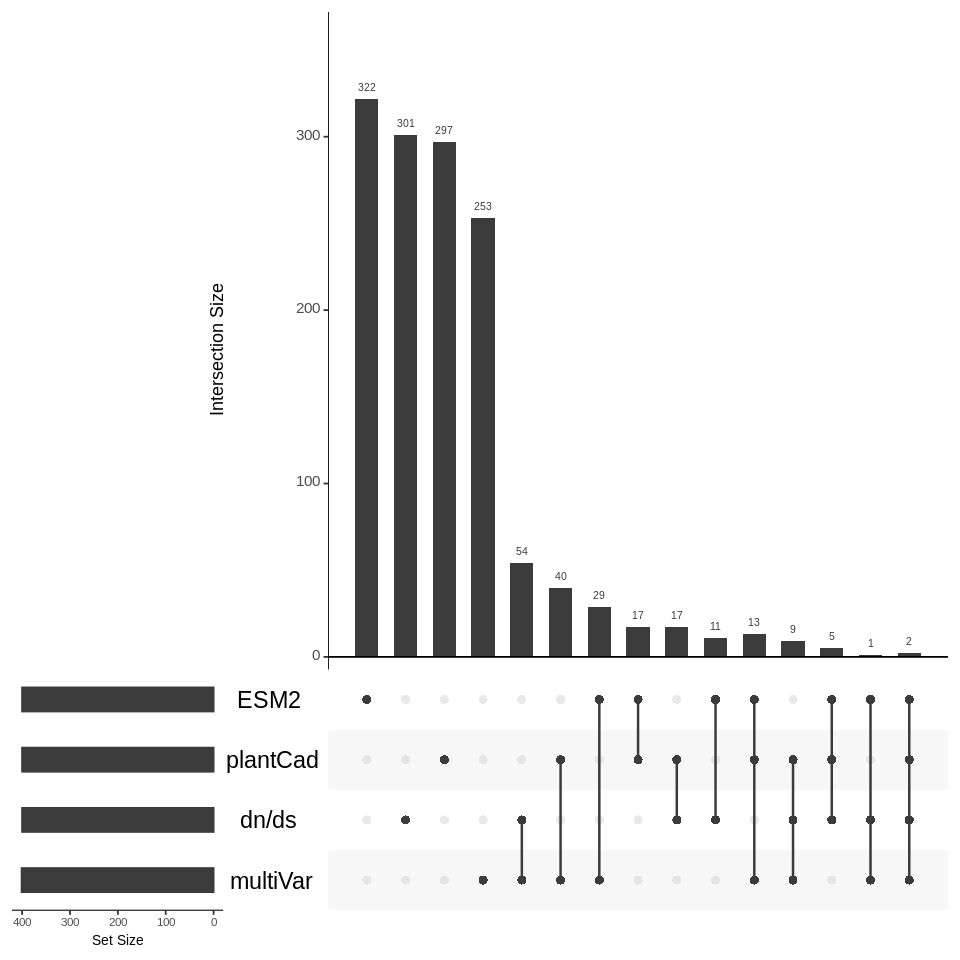

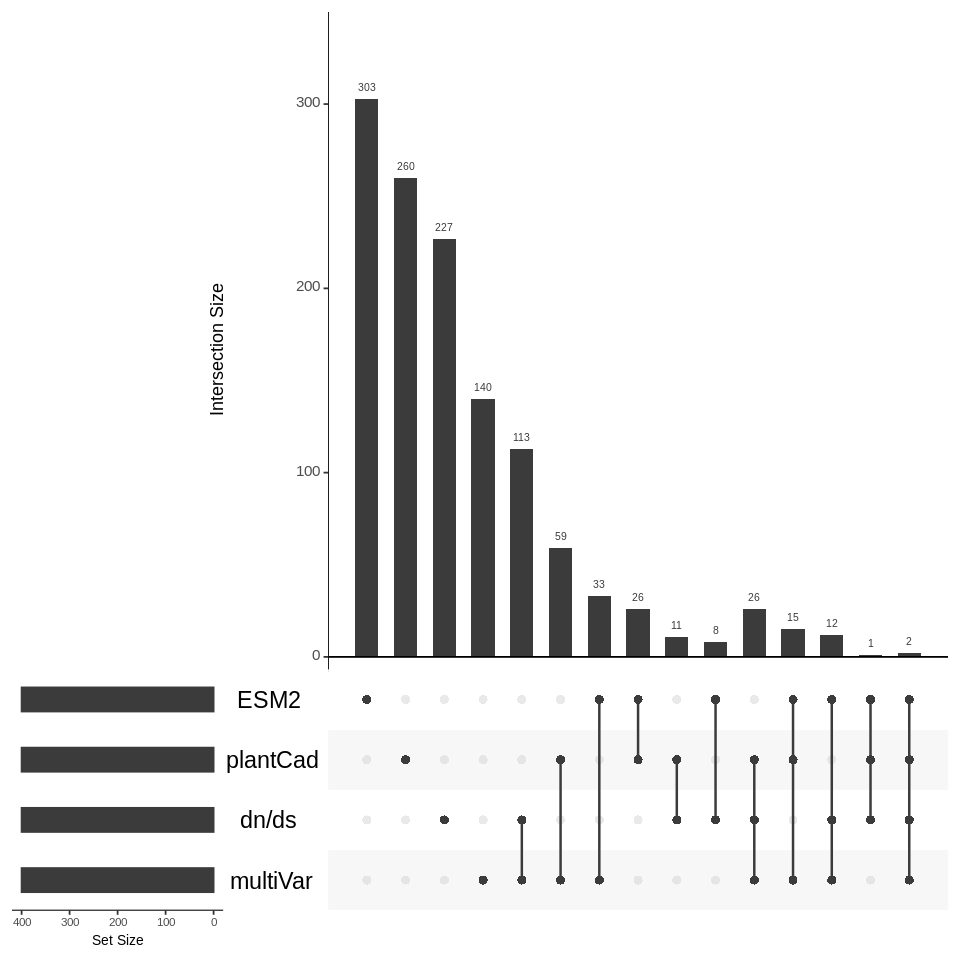

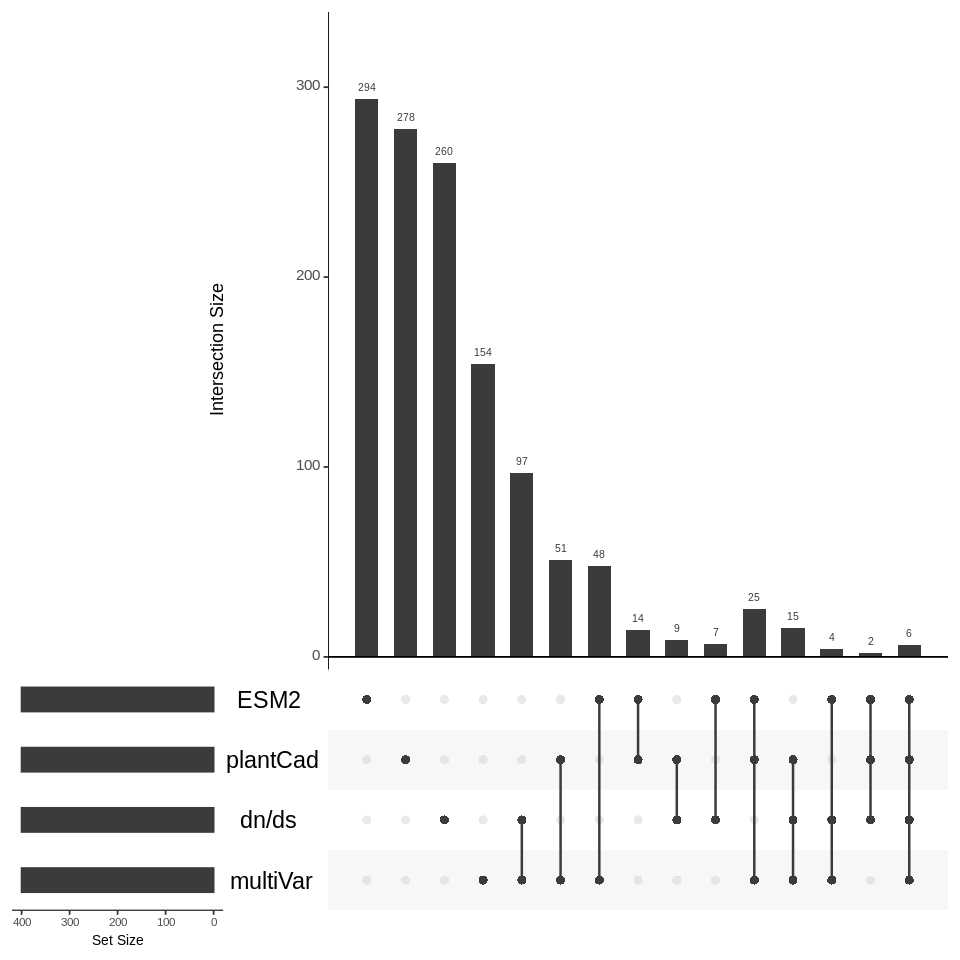

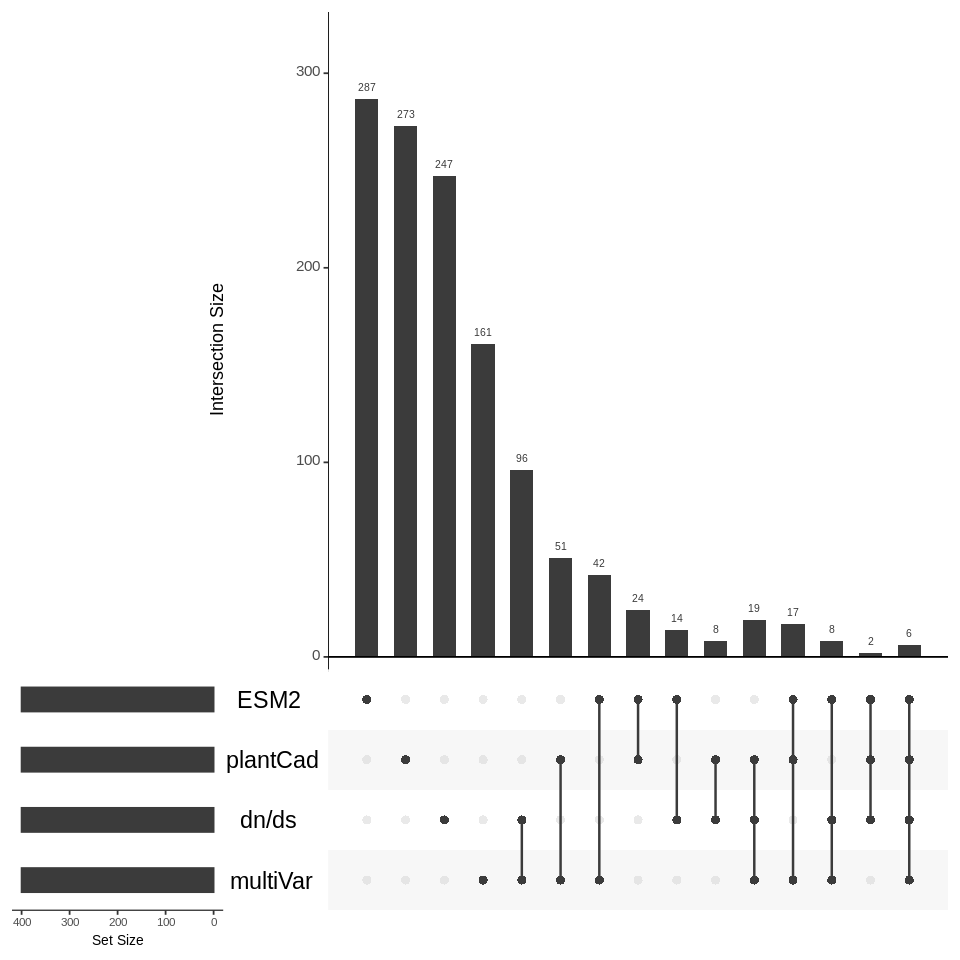

In [793]:
upset(fromList(poaceaeCandidates), text.scale = c(1.3, 1.3, 1, 1, 2, 1))
upset(fromList(poaceaeCandidates2), text.scale = c(1.3, 1.3, 1, 1, 2, 1))
upset(fromList(androCandidates), text.scale = c(1.3, 1.3, 1, 1, 2, 1))
upset(fromList(androCandidates2), text.scale = c(1.3, 1.3, 1, 1, 2, 1))

In [773]:
paste(mappingFileMerged[mappingFileMerged$OG%in%Reduce("intersect",poaceaeCandidates),3],collapse = " ")
paste(mappingFileMerged[mappingFileMerged$OG%in%Reduce("intersect",poaceaeCandidates2),3],collapse = " ")
paste(mappingFileMerged[mappingFileMerged$OG%in%Reduce("intersect",androCandidates),3],collapse = " ")
paste(mappingFileMerged[mappingFileMerged$OG%in%Reduce("intersect",androCandidates2),3],collapse = " ")

[1] "Zm00001eb252160_T001 Zm00001eb347550_T001"

[1] "Zm00001eb290720_T003 Zm00001eb115840_T001"

[1] "Zm00001eb252160_T001 Zm00001eb347550_T001 Zm00001eb414270_T001 Zm00001eb313000_T001 Zm00001eb390020_T001 Zm00001eb137060_T001"

[1] "NA Zm00001eb163510_T001 Zm00001eb006000_T001 Zm00001eb032630_T001 Zm00001eb400310_T003 Zm00001eb001990_T002"

In [710]:
Reduce("intersect",poaceaeCandidates2)
paste(mappingFileMerged[mappingFileMerged$OG%in%Reduce("intersect",poaceaeCandidates2),3],collapse = " ")

[1] "OG0011775" "OG0016353" "OG0021400"

[1] "Zm00001eb172160_T003 Zm00001eb290720_T003 Zm00001eb115840_T001"

In [666]:
tmpCommonIdx = Reduce("intersect",list(testRes_zs_andro$OG,testRes_zs_dna_andro$OG,testRes_dnds_andro$OG))
cor(cbind(testRes_zs_andro$Pval_envPC1[testRes_zs_andro$OG%in%tmpCommonIdx],
      testRes_zs_dna_andro$Pval_envPC1[testRes_zs_dna_andro$OG%in%tmpCommonIdx],
      testRes_dnds_andro$Pval_envPC1[testRes_dnds_andro$OG%in%tmpCommonIdx]))


1.00000000,0.10729249,0.04369729
0.10729249,1.00000000,0.09360231
0.04369729,0.09360231,1.00000000


In [563]:
cor(testData_merged$scaledScore[testData_merged$Frameshift==0],
    testData_merged$scaledScore_DNA[testData_merged$Frameshift==0],use = "complete")

[1] 0.2668695

In [797]:
contTab = table(rank(as.numeric(testRes_multiVar[,13]))<200,testRes_multiVar$OG%in%RAO[,2])
contTab
fisher.test(contTab,alternative = "greater")

       
        FALSE  TRUE
  FALSE 19006   177
  TRUE    195     4


	Fisher's Exact Test for Count Data

data:  contTab
p-value = 0.1164
alternative hypothesis: true odds ratio is greater than 1
95 percent confidence interval:
 0.7378484       Inf
sample estimates:
odds ratio 
  2.202645 


In [620]:
library(Biostrings)

Loading required package: XVector


Attaching package: ‘XVector’


The following object is masked from ‘package:purrr’:

    compact


Loading required package: GenomeInfoDb


Attaching package: ‘Biostrings’


The following object is masked from ‘package:ape’:

    complement


The following object is masked from ‘package:graph’:

    complement


The following object is masked from ‘package:base’:

    strsplit




In [622]:
queryOG = readAAStringSet("/workdir/sh2246/p_phyloGWAS/output/poaceaeHelixerOG_ancSeq_gapRemoved_v2_20240909.fa")
queryOG_length=width(queryOG)


In [626]:
names(queryOG_length) = names(queryOG)

In [ ]:
hist(queryOG_length[testRes])

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
   28.0   177.5   307.0   394.2   523.5  2498.0 

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
   49.0   156.5   301.0   347.8   475.0  1769.0 

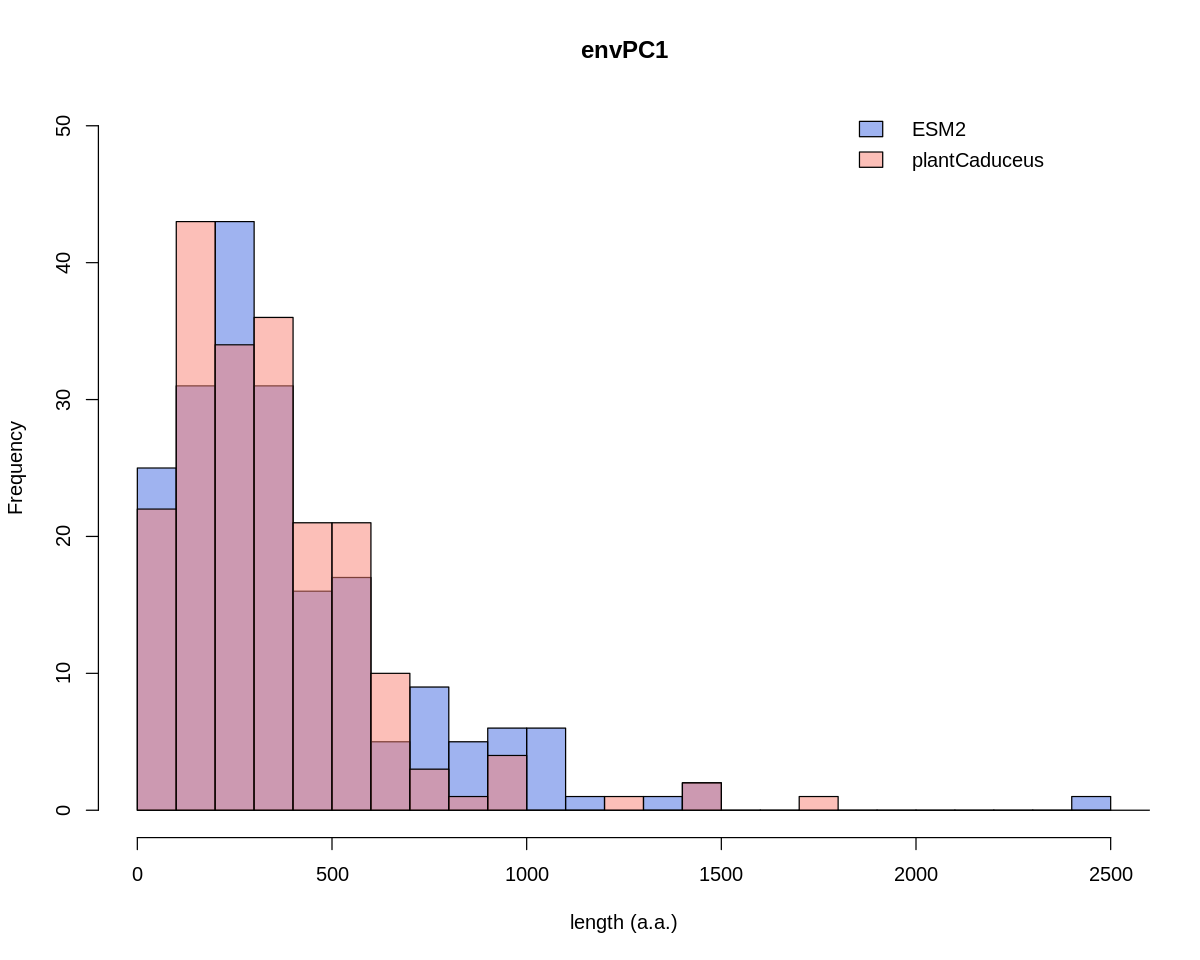

In [656]:
options(repr.plot.width=10, repr.plot.height=8)
hist(queryOG_length[testRes_zs$OG[rank(testRes_zs$Pval_envPC1) < 200]],breaks = seq(0,2500,100),ylim = c(0,50),
     main = "envPC1",xlab = "length (a.a.)",col = alpha("royalblue",.5))
hist(queryOG_length[testRes_zs_dna$OG[rank(testRes_zs_dna$Pval_envPC1) < 200]],breaks = seq(0,30000,100)
     ,add = T, col = alpha("salmon",.5))
legend("topright", legend = c("ESM2","plantCaduceus"),fill = alpha(c("royalblue","salmon"),.5),bty = 'n')
summary(queryOG_length[testRes_zs$OG[rank(testRes_zs$Pval_envPC1) < 200]])
summary(queryOG_length[testRes_zs_dna$OG[rank(testRes_zs_dna$Pval_envPC1) < 200]])

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
   32.0   173.0   285.0   338.7   435.5  1280.0 

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
   56.0   188.5   388.0   470.9   596.5  4195.0 

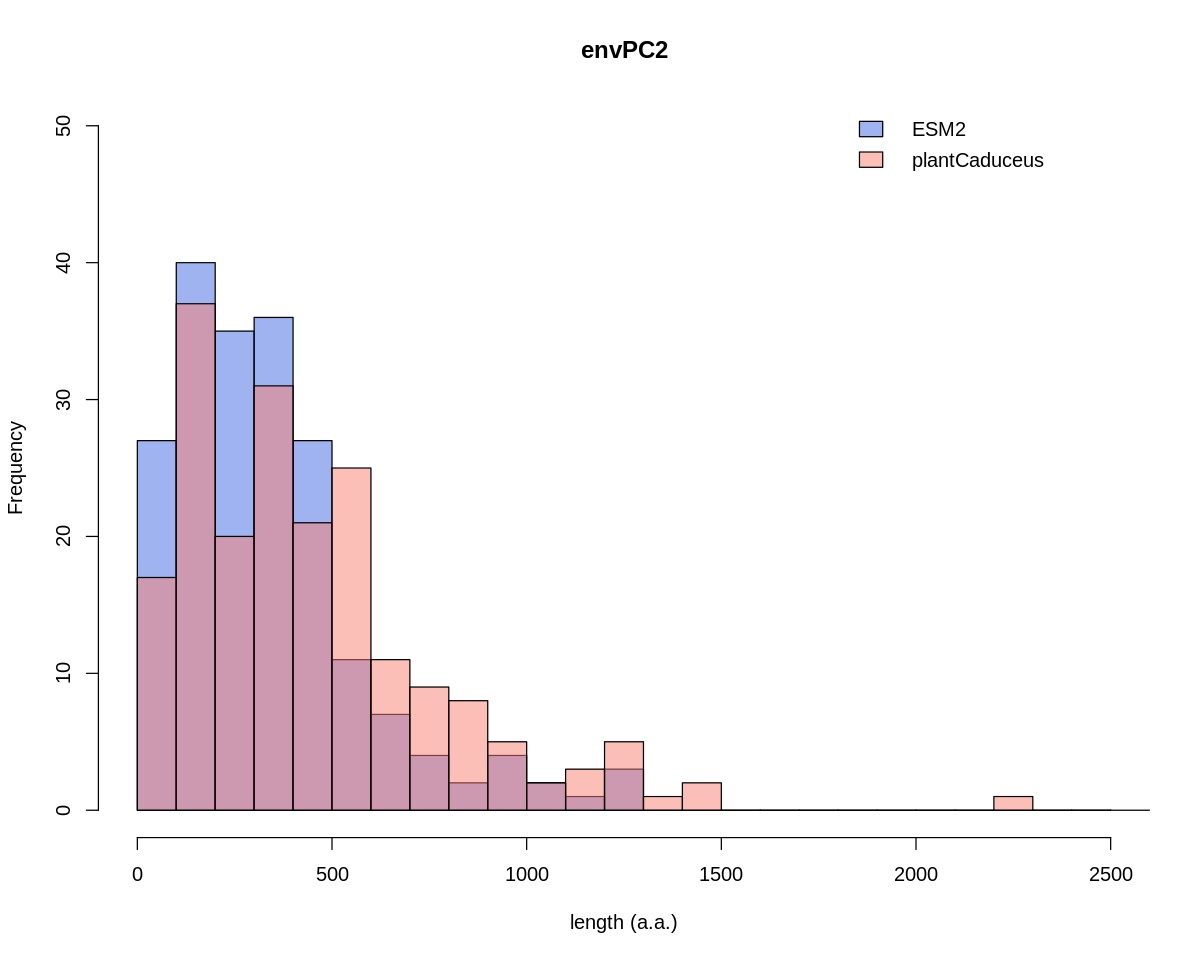

In [657]:
options(repr.plot.width=10, repr.plot.height=8)
hist(queryOG_length[testRes_zs$OG[rank(testRes_zs$Pval_envPC2) < 200]],breaks = seq(0,2500,100),ylim = c(0,50),
     main = "envPC2",xlab = "length (a.a.)",col = alpha("royalblue",.5))
hist(queryOG_length[testRes_zs_dna$OG[rank(testRes_zs_dna$Pval_envPC2) < 200]],breaks = seq(0,30000,100)
     ,add = T, col = alpha("salmon",.5))
legend("topright", legend = c("ESM2","plantCaduceus"),fill = alpha(c("royalblue","salmon"),.5),bty = 'n')
summary(queryOG_length[testRes_zs$OG[rank(testRes_zs$Pval_envPC2) < 200]])
summary(queryOG_length[testRes_zs_dna$OG[rank(testRes_zs_dna$Pval_envPC2) < 200]])

# candidate genes

In [467]:
paste(RAO[,1][RAO[,2]%in%testRes_zs$OG[testRes_zs$OG%in%RAO[,2]&as.numeric(testRes_zs[,12])<0.001]],collapse = ",")

paste(RAO[,1][RAO[,2]%in%testRes_zs_andro$OG[testRes_zs_andro$OG%in%RAO[,2]&as.numeric(testRes_zs_andro[,12])<0.001]],collapse = ",")

paste(RAO[,1][RAO[,2]%in%testRes_zs_dna$OG[testRes_zs_dna$OG%in%RAO[,2]&as.numeric(testRes_zs_dna[,12])<0.001]],collapse = ",")

paste(RAO[,1][RAO[,2]%in%testRes_zs_dna_andro$OG[testRes_zs_dna_andro$OG%in%RAO[,2]&as.numeric(testRes_zs_dna_andro[,12])<0.001]],collapse = ",")

[1] "AT4G22140.1,AT2G44520.1"

[1] "AT4G22140.1,AT1G03060.1,AT4G02725.1"

[1] "AT2G20190.1"

[1] "AT2G20190.1"

In [543]:
paste(RAO[,1][RAO[,2]%in%testRes_zs$OG[testRes_zs$OG%in%RAO[,2]&as.numeric(testRes_zs[,13])<0.005]],collapse = ",")

paste(RAO[,1][RAO[,2]%in%testRes_zs_andro$OG[testRes_zs_andro$OG%in%RAO[,2]&as.numeric(testRes_zs_andro[,13])<0.005]],collapse = ",")

paste(RAO[,1][RAO[,2]%in%testRes_zs_dna$OG[testRes_zs_dna$OG%in%RAO[,2]&as.numeric(testRes_zs_dna[,13])<0.005]],collapse = ",")

paste(RAO[,1][RAO[,2]%in%testRes_zs_dna_andro$OG[testRes_zs_dna_andro$OG%in%RAO[,2]&as.numeric(testRes_zs_dna_andro[,13])<0.005]],collapse = ",")

[1] "AT1G18330.2,AT1G56080.1,AT5G08130.8"

[1] "AT1G18330.2,AT2G14960.1,AT1G56080.1,AT5G08130.8"

[1] "AT3G53480.1,AT1G28130.1,AT3G54170.1,AT1G18330.2,AT2G20190.1,AT1G01140.3"

[1] "AT3G53480.1,AT1G28130.1,AT3G54170.1,AT1G18330.2,AT1G01140.3"

In [368]:
RAO[RAO[,2]%in%testRes_zs$OG[testRes_zs$OG%in%RAO[,2]&as.numeric(testRes_zs[,12])<0.001],]

,V1,V2
,<chr>,<chr>
7,AT4G22140.1,OG0002804
94,AT2G44520.1,OG0013140


In [370]:
RAO[RAO[,2]%in%testRes_zs_andro$OG[testRes_zs_andro$OG%in%RAO[,2]&as.numeric(testRes_zs_andro[,13])<0.01],]

,V1,V2
,<chr>,<chr>
64,AT1G18330.2,OG0010400
88,AT2G14960.1,OG0012339
127,AT1G56080.1,OG0015977
160,AT5G08130.8,OG0023794


In [468]:
RAO[RAO[,2]%in%testRes_zs_dna$OG[testRes_zs_dna$OG%in%RAO[,2]&as.numeric(testRes_zs_dna[,12])<0.001],]

,V1,V2
,<chr>,<chr>
11,AT2G20190.1,OG0003468


In [336]:
testRes_zs[testRes_zs$OG%in%RAO[,2]&as.numeric(testRes_zs[,12])<0.001,12:21]

,Pval_envPC1,Pval_envPC2,Pval_envPC3,Pval_envPC4,Pval_envPC5,Pval_envPC6,Pval_envPC7,Pval_envPC8,Pval_envPC9,Pval_envPC10
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1925,0.0005310962,0.1233479,0.4720928,0.1503000,0.0009312515,0.6588046,0.6931770,0.8800561,0.3454202,0.2039237
11109,0.0003246313,0.1529596,0.9331138,0.2162012,0.0006101856,0.7022275,0.6241877,0.4158413,0.5749178,0.8434982


In [366]:
testRes_zs_andro[testRes_zs_andro$OG%in%RAO[,2]&as.numeric(testRes_zs_andro[,13])<0.001,]

,OG,Coeff_envPC1,Coeff_envPC2,Coeff_envPC3,Coeff_envPC4,Coeff_envPC5,Coeff_envPC6,Coeff_envPC7,Coeff_envPC8,Coeff_envPC9,⋯,VAE_envPC3,VAE_envPC4,VAE_envPC5,VAE_envPC6,VAE_envPC7,VAE_envPC8,VAE_envPC9,VAE_envPC10,PvID,ZmID
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
10357,OG0012339,0.06291317,-0.1861186,-0.01433457,-0.06779721,0.04705979,-0.03335602,0.01320530,0.07993476,-0.05604722,⋯,0.0001126165,1.813940e-02,0.03081974,0.02808319,0.0003163265,0.02235608,0.04141926,0.01159569,Pavag03G286500.1,Zm00001eb152200_T001
13733,OG0015977,0.06999965,0.1293421,-0.03982555,-0.03456047,-0.02800597,-0.09975095,-0.02968569,0.07605729,-0.06124415,⋯,0.0104740687,1.176162e-05,0.01671633,0.19929848,0.0298454845,0.03129221,0.06231144,0.01016653,Pavag06G228100.1,Zm00001eb430930_T001


Warning message in cbind(...):
“number of rows of result is not a multiple of vector length (arg 1)”


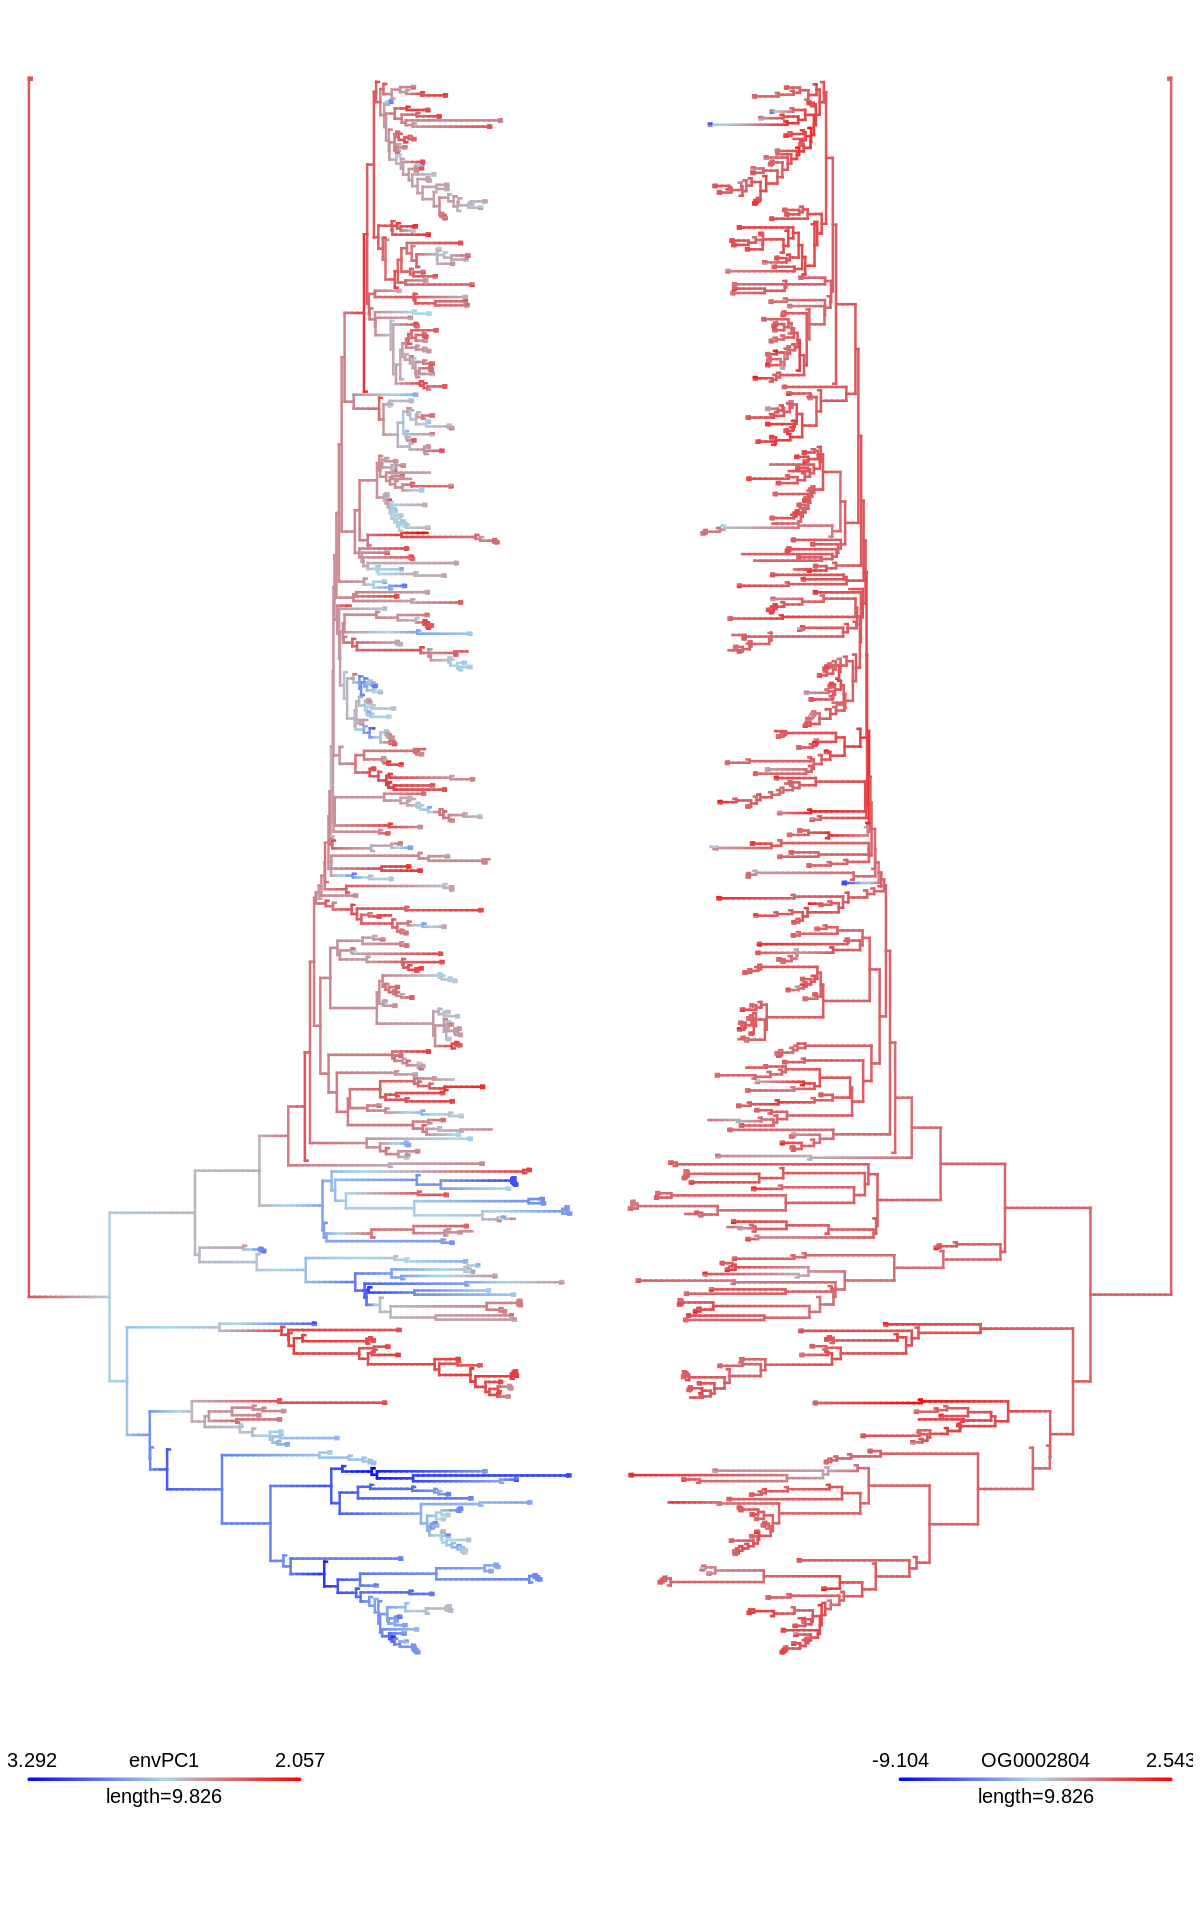

In [331]:
options(repr.plot.width=10, repr.plot.height=16)
par(mfrow = c(1,2))
plotTraitOnTree(envDf$envPC_1,
                commonID,spTre.rooted.filtered,visible_tip_labels = F,
                legend.title = "envPC1",col = c("blue","lightblue","red"))

plotTraitOnTree(tapply(testData_merged$scaledScore[testData_merged$OG%in%"OG0002804"],
                       testData_merged$assemblyID[testData_merged$OG%in%"OG0002804"],mean,na.rm = T),
                commonID,spTre.rooted.filtered,visible_tip_labels = F,direction = "leftwards",
                legend.title = "OG0002804",col = c("blue","lightblue","red"))


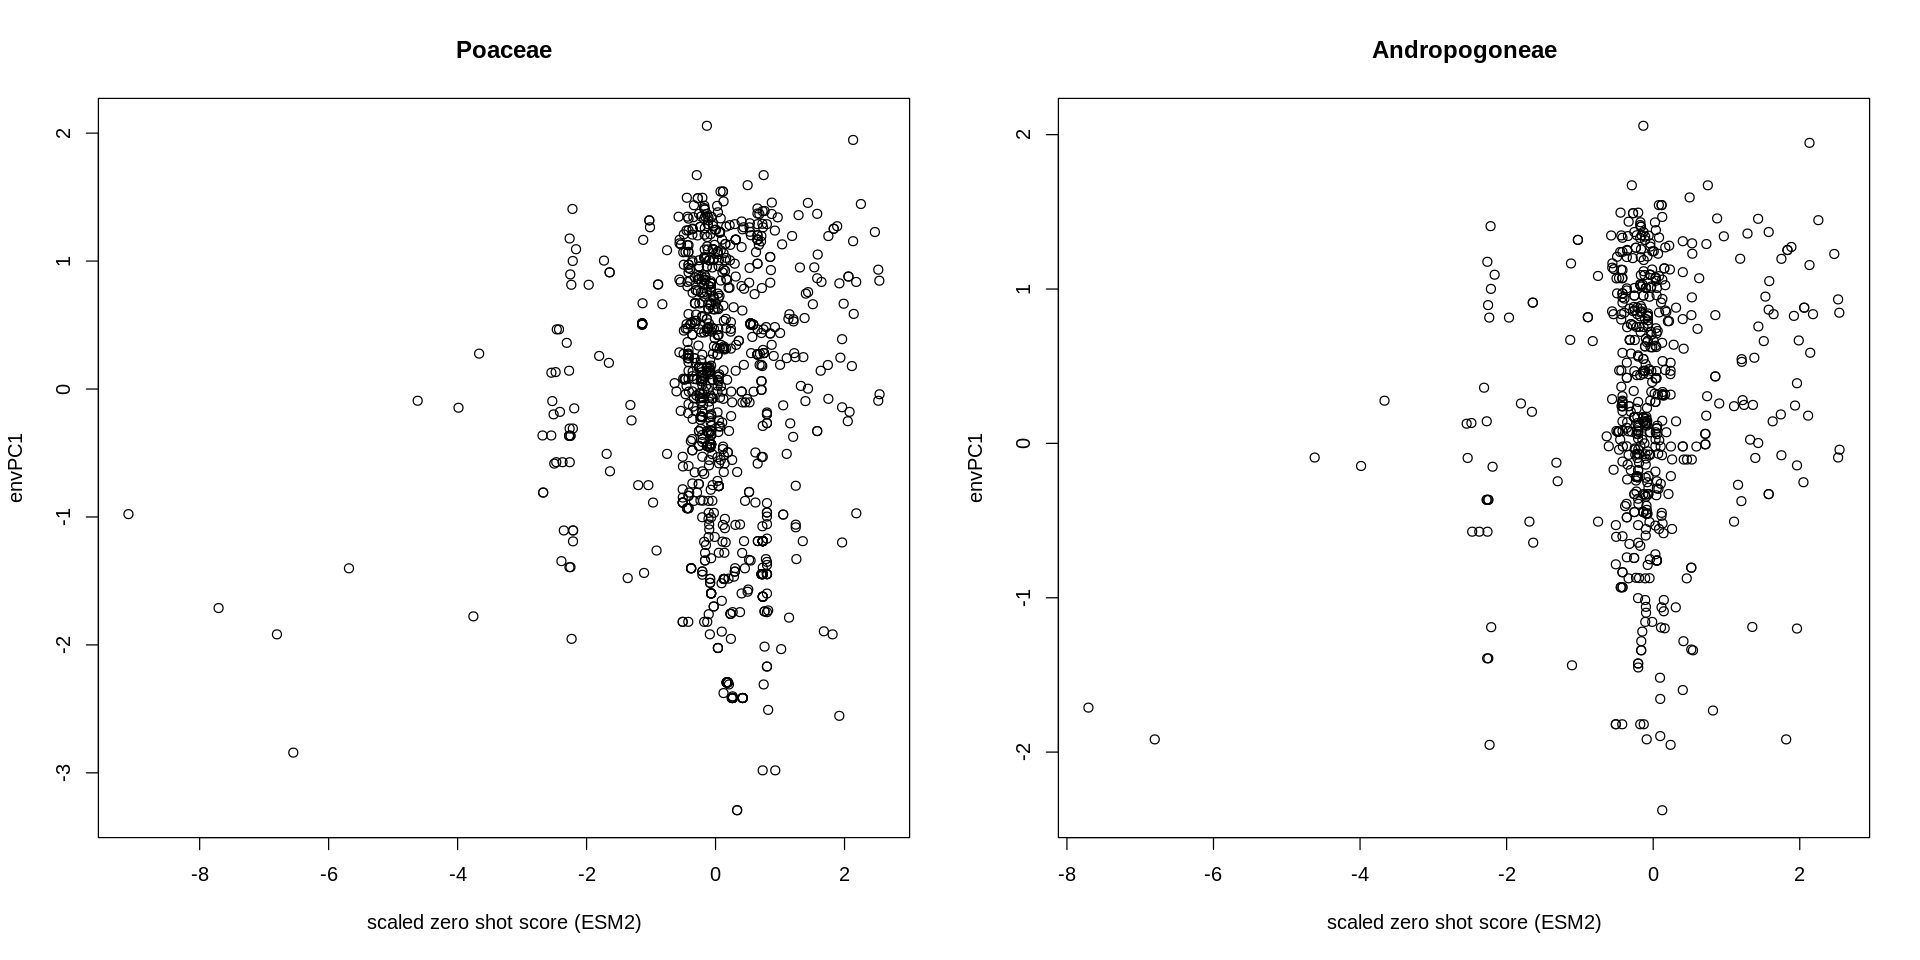

In [334]:
options(repr.plot.width=16, repr.plot.height=8)
par(mfrow = c(1,2))
plot(testData_merged$scaledScore[testData_merged$OG%in%"OG0002804"],
     testData_merged$envPC_1[testData_merged$OG%in%"OG0002804"],
     xlab = "scaled zero shot score (ESM2)",ylab = "envPC1",main = "Poaceae")

plot(testData_merged_andro$scaledScore[testData_merged_andro$OG%in%"OG0002804"],
     testData_merged_andro$envPC_1[testData_merged_andro$OG%in%"OG0002804"],
     xlab = "scaled zero shot score (ESM2)",ylab = "envPC1",main = "Andropogoneae")

Warning message in cbind(...):
“number of rows of result is not a multiple of vector length (arg 1)”


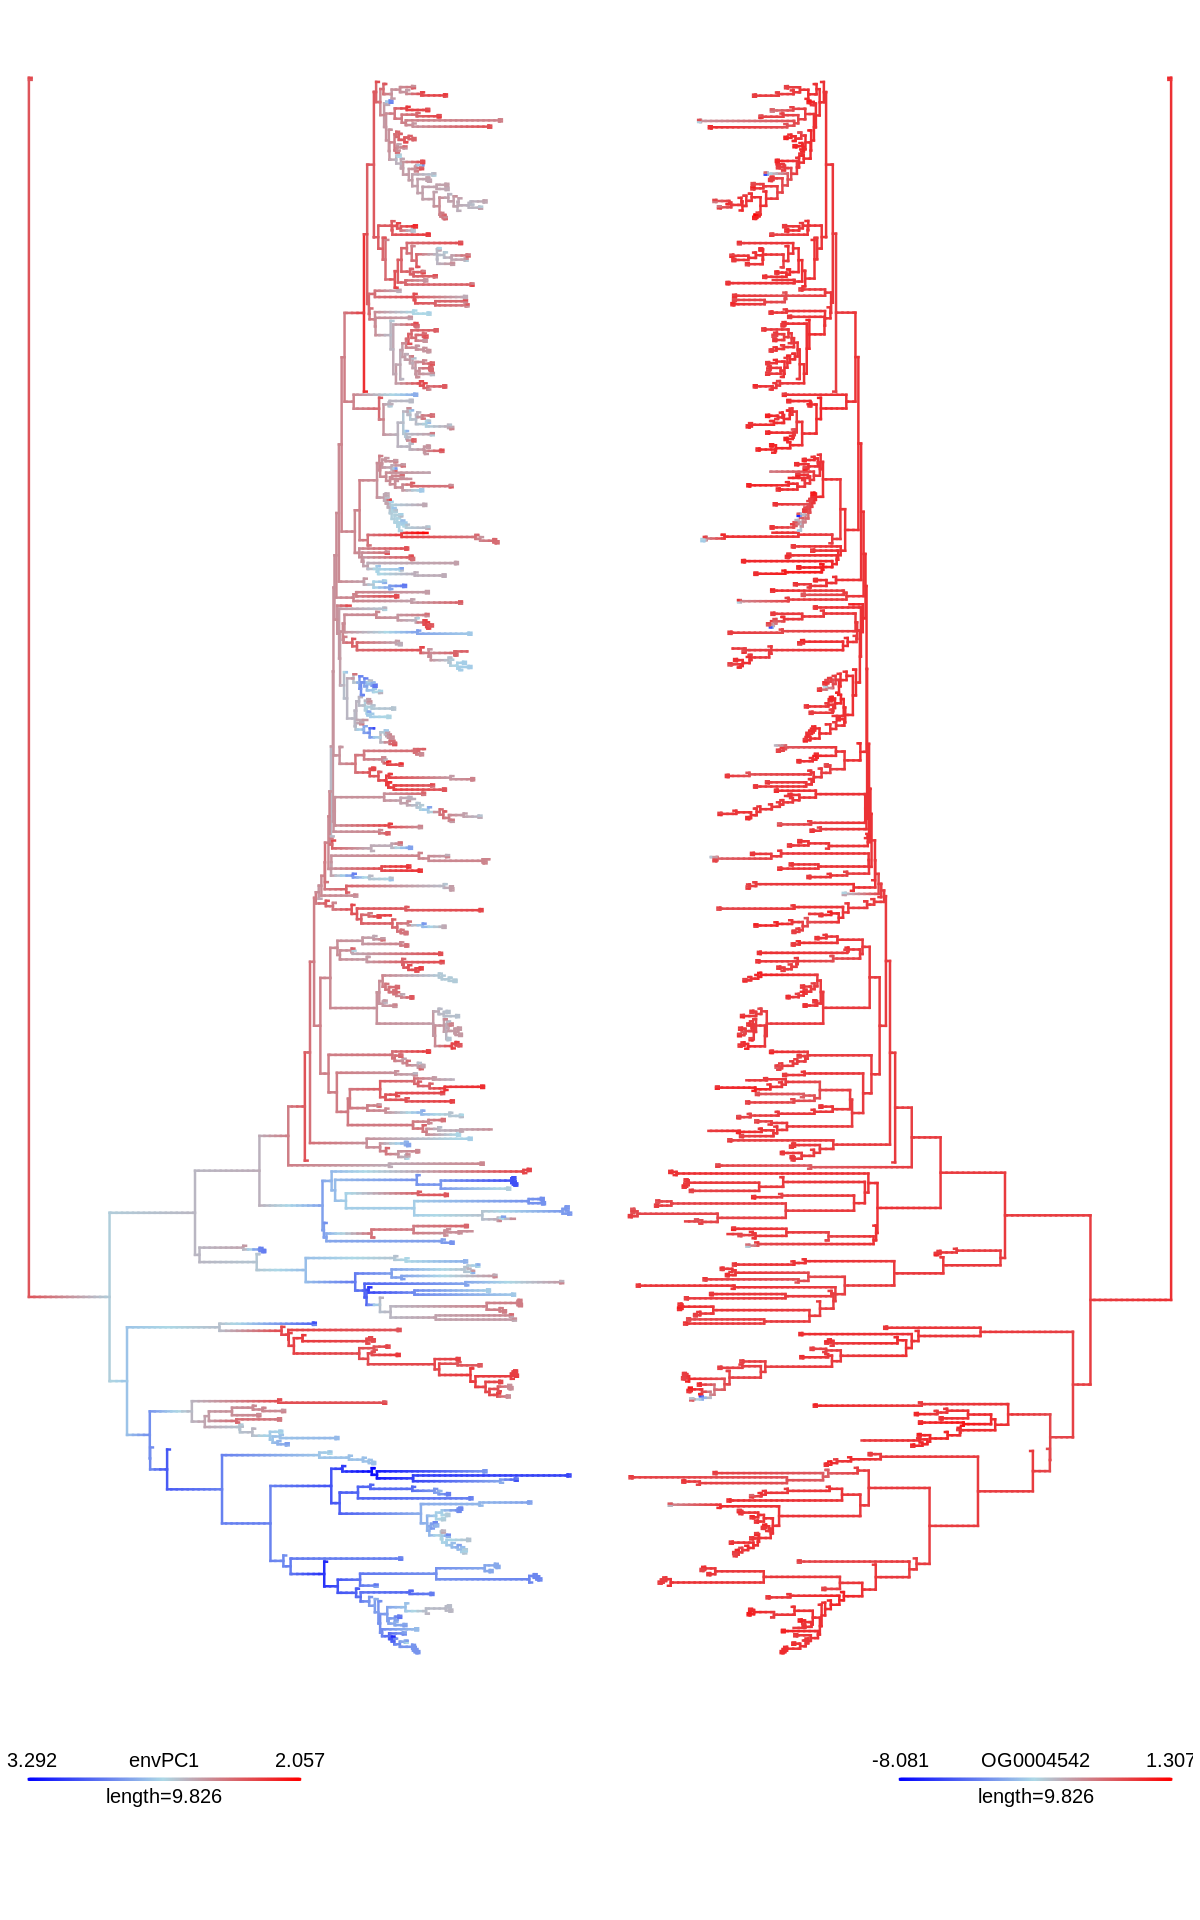

In [326]:
options(repr.plot.width=10, repr.plot.height=16)
par(mfrow = c(1,2))
plotTraitOnTree(envDf$envPC_1,
                commonID,spTre.rooted.filtered,visible_tip_labels = F,
                legend.title = "envPC1",col = c("blue","lightblue","red"))

plotTraitOnTree(tapply(testData_merged$scaledScore[testData_merged$OG%in%"OG0004542"],
                       testData_merged$assemblyID[testData_merged$OG%in%"OG0004542"],mean,na.rm = T),
                commonID,spTre.rooted.filtered,visible_tip_labels = F,direction = "leftwards",
                legend.title = "OG0004542",col = c("blue","lightblue","red"))


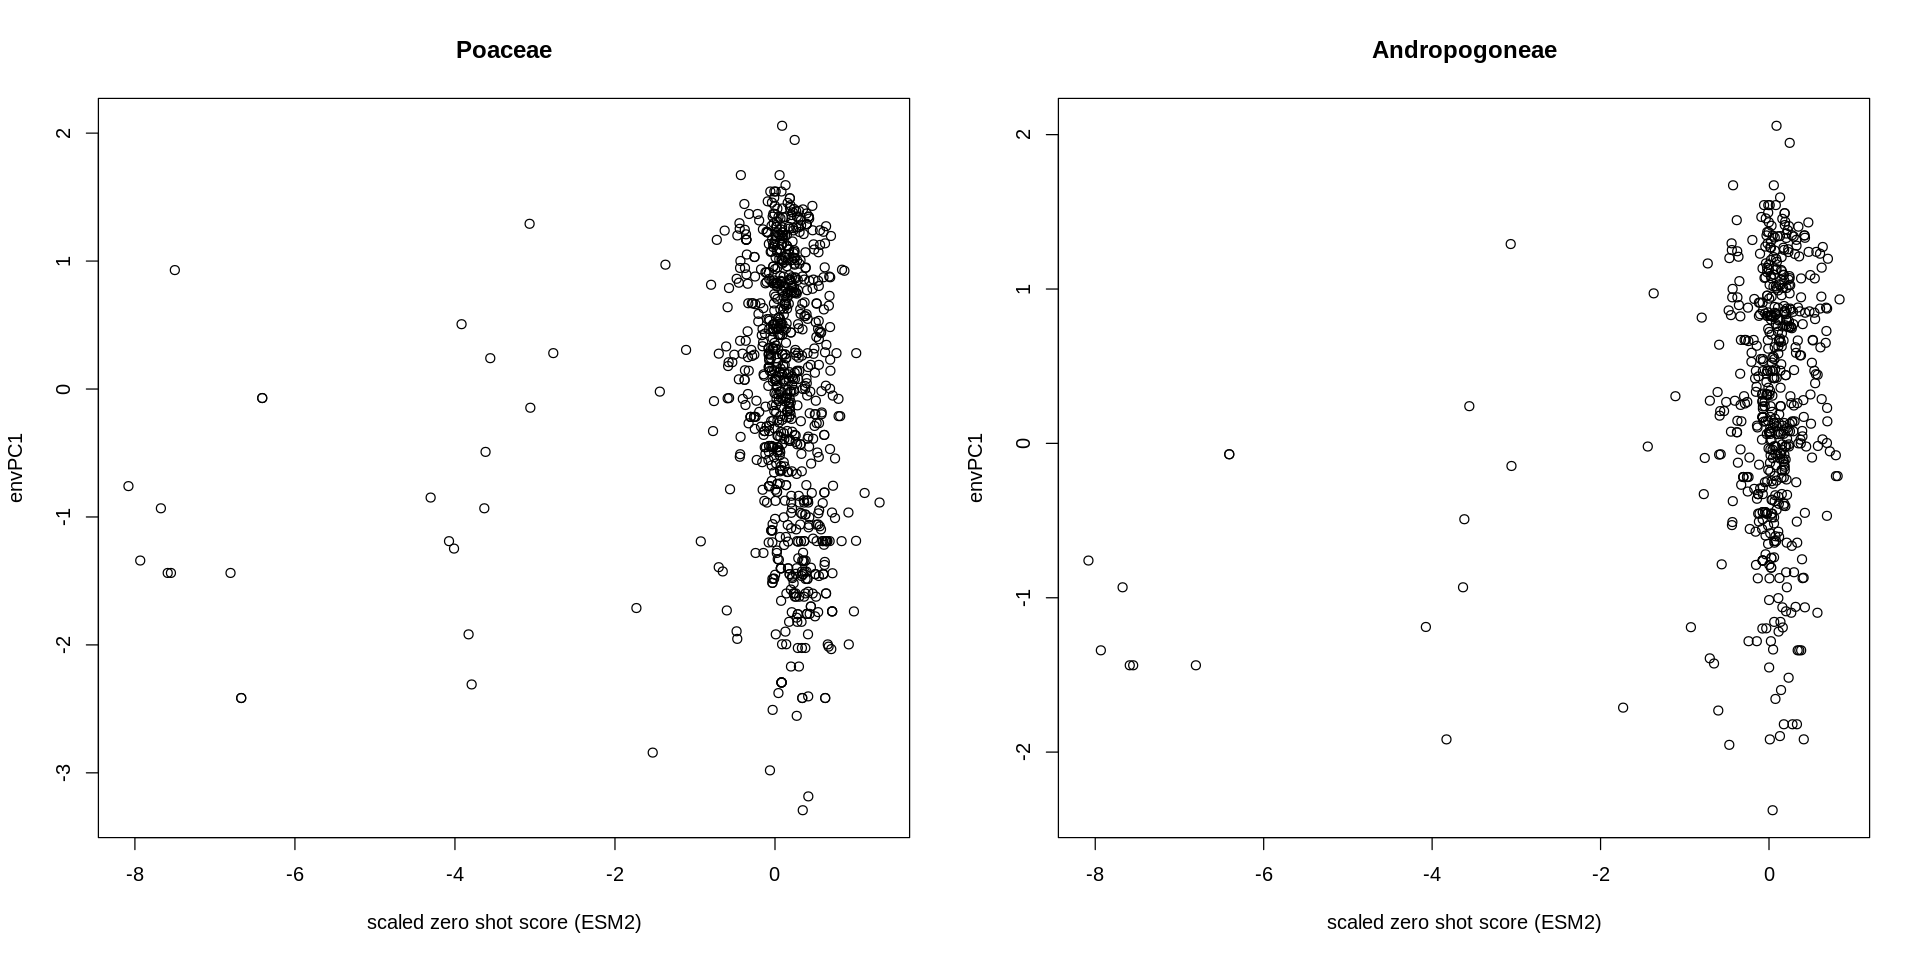

In [335]:
options(repr.plot.width=16, repr.plot.height=8)
par(mfrow = c(1,2))
plot(testData_merged$scaledScore[testData_merged$OG%in%"OG0004542"],
     testData_merged$envPC_1[testData_merged$OG%in%"OG0004542"],
     xlab = "scaled zero shot score (ESM2)",ylab = "envPC1",main = "Poaceae")

plot(testData_merged_andro$scaledScore[testData_merged_andro$OG%in%"OG0004542"],
     testData_merged_andro$envPC_1[testData_merged_andro$OG%in%"OG0004542"],
     xlab = "scaled zero shot score (ESM2)",ylab = "envPC1",main = "Andropogoneae")

seqID,zeroShotScore,scaledScore,assemblyID,seq1,Codons,Compared,Ambigiuous,Indels,Ns,⋯,envPC_37,envPC_38,envPC_39,envPC_40,PMS,AAlength,scaled.dn.ds,Frameshift,groups,groups2
<chr>,<dbl>,<dbl>,<fct>,<chr>,<int>,<int>,<int>,<int>,<int>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>,<dbl>,<int>,<chr>,<chr>
OG0004542:CPNAM-Leoti:0,1.397871,-8.080756,CPNAM-Leoti,OG0004542:ASM1935983v1:0,435,393,42,42,0,⋯,0.49857,-0.06174,-0.01857,0.15292,1,171,1.298637413,1,7,7
OG0004542:ASM2203655v1:1,1.456836,-7.933417,ASM2203655v1,OG0004542:ASM1935983v1:0,435,392,43,43,0,⋯,-0.80008,-0.24353,-0.81961,-0.26120,1,184,0.556726117,1,7,7
OG0004542:Bl-K1279B-DRAFT-PanAnd-1.0:0,1.560141,-7.675288,Bl-K1279B-DRAFT-PanAnd-1.0,OG0004542:ASM1935983v1:0,435,390,45,45,0,⋯,0.75669,-0.86941,-0.10914,0.69268,1,178,0.800066688,1,7,7
OG0004542:Sn-CAM1369-DRAFT-PanAnd-1.0:2,1.594229,-7.590112,Sn-CAM1369-DRAFT-PanAnd-1.0,OG0004542:ASM1935983v1:0,435,390,45,45,0,⋯,0.58202,-0.15204,0.38633,0.59221,1,120,0.717678907,1,7,7
OG0004542:Sn-CAM1369-DRAFT-PanAnd-1.0:0,1.610408,-7.549686,Sn-CAM1369-DRAFT-PanAnd-1.0,OG0004542:ASM1935983v1:0,435,390,45,45,0,⋯,0.58202,-0.15204,0.38633,0.59221,1,120,0.800066688,1,7,7
OG0004542:ASM519143v1:0,1.629917,-7.500939,ASM519143v1,OG0004542:ASM1935983v1:0,435,427,8,8,0,⋯,3.52768,-1.15146,-0.97873,-0.25620,1,113,-0.008853757,1,7,7
OG0004542:Sn-CAM1369-DRAFT-PanAnd-1.0:1,1.908466,-6.804925,Sn-CAM1369-DRAFT-PanAnd-1.0,OG0004542:ASM1935983v1:0,435,390,45,45,0,⋯,0.58202,-0.15204,0.38633,0.59221,1,207,0.781985738,1,7,7
OG0004542:Poa_pratensis_v1:1,1.961945,-6.671295,Poa_pratensis_v1,OG0004542:ASM1935983v1:0,435,396,39,39,0,⋯,1.25050,-0.58874,-0.44798,-0.14644,1,118,0.221470074,1,7,7
OG0004542:Pp-Kellogg1297-DRAFT-PanAnd-1.0:1,1.961945,-6.671295,Pp-Kellogg1297-DRAFT-PanAnd-1.0,OG0004542:ASM1935983v1:0,435,396,39,39,0,⋯,1.25050,-0.58874,-0.44798,-0.14644,1,118,0.221470074,1,7,7


seqID,zeroShotScore,scaledScore,assemblyID,seq1,Codons,Compared,Ambigiuous,Indels,Ns,⋯,envPC_37,envPC_38,envPC_39,envPC_40,PMS,AAlength,scaled.dn.ds,Frameshift,groups,groups2
<chr>,<dbl>,<dbl>,<fct>,<chr>,<int>,<int>,<int>,<int>,<int>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>,<dbl>,<int>,<chr>,<chr>
OG0004542:FB19_028_3:1,4.964895,0.8322180,FB19_028_3,OG0004542:ASM1935983v1:0,435,395,40,40,0,⋯,0.21703,0.38884,-0.86176,-0.61723,0,461,-1.17855623,0,1,1
OG0004542:AN22TNTL166:0,4.967090,0.8377028,AN22TNTL166,OG0004542:ASM1935983v1:0,435,419,16,16,0,⋯,-1.49298,-0.44189,-1.06820,0.02118,0,392,-0.65283752,0,2,1
OG0004542:Urochloa_brizantha:0,4.979072,0.8676417,Urochloa_brizantha,OG0004542:ASM1935983v1:0,435,424,11,11,0,⋯,-1.84897,-0.23233,0.78735,0.92184,0,336,-0.03792206,0,2,1
OG0004542:aegilops_speltoides_cv_tivon:0,4.999209,0.9179573,aegilops_speltoides_cv_tivon,OG0004542:ASM1935983v1:0,435,395,40,40,0,⋯,0.13709,0.36072,0.71933,-0.46848,0,454,-0.98599353,0,1,1
OG0004542:Aegilops_cylindrica:0,5.000888,0.9221543,Aegilops_cylindrica,OG0004542:ASM1935983v1:0,435,429,6,6,0,⋯,-0.64399,-0.53801,-0.55001,0.88753,0,285,-2.02114405,0,1,1
OG0004542:Rye_Lo7_2018_v1p1p1:0,5.026656,0.9865399,Rye_Lo7_2018_v1p1p1,OG0004542:ASM1935983v1:0,435,394,41,41,0,⋯,0.09059,-0.27538,0.89873,-0.64204,0,453,-0.77103449,0,2,1
OG0004542:ERR7747980:0,5.037281,1.0130895,ERR7747980,OG0004542:ASM1935983v1:0,435,434,1,1,0,⋯,0.09048,-0.08932,0.42623,0.40986,0,309,-0.56881779,0,2,1
OG0004542:TAN1-04B:0,5.038142,1.0152396,TAN1-04B,OG0004542:ASM1935983v1:0,435,433,2,2,0,⋯,-0.19287,-0.01571,0.12013,0.53122,0,325,-1.38266540,0,1,1
OG0004542:Avena_hirtula:1,5.080052,1.1199615,Avena_hirtula,OG0004542:ASM1935983v1:0,435,425,10,10,0,⋯,-0.31470,0.44709,0.01839,-1.09532,0,336,-1.44280030,0,1,1


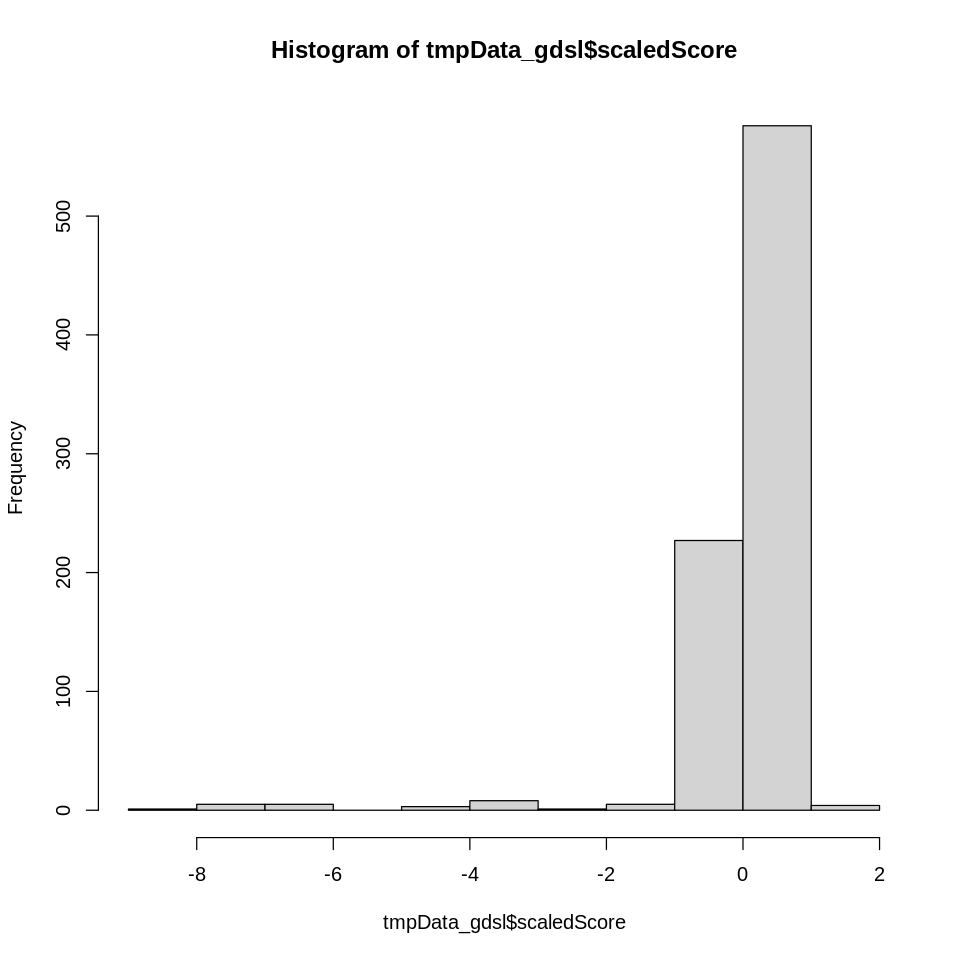

In [324]:
tmpData_gdsl = testData_merged[testData_merged$OG == 'OG0004542',]

options(repr.plot.width=8, repr.plot.height=8)
hist(tmpData_gdsl$scaledScore)


head(tmpData_gdsl[order(tmpData_gdsl$scaledScore),],10)
tail(tmpData_gdsl[order(tmpData_gdsl$scaledScore),],10)

seqID,zeroShotScore,scaledScore,assemblyID,seq1,Codons,Compared,Ambigiuous,Indels,Ns,⋯,envPC_39,envPC_40,PMS,AAlength,scaled.dn.ds,Frameshift,groups,groups2,zeroShotScore_DNA,scaledScore_DNA
<chr>,<dbl>,<dbl>,<fct>,<chr>,<int>,<int>,<int>,<int>,<int>,⋯,<dbl>,<dbl>,<int>,<int>,<dbl>,<int>,<chr>,<chr>,<dbl>,<dbl>
OG0002804:SRR23019232:0,3.156261,-9.104309,SRR23019232,OG0002804:ASM1935983v1:0,217,217,0,0,0,⋯,0.26734,-0.30848,1,134,-0.9276869,1,7,7,3.030512,-0.5479178
OG0002804:AN21TSTL0263:0,3.768542,-7.706287,AN21TSTL0263,OG0002804:ASM1935983v1:0,217,217,0,0,0,⋯,0.07672,-0.21687,0,48,-2.9263830,0,1,1,3.727407,2.7579602
OG0002804:AN21TSTL0264:0,4.164805,-6.801500,AN21TSTL0264,OG0002804:ASM1935983v1:0,217,217,0,0,0,⋯,-1.05072,0.56063,0,48,-2.9901594,0,1,1,3.542567,1.8811289
OG0002804:SRR8208366:0,4.275817,-6.548025,SRR8208366,OG0002804:ASM1935983v1:0,217,213,4,4,0,⋯,-0.13033,0.40564,1,155,1.1418075,1,7,7,2.363305,-3.7129621
OG0002804:ASM2073952v1:1,4.653929,-5.684681,ASM2073952v1,OG0002804:ASM1935983v1:0,217,217,0,0,0,⋯,0.34125,-0.32487,1,173,1.8379428,1,7,7,2.560084,-2.7794975
OG0002804:AN20T027:0,5.120596,-4.619141,AN20T027,OG0002804:ASM1935983v1:0,217,217,0,0,0,⋯,-0.49081,0.03058,0,98,-2.7379291,0,1,1,3.641887,2.3522742
OG0002804:AN22TNTL007:0,5.397756,-3.986303,AN22TNTL007,OG0002804:ASM1935983v1:0,217,217,0,0,0,⋯,0.00257,0.52521,0,101,-2.7171783,0,1,1,3.304089,0.7498536
OG0002804:Bromus_tectorum:0,5.498890,-3.755383,Bromus_tectorum,OG0002804:ASM1935983v1:0,217,214,3,3,0,⋯,0.98551,0.21937,1,178,0.2988775,1,7,7,2.324712,-3.8960336
OG0002804:AN21TS51:0,5.537912,-3.666282,AN21TS51,OG0002804:ASM1935983v1:0,217,213,4,4,0,⋯,-1.41493,-0.72572,0,208,2.1345638,0,2,4,2.542041,-2.8650872


seqID,zeroShotScore,scaledScore,assemblyID,seq1,Codons,Compared,Ambigiuous,Indels,Ns,⋯,envPC_39,envPC_40,PMS,AAlength,scaled.dn.ds,Frameshift,groups,groups2,zeroShotScore_DNA,scaledScore_DNA
<chr>,<dbl>,<dbl>,<fct>,<chr>,<int>,<int>,<int>,<int>,<int>,⋯,<dbl>,<dbl>,<int>,<int>,<dbl>,<int>,<chr>,<chr>,<dbl>,<dbl>
OG0002804:AN22TNTL073:0,8.077745,2.132919,AN22TNTL073,OG0002804:ASM1935983v1:0,217,216,1,1,0,⋯,-0.66743,0.78502,0,164,-2.260073,0,1,1,3.473223,1.552182
OG0002804:AN21TNTL0117:0,8.082059,2.142768,AN21TNTL0117,OG0002804:ASM1935983v1:0,217,217,0,0,0,⋯,-0.11824,-1.41769,0,163,-1.899986,0,1,1,3.623897,2.266935
OG0002804:AN21TSTL0179:1,8.098733,2.180841,AN21TSTL0179,OG0002804:ASM1935983v1:0,217,216,1,1,0,⋯,0.38707,0.58807,0,164,-2.350364,0,1,1,3.411331,1.258580
OG0002804:SRR23019076:0,8.099519,2.182636,SRR23019076,OG0002804:ASM1935983v1:0,217,217,0,0,0,⋯,0.20120,1.13536,0,139,-1.711615,0,1,1,4.079245,4.426981
OG0002804:AN22TNTL108:0,8.130654,2.253727,AN22TNTL108,OG0002804:ASM1935983v1:0,217,216,1,1,0,⋯,0.59396,-0.04904,0,164,-2.178603,0,1,1,3.494800,1.654534
OG0002804:AN21TSTL0228:0,8.225868,2.471128,AN21TSTL0228,OG0002804:ASM1935983v1:0,217,216,1,1,0,⋯,0.67043,-0.94300,0,141,-2.583845,0,1,1,3.696852,2.613012
OG0002804:AN22TNTL166:0,8.248694,2.523246,AN22TNTL166,OG0002804:ASM1935983v1:0,217,216,1,1,0,⋯,-1.06820,0.02118,0,164,-2.506123,0,1,1,3.412177,1.262596
OG0002804:MCRTL011:0,8.248694,2.523246,MCRTL011,OG0002804:ASM1935983v1:0,217,216,1,1,0,⋯,-0.49081,0.03058,0,164,-2.543792,0,1,1,3.408718,1.246188
OG0002804:MCRTL030:0,8.256015,2.539963,MCRTL030,OG0002804:ASM1935983v1:0,217,217,0,0,0,⋯,0.32350,0.00797,0,120,-2.793019,0,1,1,3.936357,3.749156


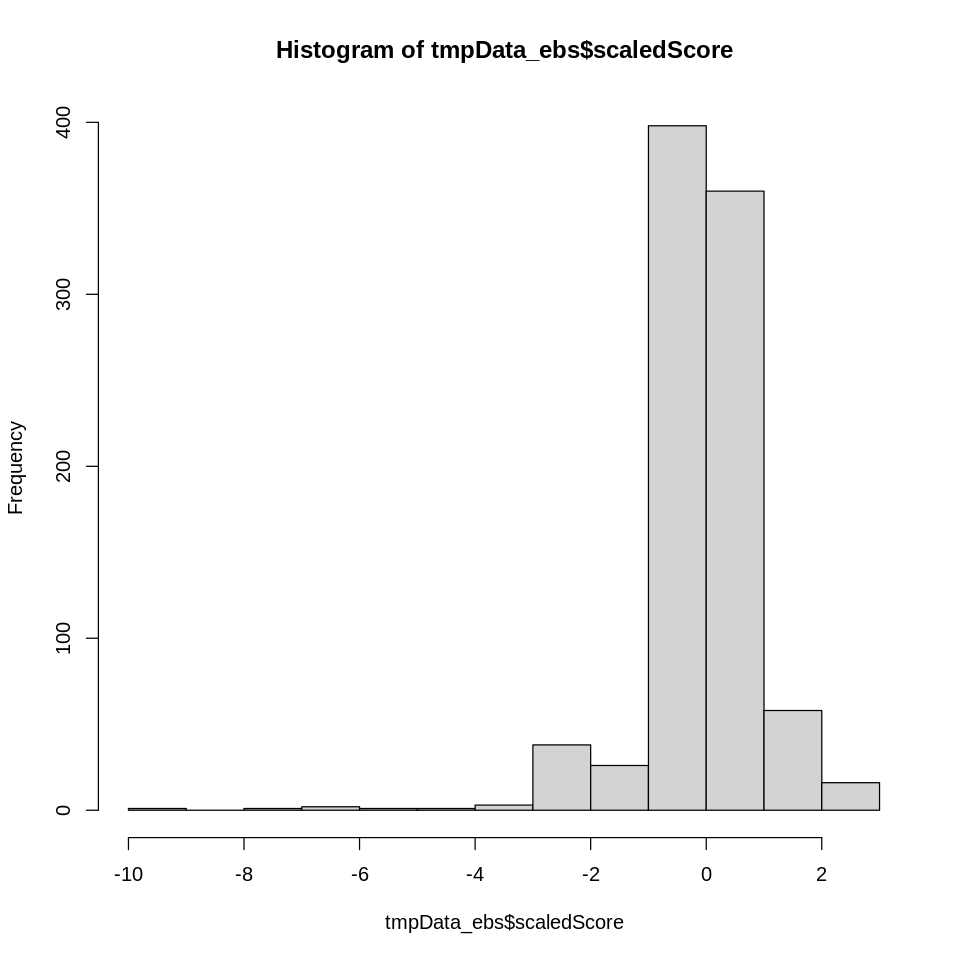

In [475]:
tmpData_ebs = testData_merged[testData_merged$OG == 'OG0002804',]

options(repr.plot.width=8, repr.plot.height=8)
hist(tmpData_ebs$scaledScore)


head(tmpData_ebs[order(tmpData_ebs$scaledScore),],10)
tail(tmpData_ebs[order(tmpData_ebs$scaledScore),],10)

seqID,zeroShotScore,scaledScore,assemblyID,seq1,Codons,Compared,Ambigiuous,Indels,Ns,⋯,envPC_37,envPC_38,envPC_39,envPC_40,PMS,AAlength,scaled.dn.ds,Frameshift,groups,groups2
<chr>,<dbl>,<dbl>,<fct>,<chr>,<int>,<int>,<int>,<int>,<int>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>,<dbl>,<int>,<chr>,<chr>
OG0018953:Sn-CAM1369-DRAFT-PanAnd-1.0:1,1.516864,-11.003453,Sn-CAM1369-DRAFT-PanAnd-1.0,OG0018953:ASM1935983v1:0,222,219,3,3,0,⋯,0.58202,-0.15204,0.38633,0.59221,1,20,-0.27429068,1,7,7
OG0018953:ASM980554v1:0,2.831890,-7.894486,ASM980554v1,OG0018953:ASM1935983v1:0,222,217,5,5,0,⋯,-0.01495,-0.64481,-0.04990,0.93964,1,62,0.05001889,1,7,7
OG0018953:AN22TNTL092:0,2.962777,-7.585043,AN22TNTL092,OG0018953:ASM1935983v1:0,222,220,2,2,0,⋯,-0.64367,1.09877,-0.94524,-0.44950,1,130,-0.01192610,1,7,7
OG0018953:TSU_Scap_1:1,3.014433,-7.462920,TSU_Scap_1,OG0018953:ASM1935983v1:0,222,222,0,0,0,⋯,-0.25395,-0.03396,-0.67576,0.46953,1,60,0.69998741,1,7,7
OG0018953:AN21TNTL0082:0,3.098895,-7.263236,AN21TNTL0082,OG0018953:ASM1935983v1:0,222,221,1,1,0,⋯,-1.19487,0.21927,-0.29435,-1.22959,0,100,-0.83197959,0,1,1
OG0018953:AN22TNTL008:0,3.114162,-7.227142,AN22TNTL008,OG0018953:ASM1935983v1:0,222,217,5,5,0,⋯,-1.76197,0.44634,3.06887,-1.70034,0,112,1.31514272,0,1,3
OG0018953:AN21TSTL0264:0,3.184432,-7.061010,AN21TSTL0264,OG0018953:ASM1935983v1:0,222,221,1,1,0,⋯,-0.14986,-1.29181,-1.05072,0.56063,0,100,-0.69353201,0,1,1
OG0018953:AN21TSTL0231:0,3.205231,-7.011838,AN21TSTL0231,OG0018953:ASM1935983v1:0,222,219,3,3,0,⋯,0.46633,0.20880,0.40865,0.19225,0,88,-0.71509094,0,1,1
OG0018953:AN21TS46:0,3.425467,-6.491159,AN21TS46,OG0018953:ASM1935983v1:0,222,219,3,3,0,⋯,-0.93803,-0.03743,1.21567,1.27253,0,59,-0.65121256,0,1,1


seqID,zeroShotScore,scaledScore,assemblyID,seq1,Codons,Compared,Ambigiuous,Indels,Ns,⋯,envPC_37,envPC_38,envPC_39,envPC_40,PMS,AAlength,scaled.dn.ds,Frameshift,groups,groups2
<chr>,<dbl>,<dbl>,<fct>,<chr>,<int>,<int>,<int>,<int>,<int>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>,<dbl>,<int>,<chr>,<chr>
OG0018953:AN21TS31:0,6.793822,1.472261,AN21TS31,OG0018953:ASM1935983v1:0,222,219,3,3,0,⋯,0.57744,-0.67764,0.28869,-1.57722,0,164,-2.207847,0,1,1
OG0018953:AN21TS26:1,6.797312,1.480513,AN21TS26,OG0018953:ASM1935983v1:0,222,222,0,0,0,⋯,7.51903,0.11048,-0.65696,4.09849,0,153,-2.318765,0,1,1
OG0018953:AN21TNTL0154:0,6.805042,1.498788,AN21TNTL0154,OG0018953:ASM1935983v1:0,222,222,0,0,0,⋯,-0.43203,-0.49288,-0.42428,-0.42454,0,164,-2.511402,0,1,1
OG0018953:AN21TSTL0280:0,6.811132,1.513185,AN21TSTL0280,OG0018953:ASM1935983v1:0,222,222,0,0,0,⋯,-0.58452,-0.19888,0.33586,-0.11080,0,164,-2.542921,0,1,1
OG0018953:AN21TNTL0161:0,6.817631,1.528551,AN21TNTL0161,OG0018953:ASM1935983v1:0,222,222,0,0,0,⋯,-2.17340,1.07282,2.20607,-0.58784,0,139,-2.638646,0,1,1
OG0018953:SRR7121975:0,6.836202,1.572455,SRR7121975,OG0018953:ASM1935983v1:0,222,222,0,0,0,⋯,-3.33049,0.11854,1.14936,2.12431,0,162,-2.352751,0,1,1
OG0018953:AT20TS1MCRTL004:0,6.839406,1.580030,AT20TS1MCRTL004,OG0018953:ASM1935983v1:0,222,219,3,3,0,⋯,1.90236,-1.92798,0.37701,-0.49245,0,164,-2.384418,0,1,1
OG0018953:AN21TS26:0,6.851646,1.608967,AN21TS26,OG0018953:ASM1935983v1:0,222,222,0,0,0,⋯,7.51903,0.11048,-0.65696,4.09849,0,153,-2.308441,0,1,1
OG0018953:SRR7121975:1,6.933644,1.802826,SRR7121975,OG0018953:ASM1935983v1:0,222,222,0,0,0,⋯,-3.33049,0.11854,1.14936,2.12431,0,162,-2.359908,0,1,1


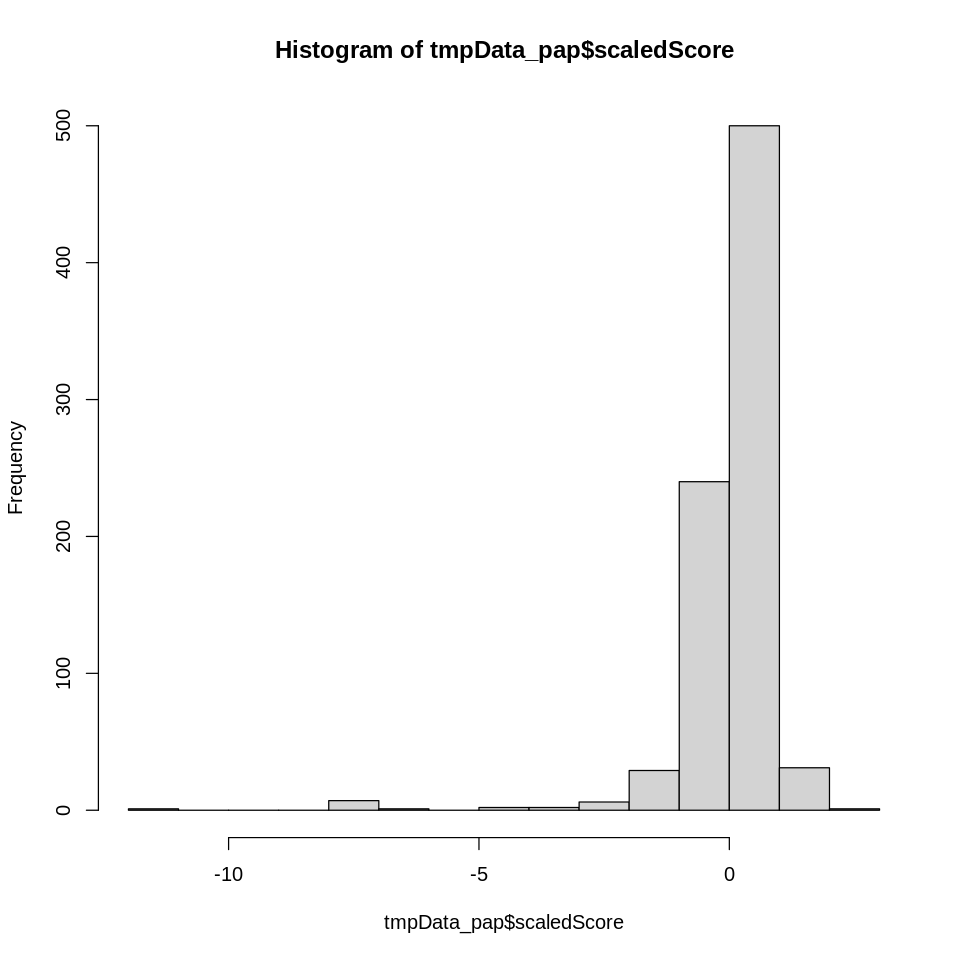

In [376]:
tmpData_pap = testData_merged[testData_merged$OG == 'OG0018953',]

options(repr.plot.width=8, repr.plot.height=8)
hist(tmpData_pap$scaledScore)


head(tmpData_pap[order(tmpData_pap$scaledScore),],10)
tail(tmpData_pap[order(tmpData_pap$scaledScore),],10)

seqID,zeroShotScore,scaledScore,assemblyID,seq1,Codons,Compared,Ambigiuous,Indels,Ns,⋯,envPC_39,envPC_40,PMS,AAlength,scaled.dn.ds,Frameshift,groups,groups2,zeroShotScore_DNA,scaledScore_DNA
<chr>,<dbl>,<dbl>,<fct>,<chr>,<int>,<int>,<int>,<int>,<int>,⋯,<dbl>,<dbl>,<int>,<int>,<dbl>,<int>,<chr>,<chr>,<dbl>,<dbl>
OG0015019:AN22TNTL170:0,1.352833,-9.561735,AN22TNTL170,OG0015019:ASM1935983v1:0,370,361,9,9,0,⋯,0.58021,0.95084,1,113,3.77074537,1,7,7,2.176189,-3.17738045
OG0015019:ASM163321v2:0,1.565130,-8.994142,ASM163321v2,OG0015019:ASM1935983v1:0,370,369,1,1,0,⋯,-0.04288,0.41473,1,174,5.86046819,1,7,7,3.140408,0.01687478
OG0015019:Phyllostachys_bambusoides:0,2.121734,-7.506018,Phyllostachys_bambusoides,OG0015019:ASM1935983v1:0,370,370,0,0,0,⋯,0.55359,0.25375,1,171,1.66193992,1,7,7,3.163335,0.09282444
OG0015019:AN21TSTL0264:0,2.770529,-5.771415,AN21TSTL0264,OG0015019:ASM1935983v1:0,370,367,3,3,0,⋯,-1.05072,0.56063,0,67,-2.17235006,0,1,1,3.739736,2.00232176
OG0015019:AN21TSTL0241:0,2.836366,-5.595396,AN21TSTL0241,OG0015019:ASM1935983v1:0,370,369,1,1,0,⋯,0.58021,0.95084,1,20,1.82809948,1,7,7,2.923868,-0.70047966
OG0015019:ChrysopogonNigritanus_v1.0:0,2.839891,-5.585970,ChrysopogonNigritanus_v1.0,OG0015019:ASM1935983v1:0,370,369,1,1,0,⋯,-0.48072,0.20626,1,54,-0.18737704,1,7,7,2.689865,-1.47567977
OG0015019:AN21TNTL0083:0,2.942045,-5.312855,AN21TNTL0083,OG0015019:ASM1935983v1:0,370,368,2,2,0,⋯,1.22322,1.29308,1,107,-0.03923061,1,7,7,2.987753,-0.48884147
OG0015019:AT20TN1MCRTL038:0,3.003681,-5.148067,AT20TN1MCRTL038,OG0015019:ASM1935983v1:0,370,369,1,1,0,⋯,-0.64920,1.43282,1,73,-1.73330589,1,7,7,3.635439,1.65680565
OG0015019:AN21TSTL0216:0,3.126372,-4.820043,AN21TSTL0216,OG0015019:ASM1935983v1:0,370,370,0,0,0,⋯,0.26182,1.21790,1,111,0.83704475,1,7,7,3.244847,0.36285786


seqID,zeroShotScore,scaledScore,assemblyID,seq1,Codons,Compared,Ambigiuous,Indels,Ns,⋯,envPC_39,envPC_40,PMS,AAlength,scaled.dn.ds,Frameshift,groups,groups2,zeroShotScore_DNA,scaledScore_DNA
<chr>,<dbl>,<dbl>,<fct>,<chr>,<int>,<int>,<int>,<int>,<int>,⋯,<dbl>,<dbl>,<int>,<int>,<dbl>,<int>,<chr>,<chr>,<dbl>,<dbl>
OG0015019:AN21TNTL0091:0,5.207978,0.7452896,AN21TNTL0091,OG0015019:ASM1935983v1:0,370,370,0,0,0,⋯,0.98906,1.62537,0,205,-1.2576534,0,1,1,2.469395,-2.20605292
OG0015019:AT20TN1MCRTL026:0,5.238228,0.8261667,AT20TN1MCRTL026,OG0015019:ASM1935983v1:0,370,370,0,0,0,⋯,0.08904,0.54461,0,250,-1.1750997,0,1,1,3.157488,0.07345581
OG0015019:MCRTL039:0,5.268736,0.9077328,MCRTL039,OG0015019:ASM1935983v1:0,370,370,0,0,0,⋯,-0.09335,0.46274,0,173,-1.4301635,0,1,1,2.716698,-1.38678739
OG0015019:MCRTL039:1,5.268736,0.9077328,MCRTL039,OG0015019:ASM1935983v1:0,370,370,0,0,0,⋯,-0.09335,0.46274,0,173,-1.4924126,0,1,1,2.723330,-1.36481849
OG0015019:MCRTL052:0,5.268736,0.9077328,MCRTL052,OG0015019:ASM1935983v1:0,370,370,0,0,0,⋯,-0.09335,0.46274,0,173,-1.4924126,0,1,1,2.723330,-1.36481849
OG0015019:AN22TNTL108:0,5.277454,0.9310407,AN22TNTL108,OG0015019:ASM1935983v1:0,370,370,0,0,0,⋯,0.59396,-0.04904,0,172,-1.4407693,0,1,1,2.761380,-1.23876716
OG0015019:AN22TNTL108:1,5.277454,0.9310407,AN22TNTL108,OG0015019:ASM1935983v1:0,370,370,0,0,0,⋯,0.59396,-0.04904,0,172,-1.5025916,0,1,1,2.764704,-1.22775631
OG0015019:MCRTL069:1,5.277454,0.9310407,MCRTL069,OG0015019:ASM1935983v1:0,370,370,0,0,0,⋯,-1.05366,0.25952,0,172,-1.5025916,0,1,1,2.754500,-1.26155823
OG0015019:AT20TN1MCRTL070:0,5.360156,1.1521516,AT20TN1MCRTL070,OG0015019:ASM1935983v1:0,370,370,0,0,0,⋯,4.67319,2.93254,0,164,-1.4183267,0,1,1,2.564152,-1.89214319


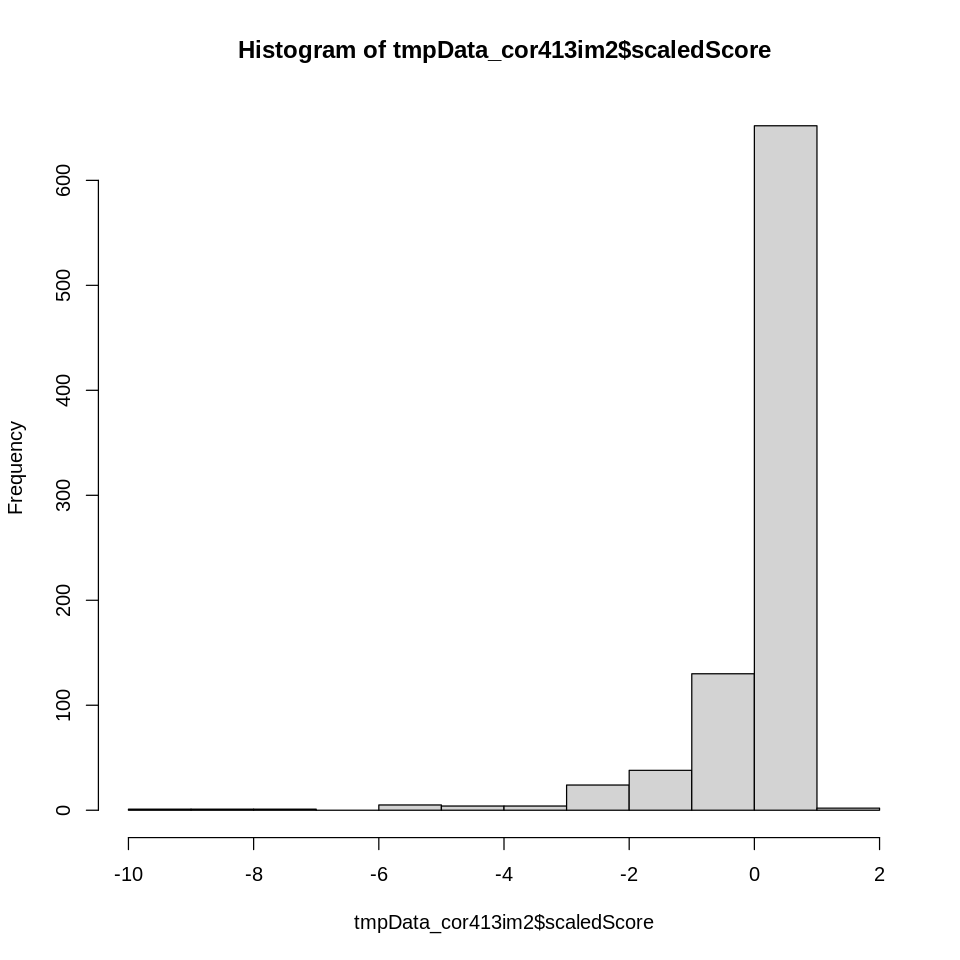

In [798]:
tmpData_cor413im2 = testData_merged[testData_merged$OG == 'OG0015019',]

options(repr.plot.width=8, repr.plot.height=8)
hist(tmpData_cor413im2$scaledScore)


head(tmpData_cor413im2[order(tmpData_cor413im2$scaledScore),],10)
tail(tmpData_cor413im2[order(tmpData_cor413im2$scaledScore),],10)

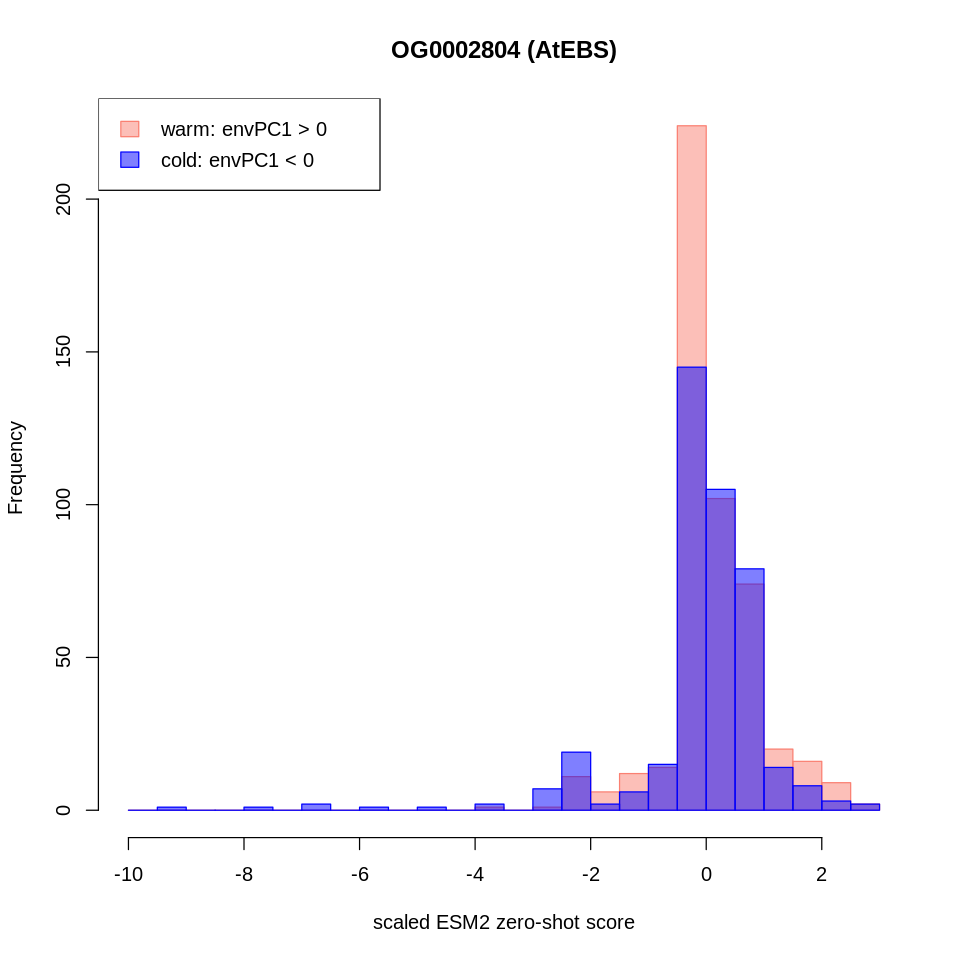

In [476]:
hist(tmpData_ebs$scaledScore[tmpData_ebs$envPC_1>= 0],col = alpha("salmon",.5),border = "salmon",
     main = "OG0002804 (AtEBS)",xlim = c(-10,3),breaks = seq(-10,3,0.5),xlab = "scaled ESM2 zero-shot score")
hist(tmpData_ebs$scaledScore[tmpData_ebs$envPC_1< 0],add =T, col =alpha("blue",.5),border = "blue",
     breaks = seq(-10,3,0.5))
legend("topleft",fill = alpha(c("salmon","blue"),.5),border = c("salmon","blue"),
       legend = c("warm: envPC1 > 0","cold: envPC1 < 0"))

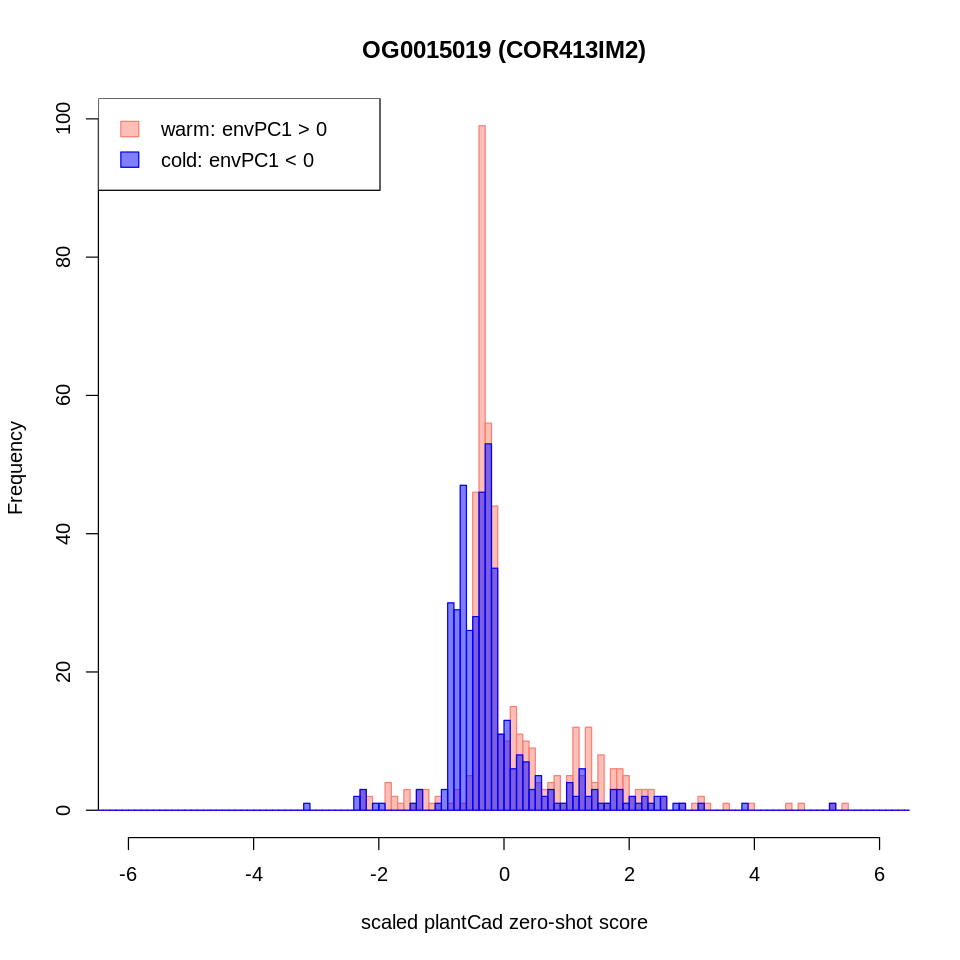

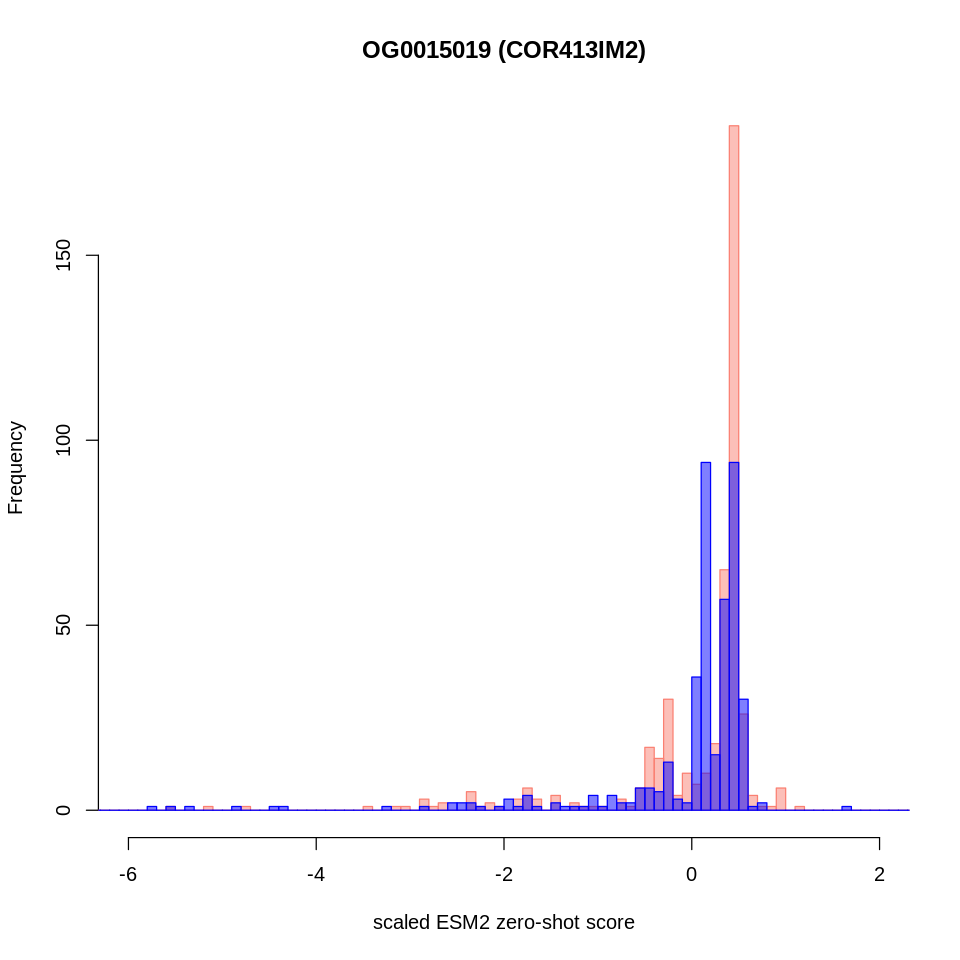

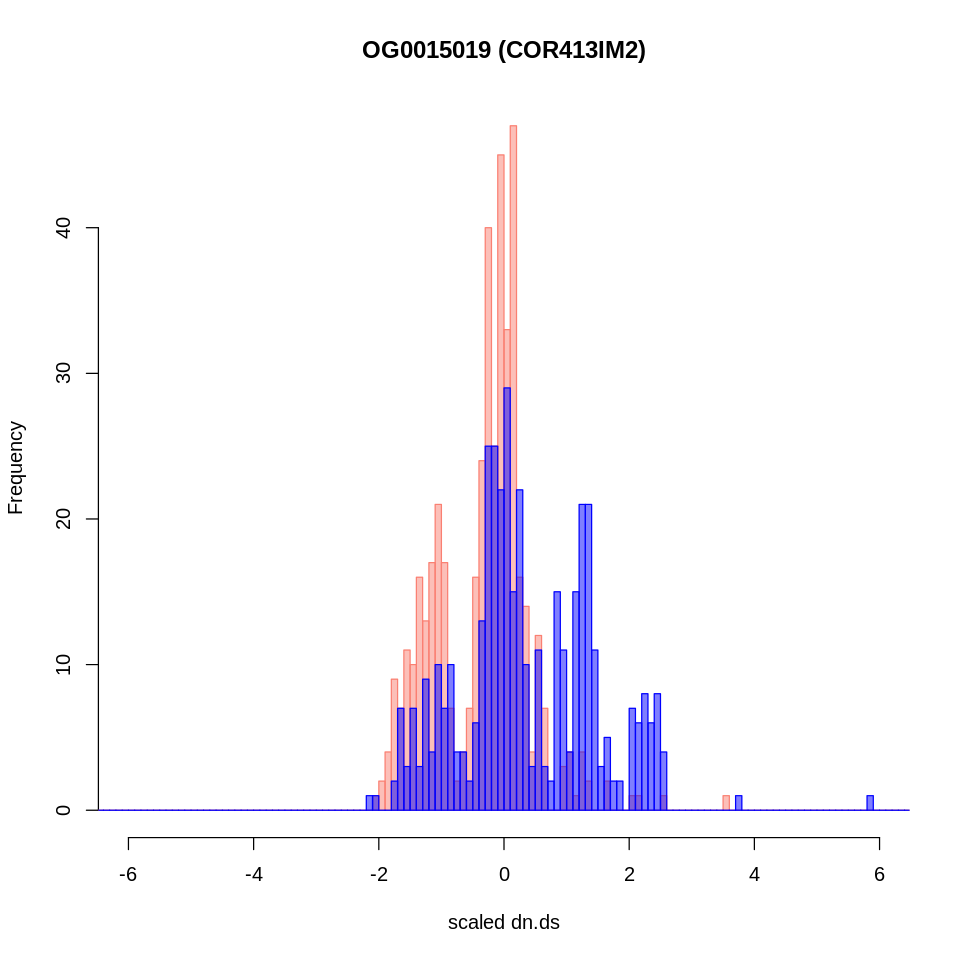

In [814]:
hist(tmpData_cor413im2$scaledScore_DNA[tmpData_cor413im2$envPC_1>= 0],col = alpha("salmon",.5),border = "salmon",
     main = "OG0015019 (COR413IM2)",xlim = c(-6,6),breaks = seq(-10,10,0.1),xlab = "scaled plantCad zero-shot score")
hist(tmpData_cor413im2$scaledScore_DNA[tmpData_cor413im2$envPC_1< 0],add =T, col =alpha("blue",.5),border = "blue",
     breaks = seq(-10,10,0.1))
legend("topleft",fill = alpha(c("salmon","blue"),.5),border = c("salmon","blue"),
       legend = c("warm: envPC1 > 0","cold: envPC1 < 0"))
hist(tmpData_cor413im2$scaledScore[tmpData_cor413im2$envPC_1>= 0],col = alpha("salmon",.5),border = "salmon",
     main = "OG0015019 (COR413IM2)",xlim = c(-6,2),breaks = seq(-10,10,0.1),xlab = "scaled ESM2 zero-shot score")
hist(tmpData_cor413im2$scaledScore[tmpData_cor413im2$envPC_1< 0],add =T, col =alpha("blue",.5),border = "blue",
     breaks = seq(-10,10,0.1))
hist(tmpData_cor413im2$scaled.dn.ds[tmpData_cor413im2$envPC_1>= 0],col = alpha("salmon",.5),border = "salmon",
     main = "OG0015019 (COR413IM2)",xlim = c(-6,6),breaks = seq(-10,10,0.1),xlab = "scaled dn.ds")
hist(tmpData_cor413im2$scaled.dn.ds[tmpData_cor413im2$envPC_1< 0],add =T, col =alpha("blue",.5),border = "blue",
     breaks = seq(-10,10,0.1))

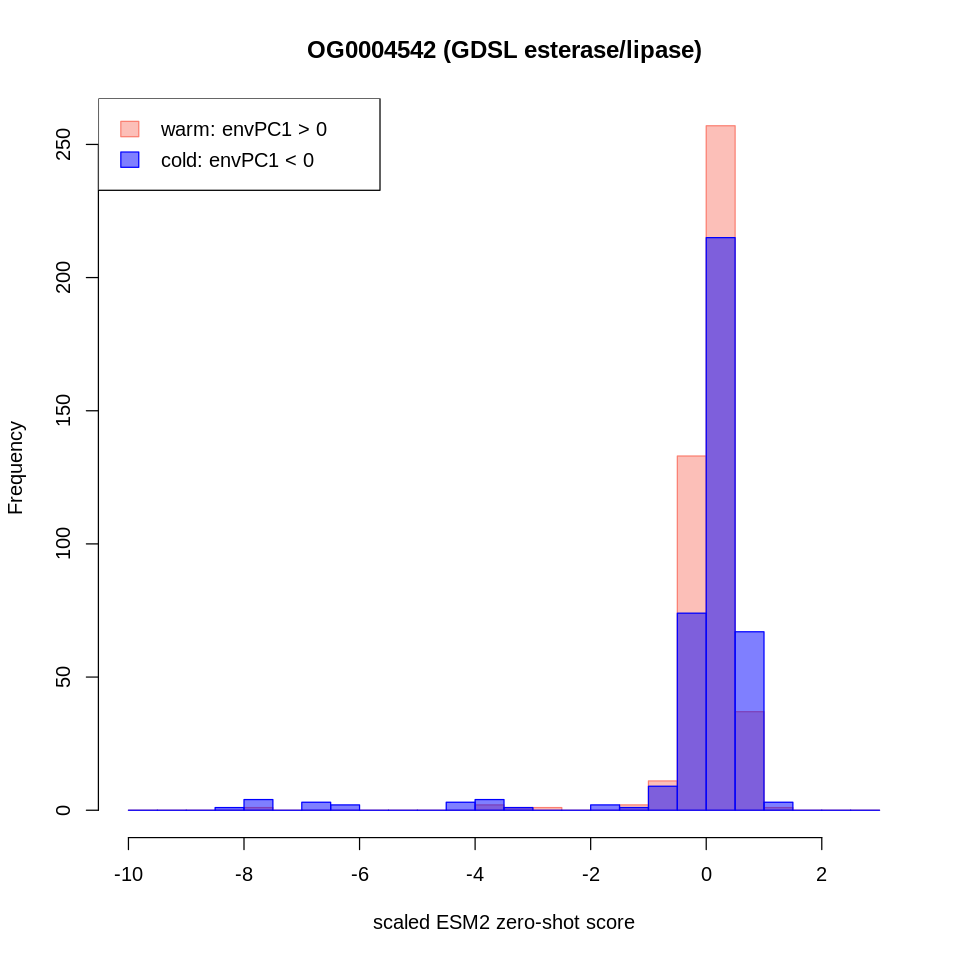

In [362]:
hist(tmpData_gdsl$scaledScore[tmpData_gdsl$envPC_1>= 0],col = alpha("salmon",.5),border = "salmon",
     main = "OG0004542 (GDSL esterase/lipase)",xlim = c(-10,3),breaks = seq(-10,3,0.5),xlab = "scaled ESM2 zero-shot score")
hist(tmpData_gdsl$scaledScore[tmpData_gdsl$envPC_1< 0],add =T, col =alpha("blue",.5),border = "blue",
     breaks = seq(-10,3,0.5))
legend("topleft",fill = alpha(c("salmon","blue"),.5),border = c("salmon","blue"),
       legend = c("warm: envPC1 > 0","cold: envPC1 < 0"))

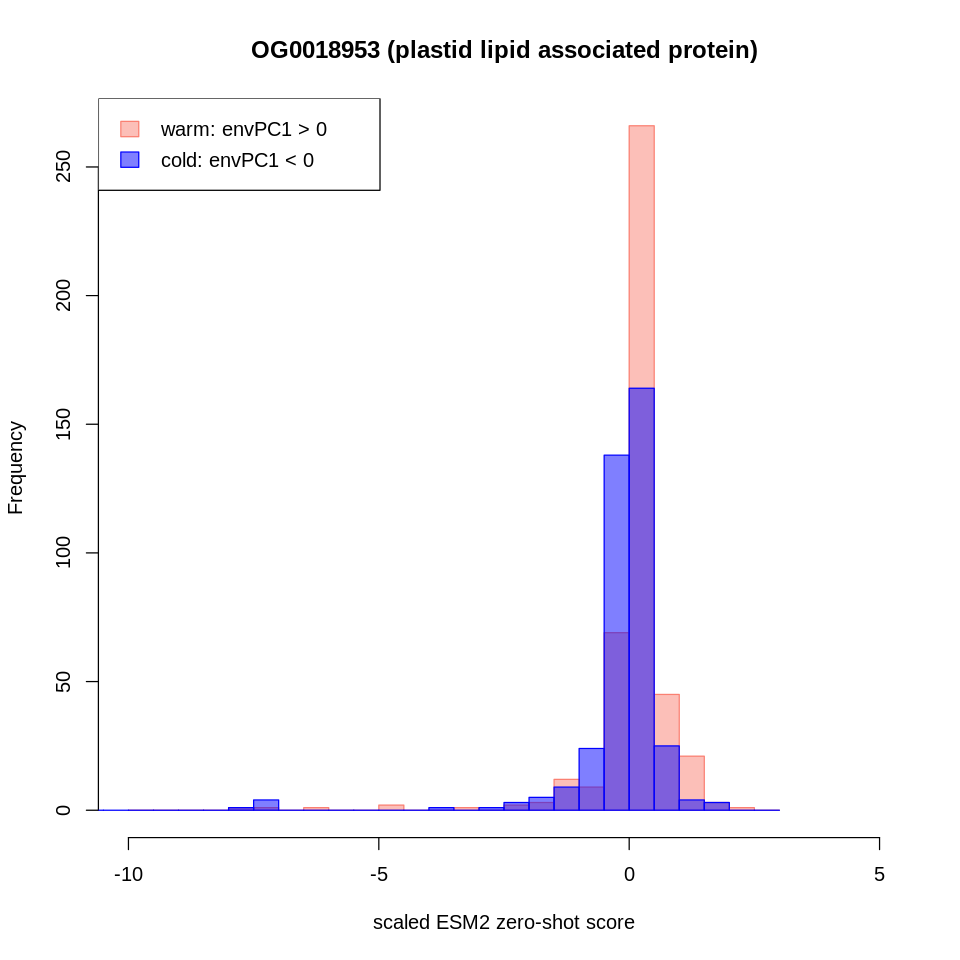

In [382]:
hist(tmpData_pap$scaledScore[tmpData_pap$envPC_1>= 0],col = alpha("salmon",.5),border = "salmon",
     main = "OG0018953 (plastid lipid associated protein)",xlim = c(-10,5),breaks = seq(-10,3,0.5),xlab = "scaled ESM2 zero-shot score")
hist(tmpData_pap$scaledScore[tmpData_pap$envPC_1< 0],add =T, col =alpha("blue",.5),border = "blue",
     breaks = seq(-12,3,0.5))
legend("topleft",fill = alpha(c("salmon","blue"),.5),border = c("salmon","blue"),
       legend = c("warm: envPC1 > 0","cold: envPC1 < 0"))

In [383]:
table(tmpData_pap$envPC_1>= 0)


FALSE  TRUE 
  383   437 

In [338]:
envDf$assemblyID

,assemblyID,bio01_Annual_Mean_Temperature_quan10,bio01_Annual_Mean_Temperature_quan50,bio01_Annual_Mean_Temperature_quan90,bio10_Mean_Temperature_Warmest_Quarter_quan10,bio10_Mean_Temperature_Warmest_Quarter_quan50,bio10_Mean_Temperature_Warmest_Quarter_quan90,bio11_Mean_Temperature_Coldest_Quarter_quan10,bio11_Mean_Temperature_Coldest_Quarter_quan50,bio11_Mean_Temperature_Coldest_Quarter_quan90,⋯,envPC_31,envPC_32,envPC_33,envPC_34,envPC_35,envPC_36,envPC_37,envPC_38,envPC_39,envPC_40
,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
10wheat_assembly_jagger,10wheat_assembly_jagger,6.133500,13.1071663,20.018167,17.007999,23.71200,28.88067,-5.1043334,3.24566662,11.958000,⋯,0.99264,-0.88270,0.80461,-0.40422,-1.26081,-0.07097,0.20012,0.50082,0.57836,1.26217
10wheat_assembly_stanley,10wheat_assembly_stanley,6.133500,13.1071663,20.018167,17.007999,23.71200,28.88067,-5.1043334,3.24566662,11.958000,⋯,0.99264,-0.88270,0.80461,-0.40422,-1.26081,-0.07097,0.20012,0.50082,0.57836,1.26217
10wheat_assembly_lancer,10wheat_assembly_lancer,6.133500,13.1071663,20.018167,17.007999,23.71200,28.88067,-5.1043334,3.24566662,11.958000,⋯,0.99264,-0.88270,0.80461,-0.40422,-1.26081,-0.07097,0.20012,0.50082,0.57836,1.26217
Triticum_aestivum_Claire_EIv1.1,Triticum_aestivum_Claire_EIv1.1,6.133500,13.1071663,20.018167,17.007999,23.71200,28.88067,-5.1043334,3.24566662,11.958000,⋯,0.99264,-0.88270,0.80461,-0.40422,-1.26081,-0.07097,0.20012,0.50082,0.57836,1.26217
WEW_v2.1,WEW_v2.1,16.764166,18.7045002,20.341333,23.534000,25.71667,27.30067,8.9806662,10.91266632,12.826800,⋯,-0.05710,0.30570,0.76211,0.52841,0.31222,-1.22973,0.26641,-0.06968,0.46370,2.34564
Svevo.v1,Svevo.v1,8.796250,12.3255835,15.784000,16.990000,20.43933,24.17740,0.2693333,4.98433328,8.728067,⋯,0.44827,-0.29788,-0.29079,-0.05951,-0.22431,0.86044,-0.67817,-0.47077,0.25302,-0.01622
SRR13484808,SRR13484808,9.772833,16.2625008,18.427767,21.112667,28.40867,30.88000,-2.3980000,4.28600025,6.096666,⋯,2.59143,0.18100,-0.09097,1.71525,-1.17632,1.33499,-0.26378,1.65355,-2.21338,1.22726
Triticum_petropavlovskyi,Triticum_petropavlovskyi,-6.387500,-0.9163332,8.996217,4.408667,11.68400,22.76780,-17.6293335,-14.58400011,-6.931734,⋯,-0.34366,-1.03797,1.37552,4.82592,-2.06554,-3.28306,-0.21600,-0.06277,1.05704,-2.53961
PI306540_Tmono,PI306540_Tmono,8.476017,11.7157893,17.294016,17.985133,21.71367,27.47440,-2.5315999,2.48399997,7.888667,⋯,1.87978,0.87968,-0.76011,0.20469,-0.71951,1.08654,-0.57305,0.23509,-0.31397,-0.47426


In [384]:
avgZS_perTaxa = tapply(testData_merged$scaledScore,testData_merged$assemblyID,median,na.rm = T)

# life history - envPC association

In [518]:
fit_model_lifeHistory <- function(data, Kmat) {
#   library(asreml)
    gc()
  asreml.options(verbose = FALSE)
  filtered_data <- data
  #filtered_data <- filtered_data %>% group_by(assemblyID) %>% slice_max(queryCov, n = 1, with_ties = FALSE) %>% ungroup()
  phyloK_OG <- Kmat[rownames(Kmat) %in% filtered_data$assemblyID,]
  phyloK_OG <- phyloK_OG[,colnames(phyloK_OG) %in% filtered_data$assemblyID]
  model <- asreml(fixed = lifeHistoryNum ~ envPC_1 + envPC_2 + envPC_3 + envPC_4 + envPC_5 + envPC_6 + envPC_7 + envPC_8 + envPC_9 + envPC_10,family = asr_binomial(),
                  random = ~ vm(assemblyID, phyloK_OG), ai.sing = TRUE, data = filtered_data)
  #model <- asreml(fixed = lifeHistoryNumeric ~ dn.ds, random = ~compdup, ai.sing = TRUE, data = filtered_data)
  modelSummary <- summary(model)
  loglik <- modelSummary$loglik
  phylo_explained <- modelSummary$varcomp$component[2]/sum(modelSummary$varcomp$component)
  modelWald <- wald.asreml(model)
  envPC_coeff <- model$coefficients$fixed[2:11]
  envPC_pval <- modelWald[2:11,4]
  envPC_explained <- modelWald[2:11,2]/sum(modelWald[,2])
#     return(model)
  return(c(envPC_coeff, envPC_pval, loglik, phylo_explained, envPC_explained))
}

In [519]:
fit_model_lifeHistory_noK <- function(data) {
#   library(asreml)
    gc()
  asreml.options(verbose = FALSE)
  filtered_data <- data
  #filtered_data <- filtered_data %>% group_by(assemblyID) %>% slice_max(queryCov, n = 1, with_ties = FALSE) %>% ungroup()
  model <- asreml(fixed = lifeHistoryNum ~ envPC_1 + envPC_2 + envPC_3 + envPC_4 + envPC_5 + envPC_6 + envPC_7 + envPC_8 + envPC_9 + envPC_10,family = asr_binomial(),
                  ai.sing = TRUE, data = filtered_data)
  #model <- asreml(fixed = lifeHistoryNumeric ~ dn.ds, random = ~compdup, ai.sing = TRUE, data = filtered_data)
  modelSummary <- summary(model)
  loglik <- modelSummary$loglik
  modelWald <- wald.asreml(model)
  envPC_coeff <- model$coefficients$fixed[2:11]
  envPC_pval <- modelWald[2:11,4]
  envPC_explained <- modelWald[2:11,2]/sum(modelWald[,2])
#     return(model)
  return(c(envPC_coeff, envPC_pval, loglik, envPC_explained))
}

In [481]:
lifeHistoryAssTab = merge(metadata,envDf,by = "assemblyID")

In [528]:
lifeHistoryAssTab$lifeHistoryNum = lifeHistoryAssTab$lifeHistory
lifeHistoryAssTab$lifeHistoryNum[!lifeHistoryAssTab$lifeHistory%in%c("annual","perennial")] = NA
lifeHistoryAssTab$lifeHistoryNum = as.numeric(as.factor(lifeHistoryAssTab$lifeHistoryNum))-1

In [510]:
lifeHistoryAssTab$assemblyID = as.factor(lifeHistoryAssTab$assemblyID)

In [532]:
asreml.options(maxit = 30,verbose = F)
lifeHistoryAssRes = fit_model_lifeHistory(lifeHistoryAssTab,phyloKMat)
lifeHistoryAssRes_noK = fit_model_lifeHistory_noK(lifeHistoryAssTab)

ASReml Version 4.2 24/09/2024 10:59:50
          LogLik        Sigma2     DF     wall
 1     -1053.383           1.0    715   10:59:50
 2     -1049.602           1.0    715   10:59:51
 3     -1047.105           1.0    715   10:59:51
 4     -1066.960           1.0    715   10:59:51
 5     -1102.269           1.0    715   10:59:51
 6     -1132.549           1.0    715   10:59:51
 7     -1158.853           1.0    715   10:59:51
 8     -1181.683           1.0    715   10:59:51
 9     -1201.218           1.0    715   10:59:52
10     -1217.620           1.0    715   10:59:52
11     -1231.116           1.0    715   10:59:52
12     -1242.004           1.0    715   10:59:52
13     -1250.638           1.0    715   10:59:52
14     -1257.384           1.0    715   10:59:52
15     -1262.590           1.0    715   10:59:52
16     -1268.063           1.0    715   10:59:53
17     -1271.186           1.0    715   10:59:53
18     -1273.773           1.0    715   10:59:53
19     -1275.463           1.0  

In [533]:
names(lifeHistoryAssRes) = c(paste0("Coeff_envPC",1:10),paste0("Pval_envPC",1:10),"loglik",
                             "VarComp_phylo",paste0("VAE_envPC",1:10))
names(lifeHistoryAssRes_noK) = c(paste0("Coeff_envPC",1:10),paste0("Pval_envPC",1:10),"loglik",
                                 paste0("VAE_envPC",1:10))


In [537]:
lifeHistoryAssOut = cbind(lifeHistoryAssRes[1:10],lifeHistoryAssRes[11:20],lifeHistoryAssRes_noK[1:10],lifeHistoryAssRes_noK[11:20])

In [538]:
rownames(lifeHistoryAssOut) = paste("envPC",1:10,sep = "")
colnames(lifeHistoryAssOut) = c("coefficient-K","p_val-K","coefficient","p_val")

In [541]:
lifeHistoryAssOut
write.table(lifeHistoryAssOut,'/workdir/sh2246/p_phyloGWAS/output/lifeHistoryEnvAssRes.txt',quote = F,sep = "\t",row.names = T,col.names = T)

,coefficient-K,p_val-K,coefficient,p_val
envPC1,-0.54376886,3.363099e-06,0.22327742,2.035913e-01
envPC2,-0.72763060,7.224314e-04,-0.77820546,9.627738e-09
envPC3,-0.15120692,1.544345e-01,-0.22202195,3.857736e-03
envPC4,-0.03871251,6.830807e-01,-0.19919389,3.244200e-03
envPC5,-0.12694430,4.016002e-01,0.03367554,6.621440e-01
envPC6,-0.37406996,2.371271e-02,-0.49712923,2.243669e-03
envPC7,-0.12063520,2.493364e-01,-0.10384808,3.752878e-01
envPC8,0.55288356,3.380250e-02,0.65562691,8.535378e-10
envPC9,-0.61545012,4.144785e-03,-0.63650125,3.734532e-07
envPC10,-0.36437847,1.003559e-01,-0.23869937,7.781037e-02


In [ ]:
asreml.options(maxit = 30,verbose = F)
testRes = mclapply(OG_list,function(x) try(fit_model_ePC1(x,data = testData_merged,phyloK),silent = T),mc.cores = 2)
testRes = t(simplify2array(testRes[sapply(testRes,length)==7]))

In [ ]:
testRes_sorted = na.omit(testRes[order(as.numeric(testRes[,3])),])

In [ ]:
dim(testRes_sorted)
head(testRes_sorted)

In [ ]:
mycol = rep("grey",nrow(testRes_sorted))
mycol[testRes_sorted[,2]>0& -log10(as.numeric(testRes_sorted[,3]))>4.47] = "red"
mycol[testRes_sorted[,2]<0& -log10(as.numeric(testRes_sorted[,3]))>4.47] = "blue"

In [ ]:
qq(as.numeric(testRes_sorted[,3]),col = mycol)

In [ ]:
plot(as.numeric(testRes_sorted[,2]),-log10(as.numeric(testRes_sorted[,3])),col = mycol,pch = 19,
     xlab = "Effect size",ylab = expression(-log[10](P)))

In [ ]:
# testRes[which.min(as.numeric(testRes[,3])),]
head(testRes_sorted,17)

In [ ]:
quantile(-log10(as.numeric(testRes_sorted[,3])),.99,na.rm = T)

In [ ]:
topCandidates = testRes_sorted[-log10(as.numeric(testRes_sorted[,3]))>4.47,1]

In [ ]:
topCandidates

In [ ]:
testData_merged_subset = subset(testData_merged,OG == 'OG0002978')

testData_merged_subset = merge(testData_merged_subset,envDf[,c(1,3)],by = 'assemblyID')

In [ ]:
mycol2 = rep(NA,nrow(testData_merged_subset))
mycol2[testData_merged_subset$lifeHistoryNumeric =="1"&testData_merged_subset$bio01_Annual_Mean_Temperature_quan50>18] = "darkred"
mycol2[testData_merged_subset$lifeHistoryNumeric =="1"&testData_merged_subset$bio01_Annual_Mean_Temperature_quan50<18] = "darkblue"
mycol2[testData_merged_subset$lifeHistoryNumeric !="1"&testData_merged_subset$bio01_Annual_Mean_Temperature_quan50>18] = "salmon"
mycol2[testData_merged_subset$lifeHistoryNumeric !="1"&testData_merged_subset$bio01_Annual_Mean_Temperature_quan50<18] = "lightblue"

In [ ]:

layout(matrix(1:4,2,2),widths = c(3,1),heights = c(1,3))
par(mar = c(1,5,1,1))
plot(density(testData_merged_subset$dn.ds[testData_merged_subset$lifeHistoryNumeric =="1"&testData_merged_subset$bio01_Annual_Mean_Temperature_quan50>18]),
     type ='l',col = "darkred",main = '',xaxt ='n',yaxt = 'n',xlab = '',ylab = '',ylim = c(0,20),xlim = c(0,0.25))
points(density(testData_merged_subset$dn.ds[testData_merged_subset$lifeHistoryNumeric =="1"&testData_merged_subset$bio01_Annual_Mean_Temperature_quan50<18]),
     type ='l',col = "darkblue")
points(density(testData_merged_subset$dn.ds[testData_merged_subset$lifeHistoryNumeric !="1"&testData_merged_subset$bio01_Annual_Mean_Temperature_quan50>18]),
     type ='l',col = "salmon")
points(density(testData_merged_subset$dn.ds[testData_merged_subset$lifeHistoryNumeric !="1"&testData_merged_subset$bio01_Annual_Mean_Temperature_quan50<18]),
     type ='l',col = "lightblue")

par(mar = c(5,5,1,1))
plot(testData_merged_subset$dn.ds,testData_merged_subset$envPC_1,xlab = 'dN/dS',ylab = 'envPC1',
     col = mycol2)

plot(1,1,type = 'n',axes = F,xlab = '',ylab ='')
par(mar = c(1,1,1,1))
legend(0.1,1.2,legend = c("Tropical Annual","Temperate Annual","Tropical Perennial","Temperate Perennial"),
       col = c("darkred","darkblue","salmon","lightblue"),pch = 19,bty ='n',cex = 1.5)
par(mar = c(5,1,1,1))
d1 = density(testData_merged_subset$envPC_1[testData_merged_subset$lifeHistoryNumeric =="1"&testData_merged_subset$bio01_Annual_Mean_Temperature_quan50>18])
d2 = density(testData_merged_subset$envPC_1[testData_merged_subset$lifeHistoryNumeric =="1"&testData_merged_subset$bio01_Annual_Mean_Temperature_quan50<18])
d3 = density(testData_merged_subset$envPC_1[testData_merged_subset$lifeHistoryNumeric !="1"&testData_merged_subset$bio01_Annual_Mean_Temperature_quan50>18])
d4 = density(testData_merged_subset$envPC_1[testData_merged_subset$lifeHistoryNumeric !="1"&testData_merged_subset$bio01_Annual_Mean_Temperature_quan50<18])
plot(d1$y,d1$x,type ='l',col = "darkred",xlim = c(0,1.2),ylim = c(-3,2),xlab = '',ylab = '',xaxt = 'n',yaxt = 'n')
points(d2$y,d2$x,type ='l',col = "darkblue")
points(d3$y,d3$x,type ='l',col = "salmon")
points(d4$y,d4$x,type ='l',col = "lightblue")

In [ ]:
LSD::heatscatter(testData_merged_subset$dn.ds,testData_merged_subset$envPC_1,xlab = 'dN/dS',ylab = 'envPC1',cexplot = 1)

In [ ]:
class(testData_merged_subset$envPC_1)

In [ ]:
boxplot(testData_merged_subset$dn.ds~testData_merged_subset$bio01_Annual_Mean_Temperature_quan50>18)

In [ ]:
asreml.options(maxit = 30,verbose = F)
testRes2 = mclapply(OG_list,function(x) try(fit_model_ePC2(x,data = testData_merged,phyloK),silent = T),mc.cores = 2)
testRes2 = t(simplify2array(testRes2[sapply(testRes2,length)==7]))

In [ ]:
testRes2_sorted = na.omit(testRes2[order(as.numeric(testRes2[,3])),])

In [ ]:
write.table(testRes_sorted, "/workdir/sh2246/p_phyloGWAS/output/asremlRes_envPC1.txt",quote = F,col.names = F,row.names = F)
write.table(testRes2_sorted, "/workdir/sh2246/p_phyloGWAS/output/asremlRes_envPC2.txt",quote = F,col.names = F,row.names = F)

In [ ]:
quantile(-log10(as.numeric(testRes2_sorted[,3])),.999)

In [ ]:
mycol2 = rep("grey",nrow(testRes2_sorted))
mycol2[testRes2_sorted[,2]>0& -log10(as.numeric(testRes2_sorted[,3]))>4.68] = "red"
mycol2[testRes2_sorted[,2]<0& -log10(as.numeric(testRes2_sorted[,3]))>4.68] = "blue"

In [ ]:
qq(as.numeric(testRes2[,3]),col = mycol2)

In [ ]:
plot(as.numeric(testRes2_sorted[,2]),-log10(as.numeric(testRes2_sorted[,3])),col = mycol2,pch = 19,
     xlab = "Effect size",ylab = expression(-log[10](P)))

In [ ]:
dim(testRes)
dim(testRes2)

In [ ]:
rownames(testRes) = testRes[,1]
rownames(testRes2) = testRes2[,1]
commonID = intersect(rownames(testRes),rownames(testRes2))

In [ ]:
plot(-log10(as.numeric(testRes[commonID,3])),-log10(as.numeric(testRes2[commonID,3])),xlab = "envPC1",ylab = "envPC2")

In [ ]:
cor(-log10(as.numeric(testRes[commonID,3])),-log10(as.numeric(testRes2[commonID,3])),use = "complete")

In [ ]:
plot(as.numeric(testRes[commonID,2]),as.numeric(testRes2[commonID,2]),xlab = "envPC1",ylab = "envPC2")

In [ ]:
cor(as.numeric(testRes[commonID,2]),as.numeric(testRes2[commonID,2]),use = "complete")

In [ ]:
asreml.options(maxit = 30,verbose = F)
testRes_bio01 = mclapply(OG_list,function(x) try(fit_model_bio01(x,data = testData_merged,phyloK),silent = T),mc.cores = 2)
testRes_bio01 = t(simplify2array(testRes_bio01[sapply(testRes_bio01,length)==7]))
testRes_bio12 = mclapply(OG_list,function(x) try(fit_model_bio12(x,data = testData_merged,phyloK),silent = T),mc.cores = 2)
testRes_bio12 = t(simplify2array(testRes_bio12[sapply(testRes_bio12,length)==7]))

In [ ]:
fit_model_bio01(OG_list[[1]],data = testData_merged,phyloK)

In [ ]:
rownames(testRes_bio01) = testRes_bio01[,1]
rownames(testRes_bio12) = testRes_bio12[,1]

In [ ]:
testRes_bio01_sorted = na.omit(testRes_bio01[order(as.numeric(testRes_bio01[,3])),])
testRes_bio12_sorted = na.omit(testRes_bio12[order(as.numeric(testRes_bio12[,3])),])

In [ ]:
write.table(testRes_bio01_sorted, "/workdir/sh2246/p_phyloGWAS/output/asremlRes_bio01.txt",quote = F,col.names = F,row.names = F)
write.table(testRes_bio12_sorted, "/workdir/sh2246/p_phyloGWAS/output/asremlRes_bio12.txt",quote = F,col.names = F,row.names = F)

In [ ]:
options(repr.plot.width=10, repr.plot.height=5)
par(mfrow = c(1,2))
mycol = rep("grey",nrow(testRes_bio01_sorted))
mycol[testRes_bio01_sorted[,2]>0& rank(as.numeric(testRes_bio01_sorted[,3]))<=17] = "royalblue"
mycol[testRes_bio01_sorted[,2]<0& rank(as.numeric(testRes_bio01_sorted[,3]))<=17] = "salmon"
qq(as.numeric(testRes_bio01_sorted[,3]),col = mycol,main = "Temperature adaptation")
mycol = rep("grey",nrow(testRes_bio12_sorted))
mycol[testRes_bio12_sorted[,2]>0& rank(as.numeric(testRes_bio12_sorted[,3]))<=17] = "brown"
mycol[testRes_bio12_sorted[,2]<0& rank(as.numeric(testRes_bio12_sorted[,3]))<=17] = "forestgreen"
qq(as.numeric(testRes_bio12[,3]),col = mycol, main = "Precipitation adaptation")

In [ ]:
commonID2 = intersect(rownames(testRes_bio01),rownames(testRes_bio12))

In [ ]:
mycol3 = rep("NA",length(commonID2))
mycol3[rank(as.numeric(testRes_bio01[commonID2,3]))<=17&as.numeric(testRes_bio01[commonID2,2])>0] = "royalblue"
mycol3[rank(as.numeric(testRes_bio01[commonID2,3]))<=17&as.numeric(testRes_bio01[commonID2,2])<0] = "salmon"
mycol3[rank(as.numeric(testRes_bio12[commonID2,3]))<=17&as.numeric(testRes_bio12[commonID2,2])>0] = "brown"
mycol3[rank(as.numeric(testRes_bio12[commonID2,3]))<=17&as.numeric(testRes_bio12[commonID2,2])<0] = "forestgreen"
mycol3[rank(as.numeric(testRes_bio01[commonID2,3]))<=17&
       rank(as.numeric(testRes_bio12[commonID2,3]))<=17&
       as.numeric(testRes_bio01[commonID2,2])>0&
       as.numeric(testRes_bio12[commonID2,2])>0] = "cyan"
mycol3[rank(as.numeric(testRes_bio01[commonID2,3]))<=17&
       rank(as.numeric(testRes_bio12[commonID2,3]))<=17&
       as.numeric(testRes_bio01[commonID2,2])<0&
       as.numeric(testRes_bio12[commonID2,2])<0] = "darkred"
mycol3[rank(as.numeric(testRes_bio01[commonID2,3]))<=17&
       rank(as.numeric(testRes_bio12[commonID2,3]))<=17&
       as.numeric(testRes_bio01[commonID2,2])>0&
       as.numeric(testRes_bio12[commonID2,2])<0] = "darkblue"
mycol3[rank(as.numeric(testRes_bio01[commonID2,3]))<=17&
       rank(as.numeric(testRes_bio12[commonID2,3]))<=17&
       as.numeric(testRes_bio01[commonID2,2])<0&
       as.numeric(testRes_bio12[commonID2,2])>0] = "orange"


In [ ]:
plot(-log10(as.numeric(testRes_bio01[commonID2,3])),-log10(as.numeric(testRes_bio12[commonID2,3])),
     xlab = "Annual Temp.",ylab = "Annual Precipitation",col = mycol3)

In [ ]:
plot(scale(as.numeric(testRes_bio01[commonID2,2])),scale(as.numeric(testRes_bio12[commonID2,2])),
     xlab = "Temperature",ylab = "Precipitation",
     col = alpha("grey90",.5))
abline(h = 0,lty = 2, lwd = 1.5,col = "grey")
abline(v = 0,lty = 2, lwd = 1.5,col = "grey")
points(scale(as.numeric(testRes_bio01[commonID2,2])),scale(as.numeric(testRes_bio12[commonID2,2])),
     col = mycol3,pch = 19)


In [ ]:
plot(scale(as.numeric(testRes_bio01[commonID2,2])),scale(as.numeric(testRes_bio12[commonID2,2])),
     xlab = "Temperature",ylab = "Precipitation")


In [ ]:
cor(as.numeric(testRes_bio01[commonID2,2]),as.numeric(testRes_bio12[commonID2,2]))

In [ ]:
head(testRes_bio01_sorted,10)

In [ ]:
testData_merged_subset = subset(testData_merged,OG == 'OG0007714')

In [ ]:
phyloK_test <- phyloK[rownames(phyloK) %in% testData_merged_subset$assemblyID,rownames(phyloK) %in% testData_merged_subset$assemblyID]

In [ ]:
dnds_test = tapply(testData_merged_subset$dn.ds,testData_merged_subset$assemblyID,mean)
bio01_test = tapply(testData_merged_subset$bio01_Annual_Mean_Temperature_quan50,testData_merged_subset$assemblyID,mean)

dnds_test = dnds_test[!is.na(dnds_test)]
bio01_test = bio01_test[!is.na(bio01_test)]

In [ ]:
hc = hclust(as.dist(2-phyloK_test), method = "ward.D2")

cut = cutree(hc,5)

In [ ]:
fm = list()
for (i in 1:5){
    fm[[i]] = lm(bio01_test[names(cut)][cut==i]~dnds_test[names(cut)][cut==i])
}
fm0 = lm(bio01_test[names(cut)]~dnds_test[names(cut)])

In [ ]:
wd = log2((table(cut)/length(cut))/min(table(cut)/length(cut)))+1
wd

In [ ]:
lnCol = c("royalblue","forestgreen","purple","orange","red")

In [ ]:
options(repr.plot.width=7, repr.plot.height=7)
plot(dnds_test[names(cut)],bio01_test[names(cut)],col = lnCol[cut],pch = 1,xlab = "evolutionary constraint (dN/dS)",ylab = "Habitat annual mean Temperature")
abline(fm0$coefficients,col = "grey",lty =3 ,lwd = 6)
for(i in 1:5){
    abline(fm[[i]]$coefficients,col = lnCol[i],lwd = wd[i])
}
legend("bottomright",legend=c("All","Pooideae","Bambusoideae","Chloridoideae","Panicoideae","Oryzoideae"),
       seg.len = 4,col = c("grey",lnCol),lty =c(3,rep(1,5)),bty = 'n',lwd = c(6,wd))

In [ ]:
names(cut)[cut==1]
names(cut)[cut==2]
names(cut)[cut==3]
names(cut)[cut==4]
names(cut)[cut==5]


In [ ]:
sort(dnds_test[names(cut)][cut==1])

In [ ]:
annot_col_expr = data.frame(omega.score = dnds_test,temp = bio01_test)
rownames(annot_col_expr)=rownames(phyloK_test)
ann_colors_expr = list(omega.score=rev(heat.colors(10)),temp = cm.colors(10))

options(repr.plot.width=15, repr.plot.height=10)
pheatmap::pheatmap(phyloK_test,show_rownames = F,show_colnames = F,
         annotation_row = annot_col_expr,annotation_colors = ann_colors_expr,cluster_rows = F,cluster_cols = F)


In [ ]:
summary(unlist(phyloK_test))

In [ ]:
vae = c()
for (i in testRes_bio01_sorted[1:17,1]){
    testData_merged_subset = subset(testData_merged,OG == i)
    phyloK_test <- phyloK[rownames(phyloK) %in% testData_merged_subset$assemblyID,rownames(phyloK) %in% testData_merged_subset$assemblyID]
    testModel = asreml(fixed = bio01_Annual_Mean_Temperature_quan50 ~ dn.ds, random = ~ vm(assemblyID, phyloK_test) + compdup, ai.sing = TRUE, data = testData_merged_subset)
#     testData_merged_subset = subset(testData_merged,OG == i)
#     testModel_reduced = asreml(fixed = bio01_Annual_Mean_Temperature_quan50 ~ dn.ds, random = ~ compdup, ai.sing = TRUE, data = testData_merged_subset)
#     testData_merged_subset = subset(testData_merged,OG == i)
    testModel_reduced = asreml(fixed = bio01_Annual_Mean_Temperature_quan50 ~ 1, random = ~ vm(assemblyID, phyloK_test) + compdup, ai.sing = TRUE, data = testData_merged_subset)

    r1 = 1-summary(testModel)$varcomp[3,1]/sum(summary(testModel)$varcomp[,1])
    r2 = 1-summary(testModel)$varcomp[3,1]/summary(testModel_reduced)$varcomp[3,1] 
    vae = rbind(vae,c(r1,r2))
}


In [ ]:
vae*100

In [ ]:
testData_merged_subset = subset(testData_merged,OG == 'OG0007714')
phyloK_test <- phyloK[rownames(phyloK) %in% testData_merged_subset$assemblyID,rownames(phyloK) %in% testData_merged_subset$assemblyID]
testModel = asreml(fixed = bio01_Annual_Mean_Temperature_quan50 ~ 1 + dn.ds, random = ~ vm(assemblyID, phyloK_test) + compdup, ai.sing = TRUE, data = testData_merged_subset)
testModel_reduced = asreml(fixed = bio01_Annual_Mean_Temperature_quan50 ~ 1, random = ~ vm(assemblyID, phyloK_test) + compdup, ai.sing = TRUE, data = testData_merged_subset)

In [ ]:
summary(testModel)$varcomp
# wald.asreml(testModel)

In [ ]:
summary(testModel_reduced)$varcomp
# wald.asreml(testModel_reduced2)

In [ ]:
1-summary(testModel)$varcomp[3,1]/sum(summary(testModel)$varcomp[,1])
1-summary(testModel)$varcomp[3,1]/summary(testModel_reduced)$varcomp[3,1]
summary(testModel)$varcomp[2,1]/sum(summary(testModel)$varcomp[,1])

In [ ]:
sum(summary(testModel)$varcomp[,1])
sum(summary(testModel_reduced)$varcomp[,1])

In [ ]:
mappingFile2 = read.table("/workdir/sh2246/p_phyloGWAS/output/OGToZm_mapping.txt")

In [ ]:
intersect(substr(mappingFile2[mappingFile2[,2]%in%testRes_bio01_sorted[1:17,1],1],1,15),
          c("Zm00001eb102170","Zm00001eb408490","Zm00001eb081940","Zm00001eb374460",
            "Zm00001eb216820","Zm00001eb034840","Zm00001eb334120","Zm00001eb171760","Zm00001eb442360"))

In [ ]:
mappingFile2[mappingFile2[,2]%in%testRes_bio01_sorted[1:17,1],]

In [ ]:
head(testRes_bio01_sorted,17)

In [ ]:
# GO enrichment

In [ ]:
mappingFile = read.table("/workdir/sh2246/p_phyloGWAS/output/OGToPv_mapping.txt")

In [ ]:
topHits = mappingFile[mappingFile[,2]%in%topCandidates,1]

In [ ]:
GODB <- readMappings("/workdir/sh2246/p_panAndOGASR/data/Pv_GOTable.txt",IDsep = ",")
background = intersect(names(GODB),mappingFile[,1])
# background = names(GODB)

tmp=factor(as.integer(background%in%topHits))
names(tmp)=background
tgd1=new( "topGOdata", ontology="BP", allGenes = tmp, nodeSize=5,annot=annFUN.gene2GO, gene2GO = GODB)
resTopGO.classic=runTest(tgd1, algorithm = "classic", statistic = "Fisher")
resTopGO.weight01=runTest(tgd1, algorithm = "weight01", statistic = "Fisher")
GO_res_table=GenTable(tgd1,Fisher.classic = resTopGO.classic,Fisher.weight01=resTopGO.weight01,orderBy = "Fisher.weight01",ranksOf="Fisher.classic",topNodes=length(resTopGO.classic@score),numChar=100)


In [ ]:
head(GO_res_table)

In [ ]:
topHits2 = mappingFile2[mappingFile2[,2]%in%topCandidates,1]
GODB <- readMappings("/workdir/sh2246/p_panAndOGASR/data/Zm00001eb.1.fulldata_goList.txt",IDsep = ",")
background = intersect(names(GODB),substr(mappingFile2[,1],1,15))
# background = names(GODB)

tmp=factor(as.integer(background%in%substr(topHits2,1,15)))
names(tmp)=background
tgd1=new( "topGOdata", ontology="BP", allGenes = tmp, nodeSize=5,annot=annFUN.gene2GO, gene2GO = GODB)
resTopGO.classic=runTest(tgd1, algorithm = "classic", statistic = "Fisher")
resTopGO.weight01=runTest(tgd1, algorithm = "weight01", statistic = "Fisher")
GO_res_table_Zm=GenTable(tgd1,Fisher.classic = resTopGO.classic,Fisher.weight01=resTopGO.weight01,orderBy = "Fisher.weight01",ranksOf="Fisher.classic",topNodes=length(resTopGO.classic@score),numChar=100)



In [ ]:
head(GO_res_table_Zm,10)

In [ ]:
intersect(substr(topHits2,1,15),genesInTerm(tgd1,"GO:0010048")[[1]])

In [ ]:
# annualism for Aimee

In [ ]:
annualTopHits = read.table("/workdir/sh2246/p_phyloGWAS/output/dnds_topHits.txt",header = T)
topHits = mappingFile[mappingFile[,2]%in%annualTopHits[,1],1]

In [ ]:

GODB <- readMappings("/workdir/sh2246/p_panAndOGASR/data/Pv_GOTable.txt",IDsep = ",")
background = intersect(names(GODB),mappingFile[,1])
# background = names(GODB)

tmp=factor(as.integer(background%in%topHits))
names(tmp)=background
tgd1=new( "topGOdata", ontology="BP", allGenes = tmp, nodeSize=5,annot=annFUN.gene2GO, gene2GO = GODB)
resTopGO.classic=runTest(tgd1, algorithm = "classic", statistic = "Fisher")
resTopGO.weight01=runTest(tgd1, algorithm = "weight01", statistic = "Fisher")
GO_res_table=GenTable(tgd1,Fisher.classic = resTopGO.classic,Fisher.weight01=resTopGO.weight01,orderBy = "Fisher.weight01",ranksOf="Fisher.classic",topNodes=length(resTopGO.classic@score),numChar=100)


In [ ]:
head(GO_res_table,10)

In [ ]:
head(GO_res_table[order(GO_res_table[,6]),],20)

In [ ]:
mappingFile2 = read.table("/workdir/sh2246/p_phyloGWAS/output/OGToZm_mapping.txt")
topHits2 = mappingFile2[mappingFile2[,2]%in%annualTopHits[,1],1]

In [ ]:
length(topHits2)

In [ ]:
GODB <- readMappings("/workdir/sh2246/p_panAndOGASR/data/Zm00001eb.1.fulldata_goList.txt",IDsep = ",")
# background = intersect(names(GODB),substr(mappingFile2[,1],1,15))
background = names(GODB)

tmp=factor(as.integer(background%in%substr(topHits2,1,15)))
names(tmp)=background
tgd1=new( "topGOdata", ontology="BP", allGenes = tmp, nodeSize=5,annot=annFUN.gene2GO, gene2GO = GODB)
resTopGO.classic=runTest(tgd1, algorithm = "classic", statistic = "Fisher")
resTopGO.weight01=runTest(tgd1, algorithm = "weight01", statistic = "Fisher")
GO_res_table_Zm=GenTable(tgd1,Fisher.classic = resTopGO.classic,Fisher.weight01=resTopGO.weight01,orderBy = "Fisher.weight01",ranksOf="Fisher.classic",topNodes=length(resTopGO.classic@score),numChar=100)



In [ ]:
head(GO_res_table_Zm,10)

In [ ]:
head(GO_res_table_Zm[order(GO_res_table_Zm[,6]),],20)

In [ ]:
intersect(substr(topHits2,1,15),genesInTerm(tgd1,"GO:0007135")[[1]])